# Pairs trading on the day lake — VII. Allocating capital across a pool of pairs

## `pairs_trading_22_pairs_allocation_day_lake.ipynb`

Notebook 11 traded twenty years of cointegrated pairs and split its capital one way: the same dollars
for every pair, reset to constant dollars at every close, whatever the number of pairs the screen had
found. It never examined that answer. This notebook takes the pool and the signals as given, notebook
11's `bh_dual` book unchanged, and asks three questions about the capital. How should it be split among
the pairs? How much of it should be deployed when the pool is thin? How should positions be rebalanced
inside a holding window? Nine challengers, each changing one decision and leaving the other two at the
default, are compared with notebook 11's allocation, and the notebook asks whether any of them beats it
by more than the noise, and how large a difference the sample could have seen. A secondary question is
whether the helper the package shipped for this, `pairs.suggest_position_weights` (as of 2026-09-30; it was fixed after the
first run, see Deviation 32), does what its name says.

Everything below was fixed before any code in this notebook existed or any number from a challenger had
been seen, in `notebooks/build/nb22_pairs_allocation_preregistration.md` (committed as `c8932a4`),
reproduced verbatim in §0.1. Where this build could not do something exactly as written, and where the
pre-registration was silent and the build had to choose, the entry is in the Deviations section at the
end.

**What has already been seen.** The author had seen notebook 11's and notebook 14's results for this book
under equal dollars, by pair-fold, before registering: the 2022 concentration, the leveraged-product
share, the concentration in a few round trips, the per-fold Sharpe table, and the weaker 2023–2025
window. The hold-out here is therefore a consistency check on an exposed window and not an untouched
test. `per_pair` (B1) is notebook 11's published dollar series, so it is a restatement and outside the
test family.

**The order of the notebook is part of the design.** §1 builds the 287 pair-folds (signals, hedges,
formation frames) once and caches them. **§2 reproduces notebook 11's and notebook 14's numbers with the
new leg-level simulator, on the baseline only, and raises before any challenger is computed if it cannot.**
§3 defines the pools, §4 the risk inputs (formation window only), and §5 runs every book on the same
positions. The statistics, the decision rules and the report follow the books. Section 14 holds six post hoc
analyses that were not registered, added after the first run and after a second review of the notebook, and the
Deviations section lists every change made after the first run.

**Caching.** Everything this notebook writes goes under `notebooks/cache/` (gitignored) with the prefix
`alloc_` (`alloc_smoke_` in the reduced smoke mode the build uses to debug): `alloc_folds.pkl` (the
pair-folds) and `alloc_books.pkl` (everything the statistics need). Every other cache in this repository,
and both parquet lakes, are read-only from here.

### 0.1 The pre-registration, verbatim

# Pre-registration: notebook 22, allocating capital across a pool of pairs

Written 2026-09-30, before any of the code below exists or any number from a challenger has been
seen. Everything in this file is fixed. Anything the notebook does differently must be listed in a
"Deviations" section at its end, with the reason.

## Question

Given a pool of pairs that has already been chosen and signals that are already fixed, how should
capital be split among the pairs, how much of it should be deployed when the pool is thin, and how
should positions be rebalanced inside a holding window? Notebook 11 answered all three by default
(the same dollars for every pair, reset to constant dollars at every close) and never examined the
answer. This notebook asks whether any standard alternative beats that default by more than the
noise, and how large a difference it could have seen.

Secondary: does the helper the package ships for this, `pairs.suggest_position_weights`, do what
its name says?

## What is held fixed

Notebook 11's book, unchanged:

- The pool is exactly notebook 11's `selections("bh_dual", f)`, that is
  `DataFrame.nsmallest(20, "eg_p_fdr")` on `day_rule_bh_dual.parquet` with ties resolved by the
  cached row order and the (ticker1, ticker2) orientation as stored. It is not re-derived by
  sorting. 39 six-monthly formations from 2006-06-30, 30 of them live, 287 pair-folds.
- Windows are notebook 11's `WINDOWS` over all 39 formations, a two-year formation window, an OLS
  hedge of P1 on P2 frozen for the trading window, the robust z-score with a look-back of three
  half-lives (clipped to 20–250 sessions) warmed up on the formation window, entry at
  2 ≤ |z| < 4, exit at |z| ≤ 0.5, stop at |z| ≥ 4, every pair-fold starting flat, dividends
  accrued on the ex-date, 50 bp a year borrow on short notional.

Position size never feeds back into a signal, so **every book in this study holds the same pairs
on the same sessions in the same direction.** Only the share counts differ.

Data: the day-lake caches notebooks 09–11 wrote (`day_market_bars.parquet`,
`day_rule_bh_dual.parquet`, `day_scaled_by_formation.pkl`) and notebook 14's measured costs
(`cost_per_ticker_window.parquet`, column `cost_used`; not `cost_by_pair_fold.parquet`, which is
an unweighted leg mean). All are read and none rewritten. The lakes are read-only. New caches are
prefixed `alloc_`.

## What has already been seen

The author has seen notebook 11's and notebook 14's results for this book under equal dollars, by
pair-fold: that 2022 carries about half of twenty years of dollar P&L; that leveraged and
volatility products are 39% of the pair-folds and 39% of the P&L; that 87% of gross P&L comes from
5% of round trips; notebook 11 §3.5's list of the largest contributing pair-folds; notebook 14
§8's per-fold Sharpe table (mean −0.123, median +0.210, pooled 0.402), which previews the
direction of any inverse-volatility tilt; notebook 14's panel of z against forward spread moves;
and the weaker 2023–2025 window, which notebooks 11, 14, 17 and 21 all display. The hold-out is
therefore a consistency check on an exposed window, not an untouched test, and the notebook must
say so.

`per_pair` (B1 below) is notebook 11's published dollar series. Its whole P&L path has been seen,
so it is reported as a restatement and is outside the test family. No other challenger has been
run on this book.

**Design history.** Two drafts of this file were reviewed, read-only, before registration. The
reviewers computed on notebook 11's own allocation, on positions and on ticker counts only, and
what they found changed the design:

- The baseline was misdescribed. Notebook 11 resets every held position to constant dollars at
  each close (shares change on 5,688 of 5,691 held rows); it does not size once at entry.
- The pooled Sharpe difference was replaced as the test statistic. Under the baseline one
  three-pair formation, 2008-07-01, carries 45% of the evaluation-span variance and the effective
  number of formations is about four.
- The pool contains 36 **same-underlying** pair-folds (IVV/SPY, SPY/VOO and the like), 31 of
  which lose money. Their spreads are about a hundred times less volatile than an ordinary
  pair's. Seven of the 24 evaluation formations hold nothing else, and a Sharpe ratio there is
  cost drag over a vanishing standard deviation. Those formations are excluded from the primary
  tests, and an ex-tracker pool was added.
- A split that recognizes shared legs replaced minimum variance. In five of the nine evaluation
  formations with 19 or 20 pairs, one ticker is a leg of 13 to 19 of them.
- `reuse` was given a per-pair cap in place of a multiplier cap of 3, which bound on 76% of held
  decision closes in multi-pair formations; `reweight` was given a 63-session window, because a
  monthly update of a two-year window shares 96% to 79% of its values with the formation window.

Other facts from the reviews, all under notebook 11's allocation:

- The 30 live formations hold 1 to 20 pairs (median 6); six evaluation formations hold one pair.
- The hedge is negative in 118 of the 287 pair-folds. Both legs are then held on the same side,
  and the "spread" is a basket.
- A pair-fold is in a position on 18% of its sessions on average.
- On the evaluation span under K the baseline's Sharpe is 0.567 at zero transaction cost, 0.514
  at measured cost and 0.440 at flat 5 bps, so all measured cost is worth 0.053. Its
  leave-one-formation-out range at measured cost is 0.37 to 0.58.
- The P&L of 2008-07-01 is one pair-fold (BAC/CNX, the head of notebook 11 §3.5's list), beside
  an IVV/SPY pair; that of 2021-12-31 is its 18 BDX pairs, beside SPY/VOO and IVV/VOO.
- The `z_size` multiplier has mean 1.30.

Two things follow. The weights `inv_vol`, `erc` and `leg_split` put on those two formations'
pair-folds can be worked out from tickers and tracker volatility, and B2's pooled statistic is
arithmetic on per-formation baseline sums already computed; **the results of A1, A2, A3 and B2
weigh less as tests than those of A5 and C1–C3.** And forecasts 1–4 below are informed.

## Accounting

A fund with constant capital **K = $200,000** (20 × $10,000). P&L is not reinvested, as in
notebook 11, so a return is P&L divided by K.

- In formation f with n_f selected pairs, pair i has **split weight** w_i ≥ 0 with Σ w_i = 1 and
  **allocation** a_i = A_f · w_i, where A_f is the fold's **deployment**.
- Every held trade has a **target notional** T_i = a_i · m · K, where m is a multiplier that is 1
  unless a rule below changes it.
- **Timing, identical for entries, exits and every resize, and identical to
  `generate_pair_signals(exec_lag=1)` plus `evaluate_pair_signals`:** shares decided at the close
  of session t are n1 = pos · T_i / (P1_t + |β| P2_t) and n2 = −β · n1. They are booked on ledger
  row t+1, earn the move from close t to close t+1, and pay cost on |Δshares| × close_{t+1} for
  each leg. The fill is therefore the decision close, notebook 11's optimistic convention; it is
  held fixed, not corrected.
- **Ledger conventions held fixed** (all as in notebook 11): row 0 of a pair-fold is flat; a
  decision on a fold's last row is never executed; a row on which either leg has no close is
  dropped, not zero-filled; borrow on row t is 50/1e4/252 × short shares × close_t, per ledger
  row; dividends are shares × dividend on the ex-date row; a position open on a fold's last row is
  marked to market and never closed, with no closing cost; a pair with no row on a session has no
  P&L, cost or borrow, its allocation idles and is not redistributed. Shares are fractional. No
  financing is charged on deployment above K.
- **Live sessions** are the sessions inside the trading window of a formation that selected at
  least one pair. A Sharpe is mean over standard deviation (ddof = 0) × √252 of daily P&L / K on
  live sessions. The same ratio with the sessions of empty formations counted as zeros is
  reported beside it for every book.

**Notebook 11 reports two numbers that imply two different deployment rules.** Its dollar P&L
($43.6k) is $10,000 for every pair, so the fund is larger when the screen finds more. Its Sharpe
(0.402) divides each session's P&L by the number of pairs selected, which is the return of a fund
that puts **all** of K into however many pairs the screen found, one pair included. The baseline
of this study is the second, because that is the Sharpe every later notebook quotes.

**Baseline:** `equal` split (w_i = 1/n_f), `full` deployment (A_f = 1), `daily` reset (at every
decision close on which a trade is held, its shares are reset to T_i at that close's prices).

**Validation gates, passed before any challenger is computed:**

- G1. `equal` / `per_pair` / `daily` at flat 5 bps equals notebook 11 §3's `bh_dual` dollar
  series on all 3,677 live sessions to 1e-6 dollars (total $43,587.11), with 723 completed round
  trips and 52 positions open at a fold's end. Dividing by notebook 11's denominator gives 0.4019;
  the baseline under K gives 0.4021 (the two differ on 18 sessions where one pair stops pricing).
- G2. With measured costs charged leg by leg, restricted to the 251 pair-folds that complete at
  least one round trip and with notebook 14's denominator, the simulator gives notebook 14 §9.4's
  0.407 at flat 5 bps and 0.490 at measured cost, each within 0.001. On all 287 pair-folds with
  notebook 11's denominator it gives 0.483 within 0.001.
- If a gate fails, no challenger is computed until the simulator is fixed. A change to the
  simulator is not a deviation; a change to a gate's target is.

## Pools

- **Full pool**: the 287 pair-folds. Every outcome label comes from it.
- **Same-underlying pair**: both legs in one of {SPY, IVV, VOO, SPLG}, {IJH, MDY},
  {GOOG, GOOGL}. There are 36 (18 in the evaluation span, 18 in the hold-out).
- **Tracker-only formation**: every pair is same-underlying. Evaluation: 2011-12-30, 2012-06-29,
  2012-12-31, 2017-06-30, 2019-12-31, 2020-07-01, 2022-07-01. Hold-out: 2024-07-01, 2025-07-01.
- **Ex-tracker pool**: same-underlying pairs removed after the top-20 cut with no backfill; n_f,
  every risk input and M_f rebuilt. 251 pair-folds: 207 in 17 evaluation formations and 44 in
  four hold-out formations.
- **Gated pool**: notebook 11 §8's filter applied after the top-20 cut with no backfill, n_f and
  every risk input rebuilt. 206 pair-folds (173 evaluation, 33 hold-out; the 2024-12-31
  formation is empty and 2017-12-29 becomes a single pair).

## Risk inputs (formation window only)

For pair i with its frozen hedge β_i, the **spread return per dollar** is

  r_i,t = (ΔP1_t − β_i ΔP2_t) / (P1_{t−1} + |β_i| P2_{t−1}),

computed on the pair's own formation frame (both closes present, first differences, first row
dropped). On the sessions where every pair of the formation has a value (at least 500 in every
live formation), σ_i is the standard deviation of r_i (ddof = 0), and
Σ_f = D Ĉ D with D = diag(σ_i) and Ĉ the covariance from
`sklearn.covariance.LedoitWolf(assume_centered=False)` fitted on the columns divided by σ_i. The
notebook asserts that every σ_i is finite and positive and stops otherwise.

Risk is measured on the spread, not on the position: a pair is long the spread, short it or flat
as its z-score dictates, and the sign of a spread correlation depends on which ticker is P1.

**Validity rule for the risk model, fixed now.**

- Pair level: inside each evaluation formation with at least five pairs that are not
  same-underlying (12 formations), the Spearman correlation between σ_i and the realized standard
  deviation of r_i over the trading-window rows. The statistic is the median of the 12.
- Formation level: the Spearman correlation between s_f (B2 below) and the realized standard
  deviation of the baseline's daily return, over the 17 evaluation formations that are not
  tracker-only.
- If a statistic is below 0.5, the outcome of the challengers that rest on it (A1 and A2 at pair
  level, B2 at formation level) keeps its label and carries the qualifier "the risk model did not
  forecast", whether the outcome is an adoption or not.

## The challengers

Each changes one decision and leaves the other two at the baseline.

### A. The split across pairs (set at formation, fixed for the fold)

| # | Name | Rule | Source |
|---|---|---|---|
| — | `equal` | w_i = 1/n_f | baseline; DeMiguel, Garlappi & Uppal 2009 |
| A1 | `inv_vol` | w_i ∝ 1/σ_i | naive risk parity |
| A2 | `erc` | equal risk contributions under Σ_f, long-only | Maillard, Roncalli & Teiletche 2010 |
| A3 | `leg_split` | w_i ∝ 1 / max(c(t1_i), c(t2_i)), where c(t) is the number of the formation's pairs that contain ticker t | shared-leg exposure |
| A4 | `shipped` | the package helper, as shipped | this repository |
| A5 | `z_size` | `equal`, with m = clip(\|z\| / 2, 1, 2) fixed for the life of the trade | conviction sizing |

- `erc` minimizes ½x′Σ_f x − (1/n_f) Σ log x_i over x > 0 (Spinu 2013) by `scipy` L-BFGS-B on
  log x, started at 1/σ_i, gtol 1e-12, then w = x / Σx. A failure to converge falls back to
  `inv_vol` for that formation and is logged.
- `shipped` is `suggest_position_weights({(t1, t2): frame}, corr_matrix=pair_return_correlations(…),
  method="inv_var", max_weight=0.40)` on the formation-window residual P1 − α − βP2, using its
  `weight` column re-keyed by pair label. Two properties are known now and are not corrected: it
  weights by the variance of the residual's first difference in **price units**, which is not a
  risk per dollar, and it clips then renormalizes once, so its cap is not a cap.
- `z_size` uses the z-score on the decision row, `sig["z"].shift(1)` read on the entry row.
  Entries need |z| < 4, so m lies in [1, 2). It is a sizing rule, not a split: its deployment
  exceeds one and only relative sizes matter for a Sharpe.
- One diagnostic outside the test family: `inv_var_dollar`, w_i ∝ 1/σ_i². The gap between it and
  `shipped` is what the price units cost.

### B. How much to deploy (on `equal`, `daily`)

| # | Name | Rule |
|---|---|---|
| — | `full` | A_f = 1 |
| B1 | `per_pair` | A_f = n_f / 20 (notebook 11's dollars; a restatement, not tested) |
| B2 | `vol_target` | A_f = clip(M_f / s_f, 1/3, 3), where s_f = √(w′ Σ_f w) is the forecast volatility of the fold's book with every pair open and M_f is the median of s over all earlier live formations that are not tracker-only, in date order. The first live formation has A_f = 1. |

M_f for 2008-07-01 is a single value, s of 2006-06-30. The notebook says so beside B2's result
and reports, as a sensitivity, B2 with A_f = 1 until three earlier formations enter M_f.

### C. Rebalancing inside the fold (`full` deployment)

| # | Name | On | Rule |
|---|---|---|---|
| — | `daily` | any | shares reset to T_i at every decision close |
| C1 | `frozen` | `equal` | shares set by the entry decision and kept until the exit |
| C2 | `reweight` | `inv_vol` | σ_i is the standard deviation (ddof = 0) of the pair's own last 63 values of r_i, taken at the formation close and again at the close of sessions 21, 42, 63, 84, 105 and 126 of the trading window; the split is 1/σ_i over all n_f pairs |
| C3 | `reuse` | `equal` | at every decision close, after the entries and exits decided at that close, U_t = Σ w_j over the pairs that will be held and m_t = max(1, min(1 / U_t, n_f / 3)) |

- `reweight`: sessions are counted 1-based on the window's session calendar (session 1 is ledger
  row 0), and r_i runs over the pair's concatenated formation and trading rows with the frozen
  hedge. The new split is used by the decision made at that same close, for held trades and for
  later entries; a pair with no row on that session keeps its last σ_i; the `daily` reset is
  unchanged. It changes both the length and the age of the estimate and is compared with
  `inv_vol` as a package.
- `reuse` is full reinvestment among the held pairs, with no pair above a third of K. An entering
  trade gets T_i = w_i m_t K. A continuing trade (held at the previous decision close and at this
  one; an exit followed by an entry on the next close is a new trade) has its T_i moved to
  w_i m_t K only when the two differ by more than 25% of T_i. When nothing is held, nothing is
  sized. The `daily` reset is unchanged. For n_f ≤ 3 it is the baseline.
- One diagnostic outside the test family: `band`, in which shares are reset at a decision close
  only when the gross notional of the held shares at that close's prices differs from T_i by more
  than 10% of T_i. The median hold is six rows, so it will mostly coincide with `frozen`; the
  notebook reports the share of round trips in which it triggers.

**Comparators.** A1–A5, B2, C1 and C3 are compared with the baseline. C2 is compared with
`inv_vol` / `full` / `daily`.

**The grid.** The 6 × 3 table of split × deployment under `daily` is reported as pooled Sharpe
(for B2 each cell uses its own split in s_f). Nothing is selected from it.

## Not in scope, and why

- Re-estimating the hedge: settled in notebooks 11 §4, 16 and 19 (the frozen hedge wins).
- The formation cadence: changing it means re-running notebook 10's screen.
- Rules that need an expected return per pair (mean-variance, Kelly): 287 pair-folds cannot
  estimate one. Minimum variance was dropped for `leg_split`: with a floor of zero it selects
  pairs, which changes the pool, and notebook 17 already made the fitted-against-naive comparison.
- Market impact, capacity and financing of leverage.
- Entry, exit and stop thresholds, and any change to the pool.
- Combinations. Adoption is of one change at a time; a book that combines two needs its own
  pre-registration.

## Costs

Primary: notebook 14 §9's measured cost per (ticker, formation), charged on each leg's traded
notional (all 360 cells are measured). Comparison: flat 5 bps a leg-side. Each pair's orders are
charged separately, as in notebook 11. A **netted** line on the measured schedule, in which
Δshares in the same ticker on the same session are summed across pairs before cost (borrow and
dividends are not netted), is reported for every book and nothing is selected on it.

## Periods

| Period | Sessions | Formations | Use |
|---|---|---|---|
| Evaluation | 2006-07-03 to 2022-12-30 | 24 live (17 not tracker-only), 225 pair-folds, 3,022 live sessions | the decision |
| Hold-out | 2023-01-03 to 2025-08-13 | 6 live (2022-12-30 onward), 62 pair-folds, 655 live sessions | sign check on an exposed window |

There is no development period because nothing is fitted or chosen: every definition is in this
file. Every book is also reported by half (sessions before and from 2016-01-01), with the
2008-07-01 formation removed, with the 2021-12-31 formation removed, and with the 2022 sessions
removed.

## Statistics

All statistics are net of measured costs on the evaluation span unless stated.

- **Primary test for A1–A5 and C1–C3: paired by formation.** For each of the 17 evaluation
  formations that are not tracker-only, SR_f is mean / s.d. (ddof = 0) × √252 of the book's daily
  return over that formation's live sessions, and δ_f = SR_f(challenger) − SR_f(comparator). A
  formation with |δ_f| < 1e-9 is dropped. The test is the exact two-sided Wilcoxon signed-rank
  test of δ_f (`scipy.stats.wilcoxon`, `method="exact"`); its direction is positive when the sum
  of positive ranks exceeds the sum of negative ranks. The exact sign test on the same δ_f is
  reported beside it, and the δ_f of the tracker-only formations are printed separately. Each
  formation tested is one draw of a pool and counts once.
- **Formations that can inform each test.** A1, A2 and A4: at most 17. `leg_split`: 13 (it equals
  `equal` where the pairs share no ticker: 2008-07-01, 2015-07-01, 2020-12-31, 2021-07-01).
  `reuse`: at most 13 (it is the baseline for n_f ≤ 3). The notebook prints the number tested,
  and the median, mean and standard deviation of δ_f over them, for every challenger.
- **Primary test for B2: permutation.** Deployment is constant inside a formation, so every δ_f
  is zero. The null is that the multipliers are unrelated to formation outcomes: the A_f of the
  17 evaluation formations that are not tracker-only are permuted among those 17 (tracker-only
  formations keep their own) 10,000 times (`np.random.default_rng(23)`), pooled D is recomputed,
  and p = (1 + #{|D_π − mean(D_π)| ≥ |D − mean(D_π)| − 1e-12}) / 10,001. Beside p the notebook
  reports the same p with 2008-07-01 removed from the statistic and from the permutation, and the
  share of the 17 circular shifts of the multiplier sequence at least as extreme.
- **Pooled D, reported for every challenger and not the test.** D = Sharpe(challenger) −
  Sharpe(comparator) on the span's live sessions, with 95% and 99% percentile intervals from a
  cluster bootstrap over formations: one index matrix
  `np.random.default_rng(22).integers(0, 24, size=(10000, 24))` shared by all books. The
  leave-one-formation-out range of D is reported beside it. In every bootstrap and
  leave-one-out sample the books keep their full-sample A_f and M_f; only sessions are resampled
  or removed. The decision rules use the **99%** interval, because on the baseline the
  24-cluster percentile interval covers about 87% to 90% at a nominal 95% and about 95% at a
  nominal 99%. For `reuse`, pooled D includes a movement of capital between formations, which is
  described and not tested.
- **Multiple testing.** Holm at a family-wise 5%, two-sided, across the nine p-values of A1–A5,
  B2 and C1–C3.
- **Power, stated now.** At the strictest Holm step the paired test reaches 80% power for an
  effect of about one standard deviation of δ_f with 17 formations and about 1.2 with 13.
- **Random-split scale (A1–A4).** 1,000 books, each with one independent Dirichlet(1, …, 1)
  split per evaluation formation with n_f ≥ 2 (`np.random.default_rng(24)`, formations in date
  order, pairs in `selections` order). The median and 5th–95th percentiles of their median δ_f
  (over the same 17 formations) and pooled D are shown beside each challenger's. It is a scale
  for how far an arbitrary split moves the statistic, not a test.
- **Other pools.** A1, A2, A4, B2 and C2 are re-run on the ex-tracker pool, and every book on the
  gated pool. Neither is Holm-tested.
- Hold-out and sub-period Sharpe ratios carry the standard error √(252 / sessions) only.

## Reported for every book, whatever the outcome

- Net and gross Sharpe (gross is before transaction cost, after borrow and dividends), on live
  sessions and with idle sessions counted; dollar P&L; measured cost paid, separate and netted.
- Turnover: traded gross notional / (K × live sessions / 252).
- At **matched volatility** (one scalar per book, fitted on the evaluation span so that its
  daily volatility equals the baseline's, applied unchanged to the hold-out): maximum drawdown of
  the cumulative sum of returns, in units of K, and the worst formation (the smallest sum of
  returns over a formation's live sessions).
- Concentration: the share of round-trip gross P&L from the top floor(5%) of round trips (a round
  trip runs from an entry to the following exit or stop; resizes inside it belong to it), and the
  shares of P&L from 2022, from the 2008-07-01 formation and from the 2021-12-31 formation, each
  with its dollar amount.
- Effective number of pairs, 1 / Σ w_i²; the weight each split gives to same-underlying pairs,
  by formation; the largest single-ticker share of gross notional, averaged over sessions with a
  position and at its peak; utilization (open gross notional / K, averaged over live sessions and
  over sessions with a position); net notional / K; for B2 and C3 the share of formations or held
  decision closes at each bound.
- Per pair-fold: realized against forecast volatility, and the realized risk contribution against
  the one Σ_f implies for the book's own weights.

## Decision rules, fixed now

Outcomes are tested in this order, and the first that applies is the outcome. The interval is
the 99% percentile interval of pooled D on the evaluation span.

1. **No material difference**: the interval lies strictly inside ±0.10. The notebook adds
   "consistently better" or "consistently worse" when the primary test passes Holm in that
   direction or the interval excludes zero.
2. **Adopted**: the primary test passes Holm in the positive direction; pooled D is positive on
   the evaluation span and in every leave-one-formation-out sample; pooled D is positive on the
   gated pool over the evaluation span; and pooled D is positive in the hold-out. For B2,
   D − mean(D_π) must also be positive with and without 2008-07-01. For C2, the composite
   (`inv_vol` with `reweight`) must also have a positive pooled D against the baseline with an
   interval that excludes zero.
3. **Worse**: the primary test passes Holm in the negative direction; or the interval lies below
   zero and pooled D is negative in every leave-one-formation-out sample.
4. **Undetermined**: anything else.

- `per_pair`, `band` and `inv_var_dollar` receive no outcome; their pooled D and intervals are
  reported.
- The hold-out and gated signs are necessary conditions only. Under no effect a hold-out sign
  agrees about half the time, and the notebook says so beside any adoption.
- The risk-model qualifier adds to an outcome and never replaces it.
- For A1, A2, A4, B2 and C2, a sentence about the principle (inverse volatility, equal risk
  contribution, volatility targeting) is written only if the ex-tracker pool gives the same sign
  of median δ_f and of pooled D. Otherwise the notebook says the result is the tracker pairs.
- If no challenger is adopted, the notebook says that the default was not beaten at this sample
  size, and lists which challengers made no material difference, which were worse, and which the
  data could not place. It says "allocation does not matter for this book" only of the first
  group.
- The margin of ±0.10 is about twice what all measured transaction cost is worth (0.053) and a
  fifth of the baseline's level.

The package helper is not changed by this notebook. Its two known properties are defects whatever
the result; a fix is proposed afterward as a separate change. No definition, window, cap, band or
seed changes after the first run.

## Forecasts, recorded before the run

Forecasts 1–4 are informed by what the author has already seen; 5–7 are not. Forecast 1 counts
outcome 2 only; forecast 5 counts outcome 1 with or without a sign.

1. No challenger is adopted. (Under no effect the design alone makes this hold with probability
   above 0.97, so its success is not evidence of foresight.)
2. Among the nine tested challengers, each against its own comparator, the largest pooled |D|
   belongs to `vol_target` or `reuse`, the two that move capital between formations.
3. `shipped` has a pooled net Sharpe below both `equal` and `inv_vol`.
4. `reuse` is leverage, not edge: its primary test does not reach an unadjusted 0.10 in the
   positive direction.
5. The daily reset is immaterial: `frozen` comes out "no material difference".
6. `reweight` pays more measured cost than `inv_vol`, and its primary test does not reach an
   unadjusted 0.10 in the positive direction.
7. Realized volatility exceeds the formation-window σ_i in more than 60% of the 225 evaluation
   pair-folds.

## Code

- Allocators as tested functions in `pairs/stats/portfolio.py` that take σ and Σ as inputs, so
  the package gains no dependency (the Ledoit–Wolf fit is in the notebook, and scikit-learn is
  already in `environment.yml`); a leg-level book simulator in `pairs/strategies/`. Unit tests:
  weights sum to one; `erc` equalizes risk contributions on a known matrix; `leg_split` on a
  star and on disjoint pairs; the simulator reproduces `evaluate_pair_signals` on one pair under
  `daily` at m = 1.
- The notebook is built by `notebooks/build/build_pairs_allocation_notebook.py`.
- The web app is not touched.

## Numbering

`notebooks/pairs_trading_22_pairs_allocation_day_lake.ipynb`. It is a day-lake study, and by the
precedent of notebook 17 it would be inserted at 18 with the minute-lake notebooks moved to 19–22.
It is numbered 22 instead, because a third renumbering would rewrite every cross-reference for no
gain and the filename already names the data source.

## 0. Setup and constants

Notebook 11's constants (`FORM_YEARS`, `MAX_PAIRS`, `CAP`, the thresholds, the flat 5 bps and the 50 bp
borrow) are unchanged. This notebook adds the capital `K = $200,000` (20 × $10,000), its period
boundaries, the three seeds and the draw counts the statistics use, and the fixed rule constants of the
challengers. Every registered count is **asserted in full mode**; in smoke mode the pool is different
and the registered value is printed beside the computed one and not enforced.

In [1]:
from pathlib import Path
import os, sys, time, gc, pickle, resource, warnings
from collections import Counter

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.covariance import LedoitWolf                    # notebook only: pairs/ imports no sklearn

import pairs
from pairs import (generate_pair_signals, evaluate_pair_signals, estimate_halflife, spread_returns,
                   allocation_weights, ERCConvergenceError, simulate_pair_book,
                   suggest_position_weights, pair_return_correlations)

SMOKE = os.environ.get("ALLOC_SMOKE", "") == "1"
PFX = "alloc_smoke_" if SMOKE else "alloc_"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

# notebook 11's engine and accounting constants
FORM_YEARS, MAX_PAIRS, CAP, COST_BPS, BORROW_BPS, ANN = 2, 20, 10_000, 5.0, 50, 252
Z_ENTRY, Z_EXIT, Z_STOP = 2.0, 0.5, 4.0
FLAT_BPS = COST_BPS                       # the comparison cost: flat 5 bps a leg-side
K = 200_000.0                             # the fund: constant capital, P&L not reinvested

# periods: the evaluation span ends on the last session before the 2022-12-30 formation's window opens
EVAL_LAST, HOLD_FIRST = pd.Timestamp("2022-12-30"), pd.Timestamp("2023-01-03")
HALF_SPLIT = pd.Timestamp("2016-01-01")   # the sub-period split of the Sharpe tables
SAME_SETS = [{"SPY", "IVV", "VOO", "SPLG"}, {"IJH", "MDY"}, {"GOOG", "GOOGL"}]

# fixed rule constants of the challengers
A_LO, A_HI = 1 / 3, 3.0                   # B2 clip on the deployment
SHIPPED_CAP = 0.40                        # A4: the helper's max_weight
Z_SIZE_DIV = 2.0                          # A5: m = clip(|z| / 2, 1, 2)
REWEIGHT_WINDOW, REWEIGHT_AT = 63, [21, 42, 63, 84, 105, 126]   # C2
REUSE_BAND, REUSE_DIV = 0.25, 3.0         # C3: hysteresis, and the per-pair cap n_f / 3 on m_t
BAND = 0.10                               # the band diagnostic
SMOKE_N = [20, 1, 3, 5, 2, 4, 20, 1, 6, 12]   # smoke pool: pairs kept by formation k, cycling
SMOKE_RATE_BPS = 2.0                      # smoke pool: cost of a (ticker, formation) cell with no measurement

# seeds and draw counts of the statistics (§6 onward); divided by ten in smoke mode
SEED_BOOT, SEED_PERM, SEED_DIRICHLET = 22, 23, 24
_div = 10 if SMOKE else 1
N_BOOT, N_PERM, N_DIRICHLET = 10_000 // _div, 10_000 // _div, 1_000 // _div

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
sharpe = lambda x: (float(np.mean(x) / np.std(x, ddof=0) * np.sqrt(ANN))
                    if len(x) > 1 and np.std(x, ddof=0) > 0 else np.nan)
DEVIATIONS = []
GATES_PASSED = False                      # set by §2; every challenger cell refuses to run unless it is True
REGISTERED_FAILED = []                    # full mode: the registered counts and facts not reproduced (see registered())

def registered(label, got, want, exact=True, tol=0.0):
    # a registered count or value: enforced in full mode, printed beside the smoke pool's own value. A failure also closes
    # the gate: execute.py keeps running after a cell error, and every cell that builds a challenger asserts GATES_PASSED,
    # so one registered count that is not reproduced stops every later challenger whichever cell it was in.
    global GATES_PASSED
    ok = (got == want) if exact else abs(got - want) <= tol
    note = "" if ok else ("   <-- differs" if not SMOKE else "   (smoke pool)")
    print(f"  {label:<62s} {str(got):>10s}   (registered {want}){note}")
    if not SMOKE and not ok:
        REGISTERED_FAILED.append(label)
        GATES_PASSED = False
        raise AssertionError(f"registered value not reproduced: {label}: got {got}, registered {want}")

print("pairs", pairs.__version__)
print(f"mode: {'SMOKE (thinned distance pool, caches prefixed ' + PFX + ', draw counts / 10)' if SMOKE else 'FULL (registered bh_dual pool, caches prefixed ' + PFX + ')'}")
print(f"K = ${K:,.0f}; evaluation span to {EVAL_LAST.date()}, hold-out from {HOLD_FIRST.date()}; "
      f"draws: {N_BOOT} bootstrap, {N_PERM} permutation, {N_DIRICHLET} Dirichlet; seeds {SEED_BOOT}/{SEED_PERM}/{SEED_DIRICHLET}")
if SMOKE:
    DEVIATIONS.append(
        "SMOKE MODE: this execution used a thinned copy of notebook 11's distance pool in place of the registered "
        "bh_dual pool (formation k keeps its first N_k pairs by sum of squared deviations, N_k cycling through "
        f"{SMOKE_N}), {SMOKE_RATE_BPS:g} bps for any (ticker, formation) cell without a measured cost, and draw counts "
        "divided by ten. Registered counts are printed and not asserted. The validation gates still ran on the "
        "registered pool, baseline only. No number from this execution is a result.")

pairs 0.1.0
mode: FULL (registered bh_dual pool, caches prefixed alloc_)
K = $200,000; evaluation span to 2022-12-30, hold-out from 2023-01-03; draws: 10000 bootstrap, 10000 permutation, 1000 Dirichlet; seeds 22/23/24


## 1. Data, the pool and the pair-fold engine

**Bars and windows.** The close and dividend panels are the day-lake caches notebooks 09–11 wrote
(`day_market_bars.parquet`, read-only). The cache holds 33,316 tickers, and only the few hundred that some
pool names are loaded, with the session calendar taken from the whole file so that it stays the lake's 5,438
sessions. The formation dates are notebook 11's: the last session on or
before each six-monthly anchor from 2006-06-30, **39 formations**, and the trading window of a formation
is the sessions after it up to and including the next formation date (the last window ends on the last
session in the lake).

**The pool.** The registered pool is notebook 11's `selections("bh_dual", f)`: `nsmallest(20, "eg_p_fdr")`
on `day_rule_bh_dual.parquet`, ties resolved by the cached row order, orientation `(ticker1, ticker2)` as
stored. It is not re-derived by sorting. In **smoke mode** only, the pool is built from
`day_rule_distance_top20.parquet` instead: formation *k* (in date order over the formations in the file)
keeps its first `N_k` pairs by smallest `ssd`, with `N_k` cycling through `[20, 1, 3, 5, 2, 4, 20, 1, 6, 12]`
so that single-pair, two-pair and three-pair formations, tracker-only formations and thin pools are all
exercised. Nothing developed in smoke mode touches the registered pool.

In [2]:
import pyarrow as pa, pyarrow.compute as pc, pyarrow.parquet as pq

t0 = time.time()
f_bars = CACHE / "day_market_bars.parquet"
if not f_bars.exists():
    raise FileNotFoundError(f"{f_bars} is missing: run notebooks 09 and 10 first")

# The bars cache has 43.7 million rows and 33,316 tickers; unstacking it whole peaks at 15 GB. This study
# trades a few hundred tickers, so only the tickers the pools name are loaded, one parquet row group at a
# time (a peak under 1 GB). The session calendar stays the lake's: it is read from the whole datetime column.
def pool_tickers(*files):
    out = set()
    for fn in files:
        r = pd.read_parquet(CACHE / fn, columns=["ticker1", "ticker2"])
        out |= set(r["ticker1"]) | set(r["ticker2"])
    return sorted(out)

NEEDED = pool_tickers("day_rule_bh_dual.parquet", *(["day_rule_distance_top20.parquet"] if SMOKE else []))
_pf = pq.ParquetFile(f_bars)
_value_set = pa.array(NEEDED)
_dts, _parts = [], []
for _g in range(_pf.metadata.num_row_groups):
    _tb = _pf.read_row_group(_g, columns=["ticker", "datetime", "close", "dividend"])
    _dts.append(pc.unique(_tb.column("datetime")))
    _parts.append(_tb.filter(pc.is_in(_tb.column("ticker"), value_set=_value_set)))
    del _tb
n_lake_rows = _pf.metadata.num_rows
sessions = pd.DatetimeIndex(np.sort(pc.unique(pa.chunked_array(_dts)).to_numpy(zero_copy_only=False)))
_sub = pa.concat_tables(_parts)
del _parts, _dts
_df = pd.DataFrame({"ticker": _sub.column("ticker").to_pandas(), "datetime": _sub.column("datetime").to_pandas(),
                    "close": _sub.column("close").to_numpy(), "dividend": _sub.column("dividend").to_numpy()})
del _sub, _pf
PX = _df.set_index(["datetime", "ticker"])["close"].unstack("ticker").reindex(sessions)
DIV = _df.set_index(["datetime", "ticker"])["dividend"].unstack("ticker").reindex(PX.index).fillna(0.0)
del _df
gc.collect()
assert PX.index.equals(sessions)
print(f"bars in {time.time() - t0:.0f}s: {len(sessions)} sessions {sessions[0].date()} -> {sessions[-1].date()} (the lake's calendar, "
      f"{n_lake_rows:,} rows); {PX.shape[1]} of {len(NEEDED)} pool tickers found in the lake, {PX.memory_usage().sum() / 1e6:.0f} MB")

def formation_dates(first="2006-06-30", freq="6MS"):
    anchors = pd.date_range(first, sessions[-1], freq=freq)
    return pd.DatetimeIndex(sorted({sessions[sessions <= a][-1] for a in anchors if (sessions <= a).any()}))

FORMATIONS = formation_dates()
WINDOWS = {d: (d, nxt) for d, nxt in zip(FORMATIONS, list(FORMATIONS[1:]) + [sessions[-1]])}
WSESS = {d: sessions[(sessions > lo) & (sessions <= hi)] for d, (lo, hi) in WINDOWS.items()}

# the session calendar every book is reported on: the sessions inside some formation's trading window
CAL = sessions[sessions > FORMATIONS[0]]
CAL_FORM = FORMATIONS[FORMATIONS.searchsorted(CAL, side="left") - 1]
CALT = pd.DataFrame({"formation": CAL_FORM, "period": np.where(CAL <= EVAL_LAST, "eval", "hold"),
                     "half": np.where(CAL < HALF_SPLIT, "pre2016", "from2016"), "year": CAL.year}, index=CAL)
CALT["session_no"] = CALT.groupby("formation").cumcount() + 1          # 1-based, on the window's calendar
for d in FORMATIONS:
    assert WSESS[d].equals(CAL[CAL_FORM == d]), f"window calendar of {d.date()} does not match CAL"
print(f"{len(FORMATIONS)} formations {FORMATIONS[0].date()} -> {FORMATIONS[-1].date()}; calendar of {len(CAL)} sessions "
      f"{CAL[0].date()} -> {CAL[-1].date()}; windows of median {int(np.median([len(v) for v in WSESS.values()]))} sessions")
registered("formations", len(FORMATIONS), 39)

bars in 1s: 5438 sessions 2004-01-02 -> 2025-08-13 (the lake's calendar, 43,764,473 rows); 537 of 537 pool tickers found in the lake, 23 MB
39 formations 2006-06-30 -> 2025-07-01; calendar of 4809 sessions 2006-07-03 -> 2025-08-13; windows of median 126 sessions
  formations                                                             39   (registered 39)


In [3]:
RULE_REG = pd.read_parquet(CACHE / "day_rule_bh_dual.parquet")

def selections(rule, order_col, formation, limit=MAX_PAIRS):
    g = rule[rule["formation"] == formation].nsmallest(limit, order_col)
    return list(zip(g["ticker1"], g["ticker2"]))

REG_SEL = {d: selections(RULE_REG, "eg_p_fdr", d) for d in FORMATIONS}          # the registered pool
if SMOKE:
    RULE_SMOKE = pd.read_parquet(CACHE / "day_rule_distance_top20.parquet")
    _present = sorted(RULE_SMOKE["formation"].unique())
    _k = {pd.Timestamp(d): k for k, d in enumerate(_present)}
    SEL = {d: (selections(RULE_SMOKE, "ssd", d, SMOKE_N[_k[d] % len(SMOKE_N)]) if d in _k else []) for d in FORMATIONS}
else:
    SEL = REG_SEL
n_sel = pd.Series({d: len(v) for d, v in SEL.items()})
print(f"selected pairs by formation ({'smoke' if SMOKE else 'registered'} pool): {int(n_sel.sum())} pairs, "
      f"{int((n_sel > 0).sum())} of {len(n_sel)} formations non-empty, n_f from {int(n_sel[n_sel > 0].min())} to {int(n_sel.max())}")
registered("pairs selected", int(n_sel.sum()), 287)
registered("formations that selected at least one pair", int((n_sel > 0).sum()), 30)

selected pairs by formation (registered pool): 287 pairs, 30 of 39 formations non-empty, n_f from 1 to 20
  pairs selected                                                        287   (registered 287)
  formations that selected at least one pair                             30   (registered 30)


**The engine, one pair-fold at a time** (notebook 11's `fold_frames` and `run_pair`, static hedge). The
hedge is ordinary least squares of $P_1$ on $P_2$ over the formation window, frozen for the trading window.
The signal is the robust z-score of the residual with a look-back of three half-lives (clipped to 20–250
sessions) warmed up on the formation window, entry at $2 \le |z| < 4$, exit at $|z| \le 0.5$, stop at
$|z| \ge 4$, next-session execution, `capital_per_pair = 10,000`. Every pair-fold starts flat.

Position size never feeds back into a signal, so **every book in this study holds the same pairs on the
same sessions in the same direction**. The engine is therefore run once per pair-fold, at
`capital_per_pair = 10,000`, and what it keeps is everything a later book needs: the executed position
path, the hedge, the z-score, the price and dividend rows of the trading window, the formation frame, and
notebook 11's own P&L frame (the reference the validation gates compare with).

In [4]:
def ols(y, x):
    X = np.column_stack([np.ones(len(x)), x])
    (a, b), *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(a), float(b)

def fold_frames(pair, formation):
    a, b = pair
    if a not in PX.columns or b not in PX.columns:
        return None, None
    start = formation - pd.DateOffset(years=FORM_YEARS)
    lo, hi = WINDOWS[formation]
    form = pd.DataFrame({"P1": PX[a], "P2": PX[b]}).loc[(PX.index > start) & (PX.index <= formation)].dropna()
    trade = pd.DataFrame({"P1": PX[a], "P2": PX[b], "D1": DIV[a], "D2": DIV[b]}).loc[
        (PX.index > lo) & (PX.index <= hi)].dropna()
    if len(form) < 250 or len(trade) < 20:
        return None, None
    return form, trade

def run_pair(pair, formation, cost_bps=COST_BPS):
    form, trade = fold_frames(pair, formation)
    if form is None:
        return None
    alpha, beta = ols(form["P1"].to_numpy(), form["P2"].to_numpy())
    resid_form = form["P1"] - alpha - beta * form["P2"]
    states = trade[["P1", "P2"]].assign(beta=beta, resid=trade["P1"] - alpha - beta * trade["P2"])
    hl = estimate_halflife(resid_form.dropna())
    win = int(np.clip(3 * hl, 20, 250)) if np.isfinite(hl) else 60
    sig = generate_pair_signals(states, z_method="robust", z_window=win, z_history=resid_form.dropna(),
                                z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP, capital_per_pair=CAP,
                                initial_position=None)
    daily, trades, summ = evaluate_pair_signals(states[["P1", "P2"]], sig, cost_bps=cost_bps,
                                                borrow_bps_per_year=BORROW_BPS, days_per_year=252,
                                                bars_per_year=252, capital_base=CAP)
    d = trade.loc[daily.index]
    div_pnl = sig["n1"] * d["D1"] + sig["n2"] * d["D2"]
    frame = pd.DataFrame({"pnl": daily["pnl_net"] + div_pnl, "pnl_ex_div": daily["pnl_net"],
                          "dividends": div_pnl, "cost": daily["cost"]})          # notebook 11's frame
    end = (int(sig["pos"].iloc[-1]), float(sig["n1"].iloc[-1]), float(sig["n2"].iloc[-1]))
    return {"pair": pair, "formation": formation, "beta": beta, "alpha": alpha, "z_window": win,
            "halflife": float(hl), "prices": trade[["P1", "P2"]], "div": trade[["D1", "D2"]], "form": form,
            "sig": sig[["z", "pos", "entry", "exit", "stop"]], "pos": sig["pos"], "frame": frame,
            "n_trades": int(len(trades)), "end": end}

def build_folds(sel):
    jobs = [(p, d) for d in FORMATIONS for p in sel[d]]
    folds = []
    for p, d in jobs:
        r = run_pair(p, d)
        if r is not None:
            r["id"] = len(folds)
            r["rank"] = sel[d].index(p)               # position in the formation's selection order
            folds.append(r)
    return jobs, folds

f_folds = CACHE / f"{PFX}folds.pkl"
JOBS = [(p, d) for d in FORMATIONS for p in SEL[d]]
# the cache is reused only if it was built from the same jobs by the same engine constants
ENGINE_SIG = {"form_years": FORM_YEARS, "cap": CAP, "z": (Z_ENTRY, Z_EXIT, Z_STOP), "cost": COST_BPS, "borrow": BORROW_BPS,
              "n_sessions": len(sessions), "last_session": str(sessions[-1].date())}
FOLDS = None
if f_folds.exists():
    _c = pickle.load(open(f_folds, "rb"))
    if _c["jobs"] == JOBS and _c.get("sig") == ENGINE_SIG:
        FOLDS = _c["folds"]
        print(f"loaded {len(FOLDS)} pair-folds from {f_folds.name}")
if FOLDS is None:
    t0 = time.time()
    _, FOLDS = build_folds(SEL)
    pickle.dump({"jobs": JOBS, "sig": ENGINE_SIG, "folds": FOLDS}, open(f_folds, "wb"), protocol=5)
    print(f"{len(JOBS)} selected, {len(FOLDS)} pair-folds run in {time.time() - t0:.0f}s, cached to {f_folds.name}")
registered("pair-folds run", len(FOLDS), 287)
registered("selected pairs that ran", len(FOLDS) - len(JOBS), 0)
neg = int(sum(f["beta"] < 0 for f in FOLDS))
print(f"pair-folds with a negative hedge (both legs on the same side): {neg} of {len(FOLDS)}")
registered("pair-folds with a negative hedge", neg, 118)

loaded 287 pair-folds from alloc_folds.pkl
  pair-folds run                                                        287   (registered 287)
  selected pairs that ran                                                 0   (registered 0)
pair-folds with a negative hedge (both legs on the same side): 118 of 287
  pair-folds with a negative hedge                                      118   (registered 118)


### 1.1 What a fold's ledger is

`simulate_pair_book` (new, in `pairs/strategies/book.py`) takes a fold's executed position path and re-sizes
it to a dollar target, leg by leg. The timing is `generate_pair_signals(exec_lag=1)` plus
`evaluate_pair_signals`: shares decided at the close of session $t$ are
$n_1 = \text{pos}\cdot T/(P_{1,t} + |\beta| P_{2,t})$ and $n_2 = -\beta n_1$, booked on ledger row $t+1$,
earning the move from close $t$ to close $t+1$ and paying cost on $|\Delta\text{shares}| \times \text{close}_{t+1}$
for each leg. The fill is the decision close, notebook 11's optimistic convention, held fixed and not
corrected. Row 0 is flat, a decision on a fold's last row is never executed, a row on which either leg has
no close is dropped, a position open on the last row is marked to market and never closed, and a pair with
no row on a session has no P&L, cost or borrow (its allocation idles).

The measured cost is charged leg by leg: notebook 14's `cost_per_ticker_window.parquet`, column
`cost_used`, one rate per (ticker, formation), applied to each leg's traded notional. (Not
`cost_by_pair_fold.parquet`, which is an unweighted mean of the legs.) The simulator's `cost` column is
**transaction cost only**; notebook 11's `frame["cost"]` includes borrow, so the two are compared as
`cost + borrow`.

## 2. Validation gates, before any challenger

The simulator replaces `evaluate_pair_signals` in every book below, so it has to reproduce the engine
that produced notebooks 11 and 14 before it is used for anything else. **Only the baseline is computed
here, on the registered pool: notebook 11's own book (equal dollars, daily reset), at flat 5 bps and at
measured cost.** No challenger, diagnostic or random split is computed on it before these gates pass.

- **G1.** `equal` / `per_pair` / `daily` at flat 5 bps equals notebook 11 §3's `bh_dual` dollar series on
  all 3,677 live sessions to 1e-6 dollars (total \$43,587.11), with 723 completed round trips and 52
  positions open at a fold's end. Dividing by notebook 11's denominator gives 0.4019; the baseline under
  $K$ gives 0.4021 (the two differ on the 18 sessions where one pair stops pricing).
- **G2.** With measured costs charged leg by leg, restricted to the 251 pair-folds that complete at least
  one round trip and with notebook 14's denominator, the simulator gives notebook 14 §9.4's 0.407 at flat
  5 bps and 0.490 at measured cost, each within 0.001. On all 287 pair-folds with notebook 11's
  denominator it gives 0.483 within 0.001.

The gates always run on the registered `bh_dual` pool, in both modes. If a gate fails, the cell raises,
`GATES_PASSED` stays `False`, and every cell that builds a challenger refuses to run. The lines after the
gates restate registered facts about the baseline (the cross-checks quoted in the pre-registration, including the
median hold, the share of sessions in a position and the variance share of 2008-07-01); they are checked the same way.
Every registered count elsewhere in the notebook is asserted in full mode too, and a count that is not reproduced
also closes the gate (`registered()` sets `GATES_PASSED = False`, and the gate cell will not reopen it), because
the runner (`execute.py`) carries on after a cell error and every later challenger cell asserts the gate.

In [5]:
# ---- the leg-level cost lookup and the simulator harness (used by the gates and by every book) ----
COSTS = pd.read_parquet(CACHE / "cost_per_ticker_window.parquet")
MEASURED = {(pd.Timestamp(f), t): float(c) for f, t, c, e in
            zip(COSTS["formation"], COSTS["ticker"], COSTS["cost_used"], COSTS["err"]) if e == "" and np.isfinite(c)}
RATE_FALLBACK = set()                      # smoke mode only: cells without a measurement

def leg_rate(formation, ticker):
    v = MEASURED.get((pd.Timestamp(formation), ticker))
    if v is not None:
        return v
    if not SMOKE:
        raise RuntimeError(f"no measured cost for ({ticker}, {pd.Timestamp(formation).date()}): every cell of the registered pool is measured")
    RATE_FALLBACK.add((pd.Timestamp(formation), ticker))
    return SMOKE_RATE_BPS

def attach_rates(folds):
    for f in folds:
        f["rate"] = (leg_rate(f["formation"], f["pair"][0]), leg_rate(f["formation"], f["pair"][1]))

def simulate_fold(f, T, reset="daily", band=BAND, cost=None):
    return simulate_pair_book(f["prices"], f["pos"], f["beta"], T, reset=reset, band=band,
                              cost_bps=f["rate"] if cost is None else cost,
                              borrow_bps_per_year=BORROW_BPS, dividends=f["div"], days_per_year=ANN)

def session_sum(folds, ledgers, col, index):
    # the sum of a ledger column over pair-folds, and the number of pair-folds pricing, on a session index
    acc, cnt = np.zeros(len(index)), np.zeros(len(index), dtype=int)
    for f in folds:
        L = ledgers[f["id"]]
        p = index.get_indexer(L.index)
        acc[p] += L[col].to_numpy()
        cnt[p] += 1
    return pd.Series(acc, index=index), pd.Series(cnt, index=index)

def nb11_series(folds):
    # notebook 11's backtest() aggregation, verbatim: dollar P&L on the sessions where at least one pair prices
    pnl = pd.DataFrame(0.0, index=sessions, columns=["pnl", "pnl_ex_div", "dividends", "cost"])
    active = pd.Series(0, index=sessions, dtype=int)
    for r in folds:
        pnl.loc[r["frame"].index] += r["frame"].reindex(pnl.index).fillna(0.0).loc[r["frame"].index]
        active.loc[r["frame"].index] += 1
    live = active > 0
    pnl, active = pnl[live], active[live]
    return pnl, active, pnl["pnl"] / (active * CAP)

def variance_shares(ret, formation):
    # each formation's share of a return series' sum of squared deviations from its own mean (the pre-registration's
    # "one formation carries 45% of the evaluation-span variance"), and the effective number of formations 1 / sum(share^2)
    ss = ((ret - ret.mean()) ** 2).groupby(np.asarray(formation)).sum()
    sh = ss / ss.sum()
    return sh, float(1.0 / (sh ** 2).sum())

print(f"{len(COSTS)} cost cells, {len(MEASURED)} measured")
registered("cost cells (formation, ticker)", len(COSTS), 360)
registered("cost cells without a measurement", len(COSTS) - len(MEASURED), 0)

360 cost cells, 360 measured
  cost cells (formation, ticker)                                        360   (registered 360)
  cost cells without a measurement                                        0   (registered 0)


In [6]:
GATES_PASSED = False
GATE_ROWS = []

def gate(kind, name, target, got, tol=0.0, fmt="{:.4f}", exact=False):
    ok = bool(got == target) if exact else bool(abs(got - target) <= tol)
    GATE_ROWS.append({"kind": kind, "check": name, "target": target, "got": got, "tol": tol, "ok": ok})
    print(f"  {'PASS' if ok else 'FAIL'}  {name:<66s} target {fmt.format(target):>12s}   got {fmt.format(got):>14s}")
    return ok

t0 = time.time()
if SMOKE:
    _, REG_FOLDS = build_folds(REG_SEL)          # the registered pool, for the gates only, never cached
else:
    REG_FOLDS = FOLDS
attach_rates(REG_FOLDS)
attach_rates(FOLDS)                              # the pool's own pair-folds (the same objects in full mode)
REG_NSEL = pd.Series({d: len(REG_SEL[d]) for d in FORMATIONS})
print(f"registered pool: {int(REG_NSEL.sum())} selected, {len(REG_FOLDS)} pair-folds run ({time.time() - t0:.0f}s)")

REF_PNL, _, REF_RET = nb11_series(REG_FOLDS)

# the simulator on the same signals: notebook 11's dollars per pair (T = 10,000), three cost bases
LED_FLAT = {f["id"]: simulate_fold(f, float(CAP), cost=COST_BPS) for f in REG_FOLDS}          # flat 5 bps, direct
LED_MEAS = {f["id"]: simulate_fold(f, float(CAP)) for f in REG_FOLDS}                          # measured, leg by leg
LED_NONE = {f["id"]: simulate_fold(f, float(CAP), cost=0.0) for f in REG_FOLDS}                # no transaction cost

S_PNL, S_ACT = session_sum(REG_FOLDS, LED_FLAT, "pnl", sessions)
live = S_ACT > 0
S_PNL_live, S_ACT_live = S_PNL[live], S_ACT[live]

print("\n=== G1: equal / per_pair / daily at flat 5 bps against notebook 11's bh_dual series ===")
print(f"  live sessions: simulator {int(live.sum())}, notebook 11 {len(REF_PNL)}, identical index: {S_PNL_live.index.equals(REF_PNL.index)}")
diff = (S_PNL_live - REF_PNL["pnl"]).abs() if S_PNL_live.index.equals(REF_PNL.index) else pd.Series([np.inf])
gate("G1", "live sessions (notebook 11)", 3677, len(REF_PNL), 0, "{:.0f}", exact=True)
gate("G1", "live sessions (simulator)", 3677, int(live.sum()), 0, "{:.0f}", exact=True)
gate("G1", "max |simulator - notebook 11| per session, dollars", 0.0, float(diff.max()), 1e-6, "{:.3e}")
gate("G1", "total dollar P&L (simulator)", 43587.11, float(S_PNL_live.sum()), 0.005)
gate("G1", "total dollar P&L (notebook 11)", 43587.11, float(REF_PNL["pnl"].sum()), 0.005)
n_exit_sim = int(sum(int(L["exit"].sum()) for L in LED_FLAT.values()))
n_exit_eval = int(sum(f["n_trades"] for f in REG_FOLDS))
n_open = int(sum(int(L["pos"].iloc[-1] != 0) for L in LED_FLAT.values()))
n_open_eval = int(sum(f["end"][0] != 0 for f in REG_FOLDS))
gate("G1", "completed round trips (simulator exits)", 723, n_exit_sim, 0, "{:.0f}", exact=True)
gate("G1", "completed round trips (evaluate_pair_signals)", 723, n_exit_eval, 0, "{:.0f}", exact=True)
gate("G1", "positions open at a fold's end (simulator)", 52, n_open, 0, "{:.0f}", exact=True)
gate("G1", "positions open at a fold's end (run_pair 'end')", 52, n_open_eval, 0, "{:.0f}", exact=True)
gate("G1", "pair-folds", 287, len(REG_FOLDS), 0, "{:.0f}", exact=True)
gate("G1", "selected pairs = pair-folds run", int(REG_NSEL.sum()), len(REG_FOLDS), 0, "{:.0f}", exact=True)
# Sharpe targets are registered to four decimals, so they are compared at that resolution
gate("G1", "Sharpe, notebook 11's denominator (simulator)", 0.4019, sharpe(S_PNL_live / (S_ACT_live * CAP)), 5e-5)
gate("G1", "Sharpe, notebook 11's denominator (notebook 11 series)", 0.4019, sharpe(REF_RET), 5e-5)

# the baseline under K: every pair of formation f gets K / n_f, full deployment
n_of = {f["id"]: int(REG_NSEL[f["formation"]]) for f in REG_FOLDS}
LED_K = {f["id"]: simulate_fold(f, K / n_of[f["id"]], cost=COST_BPS) for f in REG_FOLDS}
KP, _ = session_sum(REG_FOLDS, LED_K, "pnl", sessions)
live_k = pd.Series(False, index=sessions)
for d in FORMATIONS:
    if REG_NSEL[d] >= 1:
        lo, hi = WINDOWS[d]
        live_k[(sessions > lo) & (sessions <= hi)] = True
gate("G1", "K-basis live sessions (windows of non-empty formations)", 3677, int(live_k.sum()), 0, "{:.0f}", exact=True)
gate("G1", "Sharpe under K = $200,000, full deployment, flat 5 bps", 0.4021, sharpe(KP[live_k] / K), 5e-5)
n_f_by_session = pd.Series(0, index=sessions)
for d in FORMATIONS:
    lo, hi = WINDOWS[d]
    n_f_by_session[(sessions > lo) & (sessions <= hi)] = int(REG_NSEL[d])
short = int((S_ACT_live < n_f_by_session[live]).sum())
gate("G1", "sessions where a pair stops pricing (registered 18)", 18, short, 0, "{:.0f}", exact=True)
# the flat-cost sim and the measured-cost sim agree once cost is re-derived: cost is linear in traded notional
_dd = 0.0
for f in REG_FOLDS:
    A_, B_ = LED_FLAT[f["id"]], LED_MEAS[f["id"]]
    derived = B_["pnl"] + B_["cost"] - FLAT_BPS / 1e4 * (B_["traded_notional_1"] + B_["traded_notional_2"])
    _dd = max(_dd, float((derived - A_["pnl"]).abs().max()))
gate("G1", "flat-cost run vs. cost re-derived from the measured-cost run, max |diff|", 0.0, _dd, 1e-9, "{:.3e}")

print("\n=== G2: measured cost, leg by leg (cost_per_ticker_window.parquet, column cost_used) ===")
keep = [f for f in REG_FOLDS if f["n_trades"] > 0]
gate("G2", "pair-folds with a completed round trip", 251, len(keep), 0, "{:.0f}", exact=True)
SESS14 = pd.DatetimeIndex(sorted({d for f in keep for d in LED_FLAT[f["id"]].index}))
def book14(ledgers):
    pnl, act = session_sum(keep, ledgers, "pnl", SESS14)
    return sharpe(pnl / (act * CAP)), float(pnl.sum()), len(pnl)
sh_flat14, pnl_flat14, days14 = book14(LED_FLAT)
sh_meas14, pnl_meas14, _ = book14(LED_MEAS)
sh_none14, pnl_none14, _ = book14(LED_NONE)
gate("G2", "notebook 14 sessions spanned by the 251 folds", 3677, days14, 0, "{:.0f}", exact=True)
gate("G2", "251 folds, nb14 denominator, flat 5 bps: Sharpe", 0.407, sh_flat14, 1e-3, "{:.5f}")
gate("G2", "251 folds, nb14 denominator, measured cost: Sharpe", 0.490, sh_meas14, 1e-3, "{:.5f}")
MP, _ = session_sum(REG_FOLDS, LED_MEAS, "pnl", sessions)
gate("G2", "all 287 folds, notebook 11's denominator, measured cost: Sharpe", 0.483, sharpe(MP[live] / (S_ACT_live * CAP)), 1e-3, "{:.5f}")
print("  (cross-checks against notebook 14's printed table)")
gate("cross", "251 folds, no cost: Sharpe (nb14 0.545)", 0.545, sh_none14, 1e-3)
gate("cross", "251 folds, flat 5 bps: P&L (nb14 42,517.272)", 42517.272, pnl_flat14, 0.01, "{:.3f}")
gate("cross", "251 folds, measured: P&L (nb14 46,765.517)", 46765.517, pnl_meas14, 0.01, "{:.3f}")
gate("cross", "251 folds, no cost: P&L (nb14 50,331.875)", 50331.875, pnl_none14, 0.01, "{:.3f}")

print("\n=== cross-checks quoted in the pre-registration (baseline under K, not gates) ===")
LED_KM = {f["id"]: simulate_fold(f, K / n_of[f["id"]]) for f in REG_FOLDS}
LED_KN = {f["id"]: simulate_fold(f, K / n_of[f["id"]], cost=0.0) for f in REG_FOLDS}
KM, _ = session_sum(REG_FOLDS, LED_KM, "pnl", sessions)
KN, _ = session_sum(REG_FOLDS, LED_KN, "pnl", sessions)
ev_s = live_k & (sessions <= EVAL_LAST)
ho_s = live_k & (sessions >= HOLD_FIRST)
gate("cross", "evaluation span live sessions (registered 3,022)", 3022, int(ev_s.sum()), 0, "{:.0f}", exact=True)
gate("cross", "hold-out live sessions (registered 655)", 655, int(ho_s.sum()), 0, "{:.0f}", exact=True)
gate("cross", "evaluation span, K, zero transaction cost: Sharpe (registered 0.567)", 0.567, sharpe(KN[ev_s] / K), 5e-4)
gate("cross", "evaluation span, K, measured cost: Sharpe (registered 0.514)", 0.514, sharpe(KM[ev_s] / K), 5e-4)
gate("cross", "evaluation span, K, flat 5 bps: Sharpe (registered 0.440)", 0.440, sharpe(KP[ev_s] / K), 5e-4)
n_ev = sum(1 for f in REG_FOLDS if f["formation"] < EVAL_LAST)
gate("cross", "pair-folds in the evaluation span (registered 225)", 225, n_ev, 0, "{:.0f}", exact=True)
gate("cross", "pair-folds in the hold-out (registered 62)", 62, len(REG_FOLDS) - n_ev, 0, "{:.0f}", exact=True)
held = int(sum(int(((L["pos"] != 0) & ~L["entry"]).sum()) for L in LED_FLAT.values()))
changed = int(sum(int(L["resize"].sum()) for L in LED_FLAT.values()))
gate("cross", "held rows that are not entry rows (registered 5,691)", 5691, held, 0, "{:.0f}", exact=True)
gate("cross", "... of which the shares change (registered 5,688)", 5688, changed, 0, "{:.0f}", exact=True)
gate("cross", "pair-folds with a negative hedge (registered 118)", 118, int(sum(f["beta"] < 0 for f in REG_FOLDS)), 0, "{:.0f}", exact=True)
holds = pd.concat([L.loc[L["trade_id"] > 0].groupby("trade_id").size() for L in LED_FLAT.values()])
gate("cross", "median rows held per trade (registered: about six)", 6.0, float(holds.median()), 0.5, "{:.1f}")
gate("cross", "share of pair-fold sessions in a position (registered: about 18%)", 0.18,
     float(np.mean([(L["pos"] != 0).mean() for L in LED_FLAT.values()])), 0.005, "{:.3f}")
# the variance of the evaluation span under the baseline (K, measured cost): the 2008-07-01 formation and the effective number
_rk = KM[ev_s] / K
_shr, _neff = variance_shares(_rk, CALT.loc[_rk.index, "formation"].to_numpy())
gate("cross", "share of evaluation-span variance carried by 2008-07-01 (registered 45%)", 0.45,
     float(_shr.get(pd.Timestamp("2008-07-01"), 0.0)), 0.005, "{:.3f}")
gate("cross", "effective number of formations 1 / sum(share^2) (registered: about four)", 4.0, _neff, 0.5, "{:.2f}")

GATES = pd.DataFrame(GATE_ROWS)
n_fail = int((~GATES["ok"]).sum())
print(f"\n{int(GATES['ok'].sum())} of {len(GATES)} lines PASS, {n_fail} FAIL; {time.time() - t0:.0f}s")
if n_fail:
    raise RuntimeError(f"{n_fail} validation line(s) failed: no challenger may be computed until the simulator is fixed")
if REGISTERED_FAILED:
    raise RuntimeError(f"{len(REGISTERED_FAILED)} registered count(s) before the gates were not reproduced: {REGISTERED_FAILED}")
GATES_PASSED = True
del LED_FLAT, LED_MEAS, LED_NONE, LED_K, LED_KM, LED_KN

registered pool: 287 selected, 287 pair-folds run (0s)



=== G1: equal / per_pair / daily at flat 5 bps against notebook 11's bh_dual series ===
  live sessions: simulator 3677, notebook 11 3677, identical index: True
  PASS  live sessions (notebook 11)                                        target         3677   got           3677
  PASS  live sessions (simulator)                                          target         3677   got           3677
  PASS  max |simulator - notebook 11| per session, dollars                 target    0.000e+00   got      4.547e-13
  PASS  total dollar P&L (simulator)                                       target   43587.1100   got     43587.1079
  PASS  total dollar P&L (notebook 11)                                     target   43587.1100   got     43587.1079
  PASS  completed round trips (simulator exits)                            target          723   got            723
  PASS  completed round trips (evaluate_pair_signals)                      target          723   got            723
  PASS  positions open at 

  PASS  notebook 14 sessions spanned by the 251 folds                      target         3677   got           3677
  PASS  251 folds, nb14 denominator, flat 5 bps: Sharpe                    target      0.40700   got        0.40669
  PASS  251 folds, nb14 denominator, measured cost: Sharpe                 target      0.49000   got        0.48954
  PASS  all 287 folds, notebook 11's denominator, measured cost: Sharpe    target      0.48300   got        0.48301
  (cross-checks against notebook 14's printed table)
  PASS  251 folds, no cost: Sharpe (nb14 0.545)                            target       0.5450   got         0.5447
  PASS  251 folds, flat 5 bps: P&L (nb14 42,517.272)                       target    42517.272   got      42517.272
  PASS  251 folds, measured: P&L (nb14 46,765.517)                         target    46765.517   got      46765.517
  PASS  251 folds, no cost: P&L (nb14 50,331.875)                          target    50331.875   got      50331.875

=== cross-checks q

  PASS  evaluation span live sessions (registered 3,022)                   target         3022   got           3022
  PASS  hold-out live sessions (registered 655)                            target          655   got            655
  PASS  evaluation span, K, zero transaction cost: Sharpe (registered 0.567) target       0.5670   got         0.5671
  PASS  evaluation span, K, measured cost: Sharpe (registered 0.514)       target       0.5140   got         0.5138
  PASS  evaluation span, K, flat 5 bps: Sharpe (registered 0.440)          target       0.4400   got         0.4404
  PASS  pair-folds in the evaluation span (registered 225)                 target          225   got            225
  PASS  pair-folds in the hold-out (registered 62)                         target           62   got             62
  PASS  held rows that are not entry rows (registered 5,691)               target         5691   got           5691
  PASS  ... of which the shares change (registered 5,688)             

All 40 lines pass, so the leg-level simulator reproduces notebook 11 and notebook 14 on the baseline before any
challenger was computed. G1 ties to the dollar: over 3677 live sessions the largest difference from notebook 11's
`bh_dual` series is `4.547e-13` dollars on a session, total P&L is \$43,587.1079 against the registered \$43,587.11,
and the simulator finds the registered 723 completed round trips and 52 positions open at a fold's end. G2 is inside
its tolerance of 0.001 on all three lines: 0.40669 at flat 5 bps (registered 0.407) and 0.48954 at measured cost
(registered 0.490) on the 251 pair-folds that complete a round trip, and 0.48301 on all 287 (registered 0.483). On the
evaluation span the baseline under $K$ has a Sharpe of 0.5671 at zero transaction cost, 0.5138 at measured cost and
0.4404 at flat 5 bps, the registered 0.567, 0.514 and 0.440. The 2008-07-01 formation carries 0.455 of that span's
variance, and the effective number of formations is 4.21.

Three facts about notebook 11 come out of the gates, and the study relies on them. First, its book is rebalanced: it
resets every held position to constant dollars at each close, and the shares change on 5,688 of the 5,691 held rows
that are not entry rows, so the baseline is not sized once at entry. Second, its Sharpe and its dollar P&L imply
different deployment rules. The dollar P&L of \$43,587.11 is \$10,000 for every pair, so the fund is larger when the
screen finds more. The Sharpe of 0.4019 divides each session's P&L by the number of pairs selected, which is the
return of a fund that puts all of $K$ into however many pairs the screen found, one pair included. The baseline of
this study is the second rule, and under $K$ it gives 0.4021, the two differing on the 18 sessions on which a pair
stops pricing. Third, notebook 14's 0.490 at measured cost is the Sharpe of the 251 pair-folds that complete a round
trip. On all 287 it is 0.483.

In [7]:
# nothing after the gates needs the price panels: every fold carries its own price and dividend rows
del PX, DIV
if SMOKE:
    del REG_FOLDS
gc.collect()
DEVIATIONS.append(
    "Gate tolerances. The pre-registration gives the G1 Sharpe targets (0.4019, 0.4021) to four decimals; they are compared "
    "at four decimals with a tolerance of 5e-5. The G2 targets use the registered tolerance of 0.001. The gate lines that "
    "restate registered facts about the baseline (the cross-checks quoted under the accounting) are checked with the same "
    "raise-on-failure rule.")
DEVIATIONS.append(
    "ERC solver options. The pre-registration says L-BFGS-B on log x from 1/sigma with gtol 1e-12. scipy's default ftol "
    "(2.2e-9) stops the solve before gtol can act: on the 65 covariance matrices of the three registered pools (formations "
    "of two or more pairs) the default-ftol solve reports success on all 65 and leaves a relative risk-contribution error "
    "of up to 5.5e-4, above the 1e-5 acceptance rule (section 5.1a prints these figures). So `pairs.allocation_weights` "
    "passes ftol=0 and maxiter=1000 alongside gtol=1e-12, and it decides convergence by the largest relative "
    "risk-contribution error being at most 1e-5, not by scipy's success flag: with ftol=0 scipy reports an abnormal "
    "line-search stop on 7 of the 65 solves (10.8%), which are exact to 1.4e-8, and the largest error of any ftol=0 solve "
    "is 8.7e-8. (The figures 1.6e-3 and about 9% that an earlier version of this entry quoted came from a scratch "
    "exploration on 741 thinned prefixes of the distance pool's covariances, run before the registered pool; they are not "
    "the registered pool's, and the comment above `_ERC_GTOL` in `pairs/stats/portfolio.py` still quotes the exploration's "
    "1.6e-3.) ERCConvergenceError is raised when the check fails and the notebook falls back to inverse "
    "volatility for that formation and logs it, as registered.")

## 3. The pools

Five sets of pair-folds, all subsets of the 287 (or, in smoke mode, of the smoke pool):

- **Full pool**: every pair-fold. Every outcome label comes from it.
- **Same-underlying pair**: both legs in one of {SPY, IVV, VOO, SPLG}, {IJH, MDY}, {GOOG, GOOGL}.
  Their spreads are far less volatile than an ordinary pair's (the registration says about a hundred times; the
  notebook's own formation-window inputs give about 45 times, a median of 0.040% a day against 1.80%, §5.1a), and a
  Sharpe ratio in a formation that holds nothing else is cost drag over a vanishing standard deviation.
- **Tracker-only formation**: every pair of the formation is same-underlying. These formations are
  excluded from the primary paired tests and from B2's median $M_f$, and their $\delta_f$ are printed
  separately.
- **Ex-tracker pool**: same-underlying pairs removed **after the top-20 cut, with no backfill**; $n_f$,
  every risk input and $M_f$ are rebuilt on it.
- **Gated pool**: notebook 11 §8's filter (`gated(pair, d)`, with `day_scaled_by_formation.pkl`) applied
  after the top-20 cut with no backfill; $n_f$ and every risk input are rebuilt on it. A formation that
  loses every pair is empty and not live.

The evaluation span is the sessions to 2022-12-30 and the formations before the 2022-12-30 formation; the
hold-out is the sessions from 2023-01-03 and the formations from 2022-12-30 on. Whether a formation is
"tracker-only" is judged on the pool being used (in the ex-tracker pool none is).

In [8]:
SCALED = pd.read_pickle(CACHE / "day_scaled_by_formation.pkl")     # notebook 11 §7's gate, point in time

def is_same(t1, t2):
    return any(t1 in s and t2 in s for s in SAME_SETS)

def gated(pair, d):                                                # notebook 11 §8, verbatim
    return not (pair[0] in SCALED[pd.Timestamp(d)] or pair[1] in SCALED[pd.Timestamp(d)])

for f in FOLDS:
    f["same"] = is_same(*f["pair"])
    f["gated"] = gated(f["pair"], f["formation"])
    f["period"] = "eval" if f["formation"] < EVAL_LAST else "hold"

def make_pool(name, keep):
    ids = [f["id"] for f in FOLDS if keep(f)]
    by_f = {d: [i for i in ids if FOLDS[i]["formation"] == d] for d in FORMATIONS}
    n_f = pd.Series({d: len(v) for d, v in by_f.items()}, dtype=int)
    tracker = {d for d in FORMATIONS if by_f[d] and all(FOLDS[i]["same"] for i in by_f[d])}
    live_f = n_f > 0
    ev = [d for d in FORMATIONS if live_f[d] and d < EVAL_LAST]
    ho = [d for d in FORMATIONS if live_f[d] and d >= EVAL_LAST]
    return {"name": name, "ids": ids, "by_f": by_f, "n_f": n_f, "live_f": live_f, "tracker_only": tracker,
            "live": live_f.reindex(CAL_FORM).to_numpy(), "ev_forms": ev, "ho_forms": ho,
            "ev_nt": [d for d in ev if d not in tracker]}

POOLS = {"full": make_pool("full", lambda f: True),
         "extracker": make_pool("extracker", lambda f: not f["same"]),
         "gated": make_pool("gated", lambda f: f["gated"])}

FOLDTAB = pd.DataFrame([{"fold": f["id"], "formation": f["formation"], "t1": f["pair"][0], "t2": f["pair"][1],
                         "rank": f["rank"], "same": f["same"], "gated": f["gated"], "period": f["period"],
                         "beta": f["beta"], "alpha": f["alpha"], "z_window": f["z_window"], "halflife": f["halflife"],
                         "n_form": len(f["form"]), "n_rows": len(f["prices"]), "n_trades": f["n_trades"],
                         "open_end": f["end"][0] != 0} for f in FOLDS]).set_index("fold")

P = POOLS["full"]
n_same = FOLDTAB.groupby("formation")["same"].sum().reindex(FORMATIONS).fillna(0).astype(int)
maxc = pd.Series({d: max(Counter(t for i in P["by_f"][d] for t in FOLDS[i]["pair"]).values()) if P["by_f"][d] else 0
                  for d in FORMATIONS})
FORMTAB = pd.DataFrame({"period": np.where(FORMATIONS < EVAL_LAST, "eval", "hold"),
                        "n_f": P["n_f"], "n_same": n_same, "tracker_only": [d in P["tracker_only"] for d in FORMATIONS],
                        "max_ticker_count": maxc, "n_f_extracker": POOLS["extracker"]["n_f"],
                        "n_f_gated": POOLS["gated"]["n_f"], "live_sessions": pd.Series(P["live"], index=CAL).groupby(CAL_FORM).sum().reindex(FORMATIONS).fillna(0).astype(int)},
                       index=FORMATIONS)
display(FORMTAB[FORMTAB["n_f"] > 0])
print(f"tracker-only formations: evaluation {[d.date().isoformat() for d in P['tracker_only'] if d < EVAL_LAST]}")
print(f"                         hold-out   {[d.date().isoformat() for d in P['tracker_only'] if d >= EVAL_LAST]}")

,period,n_f,n_same,tracker_only,max_ticker_count,n_f_extracker,n_f_gated,live_sessions
2006-06-30,eval,20,0,False,13,20,20,126
2008-07-01,eval,3,1,False,1,2,3,127
2008-12-31,eval,5,0,False,2,5,5,125
2009-07-01,eval,5,0,False,3,5,4,127
2009-12-31,eval,12,0,False,6,12,11,125
2010-07-01,eval,20,0,False,7,20,19,127
2010-12-31,eval,20,1,False,8,19,12,126
2011-07-01,eval,20,1,False,16,19,4,126
2011-12-30,eval,1,1,True,1,0,1,125
2012-06-29,eval,1,1,True,1,0,1,125


tracker-only formations: evaluation ['2019-12-31', '2012-12-31', '2017-06-30', '2022-07-01', '2011-12-30', '2020-07-01', '2012-06-29']
                         hold-out   ['2025-07-01', '2024-07-01']


In [9]:
def live_counts(pool):
    lv = pool["live"]
    return int((lv & (CAL <= EVAL_LAST)).sum()), int((lv & (CAL > EVAL_LAST)).sum())

print("full pool")
P = POOLS["full"]
registered("pair-folds", len(P["ids"]), 287)
registered("same-underlying pair-folds", int(sum(FOLDS[i]["same"] for i in P["ids"])), 36)
registered("  ... in the evaluation span", int(sum(FOLDS[i]["same"] and FOLDS[i]["period"] == "eval" for i in P["ids"])), 18)
registered("  ... in the hold-out", int(sum(FOLDS[i]["same"] and FOLDS[i]["period"] == "hold" for i in P["ids"])), 18)
registered("live formations, evaluation span", len(P["ev_forms"]), 24)
registered("live formations, evaluation span, not tracker-only", len(P["ev_nt"]), 17)
registered("live formations, hold-out", len(P["ho_forms"]), 6)
registered("pair-folds, evaluation span", sum(len(P["by_f"][d]) for d in P["ev_forms"]), 225)
registered("pair-folds, hold-out", sum(len(P["by_f"][d]) for d in P["ho_forms"]), 62)
ev_s, ho_s = live_counts(P)
registered("live sessions, evaluation span", ev_s, 3022)
registered("live sessions, hold-out", ho_s, 655)
registered("tracker-only formations, evaluation span", sorted(d.date().isoformat() for d in P["tracker_only"] if d < EVAL_LAST),
           ["2011-12-30", "2012-06-29", "2012-12-31", "2017-06-30", "2019-12-31", "2020-07-01", "2022-07-01"])
registered("tracker-only formations, hold-out", sorted(d.date().isoformat() for d in P["tracker_only"] if d >= EVAL_LAST),
           ["2024-07-01", "2025-07-01"])
nfl = P["n_f"][P["live_f"]]
registered("pairs in a live formation: minimum", int(nfl.min()), 1)
registered("pairs in a live formation: median", float(nfl.median()), 6.0)
registered("pairs in a live formation: maximum", int(nfl.max()), 20)
registered("evaluation formations holding one pair", int((P["n_f"][P["ev_forms"]] == 1).sum()), 6)
_big = [d for d in P["ev_forms"] if P["n_f"][d] >= 19]
registered("evaluation formations with 19 or 20 pairs", len(_big), 9)
registered("  ... in which one ticker is a leg of 13 to 19 of them", int(sum(13 <= maxc[d] <= 19 for d in _big)), 5)
_no_share = [d.date().isoformat() for d in P["ev_nt"] if P["n_f"][d] >= 2 and maxc[d] == 1]
registered("leg_split equals equal (no ticker repeats): evaluation, not tracker-only", _no_share,
           ["2008-07-01", "2015-07-01", "2020-12-31", "2021-07-01"])
registered("formations that can inform leg_split (not tracker-only, a ticker repeats)",
           sum(1 for d in P["ev_nt"] if P["n_f"][d] >= 2 and maxc[d] > 1), 13)
registered("formations that can inform reuse (not tracker-only, n_f >= 4)", sum(1 for d in P["ev_nt"] if P["n_f"][d] >= 4), 13)
registered("evaluation formations with at least five pairs that are not same-underlying",
           sum(1 for d in P["ev_forms"] if P["n_f"][d] - int(n_same[d]) >= 5), 12)

print("ex-tracker pool")
X = POOLS["extracker"]
registered("pair-folds", len(X["ids"]), 251)
registered("  ... in the evaluation span", sum(len(X["by_f"][d]) for d in X["ev_forms"]), 207)
registered("  ... in the hold-out", sum(len(X["by_f"][d]) for d in X["ho_forms"]), 44)
registered("live formations, evaluation span", len(X["ev_forms"]), 17)
registered("live formations, hold-out", len(X["ho_forms"]), 4)
assert not X["tracker_only"], "no formation of the ex-tracker pool can be tracker-only"

print("gated pool")
G = POOLS["gated"]
registered("pair-folds", len(G["ids"]), 206)
registered("  ... in the evaluation span", sum(len(G["by_f"][d]) for d in G["ev_forms"]), 173)
registered("  ... in the hold-out", sum(len(G["by_f"][d]) for d in G["ho_forms"]), 33)
registered("2024-12-31 formation is empty (pairs)", int(G["n_f"][pd.Timestamp("2024-12-31")]), 0)
registered("2017-12-29 formation becomes a single pair (pairs)", int(G["n_f"][pd.Timestamp("2017-12-29")]), 1)
for nm, pl in POOLS.items():
    print(f"{nm:>10s}: {len(pl['ids'])} pair-folds, {int(pl['live_f'].sum())} live formations, live sessions {live_counts(pl)} "
          f"(evaluation, hold-out), tracker-only {sorted(d.date().isoformat() for d in pl['tracker_only'])}")

full pool
  pair-folds                                                            287   (registered 287)
  same-underlying pair-folds                                             36   (registered 36)
    ... in the evaluation span                                           18   (registered 18)
    ... in the hold-out                                                  18   (registered 18)
  live formations, evaluation span                                       24   (registered 24)
  live formations, evaluation span, not tracker-only                     17   (registered 17)
  live formations, hold-out                                               6   (registered 6)
  pair-folds, evaluation span                                           225   (registered 225)
  pair-folds, hold-out                                                   62   (registered 62)
  live sessions, evaluation span                                       3022   (registered 3022)
  live sessions, hold-out                      

The registered pool reproduces in every count. It has 287 pair-folds, and 30 of the 39 formations selected at least
one pair, with 1 to 20 pairs in a live formation and a median of 6. The evaluation span has 24 live formations, 225
pair-folds and 3022 live sessions, and the hold-out 6, 62 and 655. Six evaluation formations hold one pair. Nine hold
19 or 20 pairs, and in five of those one ticker is a leg of 13 to 19 of them: the largest counts are 19 in 2017-12-29,
18 in 2021-12-31 and 16 in 2011-07-01, which is what `leg_split` acts on.

36 of the 287 pair-folds are same-underlying pairs, 18 in each span. Seven evaluation formations are tracker-only
(2011-12-30, 2012-06-29, 2012-12-31, 2017-06-30, 2019-12-31, 2020-07-01 and 2022-07-01) and so are two in the hold-out
(2024-07-01 and 2025-07-01). Six of the seven evaluation ones hold a single pair, and 2022-07-01 holds four. That
leaves 17 evaluation formations for the paired tests, of which 13 can inform `leg_split` and at most 13 `reuse`. The
ex-tracker pool has 251 pair-folds (207 in 17 evaluation formations and 44 in four hold-out formations) and the gated
pool 206 (173 and 33), in which the 2024-12-31 formation is empty and 2017-12-29 is one pair.

## 4. Risk inputs (formation window only)

For pair $i$ with its frozen hedge $\beta_i$, the **spread return per dollar** is

$$ r_{i,t} = \frac{\Delta P_{1,t} - \beta_i \Delta P_{2,t}}{P_{1,t-1} + |\beta_i|\, P_{2,t-1}}, $$

computed on the pair's own formation frame (both closes present, first differences, first row dropped;
`pairs.spread_returns`). On the sessions where **every** pair of the formation has a value, $\sigma_i$ is the
standard deviation of $r_i$ (ddof = 0) and $\Sigma_f = D\hat C D$ with $D = \text{diag}(\sigma_i)$ and
$\hat C$ the covariance from `sklearn.covariance.LedoitWolf(assume_centered=False)` fitted on the columns
divided by $\sigma_i$. The notebook asserts that every $\sigma_i$ is finite and positive and stops
otherwise.

Risk is measured on the spread, not on the position: a pair is long the spread, short it or flat as its
z-score dictates, and the sign of a spread correlation depends on which ticker is $P_1$. Nothing after the
formation date enters $\sigma_i$ or $\Sigma_f$. (The trading-window returns are computed too, but only as
the *realized* side of the validity rule and of the per-pair-fold report, and for `reweight`'s rolling
estimate, which is defined on the pair's concatenated formation and trading rows.)

The pool changes the inputs: $\sigma_i$ is taken on the sessions where every pair **of that pool's
formation** has a value, so the ex-tracker and gated pools have their own $\sigma_i$ and $\Sigma_f$.

In [10]:
# r on the pair's concatenated formation and trading rows, with the frozen hedge (used by C2 and for realized risk)
for f in FOLDS:
    p1 = pd.concat([f["form"]["P1"], f["prices"]["P1"]])
    p2 = pd.concat([f["form"]["P2"], f["prices"]["P2"]])
    assert p1.index.is_monotonic_increasing and p1.index.is_unique
    f["r_cat"] = spread_returns(p1, p2, f["beta"])
    r_form = spread_returns(f["form"]["P1"], f["form"]["P2"], f["beta"])
    on_form = f["r_cat"].loc[:f["formation"]]
    assert r_form.index.equals(on_form.index) and np.allclose(r_form.to_numpy(), on_form.to_numpy(), rtol=0, atol=1e-15)
    f["r_form"] = r_form
    f["sigma_realized"] = float(f["r_cat"].loc[f["r_cat"].index > f["formation"]].std(ddof=0))

def risk_inputs(pool):
    assert GATES_PASSED, "the validation gates have not passed: no challenger input may be built"
    out = {}
    for d, ids in pool["by_f"].items():
        if not ids:
            continue
        R = pd.concat({i: FOLDS[i]["r_form"] for i in ids}, axis=1)
        common = R.dropna()                                  # sessions on which every pair of the formation has a value
        n_common = len(common)
        assert n_common >= 100, f"only {n_common} common formation sessions in {d.date()}: too few to estimate a covariance"
        sigma = common.std(ddof=0).to_numpy()
        assert np.all(np.isfinite(sigma)) and np.all(sigma > 0), f"non-positive or non-finite sigma in {d.date()}: {sigma}"
        lw = LedoitWolf(assume_centered=False).fit(common.to_numpy() / sigma)
        Chat = np.atleast_2d(lw.covariance_)
        cov = Chat * np.outer(sigma, sigma)                  # D C D
        cov = (cov + cov.T) / 2
        out[d] = {"ids": list(ids), "sigma": sigma, "cov": cov, "n_common": n_common,
                  "shrinkage": float(lw.shrinkage_), "n_own_min": int(min(len(FOLDS[i]["r_form"]) for i in ids))}
    return out

RISK = {name: risk_inputs(pool) for name, pool in POOLS.items()}
rows = []
for name, rk in RISK.items():
    for d, v in rk.items():
        rows.append({"pool": name, "formation": d, "n_f": len(v["ids"]), "n_common": v["n_common"],
                     "sigma_min": v["sigma"].min(), "sigma_median": np.median(v["sigma"]), "sigma_max": v["sigma"].max(),
                     "shrinkage": v["shrinkage"], "min_eig": float(np.linalg.eigvalsh(v["cov"])[0])})
RISKTAB = pd.DataFrame(rows).set_index(["pool", "formation"])
assert RISKTAB["min_eig"].min() > 0, "a covariance matrix is not positive definite"
show = RISKTAB.loc["full"].drop(columns="min_eig")
show[["sigma_min", "sigma_median", "sigma_max"]] *= 100                     # daily spread volatility per dollar, in percent
display(show.rename(columns={"sigma_min": "sigma min (%)", "sigma_median": "sigma median (%)", "sigma_max": "sigma max (%)"}).round(3))
print(f"common formation sessions, minimum over live formations: " + ", ".join(
    f"{nm} {int(RISKTAB.loc[nm, 'n_common'].min())}" for nm in POOLS))
registered("minimum common formation sessions over live formations (>= 500)", int(RISKTAB.loc["full", "n_common"].min() >= 500), 1)
assert all(np.all(np.isfinite(v["sigma"])) and np.all(v["sigma"] > 0) for rk in RISK.values() for v in rk.values())
print("every sigma is finite and positive in every pool")

,n_f,n_common,sigma min (%),sigma median (%),sigma max (%),shrinkage
formation,,,,,,
2006-06-30,20,504,0.810,1.701,2.196,0.091
2008-07-01,3,502,0.078,1.054,1.588,1.000
2008-12-31,5,503,1.178,1.724,2.971,0.129
2009-07-01,5,504,1.366,1.720,1.956,0.046
2009-12-31,12,504,1.292,2.417,4.253,0.030
2010-07-01,20,503,1.067,1.927,2.659,0.027
2010-12-31,20,503,0.072,1.953,4.218,0.030
2011-07-01,20,504,0.060,1.763,3.531,0.032
2011-12-30,1,504,0.053,0.053,0.053,0.000


common formation sessions, minimum over live formations: full 500, extracker 500, gated 500
  minimum common formation sessions over live formations (>= 500)          1   (registered 1)
every sigma is finite and positive in every pool


Every live formation has between 500 and 505 common sessions in the formation window, so each covariance is estimated
on about two years of daily data, and every $\sigma_i$ is finite and positive in every pool. The scale of $\sigma_i$
separates two kinds of pair. In every formation that holds a same-underlying pair the smallest $\sigma_i$ is between
0.033 and 0.078 percent a day, and in every formation that holds none it is at least 0.598 percent, with the largest,
4.598, in 2017-12-29. That gap is the fact the inverse-volatility rules act on.

The Ledoit-Wolf intensity is small in the formations of ten or more pairs, from 0.019 in 2013-07-01 to 0.091 in
2006-06-30, with two exceptions, 0.224 in 2023-06-30 and 0.413 in 2018-12-31. It is 1.000 in four small formations
(2008-07-01, 2015-07-01, 2020-12-31 and 2021-07-01, of two to four pairs), where the fitted correlation matrix is the
identity. It is 0.000 in the one-pair formations, where there is nothing to shrink.

## 5. The books

A book is a pool, a **split** (weights $w_i$ over the pairs of a formation, fixed for the fold unless a rule
says otherwise), a **deployment** $A_f$ (how much of $K$ the formation puts to work) and a **reset rule**.
The target notional of a held trade is $T_i = A_f\, w_i\, m\, K$, with $m = 1$ unless a rule changes it, and
the simulator turns targets into shares at every decision close exactly as in §1.1.

| # | Name | Change from the baseline |
|---|---|---|
| — | `baseline` | `equal` split, `full` deployment, `daily` reset: notebook 11's book under $K$ |
| A1 | `inv_vol` | $w_i \propto 1/\sigma_i$ |
| A2 | `erc` | equal risk contributions under $\Sigma_f$, long-only (Spinu 2013), falling back to `inv_vol` and logging if the solve does not converge |
| A3 | `leg_split` | $w_i \propto 1/\max(c(t_{1i}), c(t_{2i}))$, $c(t)$ the number of the formation's pairs containing ticker $t$ |
| A4 | `shipped` | `suggest_position_weights(…, method="inv_var", max_weight=0.40, risk="price_units", cap="one_pass")` on the formation-window residual $P_1 - \alpha - \beta P_2$: the helper as shipped on 2026-09-30 (the helper was fixed after the first run, and these two options keep the behavior this notebook registered) |
| A5 | `z_size` | `equal`, $m = \text{clip}(\lvert z\rvert/2, 1, 2)$ from the z-score on the decision row of the entry, fixed for the life of the trade |
| B1 | `per_pair` | $A_f = n_f/20$ (notebook 11's dollars; a restatement, not tested) |
| B2 | `vol_target` | $A_f = \text{clip}(M_f/s_f, 1/3, 3)$, $s_f = \sqrt{w'\Sigma_f w}$, $M_f$ the median of $s$ over earlier live formations that are not tracker-only; $A_f = 1$ for the first live formation |
| C1 | `frozen` | shares set by the entry decision and kept until the exit |
| C2 | `reweight` | `inv_vol`, with $\sigma_i$ re-estimated on the pair's last 63 values of $r_i$ at the formation close and at the close of sessions 21, 42, …, 126 |
| C3 | `reuse` | at each decision close $m_t = \max(1, \min(1/U_t, n_f/3))$, $U_t$ the total weight of the pairs that will be held; a continuing trade is resized only if the target moves by more than 25% |

Diagnostics outside the test family: `inv_var_dollar` ($w_i \propto 1/\sigma_i^2$; the registered reading is that
the gap to `shipped` is what price units cost, and §14.4 shows that the gap also contains the helper's clip), `band` (shares reset only when the held gross notional is more than 10% off
target), and B2 with $A_f = 1$ until three earlier formations enter $M_f$. The **6 × 3 grid** of split ×
deployment under `daily` is built from the same machinery, and every book is also run on the ex-tracker
pool (A1, A2, A4, B2, C2 and their comparators) and on the gated pool (all of them).

### 5.1 The splits

Weights come from numbers: `pairs.allocation_weights` takes $\sigma$, $\Sigma$ and the pair list as inputs.
`erc` is started at $1/\sigma_i$; a solve that fails its convergence check falls back to `inv_vol` for that
formation and is logged below. `shipped` calls the package helper on each formation's own residual frames,
with `pair_return_correlations` for its `corr_matrix` argument, and re-keys its `weight` column by pair
label. Two properties of that helper are known now and are **not** corrected here: it weights by the variance
of the residual's first difference in *price units*, which is not a risk per dollar, and it clips then
renormalizes once, so its cap is not a cap. (After the first run the package helper was fixed, to weight by
risk per dollar and to hold its cap; the call below passes `risk="price_units"` and `cap="one_pass"`, the options
that keep the behavior described here, so A4 is still the helper as shipped on 2026-09-30 and no number of the
registered run changed. The Deviations section logs it.)

In [11]:
SPLITS = ["equal", "inv_vol", "inv_var_dollar", "erc", "leg_split", "shipped"]
ERC_LOG = []

def shipped_weights(ids):
    kf, labels = {}, []
    for i in ids:
        f = FOLDS[i]
        resid = f["form"]["P1"] - f["alpha"] - f["beta"] * f["form"]["P2"]
        kf[f["pair"]] = pd.DataFrame({"resid": resid})
        labels.append(f"{f['pair'][0]}/{f['pair'][1]}")
    assert len(set(labels)) == len(labels), "a pair appears twice in one formation"
    out = suggest_position_weights(kf, pair_return_correlations(kf), method="inv_var", max_weight=SHIPPED_CAP,
                                   risk="price_units", cap="one_pass")
    wmap = dict(zip(out["pair"], out["weight"]))
    return np.array([wmap[l] for l in labels])

def split_weights(pool_name):
    assert GATES_PASSED, "the validation gates have not passed: no challenger weights may be built"
    pool, risk = POOLS[pool_name], RISK[pool_name]
    W = {m: pd.Series(np.nan, index=pool["ids"], dtype=float) for m in SPLITS}
    for d, ids in pool["by_f"].items():
        if not ids:
            continue
        sg, cv = risk[d]["sigma"], risk[d]["cov"]
        prs = [FOLDS[i]["pair"] for i in ids]
        W["equal"].loc[ids] = allocation_weights("equal", pairs=prs)
        W["inv_vol"].loc[ids] = allocation_weights("inv_vol", sigma=sg)
        W["inv_var_dollar"].loc[ids] = allocation_weights("inv_var", sigma=sg)
        try:
            W["erc"].loc[ids] = allocation_weights("erc", sigma=sg, cov=cv)
        except ERCConvergenceError as e:
            W["erc"].loc[ids] = allocation_weights("inv_vol", sigma=sg)
            ERC_LOG.append({"pool": pool_name, "formation": d, "n_f": len(ids), "error": str(e)})
        W["leg_split"].loc[ids] = allocation_weights("leg_split", pairs=prs)
        W["shipped"].loc[ids] = shipped_weights(ids)
    for m, w in W.items():
        assert w.notna().all() and (w > 0).all(), f"{pool_name}/{m}: a weight is missing or not positive"
        s = w.groupby([FOLDS[i]["formation"] for i in w.index]).sum()
        assert np.allclose(s.to_numpy(), 1.0, rtol=0, atol=1e-12), f"{pool_name}/{m}: weights do not sum to one"
    return W

WEIGHTS = {name: split_weights(name) for name in POOLS}

def erc_check(pool_name):
    err = []
    for d, ids in POOLS[pool_name]["by_f"].items():
        if len(ids) > 1:
            w = WEIGHTS[pool_name]["erc"].loc[ids].to_numpy()
            rc = w * (RISK[pool_name][d]["cov"] @ w)
            err.append(np.abs(rc / rc.sum() * len(ids) - 1).max())
    return max(err) if err else 0.0
print(f"ERC: worst relative risk-contribution error {max(erc_check(n) for n in POOLS):.2e}; "
      f"{len(ERC_LOG)} formation(s) fell back to inverse volatility")
for e in ERC_LOG:
    print("  fallback:", e["pool"], e["formation"].date(), "n_f", e["n_f"], "-", e["error"][:120])

def pair_table(pool_name):
    pool, rows = POOLS[pool_name], []
    for d, ids in pool["by_f"].items():
        for j, i in enumerate(ids):
            f = FOLDS[i]
            rows.append({"fold": i, "formation": d, "pair": f"{f['pair'][0]}/{f['pair'][1]}", "t1": f["pair"][0],
                         "t2": f["pair"][1], "same": f["same"], "rank": f["rank"], "n_f": len(ids), "period": f["period"],
                         "sigma": RISK[pool_name][d]["sigma"][j], "sigma_realized": f["sigma_realized"], "beta": f["beta"]})
    tab = pd.DataFrame(rows).set_index("fold")
    for m, w in WEIGHTS[pool_name].items():
        tab["w_" + m] = w.reindex(tab.index)
    return tab
PAIRTAB = {name: pair_table(name) for name in POOLS}
w_show = PAIRTAB["full"].groupby("formation").agg(n_f=("n_f", "first"), eff_n_equal=("w_equal", lambda w: 1 / (w ** 2).sum()),
                                                   eff_n_inv_vol=("w_inv_vol", lambda w: 1 / (w ** 2).sum()),
                                                   eff_n_erc=("w_erc", lambda w: 1 / (w ** 2).sum()),
                                                   eff_n_leg_split=("w_leg_split", lambda w: 1 / (w ** 2).sum()),
                                                   eff_n_shipped=("w_shipped", lambda w: 1 / (w ** 2).sum()))
display(w_show[w_show["n_f"] > 1].round(2))

ERC: worst relative risk-contribution error 8.67e-08; 0 formation(s) fell back to inverse volatility


,n_f,eff_n_equal,eff_n_inv_vol,eff_n_erc,eff_n_leg_split,eff_n_shipped
formation,,,,,,
2006-06-30,20,20.0,18.39,13.57,8.31,13.66
2008-07-01,3,3.0,1.25,1.25,3.00,1.36
2008-12-31,5,5.0,4.62,4.17,4.57,3.38
2009-07-01,5,5.0,4.88,3.48,3.86,3.15
2009-12-31,12,12.0,10.28,8.23,7.71,3.25
2010-07-01,20,20.0,18.14,8.55,13.42,2.08
2010-12-31,20,20.0,2.89,1.62,9.55,4.59
2011-07-01,20,20.0,2.87,2.02,6.15,1.47
2013-07-01,20,20.0,2.51,1.46,14.30,3.94


ERC solved in every formation of every pool, with a worst relative risk-contribution error of `8.67e-08` and no
fallback to inverse volatility, so the fallback log is empty. In the four formations where the shrinkage is 1.000 the
effective numbers of `inv_vol` and `erc` are equal (1.25, 3.49, 1.05 and 1.05), because with an identity correlation
the two splits coincide.

Equal weights give an effective number of pairs equal to $n_f$, and every other split gives that many or fewer.
Inverse volatility loses the most where same-underlying pairs sit beside ordinary pairs. In the 20-pair formations of
2010-12-31, 2011-07-01, 2013-07-01, 2021-12-31 and 2023-12-29 inverse volatility gives between 1.84 and 3.08 and ERC
between 1.34 and 2.05. ERC also loses a good deal where no same-underlying pair is present (8.55 of 20 in 2010-07-01
and 9.00 of 20 in 2017-12-29), whereas in the formations that hold nothing but same-underlying pairs neither loses
much (inverse volatility 4.00 and ERC 3.76 of 4 in 2022-07-01, and 6.89 and 6.60 of 7 in 2025-07-01). `leg_split` is
smallest where one ticker is a leg of most pairs: 3.80 in 2017-12-29, where 19 of 20 pairs share a ticker, and 6.15 in
2011-07-01, where 16 do. The `shipped` split is the most concentrated on average (2.826 in §10.4). Its effective number
is 1.00 in 2017-12-29, with 20 pairs and no same-underlying pair, 1.22 in 2022-07-01, 1.32 in 2023-06-30 and 1.47 in
2011-07-01. A split capped at 0.40 per pair could not give an effective number below `1 / 0.40`, so these formations
show that the cap of the helper as shipped on 2026-09-30 was not a cap, one of the two properties registered as known in advance.

### 5.1a Two checks added after the first run

Two statements the notebook makes rest on numbers that the first run did not print, so they are printed here. Nothing
below feeds a result. The first is the reason for the ERC solver options (Deviations): the solve is repeated with
scipy's default `ftol` and with `ftol = 0` on every covariance matrix of the three pools. The second is the size of the
same-underlying spreads' volatility against an ordinary pair's, which the registration put at about a hundred times.

In [12]:
# added after the first run: documents two statements the notebook makes; nothing here feeds a result
from scipy.optimize import minimize

def _erc_solve(cov, sigma, opts):
    n = len(sigma)
    def fun(y):
        x = np.exp(y); sx = cov @ x
        return 0.5 * float(x @ sx) - float(y.sum()) / n, x * sx - 1.0 / n
    res = minimize(fun, np.log(1.0 / sigma), jac=True, method="L-BFGS-B", options=opts)
    w = np.exp(res.x); w = w / w.sum(); rc = w * (cov @ w)
    return float(np.max(np.abs(rc / rc.sum() * n - 1.0))), bool(res.success)

_e_def, _e_zero = [], []
for _pn in POOLS:
    for _d, _v in RISK[_pn].items():
        if len(_v["sigma"]) >= 2:
            _e_def.append(_erc_solve(_v["cov"], _v["sigma"], {"gtol": 1e-12}))
            _e_zero.append(_erc_solve(_v["cov"], _v["sigma"], {"gtol": 1e-12, "ftol": 0.0, "maxiter": 1000}))
print(f"ERC solver options, on the {len(_e_def)} covariance matrices of the three pools (formations of two or more pairs):")
print(f"  scipy's default ftol leaves a largest relative risk-contribution error of {max(e for e, _ in _e_def):.1e} "
      f"(scipy reports success on {sum(s for _, s in _e_def)} of {len(_e_def)}), against the acceptance rule of 1e-5")
print(f"  ftol = 0 leaves a largest error of {max(e for e, _ in _e_zero):.1e}; scipy reports an abnormal stop on "
      f"{sum(not s for _, s in _e_zero)} of {len(_e_zero)} of those solves ({sum(not s for _, s in _e_zero) / len(_e_zero):.1%}), "
      f"whose largest error is {max([e for e, s in _e_zero if not s] or [0.0]):.1e}")
_ps = PAIRTAB["full"]
_ss, _so = _ps.loc[_ps["same"], "sigma"], _ps.loc[~_ps["same"], "sigma"]
_within = [g.loc[~g["same"], "sigma"].median() / g.loc[g["same"], "sigma"].median()
           for _, g in _ps.groupby("formation") if g["same"].any() and (~g["same"]).any()]
print(f"same-underlying against ordinary spreads, formation-window sigma per dollar, full pool: median {_ss.median() * 100:.3f}% a day "
      f"({len(_ss)} pair-folds) against {_so.median() * 100:.3f}% ({len(_so)}), a ratio of {_so.median() / _ss.median():.1f} "
      f"(ratio of means {_so.mean() / _ss.mean():.1f}); within the {len(_within)} formations that hold both kinds the ratio of medians "
      f"runs from {min(_within):.1f} to {max(_within):.1f}")

ERC solver options, on the 65 covariance matrices of the three pools (formations of two or more pairs):
  scipy's default ftol leaves a largest relative risk-contribution error of 5.5e-04 (scipy reports success on 65 of 65), against the acceptance rule of 1e-5
  ftol = 0 leaves a largest error of 8.7e-08; scipy reports an abnormal stop on 7 of 65 of those solves (10.8%), whose largest error is 1.4e-08
same-underlying against ordinary spreads, formation-window sigma per dollar, full pool: median 0.040% a day (36 pair-folds) against 1.801% (251), a ratio of 44.5 (ratio of means 41.7); within the 10 formations that hold both kinds the ratio of medians runs from 16.9 to 90.7


On the 65 covariance matrices of the three pools (formations of two or more pairs), scipy's default `ftol` reports
success on all 65 and leaves a largest relative risk-contribution error of 5.5e-4, more than fifty times the acceptance
rule of 1e-5, so the default would have returned inexact weights with a success flag. With `ftol = 0` the largest error is
8.7e-8, and scipy reports an abnormal line-search stop on 7 of the 65 solves (10.8%), which are exact to 1.4e-8. That is
why the solve is judged by its error and not by scipy's flag. The same-underlying spreads' volatility is 0.040% a day at
the median against 1.801% for the 251 ordinary pair-folds, a ratio of 44.5 (41.7 for the means), and within the ten
formations that hold both kinds the ratio of medians runs from 16.9 to 90.7. It is about forty to fifty times, not the
registered hundred; only one formation, 2022-12-30 at 90.7, comes near a hundred. The reading that depends on it (a
same-underlying pair would lift a rank correlation for free, and a Sharpe in a formation of such pairs is cost drag over
a vanishing standard deviation) does not depend on the exact figure.

### 5.2 Targets: what each rule asks the simulator for

Every rule reduces to a **target notional at each decision close**. A static book gives the pair-fold one
number, $A_f w_i K$ (times a per-trade multiplier for `z_size`). Two rules need more.

- **`reweight`** re-estimates $\sigma_i$ on the pair's own last 63 values of $r_i$, counting sessions 1-based on
  the window's calendar (session 1 is ledger row 0), at the formation close and at the close of sessions
  21, 42, 63, 84, 105 and 126. The new split, $1/\sigma_i$ over all $n_f$ pairs, is used by the decision made
  at that same close, for held trades and later entries. A pair with no row on an update session keeps its
  last $\sigma_i$.
- **`reuse`** looks across the pairs at each decision close, after the entries and exits decided at that
  close: $U_t = \sum w_j$ over the pairs that will be held, $m_t = \max(1, \min(1/U_t, n_f/3))$. An entering
  trade gets $T_i = w_i m_t K$; a continuing trade (held at the previous decision close and at this one; an
  exit followed by an entry on the next close is a new trade) has $T_i$ moved to $w_i m_t K$ only when the two
  differ by more than 25% of $T_i$. When nothing is held nothing is sized. An exact 25% change, which equal weights
  produce all the time (1, 2, 3 or 5 held pairs to 4 with $n_f$ = 5 or 20; 6 to 8; 9 to 12; and so on), is not more
  than 25% and keeps the target. The comparison carries a relative tolerance of $10^{-9}$ so that the rounding of the
  float sums behind $U_t$ does not decide it, and the last cell of this section checks every such transition for
  $n_f$ = 5 and 20 against exact rational arithmetic.

In [13]:
def z_multipliers(f):
    # A5: the multiplier of the trade held on the next row, indexed by the DECISION row that sizes it.
    # The trigger is the z of the decision row of the entry, i.e. sig["z"].shift(1) read on the entry row.
    pos, z = f["pos"].to_numpy(), f["sig"]["z"].to_numpy()
    m = np.full(len(pos), np.nan)
    cur = np.nan
    for i in range(1, len(pos)):
        if pos[i] == 0:
            continue
        if pos[i] != pos[i - 1]:
            assert np.isfinite(z[i - 1]), "an entry needs a finite z on its decision row"
            cur = float(np.clip(abs(z[i - 1]) / Z_SIZE_DIV, 1.0, 2.0))
        m[i - 1] = cur
    return m

_m_entry = []
for f in FOLDS:
    f["zmult"] = z_multipliers(f)
    ps = f["pos"].to_numpy()
    _m_entry += [f["zmult"][i - 1] for i in range(1, len(ps)) if ps[i] != 0 and ps[i] != ps[i - 1]]
print(f"z_size multiplier over {len(_m_entry)} trade entries: mean {np.mean(_m_entry):.3f} "
      f"(the pre-registration says the mean is 1.30), min {np.min(_m_entry):.3f}, max {np.max(_m_entry):.3f}")
assert np.min(_m_entry) >= 1.0 and np.max(_m_entry) < 2.0, "entries need |z| < 4, so m lies in [1, 2)"
registered("z_size multiplier, mean over the trade entries, two decimals", round(float(np.mean(_m_entry)), 2), 1.30, exact=False, tol=1e-9)

def static_targets(pool_name, w, A, z=False):
    T = {}
    for d, ids in POOLS[pool_name]["by_f"].items():
        for i in ids:
            base = A[d] * float(w[i]) * K
            T[i] = base * FOLDS[i]["zmult"] if z else base
    return T

B2_NO_HISTORY = []                            # live formations that get A = 1 because no earlier non-tracker formation exists

def deployment(pool_name, w, kind, warm=1):
    # returns A_f, s_f (forecast volatility of the fold's book with every pair open) and M_f by live formation
    pool, risk = POOLS[pool_name], RISK[pool_name]
    live = [d for d in FORMATIONS if pool["n_f"][d] > 0]
    s = {}
    for d in live:
        wv = w.loc[pool["by_f"][d]].to_numpy()
        s[d] = float(np.sqrt(wv @ risk[d]["cov"] @ wv))
    A, M, hist = {}, {}, []
    for d in live:
        M[d] = np.nan
        if kind == "full":
            A[d] = 1.0
        elif kind == "per_pair":
            A[d] = pool["n_f"][d] / MAX_PAIRS
        elif kind == "vol_target":
            if len(hist) >= warm:
                M[d] = float(np.median(hist))
                A[d] = float(np.clip(M[d] / s[d], A_LO, A_HI))
            else:
                A[d] = 1.0
                if warm == 1 and d != live[0]:
                    B2_NO_HISTORY.append((pool_name, d))
        else:
            raise ValueError(kind)
        if d not in pool["tracker_only"]:
            hist.append(s[d])
    return A, s, M

REWEIGHT_LOG = {"no_row_at_formation": 0, "no_row_at_update": 0}

def reweight_targets(pool_name):
    pool = POOLS[pool_name]
    T, path = {}, {}
    for d, ids in pool["by_f"].items():
        if not ids:
            continue
        wsess = WSESS[d]
        nums = [0] + [u for u in REWEIGHT_AT if u <= len(wsess)]                  # session numbers; 0 is the formation close
        dates = [d] + [wsess[u - 1] for u in nums[1:]]
        sig, rows = np.full(len(ids), np.nan), []
        for u, du in zip(nums, dates):
            for j, i in enumerate(ids):
                r = FOLDS[i]["r_cat"]
                if u > 0 and du not in r.index:
                    REWEIGHT_LOG["no_row_at_update"] += 1
                    continue                                                       # no row that session: keep the last sigma
                v = r.loc[:du].iloc[-REWEIGHT_WINDOW:]
                assert len(v) == REWEIGHT_WINDOW
                if u == 0 and v.index[-1] != du:
                    REWEIGHT_LOG["no_row_at_formation"] += 1
                sig[j] = float(v.std(ddof=0))
            assert np.all(np.isfinite(sig)) and np.all(sig > 0)
            inv = 1.0 / sig
            rows.append(inv / inv.sum())
        wpath = np.vstack(rows)
        path[d] = pd.DataFrame(wpath, index=pd.MultiIndex.from_arrays([nums, dates], names=["session_no", "close"]), columns=ids)
        for j, i in enumerate(ids):
            no = wsess.get_indexer(FOLDS[i]["prices"].index) + 1
            assert (no >= 1).all()
            k = np.searchsorted(nums, no, side="right") - 1                        # the latest update at or before the row
            T[i] = K * wpath[k, j]
    return T, {"w_path": path}

REUSE_TIE = 1e-9                              # a change of exactly 25% is "not more than 25%": see reuse_moves

def reuse_moves(new, cur):
    # A continuing trade moves to its new target only when the two differ by MORE than 25% of its current target. Equal weights
    # make exact ties routine (held pairs 1 -> 4, 2 -> 4, 3 -> 4 and 5 -> 4 with n_f = 5 or 20, 6 -> 8, 9 -> 12, 10 -> 8, ...), and
    # the float sums behind U_t and m_t would decide those ties by rounding error, so the comparison carries a relative tolerance.
    return abs(new - cur) > REUSE_BAND * cur * (1.0 + REUSE_TIE)

def reuse_path(wv, has, cur, nxt):
    # C3 on one formation, from arrays alone. wv: split weights; has, cur, nxt: (sessions x pairs), a pair has a row that
    # session, the position executed on it (decided at the previous close) and the position decided at this close.
    # Returns the target notional on each decision close (NaN where nothing is held) and one record per close with a held pair.
    ns, nf = has.shape
    Tcur, Tm, recs = np.full(nf, np.nan), np.full((ns, nf), np.nan), []
    for s_ in range(ns):
        held = has[s_] & (nxt[s_] != 0)
        U = float(wv[held].sum())
        m = max(1.0, min(1.0 / U, nf / REUSE_DIV)) if U > 0 else np.nan
        for j in np.flatnonzero(held):
            new = wv[j] * m * K
            if cur[s_, j] == nxt[s_, j]:                                       # continuing: held at the previous close and at this one
                assert np.isfinite(Tcur[j]), "a continuing trade has no target"
                if reuse_moves(new, Tcur[j]):
                    Tcur[j] = new
            else:                                                              # entering: a new trade
                Tcur[j] = new
            Tm[s_, j] = Tcur[j]
        Tcur[has[s_] & ~held] = np.nan
        if U > 0:                                                              # the bounds are judged with a tolerance, like the ties
            recs.append({"s": s_, "n_held": int(held.sum()), "U": U, "m": m,
                         "at_one": bool(np.isclose(m, 1.0, rtol=1e-9, atol=0.0)),
                         "at_cap": bool(nf > REUSE_DIV and np.isclose(m, nf / REUSE_DIV, rtol=1e-9, atol=0.0))})
    return Tm, recs

def reuse_targets(pool_name, w):
    pool = POOLS[pool_name]
    T, rows = {}, []
    for d, ids in pool["by_f"].items():
        if not ids:
            continue
        nf, wsess = len(ids), WSESS[d]
        ns = len(wsess)
        has = np.zeros((ns, nf), bool)
        cur, nxt = np.zeros((ns, nf), int), np.zeros((ns, nf), int)
        loc = []
        for j, i in enumerate(ids):
            pos = FOLDS[i]["pos"].to_numpy()
            r = wsess.get_indexer(FOLDS[i]["prices"].index)
            loc.append(r)
            has[r, j] = True
            cur[r, j] = pos                                                        # executed on this row: decided at the previous close
            nxt[r, j] = np.append(pos[1:], 0)                                      # decided at this close (a last-row decision is never executed)
        Tm, recs = reuse_path(w.loc[ids].to_numpy(), has, cur, nxt)
        rows += [{"formation": d, "session": wsess[q["s"]], "n_f": nf, "n_held": q["n_held"], "U": q["U"], "m": q["m"],
                  "at_one": q["at_one"], "at_cap": q["at_cap"]} for q in recs]
        for j, i in enumerate(ids):
            T[i] = Tm[loc[j], j]
    return T, {"reuse_m": pd.DataFrame(rows)}

# C3's ties, exhaustively: with equal weights, every transition of the held count (before -> after) that a continuing trade can see,
# for n_f = 5 and 20, against exact rational arithmetic. A change of exactly 25% must keep the target, and the bounds must be
# recognized whatever the rounding of the float sums behind U_t.
from fractions import Fraction

def m_exact(k, nf):
    return max(Fraction(1), min(Fraction(nf, k), Fraction(nf, 3)))             # m_t for k held pairs of equal weight

_TIES, _NMOVE, _NTRANS = [], 0, 0
for _nf in (5, 20):
    for _ka in range(1, _nf + 1):
        for _kb in range(1, _nf + 1):
            _cur, _nxt = np.zeros((2, _nf), int), np.zeros((2, _nf), int)
            _nxt[0, :_ka] = 1                                                    # close 0: pairs 0 .. ka-1 enter
            _cur[1, :_ka], _nxt[1, :_kb] = 1, 1                                  # close 1: pair 0 continues; kb pairs are held after it
            _Tm, _recs = reuse_path(np.full(_nf, 1.0 / _nf), np.ones((2, _nf), bool), _cur, _nxt)
            _chg = abs(m_exact(_kb, _nf) / m_exact(_ka, _nf) - 1)
            _keeps = _chg <= Fraction(1, 4)
            assert (_Tm[1, 0] == _Tm[0, 0]) == _keeps, ("tie decided wrongly", _nf, _ka, _kb)
            assert np.isclose(_Tm[1, 0], K * float(m_exact(_ka if _keeps else _kb, _nf)) / _nf, rtol=1e-12), ("wrong target", _nf, _ka, _kb)
            for _r, _k in zip(_recs, (_ka, _kb)):
                assert _r["at_one"] == (m_exact(_k, _nf) == 1), ("at_one", _nf, _k)
                assert _r["at_cap"] == (_nf > 3 and m_exact(_k, _nf) == Fraction(_nf, 3)), ("at_cap", _nf, _k)
            _TIES += [(_nf, _ka, _kb)] if _chg == Fraction(1, 4) else []
            _NMOVE += int(not _keeps)
            _NTRANS += 1
_EXPECTED = [(20, 1, 4), (20, 2, 4), (20, 3, 4), (20, 5, 4), (20, 6, 8), (20, 9, 12), (20, 10, 8), (20, 12, 16), (20, 15, 12),
             (20, 15, 20), (5, 1, 4), (5, 2, 4), (5, 3, 4), (5, 5, 4)]                # (n_f, held before, held after)
assert all(t in _TIES for t in _EXPECTED), "an exact 25% tie that equal weights produce was not found"
print(f"targets defined: static, z_size, deployment, reweight, reuse. C3: {_NTRANS} equal-weight transitions (n_f = 5 and 20) agree with exact "
      f"arithmetic; {len(_TIES)} are exact 25% ties and all keep their target; {_NMOVE} move it")

z_size multiplier over 775 trade entries: mean 1.297 (the pre-registration says the mean is 1.30), min 1.000, max 1.998
  z_size multiplier, mean over the trade entries, two decimals          1.3   (registered 1.3)
targets defined: static, z_size, deployment, reweight, reuse. C3: 425 equal-weight transitions (n_f = 5 and 20) agree with exact arithmetic; 15 are exact 25% ties and all keep their target; 302 move it


The multiplier of `z_size` has a mean of 1.297 over 775 trade entries, with a minimum of 1.000 and a maximum of 1.998,
which is the registered 1.30 to two decimals. It is at least 1 by construction, and it stays below 2 because entries
need $|z| < 4$. The check of `reuse`'s 25% rule against exact rational arithmetic also passes: all 425 equal-weight
transitions for $n_f$ = 5 and 20 agree, 15 are exact 25% ties and all keep their target, and 302 move it.

### 5.3 Running a book

`run_book` simulates every pair-fold of the pool with its target and asserts that the ledger holds
**identical positions to the baseline's** (same executed `pos`, non-zero shares exactly on the held rows),
then `assemble` builds the book's records from the ledgers:

- `daily`: on the whole session calendar `CAL` (idle sessions included, with `live` marking the sessions
  of formations that hold at least one pair), the dollar columns `gross` (before transaction cost, after
  borrow and dividends), `cost_meas`, `cost_flat`, `borrow`, `dividends`, `traded` (gross notional
  traded), `gross_notional`, `net_notional` (held, at the close), and the derived `pnl_meas`, `pnl_flat`,
  the **netted** cost lines `cost_net_meas` and `cost_net_flat` (the signed Δshares of one ticker are
  summed across pairs on a session before the ticker's rate is applied) and `pnl_netted`, and the returns
  on $K$, `ret_meas`, `ret_flat`, `ret_netted` and `ret_gross` (the dollar column divided by $K$),
  `top_ticker_notional` (the largest single-ticker gross notional), `n_priced` and `n_held`;
- `pf`: one row per pair-fold; `trips`: one row per round trip (an entry to the following exit, stop or
  the fold's end; resizes inside it belong to it), with the closing print's cost attached to its trip;
- `legs`: every non-zero Δshares by ticker and session (`p` is the session's position on `CAL`, `date` the session), with the close and the ticker's rate;
- `form`: one row per formation with $n_f$, $A_f$, $s_f$, $M_f$, the effective number of pairs and the
  weight on same-underlying pairs.

In [14]:
LIN = ["gross", "cost_meas", "cost_flat", "borrow", "dividends", "traded", "gross_notional", "net_notional"]

def run_book(pool_name, targets, reset="daily", band=BAND):
    assert GATES_PASSED, "the validation gates have not passed: no book may be built"
    ledgers = {}
    for i in POOLS[pool_name]["ids"]:
        f = FOLDS[i]
        L = simulate_fold(f, targets[i], reset=reset, band=band)
        assert L.index.equals(f["prices"].index), "the ledger dropped a row"
        assert (L["pos"].to_numpy() == f["pos"].to_numpy()).all(), "the ledger's positions differ from the signal's"
        assert ((L["n1"].to_numpy() != 0) == (f["pos"].to_numpy() != 0)).all(), "shares are non-zero off the held rows"
        ledgers[i] = L
    return ledgers

def formation_table(pool_name, w, A, s, M):
    pool, rows = POOLS[pool_name], {}
    for d in FORMATIONS:
        ids = pool["by_f"][d]
        if not ids:
            rows[d] = {"n_f": 0, "live": False, "tracker_only": False, "A": np.nan, "s": np.nan, "M": np.nan,
                       "eff_n": np.nan, "w_same": np.nan, "w_max": np.nan}
            continue
        wv = w.loc[ids].to_numpy()
        rows[d] = {"n_f": len(ids), "live": True, "tracker_only": d in pool["tracker_only"], "A": A.get(d, np.nan),
                   "s": s.get(d, np.nan), "M": M.get(d, np.nan), "eff_n": float(1 / np.sum(wv ** 2)),
                   "w_same": float(sum(wv[j] for j, i in enumerate(ids) if FOLDS[i]["same"])), "w_max": float(wv.max())}
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.DatetimeIndex(df.index, name="formation")
    df["period"] = np.where(df.index < EVAL_LAST, "eval", "hold")
    return df

def assemble(pool_name, info, ledgers, w, A, s, M, extra):
    pool = POOLS[pool_name]
    n = len(CAL)
    acc = {c: np.zeros(n) for c in LIN + ["n_priced", "n_held"]}
    leg = {k: [] for k in ("p", "ticker", "fold", "dn", "px", "rate_bps")}
    tk = {k: [] for k in ("p", "ticker", "v")}
    pf_rows, trip_frames = [], []
    for i in pool["ids"]:
        f, L = FOLDS[i], ledgers[i]
        p = CAL.get_indexer(L.index)
        assert (p >= 0).all()
        tn = L["traded_notional_1"].to_numpy() + L["traded_notional_2"].to_numpy()
        gross = L["pnl_price"].to_numpy() - L["borrow"].to_numpy() + L["dividends"].to_numpy()
        cmeas, cflat = L["cost"].to_numpy(), FLAT_BPS / 1e4 * tn
        for c, v in (("gross", gross), ("cost_meas", cmeas), ("cost_flat", cflat), ("borrow", L["borrow"].to_numpy()),
                     ("dividends", L["dividends"].to_numpy()), ("traded", tn),
                     ("gross_notional", L["gross_notional"].to_numpy()), ("net_notional", L["net_notional"].to_numpy())):
            acc[c][p] += v
        acc["n_priced"][p] += 1
        acc["n_held"][p] += (L["pos"].to_numpy() != 0)
        # legs and per-ticker notional, for the netted cost line and the single-ticker share
        (t1, t2), (c1, c2) = f["pair"], f["rate"]
        for tick, dn, px, rate, nt in ((t1, L["dn1"].to_numpy(), f["prices"]["P1"].to_numpy(), c1, L["notional_1"].to_numpy()),
                                       (t2, L["dn2"].to_numpy(), f["prices"]["P2"].to_numpy(), c2, L["notional_2"].to_numpy())):
            m_ = dn != 0
            if m_.any():
                leg["p"].append(p[m_]); leg["ticker"].append(np.full(int(m_.sum()), tick, dtype=object))
                leg["fold"].append(np.full(int(m_.sum()), i)); leg["dn"].append(dn[m_]); leg["px"].append(px[m_])
                leg["rate_bps"].append(np.full(int(m_.sum()), rate))
            h = nt > 0
            if h.any():
                tk["p"].append(p[h]); tk["ticker"].append(np.full(int(h.sum()), tick, dtype=object)); tk["v"].append(nt[h])
        # round trips
        tid, ex = L["trade_id"].to_numpy(), L["exit"].to_numpy()
        tid_cost = tid.copy()
        tid_cost[ex] = np.concatenate([[0], tid[:-1]])[ex]                       # the closing print belongs to the trade it closes
        mt = int(tid.max())
        n_exit = int(ex.sum())
        if mt:
            def per_trade(x, by=tid):
                return np.bincount(by, weights=x, minlength=mt + 1)[1:]
            exit_dates = list(L.index[ex]) + [pd.NaT] * (mt - n_exit)
            trip_frames.append(pd.DataFrame({
                "fold": i, "formation": f["formation"], "trade": np.arange(1, mt + 1), "entry": L.index[L["entry"].to_numpy()],
                "exit": pd.DatetimeIndex(exit_dates), "open": np.arange(1, mt + 1) > n_exit,
                "rows": np.bincount(tid, minlength=mt + 1)[1:], "resizes": per_trade(L["resize"].to_numpy().astype(float)),
                "pnl_price": per_trade(L["pnl_price"].to_numpy()), "borrow": per_trade(L["borrow"].to_numpy()),
                "dividends": per_trade(L["dividends"].to_numpy()),
                "cost_meas": per_trade(cmeas, by=tid_cost), "cost_flat": per_trade(cflat, by=tid_cost),
                "traded": per_trade(tn, by=tid_cost), "same": f["same"]}))
        pf_rows.append({"fold": i, "formation": f["formation"], "pair": f"{t1}/{t2}", "same": f["same"],
                        "w": float(w[i]), "A": A[f["formation"]], "n_rows": len(L), "n_held": int((L["pos"] != 0).sum()),
                        "n_trips": n_exit, "open_end": bool(L["pos"].iloc[-1] != 0), "gross": gross.sum(),
                        "cost_meas": cmeas.sum(), "cost_flat": cflat.sum(), "borrow": L["borrow"].sum(),
                        "dividends": L["dividends"].sum(), "traded": tn.sum(), "pnl_meas": gross.sum() - cmeas.sum(),
                        "pnl_flat": gross.sum() - cflat.sum()})
    daily = pd.DataFrame(acc, index=CAL)
    legs = pd.DataFrame({k: (np.concatenate(v) if v else np.array([])) for k, v in leg.items()})
    net_meas, net_flat = np.zeros(n), np.zeros(n)
    if len(legs):
        g = legs.groupby(["p", "ticker"], sort=False).agg(dn=("dn", "sum"), px_lo=("px", "min"), px_hi=("px", "max"),
                                                          r_lo=("rate_bps", "min"), r_hi=("rate_bps", "max"))
        assert np.allclose(g["px_lo"], g["px_hi"]) and np.allclose(g["r_lo"], g["r_hi"]), "a ticker has two closes or two rates on a session"
        base = (g["dn"].abs() * g["px_lo"])
        nm = (base * g["r_lo"] / 1e4).groupby(level="p").sum()
        nf_ = (base * FLAT_BPS / 1e4).groupby(level="p").sum()
        net_meas[nm.index.to_numpy()] = nm.to_numpy(); net_flat[nf_.index.to_numpy()] = nf_.to_numpy()
    daily["cost_net_meas"], daily["cost_net_flat"] = net_meas, net_flat
    daily["pnl_meas"], daily["pnl_flat"] = daily["gross"] - daily["cost_meas"], daily["gross"] - daily["cost_flat"]
    daily["pnl_netted"] = daily["gross"] - daily["cost_net_meas"]
    for c in ("meas", "flat", "netted"):                                       # returns on the fund's constant capital K
        daily["ret_" + c] = daily["pnl_" + c] / K
    daily["ret_gross"] = daily["gross"] / K
    top = np.zeros(n)
    if tk["p"]:
        t = pd.DataFrame({k: np.concatenate(v) for k, v in tk.items()}).groupby(["p", "ticker"], sort=False)["v"].sum().groupby(level="p").max()
        top[t.index.to_numpy()] = t.to_numpy()
    daily["top_ticker_notional"] = top
    daily["live"] = pool["live"]
    assert (daily.loc[~daily["live"], LIN + ["n_priced"]].abs().to_numpy() == 0).all(), "activity on a session with no live formation"
    if len(legs):
        legs.insert(1, "date", CAL[legs["p"].to_numpy()])
    trips = pd.concat(trip_frames, ignore_index=True) if trip_frames else pd.DataFrame()
    book = dict(info, pool=pool_name, daily=daily, pf=pd.DataFrame(pf_rows).set_index("fold"), trips=trips, legs=legs,
                form=formation_table(pool_name, w, A, s, M), extra=extra)
    return book

BOOKS = {}                                    # (pool, name) -> the book's records; saved
LEDGERS = {}                                  # (pool, name) -> {fold id: simulator ledger}; in memory only, not saved

def make_book(pool_name, name, split="equal", deploy="full", reset="daily", rule=None, warm=1, z=False,
              id=None, comparator=None, tested=False, family="", note=""):
    pool = POOLS[pool_name]
    w = WEIGHTS[pool_name][split]
    extra = {}
    if rule == "reweight":
        targets, extra = reweight_targets(pool_name)
        A, s, M = deployment(pool_name, w, "full")
        # the split moves through the window: what the book records as its weight is the split at the formation close
        # (its 63-session sigma), not inv_vol's formation-long sigma; the whole path is in extra["w_path"]
        w = pd.Series({i: float(extra["w_path"][FOLDS[i]["formation"]].iloc[0][i]) for i in pool["ids"]})
    elif rule == "reuse":
        targets, extra = reuse_targets(pool_name, w)
        A, s, M = deployment(pool_name, w, "full")
    else:
        A, s, M = deployment(pool_name, w, deploy, warm)
        targets = static_targets(pool_name, w, A, z=z)
    ledgers = run_book(pool_name, targets, reset=reset)
    info = dict(name=name, id=id or name, split=("z_size" if z else split), deploy=deploy, reset=reset, rule=rule,
                warm=warm, comparator=comparator, tested=tested, family=family, note=note)
    book = assemble(pool_name, info, ledgers, w, A, s, M, extra)
    BOOKS[(pool_name, name)] = book
    LEDGERS[(pool_name, name)] = ledgers
    return book

def sr_live(book, col="pnl_meas", period=None):
    d = book["daily"]
    m = d["live"].to_numpy()
    if period == "eval":
        m = m & (CAL <= EVAL_LAST)
    elif period == "hold":
        m = m & (CAL > EVAL_LAST)
    return sharpe(d.loc[m, col].to_numpy() / K)
print("book machinery defined")

book machinery defined


### 5.4 The baseline, and its restatement

The baseline is built first, and the `per_pair` restatement beside it: notebook 11's dollars, $A_f = n_f/20$,
which must reproduce notebook 11's own dollar series on the pool's live sessions to 1e-6 (this is the G1 tie
again, through the book machinery: the same `assemble` that every challenger below goes through).

In [15]:
assert GATES_PASSED
t0 = time.time()
base = make_book("full", "baseline", id="baseline", family="baseline", note="equal split, full deployment, daily reset (notebook 11's book under K)")
b1 = make_book("full", "B1_per_pair", deploy="per_pair", id="B1", comparator="baseline", tested=False, family="B",
               note="notebook 11's dollars: A_f = n_f / 20; a restatement, outside the test family")

# B1 against notebook 11's own series, computed on the pool's own pair-folds
ref_pnl, ref_active, ref_ret = nb11_series(FOLDS)
mine = b1["daily"].loc[b1["daily"]["live"], "pnl_flat"]
assert mine.index.equals(ref_pnl.index), "the live sessions of the B1 book differ from notebook 11's"
tie = float((mine - ref_pnl["pnl"]).abs().max())
print(f"B1 (per_pair) vs notebook 11's series on the pool: {len(mine)} live sessions, max |diff| {tie:.2e} dollars, "
      f"total ${mine.sum():,.2f} vs ${ref_pnl['pnl'].sum():,.2f}")
assert tie < 1e-6
registered("B1 total dollar P&L at flat 5 bps", round(float(mine.sum()), 2), 43587.11)
_rb = ref_active.reindex(mine.index)
print(f"notebook 11's Sharpe on this pool {sharpe(ref_ret):.4f}; the baseline under K: net measured "
      f"{sr_live(base):.4f}, flat 5 bps {sr_live(base, 'pnl_flat'):.4f}  ({time.time() - t0:.1f}s)")

B1 (per_pair) vs notebook 11's series on the pool: 3677 live sessions, max |diff| 1.82e-12 dollars, total $43,587.11 vs $43,587.11
  B1 total dollar P&L at flat 5 bps                                43587.11   (registered 43587.11)
notebook 11's Sharpe on this pool 0.4019; the baseline under K: net measured 0.4832, flat 5 bps 0.4021  (1.0s)


`per_pair` reproduces notebook 11's dollar series on the pool through the book machinery that every challenger uses:
over 3677 live sessions the largest session difference is `1.82e-12` dollars, and total P&L is \$43,587.11 in both.
The baseline under $K$ has a Sharpe of 0.4832 at measured cost and 0.4021 at flat 5 bps, and notebook 11's own
denominator gives 0.4019 on the same pool.

### 5.5 The challengers

Each challenger is one call: the split, deployment and reset rule are the only arguments that change from
the baseline. The grid under `daily` (six splits × three deployments) fills in the cells the named books
do not cover; a cell that is a named book is the same object.

In [16]:
assert GATES_PASSED
t0 = time.time()
RECIPES = {
    "A1_inv_vol": dict(split="inv_vol", id="A1", comparator="baseline", tested=True, family="A", note="w ~ 1/sigma"),
    "A2_erc": dict(split="erc", id="A2", comparator="baseline", tested=True, family="A", note="equal risk contributions"),
    "A3_leg_split": dict(split="leg_split", id="A3", comparator="baseline", tested=True, family="A", note="w ~ 1/max leg count"),
    "A4_shipped": dict(split="shipped", id="A4", comparator="baseline", tested=True, family="A", note="suggest_position_weights as shipped"),
    "A5_z_size": dict(split="equal", z=True, id="A5", comparator="baseline", tested=True, family="A", note="equal, m = clip(|z|/2, 1, 2) per trade"),
    "diag_inv_var_dollar": dict(split="inv_var_dollar", id="diag", comparator="baseline", family="diag", note="w ~ 1/sigma^2 (diagnostic)"),
    "B2_vol_target": dict(deploy="vol_target", id="B2", comparator="baseline", tested=True, family="B", note="A_f = clip(M_f/s_f, 1/3, 3)"),
    "B2_vol_target_warm3": dict(deploy="vol_target", warm=3, id="B2w", comparator="baseline", family="B", note="B2 with A_f = 1 until three earlier formations enter M_f"),
    "C1_frozen": dict(reset="frozen", id="C1", comparator="baseline", tested=True, family="C", note="shares frozen at the entry decision"),
    "diag_band": dict(reset="band", id="band", comparator="baseline", family="diag", note="reset only if the held notional is >10% off target"),
    "C2_reweight": dict(split="inv_vol", rule="reweight", id="C2", comparator="A1_inv_vol", tested=True, family="C", note="inv_vol, sigma re-estimated on 63 sessions at the formation close and sessions 21, 42, ..., 126"),
    "C3_reuse": dict(rule="reuse", id="C3", comparator="baseline", tested=True, family="C", note="full reinvestment among held pairs, cap n_f/3, 25% hysteresis"),
}
for name, r in RECIPES.items():
    make_book("full", name, **r)

# the 6 x 3 grid of split x deployment under daily: the named books fill their own cells
GRID_SPLITS = {"equal": "baseline", "inv_vol": "A1_inv_vol", "erc": "A2_erc", "leg_split": "A3_leg_split",
               "shipped": "A4_shipped", "z_size": "A5_z_size"}
GRID_DEPLOY = ["full", "per_pair", "vol_target"]
GRID_MAP = {}
for gs, named in GRID_SPLITS.items():
    for gd in GRID_DEPLOY:
        if gd == "full":
            GRID_MAP[(gs, gd)] = named
        elif gs == "equal":
            GRID_MAP[(gs, gd)] = {"per_pair": "B1_per_pair", "vol_target": "B2_vol_target"}[gd]
        else:
            nm = f"grid|{gs}|{gd}"
            GRID_MAP[(gs, gd)] = nm
            make_book("full", nm, split=("equal" if gs == "z_size" else gs), z=(gs == "z_size"), deploy=gd,
                      id=nm, comparator=None, family="grid", note=f"grid cell: {gs} x {gd}")
print(f"{sum(1 for k in BOOKS if k[0] == 'full')} books on the full pool in {time.time() - t0:.0f}s")
print(f"B2 formations with A = 1 for want of an earlier non-tracker formation (other than the first live one): "
      f"{[(p, d.date().isoformat()) for p, d in B2_NO_HISTORY if p == 'full']}")

24 books on the full pool in 10s
B2 formations with A = 1 for want of an earlier non-tracker formation (other than the first live one): []


In [17]:
# where the two rules that move capital between formations put it: B2's deployment by formation, C3's multiplier by close
b2f = BOOKS[("full", "B2_vol_target")]["form"]
display(b2f.loc[b2f["live"], ["period", "n_f", "tracker_only", "s", "M", "A"]].round(3))
_a = b2f.loc[b2f["live"], "A"]
print(f"B2: A_f at the lower bound {int(np.isclose(_a, A_LO).sum())}, at the upper bound {int(np.isclose(_a, A_HI).sum())}, "
      f"of {len(_a)} live formations; median {_a.median():.2f}, range {_a.min():.2f} to {_a.max():.2f}")
_rm = BOOKS[("full", "C3_reuse")]["extra"]["reuse_m"]
if len(_rm):
    _multi = _rm[_rm["n_f"] > REUSE_DIV]                  # for n_f <= 3 reuse is the baseline
    print(f"C3: m_t over {len(_multi)} held decision closes of formations with n_f > 3: at 1 on {_multi['at_one'].mean():.0%}, "
          f"at the n_f/3 cap on {_multi['at_cap'].mean():.0%}, median {_multi['m'].median():.2f}, maximum {_multi['m'].max():.2f}")

,period,n_f,tracker_only,s,M,A
formation,,,,,,
2006-06-30,eval,20,False,0.010,NaN,1.000
2008-07-01,eval,3,False,0.006,0.010,1.544
2008-12-31,eval,5,False,0.009,0.008,0.892
2009-07-01,eval,5,False,0.008,0.009,1.135
2009-12-31,eval,12,False,0.017,0.009,0.508
2010-07-01,eval,20,False,0.010,0.009,0.918
2010-12-31,eval,20,False,0.016,0.009,0.603
2011-07-01,eval,20,False,0.014,0.010,0.689
2011-12-30,eval,1,True,0.001,0.010,3.000


B2: A_f at the lower bound 0, at the upper bound 9, of 30 live formations; median 1.03, range 0.51 to 3.00
C3: m_t over 1836 held decision closes of formations with n_f > 3: at 1 on 0%, at the n_f/3 cap on 67%, median 4.67, maximum 6.67


B2 puts the nine tracker-only formations at its upper bound of 3 and none at the lower bound of 1/3, because a
tracker-only formation's forecast volatility $s_f$ is 0.001 or less against a median $M_f$ near 0.010. The other live
formations lie between 0.508 (2009-12-31) and 2.030 (2018-12-31), and the median deployment over all 30 is 1.03. No
formation other than the first got $A_f$ = 1 for want of history. The 2008-07-01 formation has $s_f$ of 0.006 against
an $M_f$ of 0.010, so its deployment is 1.544, and §7.1 gives $M_f$ exactly.

C3 is a leverage rule. Over 1836 held decision closes of formations with more than three pairs its multiplier is at 1
on 0% and at the cap $n_f$/3 on 67%, with a median of 4.67 and a maximum of 6.67, so held pairs carry several times
the baseline's dollars.

### 5.6 The other pools

A1, A2, A4, B2 and C2 are re-run on the **ex-tracker pool**, with every risk input, the split, $n_f$ and
$M_f$ rebuilt on it, together with the baseline and A1 (C2's comparator). **Every** book is re-run on the
**gated pool**. Neither is Holm-tested.

In [18]:
assert GATES_PASSED
t0 = time.time()
EX_NAMES = ["baseline", "A1_inv_vol", "A2_erc", "A4_shipped", "B2_vol_target", "C2_reweight"]
make_book("extracker", "baseline", id="baseline", family="baseline")
for name in EX_NAMES[1:]:
    make_book("extracker", name, **RECIPES[name])
make_book("gated", "baseline", id="baseline", family="baseline")
make_book("gated", "B1_per_pair", deploy="per_pair", id="B1", comparator="baseline", family="B")
for name, r in RECIPES.items():
    make_book("gated", name, **r)
for gs, named in GRID_SPLITS.items():
    for gd in GRID_DEPLOY:
        if gd != "full" and gs != "equal":
            nm = f"grid|{gs}|{gd}"
            make_book("gated", nm, split=("equal" if gs == "z_size" else gs), z=(gs == "z_size"), deploy=gd,
                      id=nm, comparator=None, family="grid", note=f"grid cell: {gs} x {gd}")
print(f"{sum(1 for k in BOOKS if k[0] == 'extracker')} books on the ex-tracker pool, "
      f"{sum(1 for k in BOOKS if k[0] == 'gated')} on the gated pool ({time.time() - t0:.0f}s)")
print(f"C2 (reweight): sessions on which a pair had no row at an update close (its sigma kept): {REWEIGHT_LOG['no_row_at_update']}; "
      f"pairs with no row exactly on their formation date (last 63 values on or before it used): {REWEIGHT_LOG['no_row_at_formation']}")
print(f"B2 formations with A = 1 for want of an earlier non-tracker formation: "
      f"{[(p, d.date().isoformat()) for p, d in B2_NO_HISTORY]}")
if B2_NO_HISTORY:
    DEVIATIONS.append(
        "B2 with no history. M_f is the median of s over earlier live formations that are not tracker-only, and the "
        "pre-registration fixes only the first live formation (A_f = 1). Where every earlier live formation was "
        f"tracker-only, M_f is undefined and the build sets A_f = 1 as for the first: {[(p, d.date().isoformat()) for p, d in B2_NO_HISTORY]}.")

6 books on the ex-tracker pool, 24 on the gated pool (10s)
C2 (reweight): sessions on which a pair had no row at an update close (its sigma kept): 2; pairs with no row exactly on their formation date (last 63 values on or before it used): 0
B2 formations with A = 1 for want of an earlier non-tracker formation: []


### 5.7 Consistency checks

Five things a wrong implementation would break, none of them a result:

1. Every book holds **the same round trips** as the baseline (same entry and exit sessions).
2. Where the rule cannot differ from the baseline it does not: `reuse` in a formation with $n_f \le 3$; every
   split whose weights are all 1 in a formation with one pair; `reweight` there too.
3. Netting can only lower a cost: the netted cost on a session never exceeds the separately charged cost.
4. The book's pair-fold table sums to its daily frame.
5. **Scaling.** P&L under `daily` and a constant target is linear in the target, so a unit run (a $1 target
   per pair-fold) scaled by each pair-fold's target reproduces a direct simulator run. The unit run is what
   the random-split draws of §9 use (a thousand splits would otherwise be a thousand simulations), so it is
   checked here against direct runs of six books, the baseline, A1, A3, B1 and B2 on the full pool and A1 on the gated
   pool, and saved.

In [19]:
assert GATES_PASSED
t0 = time.time()
# 1. identical round trips
for (pn, nm), bk in BOOKS.items():
    ref = BOOKS[(pn, "baseline")]["trips"]
    key = ["fold", "trade", "entry", "exit", "open"]
    assert bk["trips"][key].reset_index(drop=True).equals(ref[key].reset_index(drop=True)), f"{pn}/{nm}: round trips differ from the baseline's"
print(f"1. all {len(BOOKS)} books hold the baseline's round trips ({len(BOOKS[('full', 'baseline')]['trips'])} on the full pool)")

# 2. identities in formations where a rule cannot differ
def window_mask(pool_name, formations):
    return CALT["formation"].isin(formations).to_numpy() & POOLS[pool_name]["live"]

for pn in ("full", "extracker", "gated"):
    pool = POOLS[pn]
    b = BOOKS[(pn, "baseline")]["daily"]
    small = [d for d in FORMATIONS if 0 < pool["n_f"][d] <= 3]
    one = [d for d in FORMATIONS if pool["n_f"][d] == 1]
    checked = []
    m = window_mask(pn, small)
    if (pn, "C3_reuse") in BOOKS and m.any():
        for col in ("gross", "cost_meas", "traded"):
            assert np.allclose(BOOKS[(pn, "C3_reuse")]["daily"].loc[m, col], b.loc[m, col], rtol=1e-9, atol=1e-9), f"{pn}: reuse != baseline for n_f <= 3 ({col})"
        checked.append("reuse (n_f <= 3)")
    m1 = window_mask(pn, one)
    for nm in ("A1_inv_vol", "A2_erc", "A4_shipped", "C2_reweight"):
        if (pn, nm) in BOOKS and m1.any():
            for col in ("gross", "cost_meas", "traded"):
                assert np.allclose(BOOKS[(pn, nm)]["daily"].loc[m1, col], b.loc[m1, col], rtol=1e-9, atol=1e-9), f"{pn}/{nm}: != baseline for n_f == 1 ({col})"
            checked.append(nm.split("_", 1)[1] + " (n_f = 1)")
    print(f"2. {pn}: {len(small)} formations with n_f <= 3, {len(one)} with one pair; agree with the baseline there: {', '.join(checked)}")

# 3. netting can only lower a cost; 4. the pair-fold table sums to the daily frame
for (pn, nm), bk in BOOKS.items():
    d = bk["daily"]
    assert (d["cost_net_meas"] <= d["cost_meas"] + 1e-9).all() and (d["cost_net_flat"] <= d["cost_flat"] + 1e-9).all(), f"{pn}/{nm}: netted cost above separate cost"
    assert np.isclose(bk["pf"]["pnl_meas"].sum(), d["pnl_meas"].sum(), rtol=1e-12, atol=1e-8), f"{pn}/{nm}: pf does not sum to daily"
    assert np.isclose(bk["pf"]["cost_meas"].sum(), d["cost_meas"].sum(), rtol=1e-12, atol=1e-8)
    assert np.isclose(bk["trips"]["pnl_price"].sum() + bk["pf"]["dividends"].sum() - bk["pf"]["borrow"].sum(), d["gross"].sum(), rtol=1e-10, atol=1e-6), f"{pn}/{nm}: trips do not sum to gross"
print("3-4. netted cost never exceeds separate cost; pair-fold tables and round-trip tables sum to the daily frames")

# 5. the unit run, and the scaled books against direct runs
ids_all = [f["id"] for f in FOLDS]
UNIT = {"ids": ids_all, "cal": CAL, "note": "dollars per $1 of target notional under daily reset, by session (rows) and pair-fold id (columns)"}
for c in ("gross", "cost_meas", "cost_flat", "traded"):
    UNIT[c] = np.zeros((len(CAL), len(ids_all)))
for j, i in enumerate(ids_all):
    L = simulate_fold(FOLDS[i], 1.0)
    p = CAL.get_indexer(L.index)
    UNIT["gross"][p, j] = L["pnl_price"].to_numpy() - L["borrow"].to_numpy() + L["dividends"].to_numpy()
    UNIT["cost_meas"][p, j] = L["cost"].to_numpy()
    UNIT["traded"][p, j] = (L["traded_notional_1"] + L["traded_notional_2"]).to_numpy()
    UNIT["cost_flat"][p, j] = FLAT_BPS / 1e4 * UNIT["traded"][p, j]

def scaled_book(pool_name, w, A):
    pool = POOLS[pool_name]
    T = np.zeros(len(ids_all))
    for d, ids in pool["by_f"].items():
        for i in ids:
            T[i] = A[d] * float(w[i]) * K
    return {c: UNIT[c] @ T for c in ("gross", "cost_meas", "cost_flat", "traded")}

for pn, nm, split, deploy in (("full", "baseline", "equal", "full"), ("full", "A1_inv_vol", "inv_vol", "full"),
                              ("full", "A3_leg_split", "leg_split", "full"), ("full", "B1_per_pair", "equal", "per_pair"),
                              ("full", "B2_vol_target", "equal", "vol_target"), ("gated", "A1_inv_vol", "inv_vol", "full")):
    A_, _, _ = deployment(pn, WEIGHTS[pn][split], deploy)
    sc = scaled_book(pn, WEIGHTS[pn][split], A_)
    for c in sc:
        direct = BOOKS[(pn, nm)]["daily"][c].to_numpy()
        assert np.allclose(sc[c], direct, rtol=1e-9, atol=1e-6), f"{pn}/{nm}: the scaled unit run differs from the direct run in {c}"
_gap = np.abs(scaled_book('full', WEIGHTS['full']['equal'], {d: 1.0 for d in FORMATIONS})['gross']
              - BOOKS[('full', 'baseline')]['daily']['gross'].to_numpy()).max()
print(f"5. the scaled unit run matches direct simulator runs of six books (largest daily gap in the baseline's gross P&L: {_gap:.1e} dollars); {time.time() - t0:.0f}s")

1. all 54 books hold the baseline's round trips (775 on the full pool)
2. full: 11 formations with n_f <= 3, 6 with one pair; agree with the baseline there: reuse (n_f <= 3), inv_vol (n_f = 1), erc (n_f = 1), shipped (n_f = 1), reweight (n_f = 1)
2. extracker: 4 formations with n_f <= 3, 2 with one pair; agree with the baseline there: inv_vol (n_f = 1), erc (n_f = 1), shipped (n_f = 1), reweight (n_f = 1)
2. gated: 13 formations with n_f <= 3, 7 with one pair; agree with the baseline there: reuse (n_f <= 3), inv_vol (n_f = 1), erc (n_f = 1), shipped (n_f = 1), reweight (n_f = 1)
3-4. netted cost never exceeds separate cost; pair-fold tables and round-trip tables sum to the daily frames


5. the scaled unit run matches direct simulator runs of six books (largest daily gap in the baseline's gross P&L: 3.6e-12 dollars); 0s


### 5.8 What was built

One row per book: the pooled net Sharpe on live sessions at measured cost (mean over standard deviation ×
$\sqrt{252}$ of daily P&L / $K$), on the **evaluation span** (the pre-registered basis of every statistic) and,
beside it, on the whole live span (evaluation plus hold-out); the same with idle sessions counted as zeros, the
dollar P&L and measured cost paid on both spans, and the average gross notional traded per live session as a
multiple of $K$. This is an inventory and not the test: the statistics, the comparisons with the comparators and
the decision rules are applied in the sections that follow.

In [20]:
INFO = pd.DataFrame([{k: v for k, v in bk.items() if k in ("name", "id", "pool", "split", "deploy", "reset", "rule", "warm",
                                                           "comparator", "tested", "family", "note")}
                     for bk in BOOKS.values()]).set_index(["pool", "name"])
rows = []
_ev = np.asarray(CAL <= EVAL_LAST)
for (pn, nm), bk in BOOKS.items():
    d = bk["daily"]
    lv = d["live"].to_numpy()
    rows.append({"pool": pn, "book": nm, "pair-folds": len(bk["pf"]), "live sessions": int(lv.sum()),
                 "Sharpe, evaluation (meas.)": sr_live(bk, "pnl_meas", "eval"), "Sharpe, whole span (meas.)": sr_live(bk),
                 "idle as 0, evaluation": sharpe(d["pnl_meas"].to_numpy()[_ev] / K), "idle as 0, whole span": sharpe(d["pnl_meas"].to_numpy() / K),
                 "P&L, evaluation ($)": d["pnl_meas"].to_numpy()[_ev].sum(), "P&L, whole span ($)": d["pnl_meas"].sum(),
                 "cost, evaluation ($)": d["cost_meas"].to_numpy()[_ev].sum(), "cost, whole span ($)": d["cost_meas"].sum(),
                 "netted cost, evaluation ($)": d["cost_net_meas"].to_numpy()[_ev].sum(), "netted cost, whole span ($)": d["cost_net_meas"].sum(),
                 "traded / K / session, evaluation": d.loc[lv & _ev, "traded"].mean() / K,
                 "traded / K / session, whole span": d.loc[lv, "traded"].mean() / K})
INVENTORY = pd.DataFrame(rows).set_index(["pool", "book"])
display(INVENTORY.round(3))
print(f"{len(BOOKS)} books: {sum(1 for k in BOOKS if k[0] == 'full')} full pool, {sum(1 for k in BOOKS if k[0] == 'extracker')} ex-tracker, "
      f"{sum(1 for k in BOOKS if k[0] == 'gated')} gated")
print(f"(ticker, formation) cells charged at the {SMOKE_RATE_BPS:g} bps smoke fallback for want of a measurement: {len(RATE_FALLBACK)}"
      if SMOKE else f"every (ticker, formation) cell was measured ({len(MEASURED)} cells; fallback used: {len(RATE_FALLBACK)})")

pair-folds  live sessions  \
pool      book                                                   
full      baseline                          287           3677   
          B1_per_pair                       287           3677   
          A1_inv_vol                        287           3677   
          A2_erc                            287           3677   
          A3_leg_split                      287           3677   
          A4_shipped                        287           3677   
          A5_z_size                         287           3677   
          diag_inv_var_dollar               287           3677   
          B2_vol_target                     287           3677   
          B2_vol_target_warm3               287           3677   
          C1_frozen                         287           3677   
          diag_band                         287           3677   
          C2_reweight                       287           3677   
          C3_reuse                          287           3677   
          grid|inv_vol|per_pair             287           3677   
          grid|inv_vol|vol_target           287           3677   
          grid|erc|per_pair                 287           3677   
          grid|erc|vol_target               287           3677   
          grid|leg_split|per_pair           287           3677   
          grid|leg_split|vol_target         287           3677   
          grid|shipped|per_pair             287           3677   
          grid|shipped|vol_target           287           3677   
          grid|z_size|per_pair              287           3677   
          grid|z_size|vol_target            287           3677   
extracker baseline                          251           2640   
          A1_inv_vol                        251           2640   
          A2_erc                            251           2640   
          A4_shipped                        251           2640   
          B2_vol_target                     251           2640   
          C2_reweight                       251           2640   
gated     baseline                          206           3554   
          B1_per_pair                       206           3554   
          A1_inv_vol                        206           3554   
          A2_erc                            206           3554   
          A3_leg_split                      206           3554   
          A4_shipped                        206           3554   
          A5_z_size                         206           3554   
          diag_inv_var_dollar               206           3554   
          B2_vol_target                     206           3554   
          B2_vol_target_warm3               206           3554   
          C1_frozen                         206           3554   
          diag_band                         206           3554   
          C2_reweight                       206           3554   
          C3_reuse                          206           3554   
          grid|inv_vol|per_pair             206           3554   
          grid|inv_vol|vol_target           206           3554   
          grid|erc|per_pair                 206           3554   
          grid|erc|vol_target               206           3554   
          grid|leg_split|per_pair           206           3554   
          grid|leg_split|vol_target         206           3554   
          grid|shipped|per_pair             206           3554   
          grid|shipped|vol_target           206           3554   
          grid|z_size|per_pair              206           3554   
          grid|z_size|vol_target            206           3554   

                                     Sharpe, evaluation (meas.)  \
pool      book                                                    
full      baseline                                        0.514   
          B1_per_pair                                     0.553   
          A1_inv_vol                                      0.315   
     

54 books: 24 full pool, 6 ex-tracker, 24 gated
every (ticker, formation) cell was measured (360 cells; fallback used: 0)


The inventory holds 54 books: 24 on the full pool, 6 on the ex-tracker pool and 24 on the gated pool. On the
evaluation span the baseline's net Sharpe is 0.514 (0.438 with the idle sessions of empty formations counted as
zeros), on \$72,385.144 of P&L, \$7,561.824 of measured cost paid (\$7,410.692 with the orders of different pairs in
one ticker netted) and a turnover of 14.908 times $K$ a year. All nine tested books are below the baseline's Sharpe,
from 0.500 (A5) to 0.106 (A4), and the same order holds with idle sessions counted. The four books above it are
outside the test family: `per_pair` at 0.553, B2 with a warm-up of three formations at 0.522, and the grid cells
`leg_split` and `z_size` under `per_pair` at 0.558 and 0.542. On the gated pool `per_pair` is 0.606 against a baseline
of 0.492. On the ex-tracker pool the baseline is 0.561 and A2 (0.575) and B2 (0.577) are above it.

Dollar P&L is not comparable across books that deploy different amounts: A5 earns \$104,000.712 on a higher gross
notional, B2 \$85,153.862, and `per_pair` \$44,795.277 on about half the notional. The comparison the notebook makes
is the Sharpe ratio.

### 5.9 What the statistics need

Everything the next sections read is saved to `notebooks/cache/alloc_books.pkl` and left in memory as
`ALLOC`: the calendar, the pools, the risk inputs, the weights, the pair table, every book, the unit run,
the gate results and the logs. The heavy per-pair-fold frames (prices, signals, formation windows) are in
`alloc_folds.pkl`, in memory as `FOLDS`; the full simulator ledgers of every book are in memory only, as
`LEDGERS[(pool, book)]`.

In [21]:
BOOK_INFO = INFO
ALLOC = {
    "meta": {"mode": "smoke" if SMOKE else "full", "prefix": PFX, "K": K, "flat_bps": FLAT_BPS, "ann": ANN,
             "borrow_bps": BORROW_BPS, "eval_last": EVAL_LAST, "hold_first": HOLD_FIRST, "half_split": HALF_SPLIT,
             "seeds": {"boot": SEED_BOOT, "perm": SEED_PERM, "dirichlet": SEED_DIRICHLET},
             "draws": {"boot": N_BOOT, "perm": N_PERM, "dirichlet": N_DIRICHLET},
             "constants": {"A_lo": A_LO, "A_hi": A_HI, "shipped_cap": SHIPPED_CAP, "z_size_div": Z_SIZE_DIV,
                           "reweight_window": REWEIGHT_WINDOW, "reweight_at": REWEIGHT_AT, "reuse_band": REUSE_BAND,
                           "reuse_div": REUSE_DIV, "band": BAND, "max_pairs": MAX_PAIRS, "cap": CAP},
             "same_sets": SAME_SETS, "folds_file": str(f_folds), "grid_splits": list(GRID_SPLITS), "grid_deploy": GRID_DEPLOY},
    "cal": CALT,
    "formations": FORMTAB,
    "windows": {d: (lo, hi) for d, (lo, hi) in WINDOWS.items()},
    "foldtab": FOLDTAB,
    "pools": {n: {k: v for k, v in p.items()} for n, p in POOLS.items()},
    "risk": RISK, "risktab": RISKTAB, "pairtab": PAIRTAB, "weights": WEIGHTS,
    "books": BOOKS, "info": BOOK_INFO, "grid_map": GRID_MAP, "unit": UNIT, "inventory": INVENTORY,
    "gates": GATES,
    "logs": {"erc_fallbacks": ERC_LOG, "rate_fallback": sorted(RATE_FALLBACK), "b2_no_history": B2_NO_HISTORY,
             "reweight": dict(REWEIGHT_LOG)},
    "deviations": DEVIATIONS,
}
f_books = CACHE / f"{PFX}books.pkl"
pickle.dump(ALLOC, open(f_books, "wb"), protocol=5)
pickle.dump({"jobs": JOBS, "sig": ENGINE_SIG, "folds": FOLDS}, open(f_folds, "wb"), protocol=5)   # now with every field the later cells added
print(f"saved {len(BOOKS)} books and the inputs to {f_books.name} ({f_books.stat().st_size / 1e6:.0f} MB); "
      f"folds in {f_folds.name} ({f_folds.stat().st_size / 1e6:.0f} MB); ALLOC, BOOKS, LEDGERS, POOLS, FOLDS are in memory")
peak_gb = lambda: resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e9          # bytes on macOS
print(f"kernel peak memory so far: {peak_gb():.2f} GB")

saved 54 books and the inputs to alloc_books.pkl (131 MB); folds in alloc_folds.pkl (16 MB); ALLOC, BOOKS, LEDGERS, POOLS, FOLDS are in memory
kernel peak memory so far: 1.50 GB


## 6. Does the risk model forecast?

Three of the challengers rest on the formation-window risk model: A1 and A2 on the pair-level volatilities
$\sigma_i$ (and, for A2, on $\Sigma_f$), and B2 on the forecast volatility $s_f$ of the whole book. Before any
of them is scored, the pre-registration fixes how the model is judged, and the rule is applied here and not
after the outcomes are known.

- **Pair level.** Inside each evaluation formation with at least five pairs that are not same-underlying (12
  formations), the Spearman correlation between $\sigma_i$ and the realized standard deviation of $r_i$ over
  the trading-window rows. The statistic is the **median** over those formations.
- **Formation level.** The Spearman correlation between $s_f$ (B2's forecast volatility of the equal-split
  book with every pair open) and the realized standard deviation of the baseline's daily return, over the 17
  evaluation formations that are not tracker-only.
- If a statistic is **below 0.5**, the outcome of the challengers that rest on it (A1 and A2 at pair level, B2
  at formation level) keeps its label and carries the qualifier "the risk model did not forecast", whether the
  outcome is an adoption or not.

The pre-registration does not say whether the pair-level correlation runs over all the pairs of the formation or
only over those that are not same-underlying. The count of 12 formations is defined by the number of pairs that
are *not* same-underlying, and a same-underlying pair's volatility is far smaller than an ordinary pair's (about
forty to fifty times on this pool's own inputs, §5.1a; the registration's "about a hundred" was approximate), which
would make any rank correlation high for free; the statistic is therefore taken over the
**not same-underlying** pairs, and the all-pairs version is printed beside it (Deviations). The realized side of
the formation-level rule is the standard deviation (ddof = 0) of the baseline's daily return at measured cost over
the formation's live sessions.

In [22]:
assert GATES_PASSED, "the validation gates have not passed"
EV_S, HO_S = (CAL <= EVAL_LAST), (CAL > EVAL_LAST)           # evaluation-span and hold-out sessions, on CAL
P = POOLS["full"]
BASE = BOOKS[("full", "baseline")]
PT = PAIRTAB["full"]
NAMES = INFO.loc["full"]
TESTED = [n for n in NAMES.index if NAMES.loc[n, "tested"]]                       # the Holm family, in registered order
DIAGNOSTIC = ["B1_per_pair", "diag_inv_var_dollar", "diag_band", "B2_vol_target_warm3"]   # reported, no outcome
COMPARATOR = {n: (NAMES.loc[n, "comparator"] if isinstance(NAMES.loc[n, "comparator"], str) else None) for n in NAMES.index}
SHORT = {n: NAMES.loc[n, "id"] for n in NAMES.index}
registered("tested challengers (the Holm family)", len(TESTED), 9)
print("tested:", ", ".join(f"{SHORT[n]} {n.split('_', 1)[1] if '_' in n else n} (vs {COMPARATOR[n]})" for n in TESTED))

# ---- pair level: within-formation Spearman between the forecast sigma_i and the realized sd of r_i
rows = []
for d in P["ev_forms"]:
    g = PT[PT["formation"] == d]
    nn = g[~g["same"]]
    if len(nn) >= 5:
        rows.append({"formation": d, "n_f": len(g), "not same-underlying": len(nn),
                     "rho, not same-underlying pairs": stats.spearmanr(nn["sigma"], nn["sigma_realized"]).statistic,
                     "rho, all pairs": stats.spearmanr(g["sigma"], g["sigma_realized"]).statistic})
PAIR_RHO = pd.DataFrame(rows, columns=["formation", "n_f", "not same-underlying", "rho, not same-underlying pairs",
                                       "rho, all pairs"]).set_index("formation")
PAIR_STAT = float(PAIR_RHO["rho, not same-underlying pairs"].median()) if len(PAIR_RHO) else np.nan
PAIR_STAT_ALL = float(PAIR_RHO["rho, all pairs"].median()) if len(PAIR_RHO) else np.nan
display(PAIR_RHO.round(3))
registered("evaluation formations with at least five pairs that are not same-underlying", len(PAIR_RHO), 12)

# ---- formation level: Spearman between s_f and the baseline's realized daily sd, evaluation formations, not tracker-only
rows = []
for d in P["ev_nt"]:
    m = (CALT["formation"] == d).to_numpy() & BASE["daily"]["live"].to_numpy()
    rows.append({"formation": d, "n_f": int(P["n_f"][d]), "s_f (forecast)": float(BASE["form"].loc[d, "s"]),
                 "realized s.d. of the baseline": float(BASE["daily"].loc[m, "ret_meas"].std(ddof=0))})
FORM_RHO = pd.DataFrame(rows, columns=["formation", "n_f", "s_f (forecast)", "realized s.d. of the baseline"]).set_index("formation")
FORM_STAT = (float(stats.spearmanr(FORM_RHO["s_f (forecast)"], FORM_RHO["realized s.d. of the baseline"]).statistic)
             if len(FORM_RHO) >= 3 else np.nan)
display((FORM_RHO * [1, 100, 100]).rename(columns={"s_f (forecast)": "s_f (forecast, %)",
                                                   "realized s.d. of the baseline": "realized s.d. of the baseline (%)"}).round(3))
registered("evaluation formations in the formation-level rule (not tracker-only)", len(FORM_RHO), 17)

# a statistic that is not at least 0.5 (including one that cannot be computed) triggers the qualifier
FORECAST_OK = {"pair": bool(PAIR_STAT >= 0.5), "formation": bool(FORM_STAT >= 0.5)}
NOT_FORECAST = {"A1_inv_vol": not FORECAST_OK["pair"], "A2_erc": not FORECAST_OK["pair"],
                "B2_vol_target": not FORECAST_OK["formation"]}
print(f"pair level:      median Spearman rho over {len(PAIR_RHO)} formations = {PAIR_STAT:.3f} "
      f"(all pairs, for comparison: {PAIR_STAT_ALL:.3f})  -> {'forecasts' if FORECAST_OK['pair'] else 'DID NOT FORECAST'} (threshold 0.5)")
print(f"formation level: Spearman rho over {len(FORM_RHO)} formations = {FORM_STAT:.3f}  "
      f"-> {'forecasts' if FORECAST_OK['formation'] else 'DID NOT FORECAST'} (threshold 0.5)")
print("qualifier 'the risk model did not forecast' attaches to:", [n for n, v in NOT_FORECAST.items() if v] or "no challenger")
if FORECAST_OK["pair"] != (PAIR_STAT_ALL >= 0.5):
    print("NOTE: the all-pairs version of the pair-level statistic falls on the other side of 0.5 from the registered-reading statistic.")

  tested challengers (the Holm family)                                    9   (registered 9)
tested: A1 inv_vol (vs baseline), A2 erc (vs baseline), A3 leg_split (vs baseline), A4 shipped (vs baseline), A5 z_size (vs baseline), B2 vol_target (vs baseline), C1 frozen (vs baseline), C2 reweight (vs A1_inv_vol), C3 reuse (vs baseline)


,n_f,not same-underlying,"rho, not same-underlying pairs","rho, all pairs"
formation,,,,
2006-06-30,20,20,0.901,0.901
2008-12-31,5,5,0.900,0.900
2009-07-01,5,5,-0.100,-0.100
2009-12-31,12,12,0.902,0.902
2010-07-01,20,20,0.859,0.859
2010-12-31,20,19,0.874,0.892
2011-07-01,20,19,0.956,0.962
2013-07-01,20,19,0.888,0.904
2017-12-29,20,20,0.620,0.620


  evaluation formations with at least five pairs that are not same-underlying         12   (registered 12)


,n_f,"s_f (forecast, %)",realized s.d. of the baseline (%)
formation,,,
2006-06-30,20,0.982,0.236
2008-07-01,3,0.636,1.214
2008-12-31,5,0.907,0.279
2009-07-01,5,0.799,0.268
2009-12-31,12,1.681,0.257
2010-07-01,20,0.988,0.103
2010-12-31,20,1.568,0.116
2011-07-01,20,1.426,0.468
2013-07-01,20,1.779,0.397


  evaluation formations in the formation-level rule (not tracker-only)         17   (registered 17)
pair level:      median Spearman rho over 12 formations = 0.886 (all pairs, for comparison: 0.896)  -> forecasts (threshold 0.5)
formation level: Spearman rho over 17 formations = -0.064  -> DID NOT FORECAST (threshold 0.5)
qualifier 'the risk model did not forecast' attaches to: ['B2_vol_target']


The risk model forecast at the pair level and did not at the formation level. The pair-level statistic, the median
within-formation Spearman correlation between $\sigma_i$ and the realized standard deviation over 12 evaluation
formations, is 0.886 against the threshold of 0.5 (0.896 over all pairs, the same side of it), so A1 and A2 carry no
qualifier. Most of the twelve correlations lie between 0.859 and 0.965 (2021-12-31). The exceptions are 2017-12-29
(0.620), 2018-06-29 (0.674) and 2009-07-01, a five-pair formation, where it is -0.100. The formation-level statistic,
the Spearman correlation over 17 formations between $s_f$ and the realized standard deviation of the baseline's daily
return, is -0.064, so the outcome of B2 carries the qualifier that the risk model did not forecast. At the formation
level the forecasts and the realized values were not ranked alike: the formation with the largest realized standard
deviation, 2008-07-01 at 1.214%, had the second-lowest forecast, 0.636%, and the lowest forecast, 0.487% in
2018-12-31, realized 0.145%.

### 6.1 Realized against forecast volatility, per pair-fold

$\sigma_i$ is the standard deviation of $r_i$ on the formation window's common sessions; the realized value is
the standard deviation of the same $r_i$ over the trading-window rows (the first return spans the formation
close). Forecast 7 of the pre-registration is about the share of evaluation pair-folds in which the realized
value exceeds the forecast.

  evaluation pair-folds                                                 225   (registered 225)


,pair-folds,median realized / forecast,share with realized > forecast,median |log2 ratio|,"Spearman (realized, forecast)"
"evaluation, all",225.0,0.790,0.200,0.409,0.693
"evaluation, not same-underlying",207.0,0.781,0.174,0.416,0.607
"evaluation, same-underlying",18.0,0.947,0.500,0.356,0.253
"hold-out, all",62.0,0.799,0.226,0.335,0.843


realized volatility exceeds the formation-window sigma in 20.0% of the 225 evaluation pair-folds (45); the pre-registered forecast 7 says more than 60%


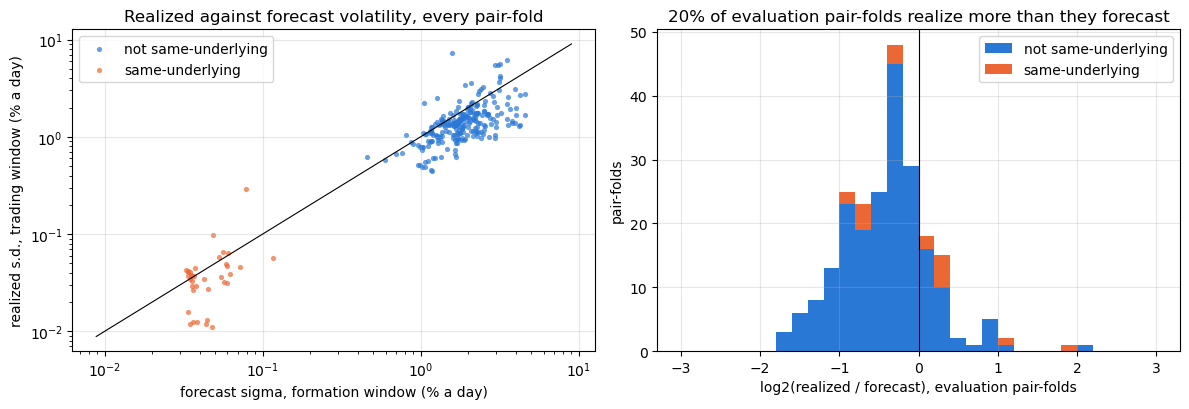

In [23]:
PTR = PT.assign(ratio=PT["sigma_realized"] / PT["sigma"])
EVP = PTR[PTR["period"] == "eval"]
registered("evaluation pair-folds", len(EVP), 225)

def vol_summary(g):
    return pd.Series({"pair-folds": len(g), "median realized / forecast": g["ratio"].median(),
                      "share with realized > forecast": (g["ratio"] > 1).mean(),
                      "median |log2 ratio|": np.abs(np.log2(g["ratio"])).median(),
                      "Spearman (realized, forecast)": stats.spearmanr(g["sigma"], g["sigma_realized"]).statistic if len(g) > 2 else np.nan})
VOL_TAB = pd.DataFrame({"evaluation, all": vol_summary(EVP), "evaluation, not same-underlying": vol_summary(EVP[~EVP["same"]]),
                        "evaluation, same-underlying": vol_summary(EVP[EVP["same"]]),
                        "hold-out, all": vol_summary(PTR[PTR["period"] == "hold"])}).T
display(VOL_TAB.round(3))
EXCEEDS = float((EVP["ratio"] > 1).mean())
print(f"realized volatility exceeds the formation-window sigma in {EXCEEDS:.1%} of the {len(EVP)} evaluation pair-folds "
      f"({int((EVP['ratio'] > 1).sum())}); the pre-registered forecast 7 says more than 60%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for same_, col, lab in ((False, "#2a78d6", "not same-underlying"), (True, "#eb6834", "same-underlying")):
    g = PTR[PTR["same"] == same_]
    ax[0].scatter(g["sigma"] * 100, g["sigma_realized"] * 100, s=14, color=col, alpha=0.7, label=lab, linewidths=0)
lim = [PTR[["sigma", "sigma_realized"]].min().min() * 100 * 0.8, PTR[["sigma", "sigma_realized"]].max().max() * 100 * 1.25]
ax[0].plot(lim, lim, color="k", lw=0.8)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("forecast sigma, formation window (% a day)"); ax[0].set_ylabel("realized s.d., trading window (% a day)")
ax[0].set_title("Realized against forecast volatility, every pair-fold"); ax[0].legend()
ax[1].hist([np.log2(EVP.loc[~EVP["same"], "ratio"]), np.log2(EVP.loc[EVP["same"], "ratio"])], bins=np.linspace(-3, 3, 31),
           stacked=True, color=["#2a78d6", "#eb6834"], label=["not same-underlying", "same-underlying"])
ax[1].axvline(0, color="k", lw=0.8); ax[1].legend()
ax[1].set_xlabel("log2(realized / forecast), evaluation pair-folds"); ax[1].set_ylabel("pair-folds")
ax[1].set_title(f"{EXCEEDS:.0%} of evaluation pair-folds realize more than they forecast")
plt.tight_layout(); plt.show()

Realized volatility was below the formation-window forecast in most pair-folds. It exceeded the forecast in 20.0% of
the 225 evaluation pair-folds (45), where forecast 7 said more than 60%, so forecast 7 fails on this measure. The
median ratio of realized to forecast is 0.790, and the share above one is 0.174 for the 207 pair-folds that are not
same-underlying and 0.500 for the 18 that are, and 0.226 in the 62 hold-out pair-folds, where the median ratio is
0.799. The two are still rank-correlated: the Spearman correlation between realized and forecast is 0.693 over the
evaluation pair-folds (0.607 without the same-underlying pairs). What is measured is the standard deviation of the
same spread return per dollar over the trading window against its standard deviation over the formation window's
common sessions, with the frozen hedge in both, and the first trading-window return spans the formation close
(Deviation 8). The registered run gives no reason for the level, and none is offered here; §14.2 (post hoc, added after
the first run and rewritten after the second review) measures what the share is: against an iid benchmark, by formation
year and by whether the formation window holds a stress period, inside the formation window, and by formation.

### 6.2 Realized against implied risk contributions

For a book with weights $w$ over the pairs of a formation, the risk contribution of pair $i$ under a covariance
$S$ is $w_i (S w)_i / (w' S w)$. **Implied** uses $\Sigma_f$, the formation-window matrix the splits were built
from; **realized** uses the covariance of the same $r_i$ over the trading-window sessions on which every pair
of the formation has a return. Both are computed with every pair open, on the spread returns per dollar, so they
say whether the *split* delivers the risk shares it was designed for, whatever the signals then did. A book's weights
are its recorded split (for `reweight`, the split at the formation close). Only evaluation formations with two or
more pairs enter; the table reports, per book, the mean absolute gap between realized and implied shares, the
rank correlation of the two across pair-folds, and the largest share.

In [24]:
RC_INPUT = {}                                   # (pool, formation) -> (fold ids, realized covariance, sessions)
for pn in POOLS:
    for d, ids in POOLS[pn]["by_f"].items():
        if len(ids) >= 2:
            R = pd.concat({i: FOLDS[i]["r_cat"].loc[FOLDS[i]["r_cat"].index > d] for i in ids}, axis=1).dropna()
            if len(R) >= 20:
                RC_INPUT[(pn, d)] = (ids, np.atleast_2d(np.cov(R.to_numpy().T, ddof=0)), len(R))

def risk_shares(w, S):
    m = S @ w
    return w * m / (w @ m)

RC_PF, rows = {}, []
for (pn, nm), bk in BOOKS.items():
    if pn != "full":
        continue
    pieces = []
    for d in P["ev_forms"]:
        if (pn, d) not in RC_INPUT:
            continue
        ids, C_real, ns = RC_INPUT[(pn, d)]
        w = bk["pf"].loc[ids, "w"].to_numpy(float)
        pieces.append(pd.DataFrame({"fold": ids, "formation": d, "w": w, "implied": risk_shares(w, RISK[pn][d]["cov"]),
                                    "realized": risk_shares(w, C_real)}))
    if not pieces:
        continue
    df = pd.concat(pieces, ignore_index=True)
    RC_PF[nm] = df
    mx = df.groupby("formation").agg(imp=("implied", "max"), rea=("realized", "max"))
    rows.append({"book": nm, "formations": df["formation"].nunique(), "pair-folds": len(df),
                 "mean |gap|": float(np.abs(df["realized"] - df["implied"]).mean()),
                 "Spearman": float(stats.spearmanr(df["implied"], df["realized"]).statistic),
                 "max share, implied": float(mx["imp"].mean()), "max share, realized": float(mx["rea"].mean()),
                 "negative realized": int((df["realized"] < 0).sum())})
RC_TAB = pd.DataFrame(rows).set_index("book")
# books that share a split have identical rows (per_pair, vol_target, frozen, band, reuse and z_size are equal-split books;
# a grid cell has its row's split), so the table shows one row per distinct set of weights
distinct = ["baseline", "A1_inv_vol", "A2_erc", "A3_leg_split", "A4_shipped", "diag_inv_var_dollar", "C2_reweight"]
print("columns: mean |gap| = mean absolute difference between the realized and the implied risk share; Spearman = rank correlation of the two")
print("across pair-folds; max share = the largest single-pair share, averaged over formations; negative realized = pair-folds whose realized")
print("contribution to the book's risk is negative (a hedge inside the book)")
display(RC_TAB.loc[distinct].round(3))
print(f"realized covariance on {len(RC_INPUT)} pool-formations (trading-window sessions on which every pair has a return; "
      f"median {int(np.median([v[2] for v in RC_INPUT.values()]))} sessions)")

columns: mean |gap| = mean absolute difference between the realized and the implied risk share; Spearman = rank correlation of the two
across pair-folds; max share = the largest single-pair share, averaged over formations; negative realized = pair-folds whose realized
contribution to the book's risk is negative (a hedge inside the book)


,formations,pair-folds,mean |gap|,Spearman,"max share, implied","max share, realized",negative realized
book,,,,,,,
baseline,18,219,0.023,0.880,0.345,0.395,25
A1_inv_vol,18,219,0.029,0.723,0.212,0.280,14
A2_erc,18,219,0.031,0.417,0.172,0.284,7
A3_leg_split,18,219,0.022,0.900,0.432,0.508,20
A4_shipped,18,219,0.016,0.891,0.639,0.675,43
diag_inv_var_dollar,18,219,0.026,0.834,0.489,0.545,20
C2_reweight,18,219,0.026,0.858,0.251,0.273,15


realized covariance on 65 pool-formations (trading-window sessions on which every pair has a return; median 126 sessions)


The mean absolute gap between realized and implied risk shares is between 0.016 (`shipped`) and 0.031 (`erc`), and
0.023 for the baseline, but the largest single-pair share is higher realized than implied for every split, and the
ordering of the pairs is preserved less well for `inv_vol` and `erc` than for the baseline (rank correlation 0.723 and
0.417 against 0.880). This is a statement about the weights built here, not about a principle. ERC's equal shares do
not survive out of the formation window: its largest share averages 0.172 implied and 0.284 realized, no lower than
the 0.280 of `inv_vol` (0.212 implied), and its rank correlation of 0.417 is the lowest of the seven rows. Seven of
its pair-folds have a negative realized contribution (14 for `inv_vol`, 25 for the baseline). The `shipped` weights
are the most concentrated by their own covariance, a largest share of 0.639 implied and 0.675 realized, and 43 of the
219 pair-folds contribute negatively; the mean gap between realized and implied shares is nonetheless the smallest of
the seven (0.016).

## 7. The primary tests

All statistics are net of measured costs on the evaluation span unless stated. A book's return on a session is
its dollar P&L at measured cost divided by $K$.

**A1–A5 and C1–C3: paired by formation.** For each evaluation formation that is not tracker-only (17 in the
registered pool), $SR_f$ is mean over standard deviation (ddof = 0) times $\sqrt{252}$ of the book's daily return
over that formation's live sessions, and $\delta_f = SR_f(\text{challenger}) - SR_f(\text{comparator})$. A formation
with $|\delta_f| < 10^{-9}$ is dropped (a formation in which the rule cannot differ from its comparator; a
formation in which a Sharpe is undefined is dropped too and counted). The test is the **exact two-sided Wilcoxon
signed-rank test** (`scipy.stats.wilcoxon`, `method="exact"`), its direction positive when the sum of the positive
ranks exceeds the sum of the negative ranks. The **exact sign test** on the same $\delta_f$ is reported beside it,
and the $\delta_f$ of the tracker-only formations are printed separately. Each formation tested is one draw of a
pool and counts once. The number of formations that can inform a test is at most 17 for A1, A2 and A4, 13 for
`leg_split` (it equals `equal` where the pairs share no ticker) and at most 13 for `reuse` (it is the baseline for
$n_f \le 3$); the number tested is printed for every challenger, with the median, mean and standard deviation
(ddof = 1) of $\delta_f$ over the formations tested.

**B2: permutation.** Deployment is constant inside a formation, so every $\delta_f$ is zero and the paired test
has nothing to test. The null is that the multipliers are unrelated to formation outcomes: the $A_f$ of the
evaluation formations that are not tracker-only are permuted among those formations 10,000 times
(`np.random.default_rng(23)`, one `rng.permutation` call per draw; the tracker-only formations keep their own),
pooled $D$ is recomputed, and $p = (1 + \#\{|D_\pi - \overline{D_\pi}| \ge |D - \overline{D_\pi}| - 10^{-12}\})/10{,}001$.
Beside $p$ the notebook reports the same $p$ with 2008-07-01 removed from the statistic and from the permutation,
and the share of the circular shifts of the multiplier sequence at least as extreme (the identity shift is one of
them, and "as extreme" is judged against the mean of the shifts' own distribution, as in $p$).

**Multiple testing.** Holm at a family-wise 5%, two-sided, across the nine $p$-values: the eight Wilcoxon $p$ and
B2's permutation $p$. Pooled Sharpe ratios are computed from per-formation sufficient statistics (sessions, sum and
sum of squares of the daily return), which is what makes the 10,000 permutations and bootstrap draws instant.

In [25]:
assert GATES_PASSED
def sr_from(n, s1, s2):
    # Sharpe (ddof = 0, annualized) from sessions, sum and sum of squares; NaN where the variance is not positive
    n, s1, s2 = np.asarray(n, float), np.asarray(s1, float), np.asarray(s2, float)
    mu = s1 / n
    var = s2 / n - mu * mu
    ok = var > 1e-30
    return np.where(ok, mu / np.sqrt(np.where(ok, var, 1.0)), np.nan) * np.sqrt(ANN)

def suff(book, span, col="ret_meas"):
    # per-formation sufficient statistics of a book's daily return over its live sessions in a span
    d = book["daily"]
    m = d["live"].to_numpy() & {"eval": EV_S, "hold": HO_S, "all": np.ones(len(CAL), bool)}[span]
    r = d[col].to_numpy()[m]
    df = pd.DataFrame({"n": 1.0, "s1": r, "s2": r * r, "f": CALT["formation"].to_numpy()[m]}).groupby("f").sum()
    df.index = pd.DatetimeIndex(df.index, name="formation")
    return df

def pooled_sr(book, span, col="ret_meas"):
    t = suff(book, span, col).sum()
    return float(sr_from(t["n"], t["s1"], t["s2"]))

def form_sr(book, col="ret_meas"):
    # SR_f of a book, by formation, over the formation's live sessions
    ss = suff(book, "all", col)
    return pd.Series(sr_from(ss["n"], ss["s1"], ss["s2"]), index=ss.index)

# the sufficient-statistic route agrees with the direct one
for nm in ("baseline", "A1_inv_vol", "C3_reuse"):
    bk = BOOKS[("full", nm)]
    assert np.isclose(pooled_sr(bk, "eval"), sr_live(bk, "pnl_meas", "eval"), rtol=1e-9, atol=1e-9), nm
    assert np.isclose(pooled_sr(bk, "hold"), sr_live(bk, "pnl_meas", "hold"), rtol=1e-9, atol=1e-9), nm

def paired_test(delta):
    x = np.asarray(delta, dtype=float)
    fin = np.isfinite(x)
    keep = fin & (np.abs(x) >= 1e-9)
    xt = x[keep]
    nan = float("nan")
    out = {"formations": len(x), "undefined": int((~fin).sum()), "dropped": int((fin & ~keep).sum()), "n_tested": int(keep.sum())}
    if len(xt) == 0:
        out.update(median=nan, mean=nan, sd=nan, W_plus=nan, W_minus=nan, p_wilcoxon=nan, direction=0, n_pos=0, n_neg=0, p_sign=nan)
        return out
    rk = stats.rankdata(np.abs(xt))
    wp, wm = float(rk[xt > 0].sum()), float(rk[xt < 0].sum())
    npos, nneg = int((xt > 0).sum()), int((xt < 0).sum())
    out.update(median=float(np.median(xt)), mean=float(xt.mean()), sd=float(xt.std(ddof=1)) if len(xt) > 1 else nan,
               W_plus=wp, W_minus=wm, p_wilcoxon=float(stats.wilcoxon(xt, method="exact", alternative="two-sided").pvalue),
               direction=int(np.sign(wp - wm)), n_pos=npos, n_neg=nneg,
               p_sign=float(stats.binomtest(npos, npos + nneg, 0.5).pvalue))
    return out

def delta_table(pool_name, names, formations):
    cols = {}
    for nm in names:
        comp = COMPARATOR[nm]
        cols[nm] = form_sr(BOOKS[(pool_name, nm)]) - form_sr(BOOKS[(pool_name, comp)])
    return pd.DataFrame(cols).reindex(formations)

DELTA = delta_table("full", TESTED, P["ev_forms"])           # every live evaluation formation; NaN where a Sharpe is undefined
DELTA_NT = DELTA.loc[P["ev_nt"]]                              # the formations the tests use
TRK_EV = [d for d in P["ev_forms"] if d in P["tracker_only"]]
DELTA_TRK = DELTA.loc[TRK_EV]                                 # printed separately, never tested
PRIM = {nm: paired_test(DELTA_NT[nm]) for nm in TESTED}
assert np.nanmax(np.abs(DELTA["B2_vol_target"].to_numpy())) < 1e-9, "B2's delta_f is not zero: deployment is not constant in a formation"

print(f"delta_f = SR_f(challenger) - SR_f(comparator), {len(DELTA_NT)} evaluation formations that are not tracker-only (net of measured cost)")
display(DELTA_NT.rename(columns=SHORT).round(3))
print(f"tracker-only evaluation formations ({len(DELTA_TRK)}), printed separately and not tested:")
display(DELTA_TRK.rename(columns=SHORT).round(3))

PRIMTAB = pd.DataFrame({nm: {"comparator": COMPARATOR[nm], "formations": v["formations"], "tested": v["n_tested"], "dropped": v["dropped"],
                             "undefined": v["undefined"], "median": v["median"], "mean": v["mean"], "s.d.": v["sd"],
                             "W+": v["W_plus"], "W-": v["W_minus"], "p (exact Wilcoxon)": v["p_wilcoxon"],
                             "direction": {1: "positive", -1: "negative", 0: "none"}[v["direction"]],
                             "n +": v["n_pos"], "n -": v["n_neg"], "p (exact sign)": v["p_sign"]} for nm, v in PRIM.items()}).T
PRIMTAB.index = [f"{SHORT[n]} {n}" for n in PRIMTAB.index]
display(PRIMTAB)
print("B2 has no paired test: its delta_f is zero in every formation (largest |delta_f| "
      f"{np.nanmax(np.abs(DELTA['B2_vol_target'].to_numpy())):.1e}); its primary test is the permutation test below.")
for nm, cap in (("A1_inv_vol", 17), ("A2_erc", 17), ("A4_shipped", 17), ("A3_leg_split", 13), ("C3_reuse", 13)):
    registered(f"formations tested, {SHORT[nm]} {nm}: at most {cap} (1 = yes)", int(PRIM[nm]["n_tested"] <= cap), 1)

delta_f = SR_f(challenger) - SR_f(comparator), 17 evaluation formations that are not tracker-only (net of measured cost)


,A1,A2,A3,A4,A5,B2,C1,C2,C3
formation,,,,,,,,,
2006-06-30,-0.217,-0.028,-0.161,-0.391,0.389,0.0,-0.027,0.215,-0.637
2008-07-01,0.032,0.032,0.000,0.156,0.030,0.0,-0.209,-0.478,0.000
2008-12-31,0.278,0.230,-0.314,0.195,0.006,0.0,0.028,-0.038,0.000
2009-07-01,-0.157,-0.262,-0.460,0.584,-0.031,0.0,0.028,-0.156,0.088
2009-12-31,-0.221,-0.057,-0.403,0.504,-0.093,-0.0,0.008,0.127,-0.539
2010-07-01,-0.738,-0.224,-0.859,-3.379,0.037,0.0,0.005,-0.506,0.102
2010-12-31,-0.356,-0.778,-0.759,0.025,-0.106,0.0,0.001,0.208,-0.167
2011-07-01,0.098,1.121,1.163,1.143,0.120,-0.0,0.017,-0.016,-1.673
2013-07-01,0.066,0.455,-0.167,-0.045,0.018,-0.0,0.027,0.142,-0.175


tracker-only evaluation formations (7), printed separately and not tested:


,A1,A2,A3,A4,A5,B2,C1,C2,C3
formation,,,,,,,,,
2011-12-30,0.000,0.000,0.00,0.000,-0.189,0.0,-0.016,0.000,0.0
2012-06-29,0.000,0.000,0.00,0.000,-0.182,0.0,-0.013,0.000,0.0
2012-12-31,0.000,0.000,0.00,0.000,0.089,0.0,0.007,0.000,0.0
2017-06-30,0.000,0.000,0.00,0.000,-0.068,0.0,0.009,0.000,0.0
2019-12-31,0.000,0.000,0.00,0.000,-0.011,0.0,-0.016,0.000,0.0
2020-07-01,0.000,0.000,0.00,0.000,0.081,-0.0,0.028,0.000,0.0
2022-07-01,0.004,0.092,0.23,2.868,-0.151,0.0,0.080,-0.002,0.0


,comparator,formations,tested,dropped,undefined,median,mean,s.d.,W+,W-,p (exact Wilcoxon),direction,n +,n -,p (exact sign)
A1 A1_inv_vol,baseline,17,17,0,0,-0.14202,-0.183544,0.374975,38.0,115.0,0.071411,negative,6,11,0.332306
A2 A2_erc,baseline,17,17,0,0,-0.056549,-0.1074,0.533881,55.0,98.0,0.328949,negative,7,10,0.629059
A3 A3_leg_split,baseline,17,13,4,0,-0.221958,-0.164663,0.509022,21.0,70.0,0.094238,negative,3,10,0.092285
A4 A4_shipped,baseline,17,17,0,0,-0.025845,-0.367726,1.20081,61.0,92.0,0.487381,negative,7,10,0.629059
A5 A5_z_size,baseline,17,17,0,0,-0.005328,0.01399,0.180847,75.0,78.0,0.963226,negative,8,9,1.0
B2 B2_vol_target,baseline,17,0,17,0,NaN,NaN,NaN,NaN,NaN,NaN,none,0,0,NaN
C1 C1_frozen,baseline,17,17,0,0,0.006458,0.000881,0.069462,95.0,58.0,0.403763,positive,12,5,0.143463
C2 C2_reweight,A1_inv_vol,17,17,0,0,0.046332,-0.015351,0.239311,86.0,67.0,0.677704,positive,10,7,0.629059
C3 C3_reuse,baseline,17,11,6,0,-0.17523,-0.291585,0.690942,13.0,53.0,0.083008,negative,3,8,0.226562


B2 has no paired test: its delta_f is zero in every formation (largest |delta_f| 1.1e-14); its primary test is the permutation test below.
  formations tested, A1 A1_inv_vol: at most 17 (1 = yes)                  1   (registered 1)
  formations tested, A2 A2_erc: at most 17 (1 = yes)                      1   (registered 1)
  formations tested, A4 A4_shipped: at most 17 (1 = yes)                  1   (registered 1)
  formations tested, A3 A3_leg_split: at most 13 (1 = yes)                1   (registered 1)
  formations tested, C3 C3_reuse: at most 13 (1 = yes)                    1   (registered 1)


No paired test reaches 5%, and none comes near the strictest Holm step. Six of the eight tests have the rank sum on
the side of the comparator (A1 to A5 and C3) and two on the side of the challenger (C1 and C2). The smallest p-values
are 0.0714 for A1, 0.083 for C3 and 0.0942 for A3, all in the negative direction; the exact sign test gives 0.332,
0.227 and 0.092 for the same three. What each test rests on, over the formations tested:

- A1 `inv_vol`: 17 tested, median $\delta_f$ -0.142, mean -0.184, s.d. 0.375; exact Wilcoxon p 0.0714 (rank sums 38
  and 115); 6 positive and 11 negative formations, sign test 0.332.
- A2 `erc`: 17 tested, median -0.057, mean -0.107, s.d. 0.534; p 0.329; 7 positive and 10 negative, sign test 0.629.
- A3 `leg_split`: 13 tested (the four formations where no ticker repeats are identical to the baseline and dropped),
  median -0.222, mean -0.165, s.d. 0.509; p 0.0942; 3 positive and 10 negative, sign test 0.092.
- A4 `shipped`: 17 tested, median -0.026, mean -0.368, s.d. 1.201; p 0.487; 7 positive and 10 negative, sign test
  0.629. Two formations, 2010-07-01 and 2015-07-01, sit at -3.379 and -3.289.
- A5 `z_size`: 17 tested, median -0.005, mean 0.014, s.d. 0.181; p 0.963; 8 positive and 9 negative, sign test 1.0.
- C1 `frozen`: 17 tested, median 0.006, mean 0.001, s.d. 0.069; p 0.404; 12 positive and 5 negative, sign test 0.143.
- C2 `reweight` against `inv_vol`: 17 tested, median 0.046, mean -0.015, s.d. 0.239; p 0.678; 10 positive and 7
  negative, sign test 0.629.
- C3 `reuse`: 11 tested, median -0.175, mean -0.292, s.d. 0.691; p 0.083; 3 positive and 8 negative, sign test 0.227.
  Six formations are dropped because $\delta_f$ is zero. In four the book equals the baseline (2008-07-01, 2015-12-31,
  2020-12-31 and 2021-07-01, with $n_f \le 3$). In the other two, 2008-12-31 ($n_f$ = 5) and 2015-07-01 ($n_f$ = 4), the
  cap $n_f/3$ binds on every trade, because never more than three pairs are held, so the book is a constant 1.667
  and 1.333 multiple of the baseline with the same Sharpe ratio, which a scale-free Sharpe cannot tell from the
  baseline itself. C3's pooled $D$ includes the leverage it puts on each formation, but that is not what makes it
  negative: giving the baseline C3's formation-level scale changes its pooled Sharpe by -0.0003 (§14.5, post hoc).
- B2 has no paired test, since deployment is constant inside a formation and every $\delta_f$ is zero; its test is in
  §7.1.

The tracker-only formations are printed apart and never tested. For the split rules and `reweight` they are zero in
every formation but 2022-07-01, where four same-underlying pairs share the weights: A4 gives +2.868 there, A3 0.230
and A2 0.092 (A1 and C2 give 0.004 and -0.002). `reuse` is zero in all seven, 2022-07-01 included, because there the
cap $n_f/3$ binds and the book is a constant 1.333 multiple of the baseline. A5 and C1 change the size and not the
split, so they differ from the baseline in every tracker-only formation, by -0.189 to +0.089 for A5 and -0.016 to
+0.080 for C1.

The registered power statement is that at the strictest Holm step (p < 0.0056) the paired test reaches 80% power for
an effect of about one standard deviation of $\delta_f$ with 17 formations and about 1.2 with 13. Against the s.d.
above, an effect of the size of the 0.10 margin was within reach only of C1 (0.069). A5's s.d. is 0.181, A1's 0.375
and A4's 1.201, so for A4 the test could see an effect of about 1.2 Sharpe points and nothing smaller. A test that
does not reject says little about A1 to A4 and C3.

### 7.1 B2: the permutation test

The observed statistic is B2's pooled $D$ on the evaluation span: the pooled net Sharpe of B2 minus the baseline's,
over the live sessions of all 24 evaluation formations (tracker-only formations included, keeping their own $A_f$).
Because deployment scales a formation's dollars linearly under a daily reset, B2's per-formation sufficient
statistics are the baseline's times $A_f$ and $A_f^2$ (checked below), so a permuted $D_\pi$ needs only arithmetic
on the baseline's per-formation sums. M_f of 2008-07-01 is a single value, $s$ of 2006-06-30, and the result is read
with that in mind; B2 with $A_f = 1$ until three earlier formations enter $M_f$ is reported as a sensitivity in §8.

In [26]:
assert GATES_PASSED
B2 = BOOKS[("full", "B2_vol_target")]
EVF = list(P["ev_forms"])
SSB, SS2 = suff(BASE, "eval"), suff(B2, "eval")
assert list(SSB.index) == EVF and SSB.index.equals(SS2.index)
NB_, S1B, S2B = SSB["n"].to_numpy(), SSB["s1"].to_numpy(), SSB["s2"].to_numpy()
A_EV = B2["form"].loc[EVF, "A"].to_numpy(float)
assert np.allclose(SS2["s1"], A_EV * S1B, rtol=1e-9, atol=1e-12) and np.allclose(SS2["s2"], A_EV ** 2 * S2B, rtol=1e-9, atol=1e-12), \
    "B2 is not the baseline scaled by A_f in every formation"
NT_SET = set(P["ev_nt"])
D08 = pd.Timestamp("2008-07-01")

def perm_test(drop=None):
    keep = np.array([d != drop for d in EVF])
    n_, s1_, s2_, A_ = NB_[keep], S1B[keep], S2B[keep], A_EV[keep]
    nt_ = np.array([d in NT_SET for d in np.array(EVF, dtype=object)[keep]])
    N_ = n_.sum()
    sr0 = float(sr_from(N_, s1_.sum(), s2_.sum()))
    D_of = lambda A: sr_from(N_, (A * s1_).sum(-1), (A * A * s2_).sum(-1)) - sr0
    D_obs = float(D_of(A_))
    idx = np.flatnonzero(nt_)
    rng = np.random.default_rng(SEED_PERM)
    As = np.tile(A_, (N_PERM, 1))
    for b in range(N_PERM):
        As[b, idx] = rng.permutation(A_[idx])
    Dpi = D_of(As)
    mu_pi = float(np.nanmean(Dpi))
    p = (1 + int((np.abs(Dpi - mu_pi) >= abs(D_obs - mu_pi) - 1e-12).sum())) / (N_PERM + 1)
    def shifted(k):
        A2 = A_.copy()
        A2[idx] = np.roll(A_[idx], k)                 # circular shift of the multiplier sequence, in date order
        return A2
    shifts = np.array([float(D_of(shifted(k))) for k in range(len(idx))])
    mu_s = float(np.nanmean(shifts))
    share = float((np.abs(shifts - mu_s) >= abs(D_obs - mu_s) - 1e-12).mean())
    return {"D": D_obs, "mean_Dpi": mu_pi, "sd_Dpi": float(np.nanstd(Dpi)), "D_minus_mean": D_obs - mu_pi, "p": float(p),
            "shift_share": share, "n_shifts": len(idx), "n_formations": int(keep.sum()), "n_permuted": len(idx),
            "extreme": int((np.abs(Dpi - mu_pi) >= abs(D_obs - mu_pi) - 1e-12).sum())}

PERM = {"all": perm_test(None), "ex2008": perm_test(D08)}
registered("B2 permutation draws", N_PERM, 10000)
registered("evaluation formations permuted among themselves (not tracker-only)", PERM["all"]["n_permuted"], 17)
registered("circular shifts of the multiplier sequence", PERM["all"]["n_shifts"], 17)
assert abs(PERM["all"]["D"] - (pooled_sr(B2, "eval") - pooled_sr(BASE, "eval"))) < 1e-9, "the permutation statistic is not B2's pooled D"
print(f"{'':30s} {'D':>8s} {'mean D_pi':>10s} {'sd D_pi':>8s} {'D - mean':>9s} {'p':>8s} {'as extreme':>11s} {'shift share':>12s}")
for lab, key in (("all evaluation formations", "all"), ("without 2008-07-01", "ex2008")):
    r = PERM[key]
    print(f"{lab:30s} {r['D']:8.3f} {r['mean_Dpi']:10.3f} {r['sd_Dpi']:8.3f} {r['D_minus_mean']:9.3f} {r['p']:8.4f} "
          f"{r['extreme']:>5d}/{N_PERM:<5d} {r['shift_share']:12.3f}   ({r['n_formations']} formations, {r['n_permuted']} permuted)")
if D08 in EVF:
    b2f = B2["form"]
    earlier = [d for d in FORMATIONS if d < D08 and P["n_f"][d] > 0 and d not in P["tracker_only"]]
    print(f"M_f of 2008-07-01 = {b2f.loc[D08, 'M'] * 100:.4f}% is the median of s over {len(earlier)} earlier live formation(s) "
          f"that are not tracker-only: {[d.date().isoformat() for d in earlier]}; A_f = {b2f.loc[D08, 'A']:.3f}")
    registered("live, non-tracker-only formations before 2008-07-01 (M_f is one value)", len(earlier), 1)
    registered("M_f of 2008-07-01 equals s of 2006-06-30 (1 = yes)",
               int(np.isclose(b2f.loc[D08, "M"], b2f.loc[pd.Timestamp("2006-06-30"), "s"])), 1)
else:
    print("2008-07-01 is not a live evaluation formation of this pool: the without-2008-07-01 row equals the first")

  B2 permutation draws                                                10000   (registered 10000)
  evaluation formations permuted among themselves (not tracker-only)         17   (registered 17)
  circular shifts of the multiplier sequence                             17   (registered 17)
                                      D  mean D_pi  sd D_pi  D - mean        p  as extreme  shift share
all evaluation formations        -0.028     -0.027    0.068    -0.001   0.9867  9867/10000        1.000   (24 formations, 17 permuted)
without 2008-07-01                0.020     -0.029    0.085     0.049   0.5801  5801/10000        0.375   (23 formations, 16 permuted)
M_f of 2008-07-01 = 0.9820% is the median of s over 1 earlier live formation(s) that are not tracker-only: ['2006-06-30']; A_f = 1.544
  live, non-tracker-only formations before 2008-07-01 (M_f is one value)          1   (registered 1)
  M_f of 2008-07-01 equals s of 2006-06-30 (1 = yes)                      1   (registered 1)


B2's pooled $D$ of -0.028 sits at the center of its permutation null. Over 10,000 permutations of the 17 multipliers
the mean of $D_\pi$ is -0.027 with a s.d. of 0.068, so $D$ minus the mean is -0.001 and 9867 of the 10,000 draws are
as extreme (p 0.9867); all 17 circular shifts of the multiplier sequence are as extreme too (share 1.000). Without
2008-07-01 (23 formations, 16 permuted) $D$ is +0.020 against a null mean of -0.029 and s.d. of 0.085, so $D$ minus
the mean is +0.049 and p is 0.5801 (5801 of 10,000, shift share 0.375). The sign of the estimate turns on one
formation, and B2's special condition, a positive $D$ minus the mean with and without 2008-07-01, is not met.

$M_f$ of 2008-07-01 is a single value, the median of $s$ over the one earlier live formation that is not tracker-only.
It is the $s$ of 2006-06-30, 0.9820% a day, so $A_f$ there is 1.544, on the formation that carries 0.455 of the
baseline's variance. The sensitivity that keeps $A_f$ = 1 until three earlier formations enter $M_f$ is in §8.

### 7.2 Holm across the nine p-values

In [27]:
def holm(p, alpha=0.05):
    # Holm step-down: adjusted p and the rejections; an undefined p is treated as 1
    p = np.asarray(p, float)
    p = np.where(np.isfinite(p), p, 1.0)
    order = np.argsort(p, kind="stable")
    m, adj, run = len(p), np.empty(len(p)), 0.0
    for rank, i in enumerate(order):
        run = max(run, min(1.0, (m - rank) * p[i]))
        adj[i] = run
    return adj, adj <= alpha

PRIMARY_P = {nm: (PERM["all"]["p"] if nm == "B2_vol_target" else PRIM[nm]["p_wilcoxon"]) for nm in TESTED}
PRIMARY_DIR = {nm: (int(np.sign(PERM["all"]["D_minus_mean"])) if nm == "B2_vol_target" else PRIM[nm]["direction"]) for nm in TESTED}
registered("p-values in the Holm family", len(PRIMARY_P), 9)
_adj, _rej = holm([PRIMARY_P[n] for n in TESTED])
HOLM = pd.DataFrame({"test": ["permutation" if n == "B2_vol_target" else "exact Wilcoxon" for n in TESTED],
                     "p": [PRIMARY_P[n] for n in TESTED],
                     "direction": [{1: "positive", -1: "negative", 0: "none"}[PRIMARY_DIR[n]] for n in TESTED],
                     "Holm-adjusted p": _adj, "rejects at 5%": _rej}, index=[f"{SHORT[n]} {n}" for n in TESTED])
display(HOLM.sort_values("p").round(4))
undef = [n for n in TESTED if not np.isfinite(PRIMARY_P[n])]
print(f"strictest Holm step: p < {0.05 / len(TESTED):.4f}; rejections: {[SHORT[n] for n, r in zip(TESTED, _rej) if r] or 'none'}"
      + (f"; undefined p treated as 1: {[SHORT[n] for n in undef]}" if undef else ""))

  p-values in the Holm family                                             9   (registered 9)


,test,p,direction,Holm-adjusted p,rejects at 5%
A1 A1_inv_vol,exact Wilcoxon,0.0714,negative,0.6427,False
C3 C3_reuse,exact Wilcoxon,0.0830,negative,0.6641,False
A3 A3_leg_split,exact Wilcoxon,0.0942,negative,0.6641,False
A2 A2_erc,exact Wilcoxon,0.3289,negative,1.0000,False
C1 C1_frozen,exact Wilcoxon,0.4038,positive,1.0000,False
A4 A4_shipped,exact Wilcoxon,0.4874,negative,1.0000,False
C2 C2_reweight,exact Wilcoxon,0.6777,positive,1.0000,False
A5 A5_z_size,exact Wilcoxon,0.9632,negative,1.0000,False
B2 B2_vol_target,permutation,0.9867,negative,1.0000,False


strictest Holm step: p < 0.0056; rejections: none


None of the nine p-values survives the Holm step-down. The strictest step is p < 0.0056, and the smallest p is A1's
0.0714, which Holm adjusts to 0.6427. C3 (0.0830) and A3 (0.0942) are both adjusted to 0.6641, and every other
adjusted p is 1.0000. The directions are negative for A1, C3, A3, A2, A4, A5 and B2 and positive for C1 and C2. The
primary test therefore contributes neither an adoption nor a 'worse' outcome for any challenger.

## 8. Pooled $D$ for every challenger and diagnostic

$D$ is the pooled net Sharpe of the challenger minus the comparator's, on the live sessions of the span. It is
reported for every challenger and diagnostic and it is not the test (§7). Its uncertainty is a **cluster bootstrap
over formations**: one index matrix `np.random.default_rng(22).integers(0, 24, size=(10000, 24))`, shared by all
books, over the evaluation span's 24 live formations; a draw takes each selected formation's sessions whole. Books
keep their full-sample $A_f$ and $M_f$ in every draw and every leave-one-out sample; only sessions are resampled or
removed. Percentile intervals use `np.percentile` (linear interpolation) at 2.5 / 97.5 and 0.5 / 99.5. The decision
rules use the **99%** interval, because on the baseline the 24-cluster percentile interval covers about 87% to 90% at
a nominal 95% and about 95% at a nominal 99%. The **leave-one-formation-out** range removes each evaluation formation
in turn. The hold-out value is the same $D$ on the hold-out sessions (its standard error is that of a Sharpe ratio,
$\sqrt{252/\text{sessions}}$, and nothing more), and the gated-pool and ex-tracker-pool values are $D$ on those
pools' own evaluation spans, with each pool's own baseline (or `inv_vol` for C2) as the comparator. For `reuse`,
pooled $D$ includes a movement of capital between formations, which is described (§10) and not tested (§14.5, post
hoc, measures how much of C3's $D$ it is). The
one diagnostic gap the pre-registration names, what the price units cost (`shipped` minus `inv_var_dollar`), is
computed the same way, on the same index matrix and leave-one-out, and printed under the table; it is outside the
test family.

In [28]:
assert GATES_PASSED
N_EV = len(EVF)
registered("evaluation live formations (bootstrap clusters)", N_EV, 24)
registered("bootstrap draws", N_BOOT, 10000)
IDX = np.random.default_rng(SEED_BOOT).integers(0, N_EV, size=(N_BOOT, N_EV))          # one matrix, shared by every book
registered("bootstrap index matrix shape", tuple(IDX.shape), (10000, 24))
COUNTS = (IDX[:, :, None] == np.arange(N_EV)[None, None, :]).sum(axis=1).astype(float)  # how often each formation is drawn

# facts registered about the baseline itself (nothing here is a challenger): its leave-one-formation-out range at measured cost
_sb = suff(BASE, "eval")
_lofo_base = sr_from(_sb["n"].sum() - _sb["n"], _sb["s1"].sum() - _sb["s1"], _sb["s2"].sum() - _sb["s2"])
registered("baseline, evaluation span, measured cost: leave-one-formation-out minimum (registered 0.37 to 0.58)",
           round(float(np.nanmin(_lofo_base)), 2), 0.37, exact=False, tol=0.006)
registered("baseline, evaluation span, measured cost: leave-one-formation-out maximum",
           round(float(np.nanmax(_lofo_base)), 2), 0.58, exact=False, tol=0.006)
_dm = BASE["daily"].loc[BASE["daily"]["live"] & EV_S, "ret_meas"]
_sh, _neff = variance_shares(_dm, CALT.loc[_dm.index, "formation"].to_numpy())
print(f"baseline, evaluation span: the 2008-07-01 formation carries {_sh.get(D08, 0.0):.0%} of the sum of squared deviations "
      f"(registered: 45%), and the effective number of formations 1/sum(share^2) is {_neff:.1f} (registered: about four)")
registered("baseline, evaluation span: share of the variance from 2008-07-01, two decimals", round(float(_sh.get(D08, 0.0)), 2), 0.45,
           exact=False, tol=1e-9)
registered("baseline, evaluation span: effective number of formations, rounded", int(round(_neff)), 4)

def eval_D(chal, comp, intervals=True):
    sc, sp = suff(chal, "eval"), suff(comp, "eval")
    assert sc.index.equals(sp.index), "challenger and comparator do not share their live formations"
    n, c1, c2, p1, p2 = (sc["n"].to_numpy(), sc["s1"].to_numpy(), sc["s2"].to_numpy(), sp["s1"].to_numpy(), sp["s2"].to_numpy())
    src, srp = float(sr_from(n.sum(), c1.sum(), c2.sum())), float(sr_from(n.sum(), p1.sum(), p2.sum()))
    out = {"sr_chal": src, "sr_comp": srp, "D": src - srp, "formations": len(n)}
    if intervals:
        assert list(sc.index) == EVF, "the bootstrap clusters are the full pool's live evaluation formations"
        Nb = COUNTS @ n
        Db = sr_from(Nb, COUNTS @ c1, COUNTS @ c2) - sr_from(Nb, COUNTS @ p1, COUNTS @ p2)
        lo95, hi95, lo99, hi99 = np.nanpercentile(Db, [2.5, 97.5, 0.5, 99.5])
        lofo = sr_from(n.sum() - n, c1.sum() - c1, c2.sum() - c2) - sr_from(n.sum() - n, p1.sum() - p1, p2.sum() - p2)
        out.update(lo95=float(lo95), hi95=float(hi95), lo99=float(lo99), hi99=float(hi99), boot_undefined=int(np.isnan(Db).sum()),
                   lofo_min=float(np.nanmin(lofo)), lofo_max=float(np.nanmax(lofo)),
                   lofo_min_at=EVF[int(np.nanargmin(lofo))], lofo_max_at=EVF[int(np.nanargmax(lofo))],
                   lofo_all_pos=bool(np.all(lofo > 0)), lofo_all_neg=bool(np.all(lofo < 0)))
    return out

def hold_D(chal, comp):
    a, b = pooled_sr(chal, "hold"), pooled_sr(comp, "hold")
    return a, b, a - b

D8 = {}
for nm in TESTED + DIAGNOSTIC:
    comp = COMPARATOR[nm]
    r = eval_D(BOOKS[("full", nm)], BOOKS[("full", comp)])
    r["comparator"] = comp
    r["sr_hold_chal"], r["sr_hold_comp"], r["D_hold"] = hold_D(BOOKS[("full", nm)], BOOKS[("full", comp)])
    for pn, tag in (("gated", "gated"), ("extracker", "ext")):
        if (pn, nm) in BOOKS:
            g = eval_D(BOOKS[(pn, nm)], BOOKS[(pn, comp)], intervals=False)
            pt = paired_test(delta_table(pn, [nm], POOLS[pn]["ev_nt"])[nm])
            r[f"D_{tag}"], r[f"median_{tag}"], r[f"n_tested_{tag}"] = g["D"], pt["median"], pt["n_tested"]
    D8[nm] = r
# the composite asked of C2: inverse volatility with reweighting, read against the baseline
COMPOSITE = eval_D(BOOKS[("full", "C2_reweight")], BASE)
COMPOSITE["D_hold"] = hold_D(BOOKS[("full", "C2_reweight")], BASE)[2]
# what the price units cost: the gap the pre-registration names between `shipped` (weights by the variance of a price-unit residual)
# and `inv_var_dollar` (weights by the variance of a spread return per dollar), on the shared bootstrap and the leave-one-out; not tested
PRICE_UNITS = eval_D(BOOKS[("full", "A4_shipped")], BOOKS[("full", "diag_inv_var_dollar")])
PRICE_UNITS["D_hold"] = hold_D(BOOKS[("full", "A4_shipped")], BOOKS[("full", "diag_inv_var_dollar")])[2]

def _iv(r, k):
    return f"[{r['lo' + k]:+.3f}, {r['hi' + k]:+.3f}]"
D8TAB = pd.DataFrame({nm: {"comparator": r["comparator"], "Sharpe (chal.)": r["sr_chal"], "Sharpe (comp.)": r["sr_comp"], "D": r["D"],
                           "95% interval": _iv(r, "95"), "99% interval": _iv(r, "99"),
                           "99% inside +-0.10": bool(r["lo99"] > -0.10 and r["hi99"] < 0.10),
                           "LOFO min": r["lofo_min"], "LOFO max": r["lofo_max"], "D hold-out": r["D_hold"],
                           "D gated": r.get("D_gated", np.nan), "D ex-tracker": r.get("D_ext", np.nan)}
                      for nm, r in D8.items()}).T
D8TAB.index = [f"{SHORT[n]} {n}" for n in D8TAB.index]
for c in ("Sharpe (chal.)", "Sharpe (comp.)", "D", "LOFO min", "LOFO max", "D hold-out", "D gated", "D ex-tracker"):
    D8TAB[c] = D8TAB[c].astype(float).round(3)
print("pooled D on the evaluation span (net of measured cost); the first nine rows are tested, the last four are not")
display(D8TAB)
print(f"composite (C2 reweight against the baseline): D {COMPOSITE['D']:+.3f}, 95% {_iv(COMPOSITE, '95')}, 99% {_iv(COMPOSITE, '99')}, "
      f"hold-out {COMPOSITE['D_hold']:+.3f}")
print(f"price units (A4 shipped minus the inv_var_dollar diagnostic; outside the test family): pooled net Sharpe {PRICE_UNITS['sr_chal']:.3f} against "
      f"{PRICE_UNITS['sr_comp']:.3f}, D {PRICE_UNITS['D']:+.3f}, 95% {_iv(PRICE_UNITS, '95')}, 99% {_iv(PRICE_UNITS, '99')}, leave-one-formation-out "
      f"{PRICE_UNITS['lofo_min']:+.3f} (without {PRICE_UNITS['lofo_min_at'].date()}) to {PRICE_UNITS['lofo_max']:+.3f} "
      f"(without {PRICE_UNITS['lofo_max_at'].date()}), hold-out {PRICE_UNITS['D_hold']:+.3f}")
print("leave-one-formation-out extremes: " + "; ".join(
    f"{SHORT[n]} {D8[n]['lofo_min']:+.3f} (without {D8[n]['lofo_min_at'].date()}) to {D8[n]['lofo_max']:+.3f} (without {D8[n]['lofo_max_at'].date()})"
    for n in TESTED))
_und = {n: r["boot_undefined"] for n, r in D8.items() if r["boot_undefined"]}
print("bootstrap draws with an undefined Sharpe (excluded from the percentiles):", _und or "none")
base_hold_se = float(np.sqrt(ANN / int((BASE['daily']['live'].to_numpy() & HO_S).sum())))
print(f"hold-out: {int((BASE['daily']['live'].to_numpy() & HO_S).sum())} live sessions, standard error of a Sharpe ratio {base_hold_se:.2f}")

  evaluation live formations (bootstrap clusters)                        24   (registered 24)
  bootstrap draws                                                     10000   (registered 10000)
  bootstrap index matrix shape                                   (10000, 24)   (registered (10000, 24))
  baseline, evaluation span, measured cost: leave-one-formation-out minimum (registered 0.37 to 0.58)       0.37   (registered 0.37)
  baseline, evaluation span, measured cost: leave-one-formation-out maximum       0.58   (registered 0.58)
baseline, evaluation span: the 2008-07-01 formation carries 45% of the sum of squared deviations (registered: 45%), and the effective number of formations 1/sum(share^2) is 4.2 (registered: about four)
  baseline, evaluation span: share of the variance from 2008-07-01, two decimals       0.45   (registered 0.45)
  baseline, evaluation span: effective number of formations, rounded          4   (registered 4)


pooled D on the evaluation span (net of measured cost); the first nine rows are tested, the last four are not


,comparator,Sharpe (chal.),Sharpe (comp.),D,95% interval,99% interval,99% inside +-0.10,LOFO min,LOFO max,D hold-out,D gated,D ex-tracker
A1 A1_inv_vol,baseline,0.315,0.514,-0.199,"[-0.464, +0.074]","[-0.553, +0.158]",False,-0.247,-0.119,0.222,-0.283,-0.031
A2 A2_erc,baseline,0.295,0.514,-0.219,"[-0.592, +0.121]","[-0.737, +0.212]",False,-0.271,-0.084,0.111,-0.291,0.014
A3 A3_leg_split,baseline,0.450,0.514,-0.064,"[-0.258, +0.124]","[-0.312, +0.189]",False,-0.130,-0.004,-0.453,-0.114,NaN
A4 A4_shipped,baseline,0.106,0.514,-0.408,"[-0.925, +0.010]","[-1.114, +0.101]",False,-0.450,-0.249,-0.490,-0.483,-0.107
A5 A5_z_size,baseline,0.500,0.514,-0.014,"[-0.074, +0.057]","[-0.093, +0.078]",True,-0.027,0.011,0.019,-0.030,NaN
B2 B2_vol_target,baseline,0.486,0.514,-0.028,"[-0.160, +0.136]","[-0.213, +0.193]",False,-0.061,0.040,-0.397,-0.040,0.016
C1 C1_frozen,baseline,0.490,0.514,-0.023,"[-0.065, +0.021]","[-0.078, +0.027]",True,-0.029,0.008,-0.042,-0.023,NaN
C2 C2_reweight,A1_inv_vol,0.305,0.315,-0.010,"[-0.129, +0.079]","[-0.177, +0.099]",False,-0.043,0.021,0.324,-0.011,-0.034
C3 C3_reuse,baseline,0.250,0.514,-0.264,"[-0.652, +0.195]","[-0.775, +0.333]",False,-0.354,-0.078,-0.257,-0.093,NaN
B1 B1_per_pair,baseline,0.553,0.514,0.039,"[-0.180, +0.253]","[-0.240, +0.329]",False,-0.059,0.091,-0.028,0.114,NaN


composite (C2 reweight against the baseline): D -0.209, 95% [-0.517, +0.093], 99% [-0.625, +0.192], hold-out +0.546
price units (A4 shipped minus the inv_var_dollar diagnostic; outside the test family): pooled net Sharpe 0.106 against 0.115, D -0.009, 95% [-0.301, +0.327], 99% [-0.399, +0.452], leave-one-formation-out -0.071 (without 2008-07-01) to +0.047 (without 2015-07-01), hold-out -0.699
leave-one-formation-out extremes: A1 -0.247 (without 2021-07-01) to -0.119 (without 2021-12-31); A2 -0.271 (without 2018-12-31) to -0.084 (without 2021-12-31); A3 -0.130 (without 2011-07-01) to -0.004 (without 2021-12-31); A4 -0.450 (without 2009-07-01) to -0.249 (without 2015-07-01); A5 -0.027 (without 2021-07-01) to +0.011 (without 2021-12-31); B2 -0.061 (without 2009-12-31) to +0.040 (without 2021-12-31); C1 -0.029 (without 2011-07-01) to +0.008 (without 2008-07-01); C2 -0.043 (without 2018-06-29) to +0.021 (without 2008-07-01); C3 -0.354 (without 2018-12-31) to -0.078 (without 2011-07-01)
boot

In [29]:
# added after the first run (display only): what the "D gated" and "D ex-tracker" columns above, and the registered principle rule of
# section 11, rest on. The rule reads the sign of the median delta_f and of pooled D on the ex-tracker pool against the full pool's, so both
# are printed with the number of formations tested on each pool (a formation is dropped where delta_f is zero, as in the full pool; where an
# ex-tracker or gated formation is left with a single pair its book equals the comparator's). Neither pool has an interval or a test.
_pool_rows = {}
for nm in TESTED:
    r = D8[nm]
    _pool_rows[f"{SHORT[nm]} {nm}"] = {
        "D, full": r["D"], "D, gated": r.get("D_gated", np.nan), "D, ex-tracker": r.get("D_ext", np.nan),
        "median delta_f, full": PRIM[nm]["median"], "median delta_f, gated": r.get("median_gated", np.nan),
        "median delta_f, ex-tracker": r.get("median_ext", np.nan),
        "tested, full": PRIM[nm]["n_tested"], "tested, gated": r.get("n_tested_gated", np.nan),
        "tested, ex-tracker": r.get("n_tested_ext", np.nan)}
D8POOLS = pd.DataFrame(_pool_rows).T
for c in [c for c in D8POOLS.columns if c.startswith("tested")]:
    D8POOLS[c] = D8POOLS[c].astype("Int64")
print("pooled D and the median delta_f (over the formations tested) on the full, gated and ex-tracker pools; the ex-tracker pool re-runs only "
      "A1, A2, A4, B2 and C2, and B2's delta_f is zero by construction")
display(D8POOLS.round(4))

pooled D and the median delta_f (over the formations tested) on the full, gated and ex-tracker pools; the ex-tracker pool re-runs only A1, A2, A4, B2 and C2, and B2's delta_f is zero by construction


,"D, full","D, gated","D, ex-tracker","median delta_f, full","median delta_f, gated","median delta_f, ex-tracker","tested, full","tested, gated","tested, ex-tracker"
A1 A1_inv_vol,-0.1989,-0.2825,-0.0313,-0.1420,-0.0606,-0.0986,17,16,15
A2 A2_erc,-0.2187,-0.2909,0.0142,-0.0565,-0.0045,-0.0284,17,16,15
A3 A3_leg_split,-0.0636,-0.1145,NaN,-0.2220,-0.3145,NaN,13,11,<NA>
A4 A4_shipped,-0.4076,-0.4831,-0.1071,-0.0258,-0.0738,0.0038,17,16,15
A5 A5_z_size,-0.0136,-0.0301,NaN,-0.0053,0.0002,NaN,17,16,<NA>
B2 B2_vol_target,-0.0279,-0.0396,0.0162,NaN,NaN,NaN,0,0,0
C1 C1_frozen,-0.0234,-0.0230,NaN,0.0065,0.0048,NaN,17,17,<NA>
C2 C2_reweight,-0.0102,-0.0110,-0.0340,0.0463,0.0453,0.0463,17,16,15
C3 C3_reuse,-0.2638,-0.0930,NaN,-0.1752,-0.2553,NaN,11,9,<NA>


Pooled $D$ is negative on the evaluation span for all nine tested challengers, from -0.408 (A4) to -0.010 (C2 against
`inv_vol`), and no 99% interval excludes zero. No 95% interval excludes zero either: the upper ends nearest zero are
A4's +0.010 ([-0.925, +0.010]), C1's +0.021 ([-0.065, +0.021]), A5's +0.057, A1's +0.074 ([-0.464, +0.074]) and C2's
+0.079. For the four split rules and B2 the negative sign is less informative than it looks: 76.5% of the 1,000
arbitrary splits of §9 have a negative pooled $D$ too, and B2's permutation null has a mean $D$ of -0.027 (§14.6, post hoc).
The 99% intervals are widest for A4 [-1.114, +0.101] and C3 [-0.775, +0.333] and narrowest for C1 [-0.078, +0.027] and
A5 [-0.093, +0.078], the only two inside the ±0.10 band. For A1, A2, A3, A4 and C3 pooled $D$ is negative in every
leave-one-formation-out sample, from -0.450 (A4, without 2009-07-01) to -0.004 (A3, without 2021-12-31), so no single
formation produces the sign, while the interval stays wide. For A5, B2, C1 and C2 the range straddles zero. The gated
pool gives the same sign for all nine, from -0.483 (A4) to -0.011 (C2).

The hold-out is an exposed window, used here as a sign check, and its 655 live sessions give a standard error of a
Sharpe ratio of 0.62. Its $D$ is positive for A1 (+0.222), A2 (+0.111), A5 (+0.019) and C2 (+0.324) and negative for
A3 (-0.453), A4 (-0.490), B2 (-0.397), C1 (-0.042) and C3 (-0.257), so it reverses the evaluation sign for four of the
nine. Under no effect a hold-out sign agrees about half the time. The ex-tracker pool, on which A1, A2, A4, B2 and C2
were re-run, gives -0.031, +0.014, -0.107, +0.016 and -0.034 (C2 against A1). These are point values from the registered
run, with no interval and no test, on a different sample: 17 evaluation formations and 2,142 live evaluation sessions
against 24 and 3,022. They should not be read straight against the full-pool values. The ex-tracker baseline is 0.561 and
the full pool's 0.514, but on the same 17 formations the full pool's baseline is 0.608, so removing the same-underlying
pairs lowers it, and the full pool's $D$ on those 17 formations is -0.239, -0.263, -0.488, -0.036 and -0.012 (§14.3, post
hoc, which also gives intervals and a same-sample counterfactual). The second table above prints them beside the median
of $\delta_f$ on each pool, which is what the principle rule of §11 reads. On the ex-tracker pool the median over the 15 formations tested is -0.099 for A1 (-0.142 on the full pool),
-0.028 for A2 (-0.057), +0.004 for A4 (-0.026) and +0.046 for C2 (+0.046); on the gated pool it is -0.061, -0.005,
-0.074 and +0.045. A3 was not re-run on the ex-tracker pool.

Outside the test family: `per_pair`, a restatement, gives +0.039 (95% [-0.180, +0.253]); B2 with the warm-up of three
formations gives +0.008 (99% [-0.131, +0.189]); the `band` diagnostic gives -0.007 (99% [-0.023, +0.015]);
`inv_var_dollar` gives -0.399 (99% [-1.047, +0.136]). The gap the pre-registration
calls what the price units cost, `shipped` minus `inv_var_dollar`, is -0.009 (95% [-0.301, +0.327], 99% [-0.399,
+0.452], leave-one-out -0.071 to +0.047, hold-out -0.699), pooled Sharpe ratios 0.106 against 0.115. It is not what the
price units cost: `shipped` also clips at 0.40 and renormalizes once, which binds in 15 of the 18 evaluation formations
with two or more pairs, and `inv_var_dollar` has no clip. §14.4 (post hoc) takes the two apart: price units alone cost
-0.105 without a clip and the clip adds +0.096, so the -0.009 is a cancellation, and the two books are far apart (a median
weight distance of 0.409). This sample establishes the cost of neither. The composite asked of C2,
`inv_vol` with `reweight` against the baseline, is -0.209 (99% [-0.625, +0.192], hold-out +0.546), so its interval
includes zero.

## 9. How far does an arbitrary split move the statistic?

A scale, not a test. 1,000 books, each with one independent Dirichlet(1, …, 1) split per evaluation formation with
$n_f \ge 2$ (`np.random.default_rng(24)`, books in order and inside a book the formations in date order and the
pairs in `selections` order; a one-pair formation gets weight 1), all on `equal`-style full deployment and the daily
reset. Each book's median $\delta_f$ (over the same 17 formations, against the baseline) and pooled $D$ are
computed; the median and 5th to 95th percentiles of those are shown beside each of A1–A4's own values. The
challenger's median $\delta_f$ here is taken over **all** the formations, zeros included, like the random books'
(which are also exactly zero where $n_f = 1$); the median over the formations that were tested is in §7. The books
are not simulated one by one: under a daily reset a book's dollars are linear in its targets, so the unit run of
§5.7 (checked there against direct simulator runs) scaled by each draw's targets gives every random book at once.

In [30]:
assert GATES_PASSED
_rows = P["live"] & EV_S
_ids = [i for d in EVF for i in P["by_f"][d]]                                  # evaluation pair-folds, in formation and selection order
_col = np.array([UNIT["ids"].index(i) for i in _ids])
UNET = ((UNIT["gross"] - UNIT["cost_meas"])[np.flatnonzero(_rows)][:, _col])    # dollars per $1 of target, net of measured cost
_wq = WEIGHTS["full"]["equal"].loc[_ids].to_numpy()
assert np.allclose(UNET @ _wq, BASE["daily"].loc[_rows, "ret_meas"].to_numpy(), rtol=1e-9, atol=1e-12), \
    "the unit run does not reproduce the baseline's evaluation-span returns"
_blocks, _pos = {}, 0
for d in EVF:
    _blocks[d] = slice(_pos, _pos + len(P["by_f"][d]))
    _pos += len(P["by_f"][d])
registered("Dirichlet books", N_DIRICHLET, 1000)
rng = np.random.default_rng(SEED_DIRICHLET)
WD = np.zeros((len(_ids), N_DIRICHLET))
for b in range(N_DIRICHLET):
    for d in EVF:
        nf = len(P["by_f"][d])
        WD[_blocks[d], b] = rng.dirichlet(np.ones(nf)) if nf >= 2 else 1.0
assert np.allclose(np.add.reduceat(WD, [_blocks[d].start for d in EVF], axis=0), 1.0), "a Dirichlet split does not sum to one"

RD = UNET @ WD                                                                # sessions x books, returns on K
_F = (CALT["formation"].to_numpy()[_rows][:, None] == np.array(EVF, dtype="datetime64[ns]")[None, :]).astype(float)
_n = _F.sum(0)
_S1, _S2 = _F.T @ RD, _F.T @ (RD * RD)
SR_RD = sr_from(_n[:, None], _S1, _S2)                                        # formations x books
_base_sr = form_sr(BASE).reindex(EVF).to_numpy()
_nt_rows = np.array([EVF.index(d) for d in P["ev_nt"]])
RS_MED = np.nanmedian((SR_RD - _base_sr[:, None])[_nt_rows], axis=0)          # median delta_f over the same formations, per book
_base_pooled = pooled_sr(BASE, "eval")
RS_D = sr_from(_n.sum(), _S1.sum(0), _S2.sum(0)) - _base_pooled              # pooled D, per book

rows = []
for nm in ("A1_inv_vol", "A2_erc", "A3_leg_split", "A4_shipped"):
    med_c = float(np.nanmedian(DELTA_NT[nm].to_numpy()))
    Dc = D8[nm]["D"]
    rows.append({"challenger": f"{SHORT[nm]} {nm}",
                 "median delta_f": med_c, "random: median": np.nanmedian(RS_MED), "5th": np.nanpercentile(RS_MED, 5), "95th": np.nanpercentile(RS_MED, 95),
                 "share of random <= challenger": float(np.mean(RS_MED <= med_c)),
                 "pooled D": Dc, "random D: median": np.nanmedian(RS_D), "D 5th": np.nanpercentile(RS_D, 5), "D 95th": np.nanpercentile(RS_D, 95),
                 "share of random D <= challenger": float(np.mean(RS_D <= Dc))})
RSTAB = pd.DataFrame(rows).set_index("challenger")
print(f"{N_DIRICHLET} random splits over {len(EVF)} evaluation formations ({len(_nt_rows)} used for the median delta_f); "
      f"random median delta_f {np.nanmedian(RS_MED):+.3f}, pooled D {np.nanmedian(RS_D):+.3f}")
display(RSTAB.round(3))
print(f"the spread of an arbitrary split: median delta_f 5th to 95th percentile [{np.nanpercentile(RS_MED, 5):+.3f}, {np.nanpercentile(RS_MED, 95):+.3f}], "
      f"pooled D [{np.nanpercentile(RS_D, 5):+.3f}, {np.nanpercentile(RS_D, 95):+.3f}]")
del RD, _F

  Dirichlet books                                                      1000   (registered 1000)


1000 random splits over 24 evaluation formations (17 used for the median delta_f); random median delta_f -0.021, pooled D -0.063


,median delta_f,random: median,5th,95th,share of random <= challenger,pooled D,random D: median,D 5th,D 95th,share of random D <= challenger
challenger,,,,,,,,,,
A1 A1_inv_vol,-0.142,-0.021,-0.252,0.097,0.141,-0.199,-0.063,-0.233,0.082,0.091
A2 A2_erc,-0.057,-0.021,-0.252,0.097,0.348,-0.219,-0.063,-0.233,0.082,0.068
A3 A3_leg_split,-0.161,-0.021,-0.252,0.097,0.119,-0.064,-0.063,-0.233,0.082,0.499
A4 A4_shipped,-0.026,-0.021,-0.252,0.097,0.471,-0.408,-0.063,-0.233,0.082,0.001


the spread of an arbitrary split: median delta_f 5th to 95th percentile [-0.252, +0.097], pooled D [-0.233, +0.082]


An arbitrary split moves the statistic about as far as A1, A2 and A3 do, and only A4 lies beyond what arbitrary splits
produce. Across 1000 random Dirichlet splits the median $\delta_f$ is -0.021 (5th to 95th percentile -0.252 to +0.097)
and the median pooled $D$ is -0.063 (-0.233 to +0.082): the 5th percentile is beyond the ±0.10 margin and the 95th is
not. A1's median $\delta_f$ of -0.142 has 0.141 of the random books at or below it, and its pooled $D$ of -0.199 has
0.091. A2's are -0.057 (0.348) and -0.219 (0.068), and A3's are -0.161 (0.119) and -0.064 (0.499). All of these are
inside the range of random splits. A4's median of -0.026 is ordinary (0.471), but its pooled $D$ of -0.408 is at or
below only 0.001 of the random books, and it stays negative in every leave-one-out sample (§8). The scale is not a
test. A3's median here is over all 17 formations, with four zeros, and the -0.222 of §7 is over the 13 tested.

## 10. Reported for every book, whatever the outcome

The table below is built by one function for every book on every pool. **Spans.** The pre-registration's default is
the evaluation span ("all statistics are net of measured costs on the evaluation span unless stated"), so §5.8 and
10.1 to 10.4 and 10.6 give the evaluation-span version first, and the whole-live-span version (evaluation plus
hold-out) beside it. Matched volatility (10.2) is fitted on the evaluation span and applied to the hold-out, so it is
whole-span by construction, and the sub-samples of 10.5 are stated there. Definitions, as registered:

- **Sharpe.** Net (measured cost) and gross (before transaction cost, after borrow and dividends), on live sessions
  and with idle sessions counted as zeros; the flat 5 bps and the **netted** measured-cost lines are beside them.
  Dollar P&L, measured cost paid separately and netted (transaction cost only; borrow is a separate line).
- **Turnover**: traded gross notional / ($K \times$ live sessions / 252), a multiple of $K$ a year.
- **Matched volatility**: one scalar per book, fitted on the evaluation span so that the book's daily volatility
  (live sessions, ddof = 0) equals the pool's baseline's, applied unchanged to the hold-out. At that scale, the
  maximum drawdown of the cumulative sum of returns in units of $K$ (on the evaluation span and over the whole
  span; the running peak starts at zero) and the worst formation (the smallest sum of returns over a formation's
  live sessions).
- **Concentration**: the share of round-trip gross P&L (before transaction cost, after borrow and dividends; the
  completed round trips) from the top floor(5%) of round trips, and the share of P&L, with its dollar amount, from
  2022, from the 2008-07-01 formation and from the 2021-12-31 formation.
- **Structure**: effective number of pairs $1/\sum w_i^2$ (mean over live formations); the weight the split gives to
  same-underlying pairs (mean over the formations that have any; by formation below); the largest single-ticker share of gross
  notional, averaged over sessions with a position and at its peak; utilization (open gross notional / $K$) averaged over live
  sessions and over sessions with a position; net notional / $K$; for B2 and C3 the share of formations or of held
  decision closes at each bound; and the share of round trips in which a resize happens (for `band`, the share in which
  it triggers).
- **Sub-samples** (Sharpe at measured cost, live sessions): evaluation, hold-out, before and from 2016-01-01, without the
  2008-07-01 formation, without the 2021-12-31 formation, without the 2022 sessions. The last five run over the whole
  live span (evaluation and hold-out). Hold-out and sub-period Sharpe ratios carry the standard error
  $\sqrt{252/\text{sessions}}$ only.

In [31]:
assert GATES_PASSED
N_SAME = {pn: {d: int(sum(FOLDS[i]["same"] for i in ids)) for d, ids in POOLS[pn]["by_f"].items()} for pn in POOLS}
FORM_ARR = CALT["formation"].to_numpy()
D21 = pd.Timestamp("2021-12-31")
D08_M, D21_M, Y22 = FORM_ARR == np.datetime64(D08), FORM_ARR == np.datetime64(D21), (CALT["year"] == 2022).to_numpy()

def max_drawdown(x):
    cum = np.concatenate([[0.0], np.cumsum(x)])
    return float((np.maximum.accumulate(cum) - cum).max())

def report(pn, nm, span="all"):
    # span "eval": the evaluation span, the pre-registration's default for every statistic; span "all": the whole live span
    # (evaluation and hold-out). Matched volatility is fitted on the evaluation span and applied to the hold-out, so it is
    # reported once, under "all".
    bk, base = BOOKS[(pn, nm)], BOOKS[(pn, "baseline")]
    d, db = bk["daily"], base["daily"]
    sm = EV_S if span == "eval" else np.ones(len(CAL), bool)
    live = d["live"].to_numpy() & sm
    r, rg = d["ret_meas"].to_numpy(), d["ret_gross"].to_numpy()
    o = {"net Sharpe": sharpe(r[live]), "gross Sharpe": sharpe(rg[live]), "net Sharpe, idle counted": sharpe(r[sm]),
         "gross Sharpe, idle counted": sharpe(rg[sm]), "net Sharpe, flat 5 bps": sharpe(d["ret_flat"].to_numpy()[live]),
         "net Sharpe, netted cost": sharpe(d["ret_netted"].to_numpy()[live]),
         "P&L ($)": float(d["pnl_meas"].to_numpy()[sm].sum()), "cost, separate ($)": float(d["cost_meas"].to_numpy()[sm].sum()),
         "cost, netted ($)": float(d["cost_net_meas"].to_numpy()[sm].sum()), "borrow ($)": float(d["borrow"].to_numpy()[sm].sum()),
         "turnover (x K / year)": float(d["traded"].to_numpy()[live].sum() / (K * live.sum() / ANN))}
    if span == "all":
        # matched volatility: one scalar per book, fitted on the evaluation span, applied unchanged to the hold-out
        ev_l = live & EV_S
        sd_b, sd_c = db["ret_meas"].to_numpy()[ev_l].std(ddof=0), r[ev_l].std(ddof=0)
        c = float(sd_b / sd_c) if sd_c > 0 else np.nan
        rc = c * r
        fs = pd.Series(rc[live]).groupby(FORM_ARR[live]).sum()
        o.update({"vol scale": c, "max drawdown, evaluation (K)": max_drawdown(rc[EV_S]), "max drawdown, whole span (K)": max_drawdown(rc),
                  "worst formation (K)": float(fs.min()), "worst formation at": str(pd.Timestamp(fs.idxmin()).date())})
    # concentration (round trips of the span's formations)
    tra = bk["trips"]
    if span == "eval" and len(tra):
        tra = tra[tra["formation"] < EVAL_LAST]
    tr = tra[~tra["open"]] if len(tra) else tra
    g = (tr["pnl_price"] - tr["borrow"] + tr["dividends"]).sort_values(ascending=False)
    k = int(np.floor(0.05 * len(g)))
    o.update({"round trips": len(g), "top 5% of round trips": k,
              "share of round-trip P&L from the top 5%": float(g.iloc[:k].sum() / g.sum()) if k > 0 and g.sum() != 0 else np.nan})
    tot = float(d["pnl_meas"].to_numpy()[sm].sum())
    for lab, m in (("2022", Y22), ("2008-07-01", D08_M), ("2021-12-31", D21_M)):
        amt = float(d["pnl_meas"].to_numpy()[m & sm].sum())
        o[f"P&L from {lab} ($)"], o[f"share from {lab}"] = amt, (amt / tot if tot != 0 else np.nan)
    # structure (the span's live formations and sessions)
    fm = bk["form"]
    lv = fm[fm["live"] & ((fm["period"] == "eval") if span == "eval" else True)]
    has_same = [dd for dd in lv.index if N_SAME[pn][dd] > 0]
    gn = d["gross_notional"].to_numpy()
    pos = (gn > 0) & sm
    tk = d["top_ticker_notional"].to_numpy()[pos] / gn[pos]
    o.update({"effective pairs": float(lv["eff_n"].mean()), "effective pairs / n_f": float((lv["eff_n"] / lv["n_f"]).mean()),
              "weight on same-underlying": float(lv.loc[has_same, "w_same"].mean()) if has_same else np.nan,
              "largest ticker share, mean": float(tk.mean()) if len(tk) else np.nan, "largest ticker share, peak": float(tk.max()) if len(tk) else np.nan,
              "utilization, live sessions": float(gn[live].mean() / K), "utilization, in position": float(gn[pos].mean() / K),
              "net notional / K, mean": float(d["net_notional"].to_numpy()[pos].mean() / K),
              "|net notional| / K, mean": float(np.abs(d["net_notional"].to_numpy()[pos]).mean() / K)})
    if bk["deploy"] == "vol_target":
        A = lv["A"].to_numpy()
        o.update({"share of formations at the lower bound": float(np.isclose(A, A_LO).mean()),
                  "share of formations at the upper bound": float(np.isclose(A, A_HI).mean())})
    if bk["rule"] == "reuse":
        rm = bk["extra"]["reuse_m"]
        if span == "eval" and len(rm):
            rm = rm[rm["formation"] < EVAL_LAST]
        multi = rm[rm["n_f"] > REUSE_DIV] if len(rm) else rm
        o.update({"share of held closes at m = 1 (n_f > 3)": float(multi["at_one"].mean()) if len(multi) else np.nan,
                  "share of held closes at the cap (n_f > 3)": float(multi["at_cap"].mean()) if len(multi) else np.nan})
    if len(tra):
        o["share of round trips with a resize"] = float((tra["resizes"] > 0).mean())
        o["share with a resize, trips of two rows or more"] = float((tra.loc[tra["rows"] >= 2, "resizes"] > 0).mean()) if (tra["rows"] >= 2).any() else np.nan
    return o

def report_all(span):
    rep = {pn: pd.DataFrame({nm: report(pn, nm, span) for (p_, nm) in BOOKS if p_ == pn}).T for pn in POOLS}
    for df in rep.values():
        for c in df.columns:
            if c not in ("worst formation at",):
                df[c] = pd.to_numeric(df[c], errors="coerce")
    return rep

REPORT = report_all("all")                    # the whole live span, evaluation and hold-out
REPORT_EV = report_all("eval")                # the evaluation span: the pre-registered default
RF_ALL, RF_EV_ALL = REPORT["full"], REPORT_EV["full"]
named_books = lambda df: df.loc[[n for n in df.index if not n.startswith("grid|")]]   # the ten grid-only books are in REPORT and in the grid of 10.5
RF, RF_EV = named_books(RF_ALL), named_books(RF_EV_ALL)
print(f"{len(RF_ALL)} books on the full pool are reported in REPORT['full'] (whole live span) and REPORT_EV['full'] (evaluation span); "
      f"the {len(RF)} named ones are shown, the {len(RF_ALL) - len(RF)} that only fill the 6 x 3 grid appear in its cells (10.5)")
_ret_cols = ["net Sharpe", "gross Sharpe", "net Sharpe, idle counted", "gross Sharpe, idle counted", "net Sharpe, flat 5 bps",
             "net Sharpe, netted cost", "P&L ($)", "cost, separate ($)", "cost, netted ($)", "borrow ($)", "turnover (x K / year)"]
print("10.1 returns and costs, full pool, EVALUATION SPAN (the registered default; every Sharpe on the span's live sessions, idle sessions of the span as zeros)")
display(RF_EV[_ret_cols].round(3))
print("10.1 returns and costs, full pool, WHOLE LIVE SPAN (evaluation and hold-out; Sharpe ratios on the two spans separately are in 10.5)")
display(RF[_ret_cols].round(3))

24 books on the full pool are reported in REPORT['full'] (whole live span) and REPORT_EV['full'] (evaluation span); the 14 named ones are shown, the 10 that only fill the 6 x 3 grid appear in its cells (10.5)
10.1 returns and costs, full pool, EVALUATION SPAN (the registered default; every Sharpe on the span's live sessions, idle sessions of the span as zeros)


,net Sharpe,gross Sharpe,"net Sharpe, idle counted","gross Sharpe, idle counted","net Sharpe, flat 5 bps","net Sharpe, netted cost",P&L ($),"cost, separate ($)","cost, netted ($)",borrow ($),turnover (x K / year)
baseline,0.514,0.567,0.438,0.484,0.440,0.515,72385.144,7561.824,7410.692,1006.230,14.908
B1_per_pair,0.553,0.589,0.471,0.502,0.512,0.554,44795.277,2970.546,2847.756,541.270,5.195
A1_inv_vol,0.315,0.416,0.269,0.355,0.132,0.316,22535.383,7314.348,7204.013,999.956,16.993
A2_erc,0.295,0.398,0.252,0.340,0.103,0.296,21141.899,7441.088,7344.138,996.810,17.679
A3_leg_split,0.450,0.508,0.384,0.433,0.367,0.451,59854.732,7706.162,7621.633,955.905,15.609
A4_shipped,0.106,0.181,0.091,0.155,-0.027,0.107,10240.773,7268.410,7162.320,988.486,16.799
A5_z_size,0.500,0.547,0.427,0.467,0.437,0.501,104000.712,9848.092,9659.461,1261.538,19.210
diag_inv_var_dollar,0.115,0.223,0.098,0.190,-0.100,0.116,7660.293,7277.053,7192.748,990.681,18.053
B2_vol_target,0.486,0.550,0.414,0.469,0.358,0.487,85153.862,11328.675,11153.192,1439.234,28.024
B2_vol_target_warm3,0.522,0.599,0.445,0.511,0.355,0.523,70564.985,10496.659,10321.176,1419.369,27.530


10.1 returns and costs, full pool, WHOLE LIVE SPAN (evaluation and hold-out; Sharpe ratios on the two spans separately are in 10.5)


,net Sharpe,gross Sharpe,"net Sharpe, idle counted","gross Sharpe, idle counted","net Sharpe, flat 5 bps","net Sharpe, netted cost",P&L ($),"cost, separate ($)","cost, netted ($)",borrow ($),turnover (x K / year)
baseline,0.483,0.537,0.423,0.470,0.402,0.484,77061.918,8701.711,8523.274,1215.692,14.820
B1_per_pair,0.514,0.553,0.450,0.483,0.469,0.516,47849.505,3580.105,3440.817,652.247,5.375
A1_inv_vol,0.339,0.440,0.297,0.385,0.138,0.341,28038.992,8392.422,8233.760,1178.900,17.156
A2_erc,0.310,0.411,0.271,0.360,0.102,0.311,25773.891,8498.324,8357.471,1169.818,17.670
A3_leg_split,0.376,0.435,0.329,0.380,0.286,0.377,57358.567,8921.859,8813.725,1178.251,15.576
A4_shipped,0.063,0.135,0.055,0.118,-0.081,0.064,7133.090,8291.612,8143.106,1176.965,16.920
A5_z_size,0.472,0.520,0.413,0.455,0.401,0.473,110580.306,11301.621,11080.183,1520.198,19.115
diag_inv_var_dollar,0.172,0.277,0.150,0.243,-0.059,0.173,13418.745,8304.657,8174.181,1157.280,18.078
B2_vol_target,0.423,0.488,0.369,0.427,0.283,0.424,83614.411,13130.989,12925.994,1777.282,27.915
B2_vol_target_warm3,0.445,0.524,0.389,0.458,0.265,0.446,69025.535,12298.973,12093.978,1757.417,27.509


The dollars of measured cost do not separate the books; the Sharpe before cost does. The baseline's gross Sharpe on the
evaluation span is 0.567 against 0.514 net, and the split rules, C2 and C3 are below it before any cost is charged: A1
0.416, A2 0.398, A3 0.508, A4 0.181, C2 0.414 and C3 0.316. The cost the split books and C2 pay is close to the
baseline's \$7,561.824 (from \$7,268.410 for A4 to \$7,706.162 for A3), and so is their turnover (14.908 times $K$ a
year for the baseline, 15.609 to 17.679 for them). In Sharpe terms the same dollars are not equal, because these books
run at a lower return volatility (the matched-volatility scalars of §10.2 are 1.97 for A1 and A2 and 2.07 for C2):
measured cost is worth 0.053 of Sharpe to the baseline, and 0.102 to A1, 0.103 to A2 and 0.109 to C2 (0.075 to A4 and
0.058 to A3), so it widens their gap to the baseline by about 0.05 for A1, A2 and C2 and by 0.02 for A4. The books that
move capital between formations do pay for it: B2 pays
\$11,328.675 on a turnover of 28.024 and C3 \$17,784.680 on 32.055, and at flat 5 bps B2's net Sharpe is 0.358 against
0.486 at measured cost.

Counting the idle sessions of empty formations as zeros lowers every Sharpe (0.514 to 0.438 for the baseline) and
leaves the order of the books unchanged. Netting the orders of different pairs in one ticker before cost saves little
(\$7,410.692 against \$7,561.824 for the baseline), and it changes no Sharpe by more than 0.005 (C3, 0.250 to 0.255).
Over the whole live span, hold-out included, the baseline is 0.483, A1 0.339, A2 0.310, A3 0.376, A4 0.063, C2 0.365
and C3 0.216.

In [32]:
print("10.2 at matched volatility (scalar fitted on the evaluation span so that each book's volatility equals the baseline's)")
display(RF[["vol scale", "max drawdown, evaluation (K)", "max drawdown, whole span (K)", "worst formation (K)", "worst formation at"]].round(3))
_conc_cols = ["round trips", "top 5% of round trips", "share of round-trip P&L from the top 5%", "P&L from 2022 ($)", "share from 2022",
              "P&L from 2008-07-01 ($)", "share from 2008-07-01", "P&L from 2021-12-31 ($)", "share from 2021-12-31"]
print("10.3 concentration, EVALUATION SPAN (round trips of the evaluation formations; shares of the evaluation span's P&L)")
display(RF_EV[_conc_cols].round(3))
print("10.3 concentration, WHOLE LIVE SPAN")
display(RF[_conc_cols].round(3))

10.2 at matched volatility (scalar fitted on the evaluation span so that each book's volatility equals the baseline's)


,vol scale,"max drawdown, evaluation (K)","max drawdown, whole span (K)",worst formation (K),worst formation at
baseline,1.000,0.060,0.060,-0.032,2009-12-31
B1_per_pair,1.738,0.096,0.096,-0.033,2009-12-31
A1_inv_vol,1.968,0.112,0.112,-0.055,2009-12-31
A2_erc,1.966,0.116,0.116,-0.043,2009-12-31
A3_leg_split,1.060,0.086,0.089,-0.032,2021-07-01
A4_shipped,1.460,0.222,0.222,-0.099,2015-07-01
A5_z_size,0.678,0.054,0.054,-0.026,2009-12-31
diag_inv_var_dollar,2.109,0.196,0.196,-0.060,2015-07-01
B2_vol_target,0.804,0.052,0.071,-0.036,2023-06-30
B2_vol_target_warm3,1.041,0.062,0.092,-0.047,2023-06-30


10.3 concentration, EVALUATION SPAN (round trips of the evaluation formations; shares of the evaluation span's P&L)


,round trips,top 5% of round trips,share of round-trip P&L from the top 5%,P&L from 2022 ($),share from 2022,P&L from 2008-07-01 ($),share from 2008-07-01,P&L from 2021-12-31 ($),share from 2021-12-31
baseline,574.0,28.0,1.023,23280.311,0.322,26695.430,0.369,23584.163,0.326
B1_per_pair,574.0,28.0,0.719,23523.393,0.525,4004.315,0.089,23584.163,0.526
A1_inv_vol,574.0,28.0,1.471,4753.180,0.211,5882.090,0.261,5057.527,0.224
A2_erc,574.0,28.0,1.638,780.280,0.037,5882.090,0.278,1078.206,0.051
A3_leg_split,574.0,28.0,1.330,12718.750,0.212,26695.430,0.446,12978.534,0.217
A4_shipped,574.0,28.0,4.058,996.772,0.097,10126.218,0.989,1108.563,0.108
A5_z_size,574.0,28.0,1.052,28375.205,0.273,44102.158,0.424,28753.276,0.276
diag_inv_var_dollar,574.0,28.0,2.950,-381.338,-0.050,3068.148,0.401,-76.516,-0.010
B2_vol_target,574.0,28.0,1.080,14766.811,0.173,41225.902,0.484,15678.367,0.184
B2_vol_target_warm3,574.0,28.0,1.097,14766.811,0.209,26695.430,0.378,15678.367,0.222


10.3 concentration, WHOLE LIVE SPAN


,round trips,top 5% of round trips,share of round-trip P&L from the top 5%,P&L from 2022 ($),share from 2022,P&L from 2008-07-01 ($),share from 2008-07-01,P&L from 2021-12-31 ($),share from 2021-12-31
baseline,723,36,1.127,23280.311,0.302,26695.430,0.346,23584.163,0.306
B1_per_pair,723,36,0.872,23523.393,0.492,4004.315,0.084,23584.163,0.493
A1_inv_vol,723,36,1.500,4753.180,0.170,5882.090,0.210,5057.527,0.180
A2_erc,723,36,1.697,780.280,0.030,5882.090,0.228,1078.206,0.042
A3_leg_split,723,36,1.617,12718.750,0.222,26695.430,0.465,12978.534,0.226
A4_shipped,723,36,6.486,996.772,0.140,10126.218,1.420,1108.563,0.155
A5_z_size,723,36,1.145,28375.205,0.257,44102.158,0.399,28753.276,0.260
diag_inv_var_dollar,723,36,2.546,-381.338,-0.028,3068.148,0.229,-76.516,-0.006
B2_vol_target,723,36,1.249,14766.811,0.177,41225.902,0.493,15678.367,0.188
B2_vol_target_warm3,723,36,1.298,14766.811,0.214,26695.430,0.387,15678.367,0.227


At matched volatility the baseline's maximum drawdown on the evaluation span is 0.060 of $K$ and its worst formation
returns -0.032 (2009-12-31). Only A5 (0.054) and B2 (0.052) draw down less. The split rules draw down more (A1 0.112,
A2 0.116, A3 0.086, A4 0.222), and so do C2 (0.108) and C3 (0.138). A4's worst formation, 2015-07-01, returns -0.099
and C3's, 2011-07-01, -0.111.

The baseline's P&L is a few round trips and a few formations. On the evaluation span the top 5% of its 574 round
trips, 28 of them, earn 1.023 of the round-trip P&L, more than all of it, so the rest net to a loss. A4's share is
4.058, and `per_pair`'s 0.719 is the only one below 1. The 2008-07-01 formation carries 0.369 of the baseline's
evaluation-span P&L (\$26,695.430), the 2021-12-31 formation 0.326 (\$23,584.163) and the 2022 sessions 0.322
(\$23,280.311). The first is one pair-fold, BAC/CNX, and the 18 BDX pair-folds that make up most of the second are in
effect one position, so two positions carry 70.3% of the baseline's evaluation-span P&L (§14.6, post hoc). The inverse-volatility rules earn far less in those two formations: A1 and A2 earn \$5,882.090 from
2008-07-01 and \$5,057.527 and \$1,078.206 from 2021-12-31, and A4 earns \$10,126.218 from 2008-07-01, 0.989 of its
evaluation-span P&L. A3 and C3 earn the baseline's \$26,695.430 there, where they equal it, and B2 earns \$41,225.902
because its deployment is 1.544.

In [33]:
_struct_cols = ["effective pairs", "effective pairs / n_f", "weight on same-underlying", "largest ticker share, mean", "largest ticker share, peak",
                "utilization, live sessions", "utilization, in position", "net notional / K, mean", "|net notional| / K, mean"]
_bound_cols = ["share of formations at the lower bound", "share of formations at the upper bound", "share of held closes at m = 1 (n_f > 3)",
               "share of held closes at the cap (n_f > 3)"]
_resize_cols = ["share of round trips with a resize", "share with a resize, trips of two rows or more"]
for _lab, _rf in (("EVALUATION SPAN (the registered default)", RF_EV), ("WHOLE LIVE SPAN", RF)):
    print(f"10.4 structure, {_lab}")
    display(_rf[_struct_cols].round(3))
    print("share at each bound (B2-type books: formations at A_f = 1/3 and 3; C3: held decision closes of formations with n_f > 3 at m = 1 and at n_f/3)")
    display(_rf[_bound_cols].dropna(how="all").round(3))
    print("share of round trips in which a resize happens (for band, the share in which it triggers)")
    display(_rf[_resize_cols].loc[["baseline", "C1_frozen", "diag_band", "C3_reuse"]].round(3))
_u = RF_EV["utilization, in position"]
print("capital moved between formations (pooled D of these books includes it): mean gross notional in a position over the evaluation span, as a multiple of the baseline's")
print("   " + "; ".join(f"{SHORT[n]} {_u[n] / _u['baseline']:.2f}x" for n in TESTED + ["B1_per_pair"]))
# the weight each split gives to same-underlying pairs, by formation
_ns = PT.groupby("formation")["same"].sum()
_sp = ["equal", "inv_vol", "inv_var_dollar", "erc", "leg_split", "shipped"]
W_SAME = pd.DataFrame({sp: PT[PT["same"]].groupby("formation")["w_" + sp].sum() for sp in _sp}).reindex(_ns[_ns > 0].index).fillna(0.0)
W_SAME.insert(0, "n_f", PT.groupby("formation")["n_f"].first().reindex(W_SAME.index))
W_SAME.insert(1, "same-underlying pairs", _ns.reindex(W_SAME.index).astype(int))
W_SAME.insert(2, "tracker-only", [d in P["tracker_only"] for d in W_SAME.index])
print("weight on same-underlying pairs by formation (the formations that have any; C2 records its split at the formation close)")
display(W_SAME.round(3))

10.4 structure, EVALUATION SPAN (the registered default)


,effective pairs,effective pairs / n_f,weight on same-underlying,"largest ticker share, mean","largest ticker share, peak","utilization, live sessions","utilization, in position","net notional / K, mean","|net notional| / K, mean"
baseline,9.375,1.000,0.613,0.465,0.991,0.167,0.307,-0.002,0.098
B1_per_pair,9.375,1.000,0.613,0.465,0.991,0.087,0.161,-0.005,0.076
A1_inv_vol,5.808,0.755,0.887,0.477,0.991,0.164,0.303,-0.004,0.064
A2_erc,4.483,0.672,0.935,0.488,0.991,0.163,0.299,-0.006,0.049
A3_leg_split,5.590,0.787,0.666,0.479,0.991,0.161,0.297,0.004,0.078
A4_shipped,2.826,0.549,0.850,0.534,0.993,0.157,0.289,-0.014,0.047
A5_z_size,9.375,1.000,0.613,0.475,0.991,0.212,0.390,0.003,0.126
diag_inv_var_dollar,4.319,0.659,0.992,0.500,0.991,0.163,0.300,-0.004,0.047
B2_vol_target,9.375,1.000,0.613,0.465,0.991,0.241,0.444,0.003,0.089
B2_vol_target_warm3,9.375,1.000,0.613,0.465,0.991,0.237,0.436,0.000,0.086


share at each bound (B2-type books: formations at A_f = 1/3 and 3; C3: held decision closes of formations with n_f > 3 at m = 1 and at n_f/3)


,share of formations at the lower bound,share of formations at the upper bound,share of held closes at m = 1 (n_f > 3),share of held closes at the cap (n_f > 3)
B2_vol_target,0.0,0.292,NaN,NaN
B2_vol_target_warm3,0.0,0.292,NaN,NaN
C3_reuse,NaN,NaN,0.002,0.601


share of round trips in which a resize happens (for band, the share in which it triggers)


...

,share of formations at the lower bound,share of formations at the upper bound,share of held closes at m = 1 (n_f > 3),share of held closes at the cap (n_f > 3)
B2_vol_target,0.0,0.3,NaN,NaN
B2_vol_target_warm3,0.0,0.3,NaN,NaN
C3_reuse,NaN,NaN,0.002,0.666


share of round trips in which a resize happens (for band, the share in which it triggers)


,share of round trips with a resize,"share with a resize, trips of two rows or more"
baseline,0.875,1.000
C1_frozen,0.000,0.000
diag_band,0.065,0.074
C3_reuse,0.875,1.000


capital moved between formations (pooled D of these books includes it): mean gross notional in a position over the evaluation span, as a multiple of the baseline's
   A1 0.99x; A2 0.98x; A3 0.97x; A4 0.94x; A5 1.27x; B2 1.45x; C1 1.00x; C2 0.99x; C3 2.57x; B1 0.52x
weight on same-underlying pairs by formation (the formations that have any; C2 records its split at the formation close)


,n_f,same-underlying pairs,tracker-only,equal,inv_vol,inv_var_dollar,erc,leg_split,shipped
formation,,,,,,,,,
2008-07-01,3,1,False,0.333,0.890,0.992,0.890,0.333,0.851
2010-12-31,20,1,False,0.050,0.579,0.969,0.782,0.167,0.433
2011-07-01,20,1,False,0.050,0.579,0.962,0.691,0.200,0.809
2011-12-30,1,1,True,1.000,1.000,1.000,1.000,1.000,1.000
2012-06-29,1,1,True,1.000,1.000,1.000,1.000,1.000,1.000
2012-12-31,1,1,True,1.000,1.000,1.000,1.000,1.000,1.000
2013-07-01,20,1,False,0.050,0.625,0.978,0.827,0.125,0.481
2017-06-30,1,1,True,1.000,1.000,1.000,1.000,1.000,1.000
2019-12-31,1,1,True,1.000,1.000,1.000,1.000,1.000,1.000


The split rules concentrate capital, and onto the same-underlying pairs. On the evaluation span the baseline's
effective number of pairs is 9.375, against 5.808 for A1, 4.483 for A2, 5.590 for A3 and 2.826 for A4, and the weight
put on same-underlying pairs, averaged over the formations that hold any, is 0.887 for A1, 0.935 for A2, 0.666 for A3
and 0.850 for A4, against 0.613 under equal weights (0.992 for `inv_var_dollar`). Seven of those 14 formations are
tracker-only, where the weight on them is 1 under every split, so these means are inflated and their contrast with equal
weights halved: over the seven that mix the two kinds the means are 0.774, 0.870, 0.332 and 0.700 against 0.226 (0.985
for `inv_var_dollar`, §14.1). By formation, in 2008-07-01 inverse
volatility and ERC give the one same-underlying pair 0.890 of the weight, against 0.333 under equal weights; in
2021-12-31 they give the two same-underlying pairs 0.799 and 0.948, against 0.100; and in 2023-06-30 they give five of
ten pairs 0.983 and 0.982, against 0.500. The first two are the formations that carry the baseline's P&L, and §10.3
shows what the rules earn there. In 2021-12-31 the equal split's twenty pairs are mostly one position: 18 of them have
BDX as a leg, with a hedge leg of about 1% of notional, and they are in effect a single position in one stock (§14.6).

Utilization shows what the deployment rules do. The baseline has 0.167 of $K$ open on average over live sessions and
0.307 over sessions with a position; `per_pair` has 0.087 and 0.161, B2 0.241 and 0.444, and C3 0.429 and 0.789, which
is 2.57 times the baseline's gross notional in a position. C3 has 0.601 of its held decision closes at the cap $n_f$/3
and 0.002 at 1, so it is leverage (the leverage it puts on each formation is not what makes its $D$ negative, §14.5). B2 is at its upper bound in 0.292 of the evaluation formations, all of them
tracker-only. The largest single-ticker share of gross notional averages 0.465 for the baseline and peaks at 0.991
(0.993 for A4), so on some session one ticker is more than 99% of the position. Signed net notional over $K$ averages
-0.002 for the baseline, and its mean absolute value is 0.098, against 0.341 for C3. Resizing is the baseline's habit:
a resize happens in 0.896 of its round trips, in every one of two rows or more (1.000), against 0.000 for `frozen` and
0.062 for `band`, which triggers on that share of round trips.

In [34]:
SUB = {"evaluation": EV_S, "hold-out": HO_S, "before 2016": (CAL < HALF_SPLIT), "from 2016": (CAL >= HALF_SPLIT),
       "without 2008-07-01": ~D08_M, "without 2021-12-31": ~D21_M, "without 2022 sessions": ~Y22}
def sub_sharpes(bk):
    live = bk["daily"]["live"].to_numpy(); r = bk["daily"]["ret_meas"].to_numpy()
    return {lab: sharpe(r[live & m]) for lab, m in SUB.items()}
SUBTAB = pd.DataFrame({nm: sub_sharpes(BOOKS[("full", nm)]) for (p_, nm) in BOOKS if p_ == "full"}).T
_live = BASE["daily"]["live"].to_numpy()
SUBSE = pd.Series({lab: float(np.sqrt(ANN / (_live & m).sum())) for lab, m in SUB.items()}, name="standard error")
SUBN = pd.Series({lab: int((_live & m).sum()) for lab, m in SUB.items()}, name="live sessions")
print("10.5 Sharpe at measured cost by period and sub-sample, full pool (the last five columns run over the whole live span)")
display(pd.concat([SUBTAB.loc[RF.index].round(3), SUBN.to_frame().T, SUBSE.round(3).to_frame().T]))
# pooled D of each challenger by sub-sample
DSUB = pd.DataFrame({nm: {lab: SUBTAB.loc[nm, lab] - SUBTAB.loc[COMPARATOR[nm], lab] for lab in SUB} for nm in TESTED + DIAGNOSTIC}).T
DSUB.index = [f"{SHORT[n]} {n}" for n in DSUB.index]
print("pooled D against the comparator, by sub-sample")
display(DSUB.round(3))

# the 6 x 3 grid of split x deployment under the daily reset; nothing is selected from it
GRID_EV = pd.DataFrame({gd: {gs: sr_live(BOOKS[("full", GRID_MAP[(gs, gd)])], "pnl_meas", "eval") for gs in GRID_SPLITS} for gd in GRID_DEPLOY})
GRID_HO = pd.DataFrame({gd: {gs: sr_live(BOOKS[("full", GRID_MAP[(gs, gd)])], "pnl_meas", "hold") for gs in GRID_SPLITS} for gd in GRID_DEPLOY})
print("the 6 x 3 grid, pooled net Sharpe on the evaluation span (rows split, columns deployment; for vol_target each cell uses its own split in s_f)")
display(GRID_EV.round(3))
print("... and on the hold-out (standard error {:.2f})".format(SUBSE["hold-out"]))
display(GRID_HO.round(3))
assert np.isclose(GRID_EV.loc["equal", "full"], pooled_sr(BASE, "eval"))

10.5 Sharpe at measured cost by period and sub-sample, full pool (the last five columns run over the whole live span)


,evaluation,hold-out,before 2016,from 2016,without 2008-07-01,without 2021-12-31,without 2022 sessions
baseline,0.514,0.310,0.400,0.645,0.427,0.356,0.365
B1_per_pair,0.553,0.282,0.270,0.715,0.487,0.305,0.311
A1_inv_vol,0.315,0.532,0.091,0.549,0.284,0.285,0.294
A2_erc,0.295,0.421,0.129,0.457,0.253,0.302,0.311
A3_leg_split,0.450,-0.143,0.396,0.388,0.282,0.300,0.308
A4_shipped,0.106,-0.180,-0.021,0.123,-0.028,0.054,0.056
A5_z_size,0.500,0.329,0.443,0.608,0.419,0.366,0.374
diag_inv_var_dollar,0.115,0.519,-0.237,0.475,0.138,0.176,0.183
B2_vol_target,0.486,-0.087,0.445,0.477,0.379,0.353,0.365
B2_vol_target_warm3,0.522,-0.087,0.445,0.477,0.377,0.357,0.370


pooled D against the comparator, by sub-sample

,evaluation,hold-out,before 2016,from 2016,without 2008-07-01,without 2021-12-31,without 2022 sessions
A1 A1_inv_vol,-0.199,0.222,-0.310,-0.096,-0.143,-0.071,-0.071
A2 A2_erc,-0.219,0.111,-0.271,-0.188,-0.174,-0.054,-0.053
A3 A3_leg_split,-0.064,-0.453,-0.004,-0.257,-0.144,-0.056,-0.057
A4 A4_shipped,-0.408,-0.490,-0.421,-0.521,-0.455,-0.302,-0.309
A5 A5_z_size,-0.014,0.019,0.043,-0.037,-0.008,0.010,0.010
B2 B2_vol_target,-0.028,-0.397,0.045,-0.168,-0.047,-0.003,0.000
C1 C1_frozen,-0.023,-0.042,-0.043,-0.003,0.002,-0.028,-0.029
C2 C2_reweight,-0.010,0.324,-0.050,0.103,0.054,0.043,0.045
C3 C3_reuse,-0.264,-0.257,-0.377,-0.232,-0.282,-0.217,-0.222
B1 B1_per_pair,0.039,-0.028,-0.130,0.070,0.060,-0.052,-0.054


the 6 x 3 grid, pooled net Sharpe on the evaluation span (rows split, columns deployment; for vol_target each cell uses its own split in s_f)


,full,per_pair,vol_target
equal,0.514,0.553,0.486
inv_vol,0.315,0.351,0.478
erc,0.295,0.319,0.490
leg_split,0.450,0.558,0.497
shipped,0.106,0.094,0.266
z_size,0.500,0.542,0.473


... and on the hold-out (standard error 0.62)


,full,per_pair,vol_target
equal,0.310,0.282,-0.087
inv_vol,0.532,0.518,0.192
erc,0.421,0.420,0.021
leg_split,-0.143,-0.246,-0.274
shipped,-0.180,-0.218,-0.477
z_size,0.329,0.305,-0.032


Every sub-sample Sharpe carries a standard error of 0.266 to 0.620, so the differences between books here are read as
signs and not as estimates. The baseline is 0.514 on the evaluation span (standard error 0.289, 3022 sessions) and
0.310 in the hold-out (0.620, 655 sessions); 0.400 before 2016 (0.392) and 0.645 from 2016 (0.352). Over the whole
live span it is 0.483, and it falls to 0.427 without 2008-07-01, 0.356 without 2021-12-31 and 0.365 without the 2022
sessions. The order of the books changes between the spans: A1 (0.532), A2 (0.421), A5 (0.329) and C2 (0.856) are above
the baseline in the hold-out and below it on the evaluation span (A5 by 0.019 in the hold-out and 0.014 on the
evaluation span, inside the noise), while A3 (-0.143), A4 (-0.180), B2 (-0.087), C1 (0.268) and C3 (0.053) are below it
in both. A1's pooled $D$ is -0.310 before 2016 and -0.096 from 2016, and A4's is -0.421 and
-0.521. The pooled $D$ of A5 and C1 is between -0.043 and +0.043 in every sub-sample.

The 6 × 3 grid is read and nothing is selected from it. Under `per_pair` the evaluation-span Sharpe of every split but
`shipped` is above its `full` value, up to 0.558 for `leg_split`, and under `vol_target` the five splits other than
`shipped` sit between 0.473 and 0.497, with `shipped` at 0.266. In the hold-out the `vol_target` column is the lowest
of the three for every split (-0.087 for `equal` against 0.310 under `full`), and `shipped` and `leg_split` are
negative in all three columns.

### 10.6 The other pools

The registered report for the ex-tracker pool (A1, A2, A4, B2, C2 and the two comparators) and the gated pool (every
book). Neither is Holm-tested; the pooled $D$ and the median $\delta_f$ they give are in the second table of §8 and are
read by the decision rules only as the gated sign (a necessary condition) and the ex-tracker principle rule.

In the first run this section displayed seven columns of the report (net, gross and idle-counted net Sharpe, P&L, cost
paid separately and netted, and turnover), which the first cell below still does. The other registered columns were
computed and saved and not displayed; the second cell below (added after the first run, display only) shows them and the
sub-sample Sharpe ratios of §10.5 for each of the two pools, so that the report is the same for every pool. Both cells
give the evaluation-span version first and the whole-live-span version beside it, as in 10.1 to 10.4.

In [35]:
_cols = ["net Sharpe", "gross Sharpe", "net Sharpe, idle counted", "P&L ($)", "cost, separate ($)", "cost, netted ($)", "turnover (x K / year)"]
for _lab, _rep in (("EVALUATION SPAN (the registered default)", REPORT_EV), ("WHOLE LIVE SPAN", REPORT)):
    print(f"ex-tracker pool, {_lab}")
    display(_rep["extracker"][_cols].round(3))
    print(f"gated pool, {_lab} (the named books; the grid-only books are in REPORT['gated'] and REPORT_EV['gated'])")
    display(named_books(_rep["gated"])[_cols].round(3))

ex-tracker pool, EVALUATION SPAN (the registered default)


,net Sharpe,gross Sharpe,"net Sharpe, idle counted",P&L ($),"cost, separate ($)","cost, netted ($)",turnover (x K / year)
baseline,0.561,0.601,0.403,86609.824,6293.013,6150.756,11.396
A1_inv_vol,0.529,0.576,0.380,70095.320,6150.323,6022.527,11.673
A2_erc,0.575,0.621,0.413,75714.906,6106.362,5990.465,11.979
A4_shipped,0.454,0.491,0.326,72607.857,6093.622,5962.501,11.397
B2_vol_target,0.577,0.619,0.414,84636.292,6174.274,6033.296,10.929
C2_reweight,0.495,0.551,0.356,56808.393,6363.943,6223.997,12.010


gated pool, EVALUATION SPAN (the registered default) (the named books; the grid-only books are in REPORT['gated'] and REPORT_EV['gated'])


,net Sharpe,gross Sharpe,"net Sharpe, idle counted",P&L ($),"cost, separate ($)","cost, netted ($)",turnover (x K / year)
baseline,0.492,0.550,0.420,66238.279,7791.428,7689.888,15.524
B1_per_pair,0.606,0.644,0.517,39827.884,2453.322,2377.076,4.408
A1_inv_vol,0.210,0.316,0.179,14611.273,7452.316,7366.990,17.432
A2_erc,0.201,0.308,0.172,14248.987,7547.184,7463.680,17.892
A3_leg_split,0.378,0.438,0.322,48968.343,7863.352,7796.724,15.904
A4_shipped,0.009,0.085,0.008,885.168,7239.425,7170.862,16.914
A5_z_size,0.462,0.514,0.394,91231.117,10175.294,10056.507,20.057
diag_inv_var_dollar,0.042,0.151,0.036,2837.856,7301.320,7227.600,18.075
B2_vol_target,0.453,0.520,0.386,82294.810,12323.697,12187.030,29.825
B2_vol_target_warm3,0.472,0.551,0.402,67705.933,11491.681,11355.015,29.331


ex-tracker pool, WHOLE LIVE SPAN


,net Sharpe,gross Sharpe,"net Sharpe, idle counted",P&L ($),"cost, separate ($)","cost, netted ($)",turnover (x K / year)
baseline,0.502,0.542,0.372,88543.827,7211.259,7058.619,10.925
A1_inv_vol,0.469,0.515,0.347,71695.732,7144.826,7006.806,11.387
A2_erc,0.487,0.533,0.360,74249.761,7144.137,7018.532,11.708
A4_shipped,0.365,0.405,0.270,68950.895,7506.357,7365.573,11.673
B2_vol_target,0.487,0.529,0.361,82399.305,7177.202,7025.145,10.611
C2_reweight,0.464,0.518,0.343,62068.480,7329.710,7180.493,11.588


gated pool, WHOLE LIVE SPAN (the named books; the grid-only books are in REPORT['gated'] and REPORT_EV['gated'])


,net Sharpe,gross Sharpe,"net Sharpe, idle counted",P&L ($),"cost, separate ($)","cost, netted ($)",turnover (x K / year)
baseline,0.402,0.462,0.345,59605.930,8936.207,8794.031,16.030
B1_per_pair,0.499,0.538,0.429,36045.306,2849.351,2758.852,4.554
A1_inv_vol,0.172,0.283,0.148,13028.169,8355.668,8223.379,17.917
A2_erc,0.173,0.282,0.149,13271.316,8411.367,8284.311,18.239
A3_leg_split,0.303,0.365,0.260,43579.379,8946.575,8853.126,16.303
A4_shipped,-0.013,0.065,-0.011,-1342.935,8046.164,7936.449,17.332
A5_z_size,0.385,0.438,0.331,83513.933,11636.898,11468.590,20.720
diag_inv_var_dollar,0.036,0.147,0.031,2579.601,8139.669,8021.027,18.474
B2_vol_target,0.377,0.449,0.324,76742.204,14678.196,14447.114,32.071
B2_vol_target_warm3,0.380,0.464,0.327,62153.328,13846.180,13615.099,31.651


In [36]:
# added after the first run (display only): the other registered columns of the report for the ex-tracker and gated pools, computed by the same
# report() and saved in the first run, and the sub-sample Sharpe ratios of 10.5 for these pools. Nothing here feeds a result.
_mv_cols = ["vol scale", "max drawdown, evaluation (K)", "max drawdown, whole span (K)", "worst formation (K)", "worst formation at"]
for _pn, _plab in (("extracker", "ex-tracker"), ("gated", "gated")):
    _spans = {"EVALUATION SPAN": REPORT_EV[_pn], "WHOLE LIVE SPAN": REPORT[_pn]}
    if _pn == "gated":
        _spans = {k: named_books(v) for k, v in _spans.items()}
    print(f"{_plab} pool: matched volatility (scalar fitted on the evaluation span so that each book's volatility equals this pool's baseline's)")
    display(_spans["WHOLE LIVE SPAN"][_mv_cols].round(3))
    for _lab, _rf in _spans.items():
        print(f"{_plab} pool, {_lab}: returns and costs, every registered column")
        display(_rf[_ret_cols].round(3))
        print(f"{_plab} pool, {_lab}: concentration")
        display(_rf[_conc_cols].round(3))
        print(f"{_plab} pool, {_lab}: structure")
        display(_rf[_struct_cols].round(3))
        _bd = _rf[[c for c in _bound_cols if c in _rf.columns]].dropna(how="all")      # the ex-tracker pool has no C3 book
        if _bd.shape[1] and len(_bd):
            print(f"{_plab} pool, {_lab}: share at each bound")
            display(_bd.round(3))
        print(f"{_plab} pool, {_lab}: share of round trips in which a resize happens")
        display(_rf[_resize_cols].round(3))
    _nm = [n for (p_, n) in BOOKS if p_ == _pn and not n.startswith("grid|")]
    _sub = pd.DataFrame({n: sub_sharpes(BOOKS[(_pn, n)]) for n in _nm}).T
    _lv = BOOKS[(_pn, "baseline")]["daily"]["live"].to_numpy()
    _sn = pd.Series({lab: int((_lv & m).sum()) for lab, m in SUB.items()}, name="live sessions")
    _se = pd.Series({lab: float(np.sqrt(ANN / (_lv & m).sum())) for lab, m in SUB.items()}, name="standard error")
    print(f"{_plab} pool: Sharpe at measured cost by period and sub-sample (the last five columns run over the whole live span)")
    display(pd.concat([_sub.round(3), _sn.to_frame().T, _se.round(3).to_frame().T]))

ex-tracker pool: matched volatility (scalar fitted on the evaluation span so that each book's volatility equals this pool's baseline's)


,vol scale,"max drawdown, evaluation (K)","max drawdown, whole span (K)",worst formation (K),worst formation at
baseline,1.000,0.100,0.100,-0.060,2021-07-01
A1_inv_vol,1.167,0.117,0.117,-0.070,2021-07-01
A2_erc,1.173,0.117,0.121,-0.070,2021-07-01
A4_shipped,0.965,0.156,0.172,-0.065,2015-07-01
B2_vol_target,1.053,0.068,0.120,-0.061,2023-06-30
C2_reweight,1.347,0.135,0.135,-0.081,2021-07-01


ex-tracker pool, EVALUATION SPAN: returns and costs, every registered column


,net Sharpe,gross Sharpe,"net Sharpe, idle counted","gross Sharpe, idle counted","net Sharpe, flat 5 bps","net Sharpe, netted cost",P&L ($),"cost, separate ($)","cost, netted ($)",borrow ($),turnover (x K / year)
baseline,0.561,0.601,0.403,0.432,0.539,0.562,86609.824,6293.013,6150.756,779.989,11.396
A1_inv_vol,0.529,0.576,0.380,0.413,0.501,0.530,70095.320,6150.323,6022.527,804.783,11.673
A2_erc,0.575,0.621,0.413,0.446,0.544,0.576,75714.906,6106.362,5990.465,796.319,11.979
A4_shipped,0.454,0.491,0.326,0.353,0.431,0.454,72607.857,6093.622,5962.501,787.146,11.397
B2_vol_target,0.577,0.619,0.414,0.444,0.555,0.578,84636.292,6174.274,6033.296,702.289,10.929
C2_reweight,0.495,0.551,0.356,0.395,0.462,0.497,56808.393,6363.943,6223.997,821.551,12.010


ex-tracker pool, EVALUATION SPAN: concentration


...

,share of formations at the lower bound,share of formations at the upper bound,share of held closes at m = 1 (n_f > 3),share of held closes at the cap (n_f > 3)
B2_vol_target,0.0,0.345,NaN,NaN
B2_vol_target_warm3,0.0,0.345,NaN,NaN
C3_reuse,NaN,NaN,0.004,0.714


gated pool, WHOLE LIVE SPAN: share of round trips in which a resize happens


,share of round trips with a resize,"share with a resize, trips of two rows or more"
baseline,0.869,1.000
B1_per_pair,0.869,1.000
A1_inv_vol,0.869,1.000
A2_erc,0.869,1.000
A3_leg_split,0.869,1.000
A4_shipped,0.869,1.000
A5_z_size,0.869,1.000
diag_inv_var_dollar,0.869,1.000
B2_vol_target,0.869,1.000
B2_vol_target_warm3,0.869,1.000


gated pool: Sharpe at measured cost by period and sub-sample (the last five columns run over the whole live span)


,evaluation,hold-out,before 2016,from 2016,without 2008-07-01,without 2021-12-31,without 2022 sessions
baseline,0.492,-0.639,0.375,0.469,0.314,0.259,0.266
B1_per_pair,0.606,-0.807,0.334,0.606,0.462,0.224,0.229
A1_inv_vol,0.210,-1.122,-0.082,0.403,0.101,0.108,0.115
A2_erc,0.201,-1.101,-0.027,0.353,0.102,0.162,0.169
A3_leg_split,0.378,-0.456,0.292,0.352,0.171,0.220,0.226
A4_shipped,0.009,-0.919,-0.221,0.158,-0.120,-0.024,-0.023
A5_z_size,0.462,-0.568,0.388,0.441,0.289,0.266,0.273
diag_inv_var_dollar,0.042,-0.823,-0.351,0.366,-0.007,0.037,0.042
B2_vol_target,0.453,-0.286,0.433,0.357,0.286,0.316,0.327
B2_vol_target_warm3,0.472,-0.286,0.419,0.357,0.284,0.303,0.314


On the ex-tracker pool the differences between books shrink. The baseline has a net Sharpe of 0.561 on the evaluation
span, on \$86,609.824 of P&L, \$6,293.013 of cost (\$6,150.756 netted) and a turnover of 11.396, and the five re-run
books lie between 0.454 (A4) and 0.577 (B2): A1 0.529, A2 0.575, C2 0.495. On the full pool the same books lie between
0.106 and 0.486. Where the same-underlying pairs are removed, A2 and B2 are above the baseline and A1, A4 and C2 below
it. Costs are close across the ex-tracker books (\$6,093.622 to \$6,363.943). Over the whole live span the baseline is
0.502 and the five books lie between 0.365 (A4) and 0.487 (A2 and B2).

The gated pool leaves the picture of the full pool in place. Its baseline is 0.492, and A1 (0.210), A2 (0.201), A3
(0.378), A4 (0.009), A5 (0.462), B2 (0.453), C1 (0.469), C2 (0.199) and C3 (0.399) are below it. `per_pair` is 0.606
on \$39,827.884 of P&L. Its baseline pays \$7,791.428 of cost on a turnover of 15.524. Over the whole live span,
hold-out included, A4's P&L is -\$1,342.935.

## 11. Outcomes, by the registered rule

Each of the nine tested challengers gets **exactly one** outcome. The rules are tried in this order and the first
that applies is the outcome; the interval is the **99%** percentile interval of pooled $D$ on the evaluation span.

1. **No material difference**: the interval lies strictly inside $\pm 0.10$. "Consistently better" or "consistently
   worse" is added when the primary test passes Holm in that direction or the interval excludes zero.
2. **Adopted**: the primary test passes Holm in the positive direction; pooled $D$ is positive on the evaluation
   span and in every leave-one-formation-out sample; pooled $D$ is positive on the gated pool over the evaluation
   span; and pooled $D$ is positive in the hold-out. For B2, $D - \overline{D_\pi}$ must also be positive with and
   without 2008-07-01. For C2, the composite (`inv_vol` with `reweight`) must also have a positive pooled $D$ against
   the baseline with an interval that excludes zero (the 99% interval, the interval of the decision rules).
3. **Worse**: the primary test passes Holm in the negative direction; or the interval lies below zero and pooled $D$
   is negative in every leave-one-formation-out sample.
4. **Undetermined**: anything else.

`per_pair`, `band` and `inv_var_dollar` (and B2's warm-up sensitivity) receive no outcome. The hold-out and gated
signs are necessary conditions only, and under no effect a hold-out sign agrees about half the time. The risk-model
qualifier of §6 adds to an outcome and never replaces it. For A1, A2, A4, B2 and C2 a sentence about the principle
(inverse volatility, equal risk contribution, volatility targeting) is permitted only if the ex-tracker pool gives the
same sign of median $\delta_f$ and of pooled $D$ as the full pool; otherwise the notebook says the result is the
tracker pairs (for B2, $\delta_f$ is zero by construction and only the sign of pooled $D$ is compared).

The verdict table is produced by the function below from the numbers of §§6–8; nothing in it is typed. Every
necessary condition of an adoption is a column, whatever the outcome.

In [37]:
assert GATES_PASSED
MATERIAL = 0.10
HOLM_ADJ, HOLM_REJ = dict(zip(TESTED, _adj)), dict(zip(TESTED, _rej))
PRINCIPLE_BOOKS = ("A1_inv_vol", "A2_erc", "A4_shipped", "B2_vol_target", "C2_reweight")

def same_sign(a, b):
    return bool(np.isfinite(a) and np.isfinite(b) and np.sign(a) != 0 and np.sign(a) == np.sign(b))

def principle_permitted(nm):
    # the ex-tracker pool gives the same sign of median delta_f and of pooled D as the full pool
    if nm not in PRINCIPLE_BOOKS:
        return None
    r = D8[nm]
    ok_D = same_sign(r.get("D_ext", np.nan), r["D"])
    return ok_D if nm == "B2_vol_target" else (ok_D and same_sign(r.get("median_ext", np.nan), PRIM[nm]["median"]))

def decide(lo99, hi99, D, holm_rej, direction, lofo_all_pos, lofo_all_neg, D_gated, D_hold, special=None, not_forecast=False):
    # the registered ordered rule on plain numbers; returns the outcome, the qualifiers and each necessary condition
    holm_pos, holm_neg = bool(holm_rej and direction > 0), bool(holm_rej and direction < 0)
    conds = {"Holm, positive": holm_pos, "D > 0": bool(D > 0), "D > 0 in every LOFO sample": bool(lofo_all_pos),
             "D > 0, gated pool": bool(D_gated > 0), "D > 0, hold-out": bool(D_hold > 0)}
    inside = bool(lo99 > -MATERIAL and hi99 < MATERIAL)
    better, worse = holm_pos or bool(lo99 > 0), holm_neg or bool(hi99 < 0)
    qual = []
    if inside:
        label = "no material difference"
        if better and worse:
            qual.append("conflicting signals (better by one criterion, worse by the other)")
        elif better:
            qual.append("consistently better")
        elif worse:
            qual.append("consistently worse")
    elif all(conds.values()) and (special is None or special):
        label = "adopted"
    elif holm_neg or (hi99 < 0 and bool(lofo_all_neg)):
        label = "worse"
    else:
        label = "undetermined"
    if not_forecast:
        qual.append("the risk model did not forecast")
    return {"label": label, "qualifiers": qual, "conds": conds, "special": special, "inside": inside}

def assign_outcome(nm):
    r = D8[nm]
    special, special_name = None, ""
    if nm == "B2_vol_target":
        special, special_name = bool(PERM["all"]["D_minus_mean"] > 0 and PERM["ex2008"]["D_minus_mean"] > 0), "D - mean(D_pi) > 0, with and without 2008-07-01"
    elif nm == "C2_reweight":
        special, special_name = bool(COMPOSITE["lo99"] > 0), "composite: 99% interval against the baseline above zero"
    o = decide(r["lo99"], r["hi99"], r["D"], HOLM_REJ[nm], PRIMARY_DIR[nm], r["lofo_all_pos"], r["lofo_all_neg"],
               r.get("D_gated", np.nan), r["D_hold"], special, bool(NOT_FORECAST.get(nm)))
    o["special_name"] = special_name
    return o

# the rule on synthetic inputs: every branch, and the order in which the branches are tried
_ok = dict(lofo_all_pos=True, lofo_all_neg=False, D_gated=0.2, D_hold=0.1)
assert decide(-0.05, 0.08, 0.01, False, 0, False, False, 0.0, 0.0)["label"] == "no material difference"
assert decide(0.02, 0.08, 0.05, False, 0, True, False, 0.0, 0.0)["qualifiers"] == ["consistently better"]
assert decide(-0.08, -0.02, -0.05, False, 0, False, True, 0.0, 0.0)["qualifiers"] == ["consistently worse"]
assert decide(-0.05, 0.08, 0.01, True, -1, False, False, 0.0, 0.0)["qualifiers"] == ["consistently worse"]
assert decide(0.05, 0.60, 0.30, True, 1, **_ok)["label"] == "adopted"
assert decide(0.05, 0.60, 0.30, True, 1, True, False, 0.2, -0.1)["label"] == "undetermined"          # hold-out sign fails
assert decide(0.05, 0.60, 0.30, True, 1, True, False, -0.2, 0.1)["label"] == "undetermined"          # gated sign fails
assert decide(0.05, 0.60, 0.30, True, 1, True, False, 0.2, 0.1, special=False)["label"] == "undetermined"
assert decide(0.05, 0.60, 0.30, False, 1, **_ok)["label"] == "undetermined"                          # Holm not passed
assert decide(0.05, 0.60, 0.30, True, 1, False, False, 0.2, 0.1)["label"] == "undetermined"          # a LOFO sample is negative
assert decide(-0.60, -0.15, -0.30, True, -1, False, False, 0.0, 0.0)["label"] == "worse"
assert decide(-0.60, -0.15, -0.30, False, 0, False, True, 0.0, 0.0)["label"] == "worse"
assert decide(-0.60, -0.15, -0.30, False, 0, False, False, 0.0, 0.0)["label"] == "undetermined"
assert decide(-0.09, 0.09, 0.0, True, 1, **_ok)["label"] == "no material difference"                 # rule 1 comes before rule 2
assert decide(-0.09, 0.09, 0.0, False, 0, False, False, 0.0, 0.0, not_forecast=True)["qualifiers"] == ["the risk model did not forecast"]
print("outcome rule: every branch and the order of the rules checked on synthetic inputs")

OUT = {nm: assign_outcome(nm) for nm in TESTED}
rows = []
for nm in TESTED:
    r, o = D8[nm], OUT[nm]
    pp = principle_permitted(nm)
    rows.append({"": SHORT[nm], "challenger": nm, "comparator": COMPARATOR[nm], "D": r["D"], "99% interval": _iv(r, "99"),
                 "primary test": "permutation" if nm == "B2_vol_target" else "Wilcoxon", "p": PRIMARY_P[nm],
                 "direction": {1: "+", -1: "-", 0: "0"}[PRIMARY_DIR[nm]], "Holm-adjusted p": HOLM_ADJ[nm],
                 **o["conds"], "special condition": ("n/a" if o["special"] is None else o["special"]),
                 "outcome": o["label"], "qualifiers": "; ".join(o["qualifiers"]) or "-",
                 "principle sentence": ("-" if pp is None else ("permitted" if pp else "no: the result is the tracker pairs"))})
VERDICT = pd.DataFrame(rows).set_index("")
display(VERDICT.round(4))
for nm in ("B2_vol_target", "C2_reweight"):
    print(f"{SHORT[nm]} special condition: {OUT[nm]['special_name']}")

groups = {lab: [SHORT[n] for n in TESTED if OUT[n]["label"] == lab] for lab in ("adopted", "no material difference", "worse", "undetermined")}
print("\nverdict")
if groups["adopted"]:
    print(f"  adopted: {', '.join(groups['adopted'])}. The hold-out and gated signs are necessary conditions only: under no effect a hold-out "
          f"sign agrees about half the time (hold-out standard error of a Sharpe ratio {SUBSE['hold-out']:.2f}).")
else:
    print("  No challenger is adopted: the default (notebook 11's allocation) was not beaten at this sample size.")
print(f"  no material difference ({len(groups['no material difference'])}): {', '.join(groups['no material difference']) or '-'}")
print(f"  worse ({len(groups['worse'])}): {', '.join(groups['worse']) or '-'}")
print(f"  undetermined, the data could not place them ({len(groups['undetermined'])}): {', '.join(groups['undetermined']) or '-'}")
print("  'allocation does not matter for this book' may be said only of the first of those groups: "
      f"{', '.join(groups['no material difference']) or 'none of them'}")
for nm in PRINCIPLE_BOOKS:
    pp = principle_permitted(nm)
    print(f"  {SHORT[nm]}: " + ("a sentence about the principle is permitted (the ex-tracker pool agrees in sign)" if pp
                                else "the ex-tracker pool does not agree in sign: the result is the tracker pairs, and no sentence about the principle is written"))

outcome rule: every branch and the order of the rules checked on synthetic inputs


,challenger,comparator,D,99% interval,primary test,p,direction,Holm-adjusted p,"Holm, positive",D > 0,D > 0 in every LOFO sample,"D > 0, gated pool","D > 0, hold-out",special condition,outcome,qualifiers,principle sentence
,,,,,,,,,,,,,,,,,
A1,A1_inv_vol,baseline,-0.1989,"[-0.553, +0.158]",Wilcoxon,0.0714,-,0.6427,False,False,False,False,True,n/a,undetermined,-,permitted
A2,A2_erc,baseline,-0.2187,"[-0.737, +0.212]",Wilcoxon,0.3289,-,1.0000,False,False,False,False,True,n/a,undetermined,-,no: the result is the tracker pairs
A3,A3_leg_split,baseline,-0.0636,"[-0.312, +0.189]",Wilcoxon,0.0942,-,0.6641,False,False,False,False,False,n/a,undetermined,-,-
A4,A4_shipped,baseline,-0.4076,"[-1.114, +0.101]",Wilcoxon,0.4874,-,1.0000,False,False,False,False,False,n/a,undetermined,-,no: the result is the tracker pairs
A5,A5_z_size,baseline,-0.0136,"[-0.093, +0.078]",Wilcoxon,0.9632,-,1.0000,False,False,False,False,True,n/a,no material difference,-,-
B2,B2_vol_target,baseline,-0.0279,"[-0.213, +0.193]",permutation,0.9867,-,1.0000,False,False,False,False,False,False,undetermined,the risk model did not forecast,no: the result is the tracker pairs
C1,C1_frozen,baseline,-0.0234,"[-0.078, +0.027]",Wilcoxon,0.4038,+,1.0000,False,False,False,False,False,n/a,no material difference,-,-
C2,C2_reweight,A1_inv_vol,-0.0102,"[-0.177, +0.099]",Wilcoxon,0.6777,+,1.0000,False,False,False,False,True,False,undetermined,-,permitted
C3,C3_reuse,baseline,-0.2638,"[-0.775, +0.333]",Wilcoxon,0.0830,-,0.6641,False,False,False,False,False,n/a,undetermined,-,-


B2 special condition: D - mean(D_pi) > 0, with and without 2008-07-01
C2 special condition: composite: 99% interval against the baseline above zero

verdict
  No challenger is adopted: the default (notebook 11's allocation) was not beaten at this sample size.
  no material difference (2): A5, C1
  worse (0): -
  undetermined, the data could not place them (7): A1, A2, A3, A4, B2, C2, C3
  'allocation does not matter for this book' may be said only of the first of those groups: A5, C1
  A1: a sentence about the principle is permitted (the ex-tracker pool agrees in sign)
  A2: the ex-tracker pool does not agree in sign: the result is the tracker pairs, and no sentence about the principle is written
  A4: the ex-tracker pool does not agree in sign: the result is the tracker pairs, and no sentence about the principle is written
  B2: the ex-tracker pool does not agree in sign: the result is the tracker pairs, and no sentence about the principle is written
  C2: a sentence about the princip

No challenger is adopted: the default, notebook 11's allocation, was not beaten at this sample size. A5 `z_size` and
C1 `frozen` are **no material difference**. A1 `inv_vol`, A2 `erc`, A3 `leg_split`, A4 `shipped`, B2 `vol_target`, C2
`reweight` and C3 `reuse` are **undetermined**. None is **worse**. The rule was applied verbatim. Holm rejects
nothing, no challenger has a positive pooled $D$ on the evaluation span, in every leave-one-out sample or on the gated
pool, and the one necessary condition that holds for some is the hold-out sign (A1, A2, A5 and C2).

"Allocation does not matter for this book" may be said of A5 and C1, and of no other challenger. A5 has $D$ of -0.014
with a 99% interval of [-0.093, +0.078], and C1 -0.023 with [-0.078, +0.027]; both lie inside ±0.10, and neither
carries "consistently better" or "consistently worse", because Holm does not pass and the intervals include zero. At
the nominal 99% level (which on the baseline covers about 95% with 24 clusters, the registered calibration), sizing a
trade by its z-score and holding the entry shares in place of the daily reset each move the pooled Sharpe by less than
0.10 in either direction; A5's lower limit, -0.093, is 0.007 from the margin. A5 does change the dollars
(\$104,000.712 against \$72,385.144 at 1.27 times the gross notional in a position).

**Undetermined** means the data could not place the challenger. Each statement below rests on a 99% interval that
includes zero and reaches outside ±0.10, and on the s.d. of $\delta_f$ of the paired test:

- A1: $D$ -0.199, 99% interval [-0.553, +0.158], s.d. of $\delta_f$ 0.375 over 17 formations.
- A2: $D$ -0.219, [-0.737, +0.212], s.d. 0.534 over 17.
- A3: $D$ -0.064, [-0.312, +0.189], s.d. 0.509 over 13.
- A4: $D$ -0.408, [-1.114, +0.101], s.d. 1.201 over 17.
- B2: $D$ -0.028, [-0.213, +0.193]. $\delta_f$ is zero by construction, so there is no s.d.; the permutation p is
  0.9867, and 0.5801 without 2008-07-01. It carries the qualifier that the risk model did not forecast (the
  formation-level statistic is -0.064 against 0.5).
- C2: $D$ -0.010 against `inv_vol`, [-0.177, +0.099], s.d. 0.239 over 17. The composite against the baseline is -0.209
  with [-0.625, +0.192], so the special condition, an interval above zero, does not hold.
- C3: $D$ -0.264, [-0.775, +0.333], s.d. 0.691 over 11. Its $D$ includes capital moved between formations (0.429 of
  $K$ open on live sessions against 0.167), but that is not what makes it negative: giving the baseline C3's
  formation-level scale changes its pooled Sharpe by -0.0003, and C3's Sharpe is below the baseline's in 8 of 11
  formations (§14.5, post hoc). One sample cannot separate it from noise: a sign-flip null puts it at the 14.1% point.

A1, A2, A3, A4 and C3 have a negative $D$ in every leave-one-out sample, and none is called worse, because "worse"
needs an interval below zero or a Holm rejection in the negative direction, and neither occurred: their upper 99%
limits are +0.158, +0.212, +0.189, +0.101 and +0.333.

A sentence about a principle is permitted by the registered sign rule for A1 and C2, where the ex-tracker pool agrees in
sign, and it should say this: among ordinary pairs, inverse volatility is indistinguishable from equal weights. Its pooled
$D$ is -0.031 on the ex-tracker pool (17 formations; 99% interval [-0.223, +0.112]) and -0.022 on the full pool when the
same-underlying pairs are held at equal weight (24 formations; [-0.198, +0.108]), both with intervals that include zero
and reach beyond $\pm 0.10$ (§14.3, post hoc). The -0.199 of §8 is not a second estimate of the same quantity: about
nine-tenths of it (0.888) is the same-underlying pairs taking 0.774 of the weight, against 0.226 under equal weights, in the
seven formations that mix them with ordinary pairs, which cuts the dollars of the two formations that carry the
baseline's P&L (§14.1 and §14.3). Re-estimating the volatilities on the last 63 sessions in place of the formation window
gave a small point estimate (-0.010 against `inv_vol`, -0.034 on the ex-tracker pool), but the 99% interval [-0.177,
+0.099] reaches beyond the margin, so the data could not place the effect; C2 is undetermined and not "no material
difference".
For A2, A4 and B2 the ex-tracker pool does not agree in sign on the statistics the rule reads (for A2 it is the pooled
$D$ that changes sign, and its median of $\delta_f$ keeps it, -0.057 to -0.028; for A4 the pooled $D$ keeps its sign and
the median of $\delta_f$ does not, -0.026 to +0.004), so by the registered rule the result is the tracker pairs and no
sentence about the principle is written. The sign rule is a coarse sorter, and the same-sample counterfactual shows it
(§14.3): A2's is +0.028, consistent with the tracker pairs being all of its deficit, but A4 keeps -0.107 on the ex-tracker
pool and -0.121 with the same-underlying pairs held at equal weight, the largest point estimate of the four split rules
and larger than A1's -0.031 and -0.022 (its interval includes zero too; the price-unit weights and the clip are in §14.4).
A2's $D$ is -0.219 on the full pool and +0.014 on the ex-tracker pool (Sharpe 0.575 against the baseline's 0.561), B2's
-0.028 and +0.016 (0.577 against 0.561), and A4's -0.408 and -0.107 (0.454 against 0.561). These ex-tracker values are
point estimates on a different sample, printed with their medians in §8 (§14.3 sets them beside the full pool on the same
17 formations), and A3 was not re-run
there.

The hold-out and gated signs are necessary conditions only, and the hold-out is an exposed window used as a sign check
(standard error 0.62). As registered, the results for A1, A2, A3 and B2 weigh less as tests than those of A5 and C1 to
C3: the weights those rules put on the 2008-07-01 and 2021-12-31 formations follow from tickers and tracker
volatility, and B2's statistic is arithmetic on per-formation baseline sums.

## 12. The forecast scorecard

The seven forecasts recorded before the run, each evaluated mechanically from the numbers above. Forecasts 1–4 were
informed by what the author had already seen and 5–7 were not; forecast 1 counts outcome 2 (adoption) only and
forecast 5 counts outcome 1 with or without a sign. Sharpe ratios in forecast 3 are the pooled net Sharpe on the
evaluation span; the cost in forecast 6 is the measured transaction cost paid over the evaluation span (the registered
default; the whole live span is printed beside it). "An
unadjusted 0.10 in the positive direction" is the exact Wilcoxon $p < 0.10$ with a positive rank-sum direction.

In [38]:
assert GATES_PASSED
FC = []
def forecast(k, text, holds, number):
    FC.append({"#": k, "forecast": text, "holds": bool(holds), "the number behind it": number})

n_adopt = sum(o["label"] == "adopted" for o in OUT.values())
forecast(1, "No challenger is adopted (outcome 2 only)", n_adopt == 0, f"{n_adopt} of {len(TESTED)} adopted")
_absD = {n: abs(D8[n]["D"]) for n in TESTED}
_rank = sorted(_absD, key=_absD.get, reverse=True)
forecast(2, "the largest pooled |D| among the nine belongs to vol_target or reuse", _rank[0] in ("B2_vol_target", "C3_reuse"),
         "largest |D|: " + ", ".join(f"{SHORT[n]} {D8[n]['D']:+.3f}" for n in _rank[:3]) + f" (of {len(_rank)}; ranked by |D|)")
_sr = {n: pooled_sr(BOOKS[("full", n)], "eval") for n in ("baseline", "A1_inv_vol", "A4_shipped")}
forecast(3, "shipped has a pooled net Sharpe below both equal and inv_vol", _sr["A4_shipped"] < min(_sr["baseline"], _sr["A1_inv_vol"]),
         f"shipped {_sr['A4_shipped']:+.3f}, equal {_sr['baseline']:+.3f}, inv_vol {_sr['A1_inv_vol']:+.3f} (evaluation span)")
def reaches_010(nm):
    p, dr = PRIM[nm]["p_wilcoxon"], PRIM[nm]["direction"]
    return bool(np.isfinite(p) and p < 0.10 and dr > 0)
forecast(4, "reuse is leverage, not edge: its primary test does not reach an unadjusted 0.10 in the positive direction",
         not reaches_010("C3_reuse"),
         f"exact Wilcoxon p = {PRIM['C3_reuse']['p_wilcoxon']:.3f}, direction {PRIM['C3_reuse']['direction']:+d}, {PRIM['C3_reuse']['n_tested']} formations tested")
forecast(5, "the daily reset is immaterial: frozen comes out 'no material difference'", OUT["C1_frozen"]["label"] == "no material difference",
         f"frozen: {OUT['C1_frozen']['label']}" + (f" ({'; '.join(OUT['C1_frozen']['qualifiers'])})" if OUT["C1_frozen"]["qualifiers"] else "")
         + f", D {D8['C1_frozen']['D']:+.3f}, 99% interval {_iv(D8['C1_frozen'], '99')}")
_c2, _a1 = RF_EV["cost, separate ($)"]["C2_reweight"], RF_EV["cost, separate ($)"]["A1_inv_vol"]              # the evaluation span
_c2w, _a1w = RF["cost, separate ($)"]["C2_reweight"], RF["cost, separate ($)"]["A1_inv_vol"]                   # the whole live span, beside it
forecast(6, "reweight pays more measured cost than inv_vol, and its primary test does not reach an unadjusted 0.10 in the positive direction",
         (_c2 > _a1) and not reaches_010("C2_reweight"),
         f"evaluation-span measured cost ${_c2:,.0f} against ${_a1:,.0f} ({_c2 / _a1 - 1:+.1%}); whole live span ${_c2w:,.0f} against ${_a1w:,.0f} "
         f"({_c2w / _a1w - 1:+.1%})" + ("" if (_c2 > _a1) == (_c2w > _a1w) else " [the two spans point in opposite directions]")
         + f"; exact Wilcoxon p = {PRIM['C2_reweight']['p_wilcoxon']:.3f}, direction {PRIM['C2_reweight']['direction']:+d}")
forecast(7, "realized volatility exceeds the formation-window sigma in more than 60% of the 225 evaluation pair-folds", EXCEEDS > 0.60,
         f"{EXCEEDS:.1%} of {len(EVP)} evaluation pair-folds ({int((EVP['ratio'] > 1).sum())})")
SCORE = pd.DataFrame(FC).set_index("#")
pd.set_option("display.max_colwidth", 200)
display(SCORE)
print(f"{int(SCORE['holds'].sum())} of {len(SCORE)} forecasts hold; " + ", ".join(f"{k}: {'True' if v else 'False'}" for k, v in SCORE["holds"].items()))
print("forecast 1 holds with probability above 0.97 under no effect by design, so its success is not evidence of foresight")

f_res = CACHE / f"{PFX}results.pkl"
pickle.dump({"verdict": VERDICT, "scorecard": SCORE, "d8": D8, "composite": COMPOSITE, "price_units": PRICE_UNITS, "primary": PRIM, "perm": PERM, "holm": HOLM,
             "outcomes": OUT, "pair_stat": PAIR_STAT, "form_stat": FORM_STAT, "exceeds": EXCEEDS, "report": REPORT, "report_eval": REPORT_EV,
             "delta_nt": DELTA_NT, "delta_trk": DELTA_TRK, "random_scale": RSTAB, "sub": SUBTAB, "grid_ev": GRID_EV, "grid_ho": GRID_HO},
            open(f_res, "wb"), protocol=5)
print(f"statistics saved to {f_res.name} ({f_res.stat().st_size / 1e6:.1f} MB)")

,forecast,holds,the number behind it
#,,,
1,No challenger is adopted (outcome 2 only),True,0 of 9 adopted
2,the largest pooled |D| among the nine belongs to vol_target or reuse,False,"largest |D|: A4 -0.408, C3 -0.264, A2 -0.219 (of 9; ranked by |D|)"
3,shipped has a pooled net Sharpe below both equal and inv_vol,True,"shipped +0.106, equal +0.514, inv_vol +0.315 (evaluation span)"
4,"reuse is leverage, not edge: its primary test does not reach an unadjusted 0.10 in the positive direction",True,"exact Wilcoxon p = 0.083, direction -1, 11 formations tested"
5,the daily reset is immaterial: frozen comes out 'no material difference',True,"frozen: no material difference, D -0.023, 99% interval [-0.078, +0.027]"
6,"reweight pays more measured cost than inv_vol, and its primary test does not reach an unadjusted 0.10 in the positive direction",True,"evaluation-span measured cost $7,473 against $7,314 (+2.2%); whole live span $8,554 against $8,392 (+1.9%); exact Wilcoxon p = 0.678, direction +1"
7,realized volatility exceeds the formation-window sigma in more than 60% of the 225 evaluation pair-folds,False,20.0% of 225 evaluation pair-folds (45)


5 of 7 forecasts hold; 1: True, 2: False, 3: True, 4: True, 5: True, 6: True, 7: False
forecast 1 holds with probability above 0.97 under no effect by design, so its success is not evidence of foresight
statistics saved to alloc_results.pkl (0.1 MB)


Five of the seven forecasts hold, and two fail.

- Forecast 1 holds: 0 of 9 challengers are adopted. It holds by design, with probability above 0.97 under no effect,
  so it is not evidence of foresight.
- Forecast 2 fails. It said the largest pooled $|D|$ would belong to `vol_target` or `reuse`. The largest is A4's
  -0.408, then C3's -0.264 and A2's -0.219; B2's is 0.028.
- Forecast 3 holds: `shipped` has a pooled net Sharpe of 0.106 against 0.514 for `equal` and 0.315 for `inv_vol`.
- Forecast 4 holds: `reuse`'s exact Wilcoxon p is 0.083 over 11 formations, but in the negative direction, so it does
  not reach an unadjusted 0.10 in the positive direction.
- Forecast 5 holds: `frozen` is no material difference, $D$ -0.023 with a 99% interval of [-0.078, +0.027].
- Forecast 6 holds: `reweight` paid \$7,473 of measured cost against \$7,314 for `inv_vol` on the evaluation span
  (+2.2%) and \$8,554 against \$8,392 over the whole span (+1.9%), and its p is 0.678 in the positive direction.
- Forecast 7 fails. It said realized volatility would exceed the formation-window $\sigma_i$ in more than 60% of the
  225 evaluation pair-folds; the share is 20.0% (45).

Forecasts 1 to 4 were informed by what the author had already seen and 5 to 7 were not. Three of the four informed
forecasts hold (1, 3 and 4), and two of the three uninformed ones (5 and 6). The failures are one of each kind:
forecast 2 and forecast 7.

## 13. Figures

Three figures, all drawn from the numbers above. Color follows the family of the challenger (A blue, B orange, C
green) and never its rank; the baseline is gray. Each figure has a legend.

- **(a)** $\delta_f$ by formation for each challenger against its comparator: filled dots are the evaluation
  formations that are not tracker-only (the tested ones), hollow gray dots the tracker-only formations (never tested,
  clipped at the axis if larger), the dashed line the median over the formations tested. B2's $\delta_f$ is zero by
  construction, so its panel shows the deployment $A_f$ it applies instead.
- **(b)** cumulative return at matched volatility for the baseline (gray) and each of the nine challengers, in units of
  $K$, each challenger's scalar fitted on the evaluation span and applied unchanged to the hold-out.
- **(c)** pooled $D$ on the evaluation span with its 95% (thick) and 99% (thin) percentile intervals for every
  challenger, and the $\pm 0.10$ band of the "no material difference" rule shaded.

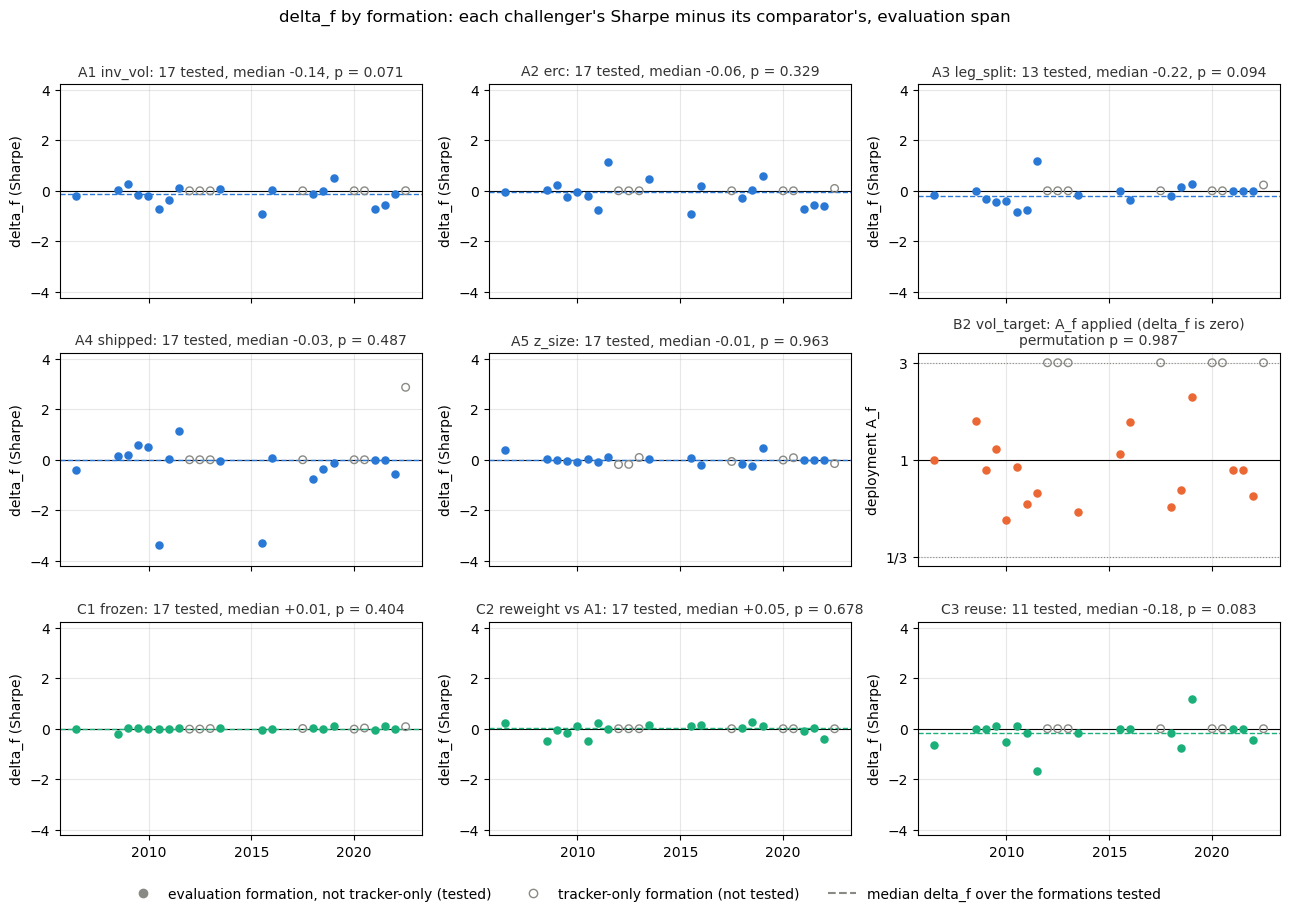

In [39]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
FAM = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a"}
INK, GRAY = "#333333", "#8a8a85"
fam = lambda nm: FAM[NAMES.loc[nm, "family"]]
title_of = lambda nm: f"{SHORT[nm]} {nm.split('_', 1)[1]}" + (f" vs {SHORT[COMPARATOR[nm]]}" if COMPARATOR[nm] != "baseline" else "")

fig, axes = plt.subplots(3, 3, figsize=(13, 9.2), sharex=True)
yl = 1.25 * np.nanmax(np.abs(DELTA_NT.drop(columns="B2_vol_target").to_numpy()))
for ax, nm in zip(axes.ravel(), TESTED):
    col = fam(nm)
    if nm == "B2_vol_target":
        A = B2["form"].loc[EVF, "A"]
        ax.axhline(1, color="k", lw=0.8)
        for b in (A_LO, A_HI):
            ax.axhline(b, color=GRAY, lw=0.8, ls=":")
        nt = A.index.isin(P["ev_nt"])
        ax.scatter(A.index[nt], A[nt], s=26, color=col, zorder=3)
        ax.scatter(A.index[~nt], A[~nt], s=30, facecolors="none", edgecolors=GRAY, zorder=3)
        ax.set_yscale("log"); ax.set_ylabel("deployment A_f")
        ax.set_yticks([A_LO, 1.0, A_HI]); ax.set_yticklabels(["1/3", "1", "3"]); ax.minorticks_off()
        ax.set_title(f"{title_of(nm)}: A_f applied (delta_f is zero)\npermutation p = {PRIMARY_P[nm]:.3f}", fontsize=10, color=INK)
    else:
        ax.axhline(0, color="k", lw=0.8)
        y_nt, y_tr = DELTA_NT[nm], DELTA_TRK[nm]
        ax.scatter(y_nt.index, y_nt.clip(-yl, yl), s=26, color=col, zorder=3)
        ax.scatter(y_tr.index, y_tr.clip(-yl, yl), s=30, facecolors="none", edgecolors=GRAY, zorder=3)
        if np.isfinite(PRIM[nm]["median"]):
            ax.axhline(PRIM[nm]["median"], color=col, lw=1, ls="--")
        ax.set_ylim(-yl, yl); ax.set_ylabel("delta_f (Sharpe)")
        ax.set_title(f"{title_of(nm)}: {PRIM[nm]['n_tested']} tested, median {PRIM[nm]['median']:+.2f}, p = {PRIM[nm]['p_wilcoxon']:.3f}",
                     fontsize=10, color=INK)
    ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.legend(handles=[Line2D([], [], marker="o", ls="", color=GRAY, label="evaluation formation, not tracker-only (tested)"),
                    Line2D([], [], marker="o", ls="", mfc="none", mec=GRAY, label="tracker-only formation (not tested)"),
                    Line2D([], [], ls="--", color=GRAY, label="median delta_f over the formations tested")],
           loc="lower center", ncol=3, frameon=False)
fig.suptitle("delta_f by formation: each challenger's Sharpe minus its comparator's, evaluation span", fontsize=12)
plt.tight_layout(rect=(0, 0.04, 1, 0.97)); plt.show()

Every panel but B2's shows dots on both sides of zero (B2's panel has no zero, since it plots the deployment $A_f$ on
a log axis). The negative dots of A1 and A3 run through 2009 and 2010, four consecutive formations for A1 from
2009-07-01 and five for A3 from 2008-12-31. The dashed medians are small for A2 (-0.057), A4 (-0.026), A5 (-0.005), C1
(+0.006) and C2 (+0.046), and negative for A1 (-0.142), A3 (-0.222) and C3 (-0.175). A4's panel is dominated by two
formations near -3.4 and -3.3 (2010-07-01 and 2015-07-01) and one near +1.1 (2011-07-01), and A2, A3 and C3 each have
one formation above +1 (2011-07-01 for A2 and A3, 2018-12-31 for C3, at +1.160). The hollow dots, the tracker-only
formations, sit on zero for the split rules and `reweight` in six of seven formations and off it only in 2022-07-01,
where four same-underlying pairs share the weights (A4 +2.868, drawn near the top of its panel; A1 and C2 are off zero
there by less than 0.005). `reuse` sits on zero in all seven, 2022-07-01 included, where it is a constant multiple of
the baseline. For A5 and C1, which change the size and not the split, they are off zero throughout and small. B2's panel shows the
deployment it applies: the seven tracker-only evaluation formations at the upper bound of 3 and the 17 tested
formations between 0.508 and 2.030, with 2008-07-01 at 1.544.

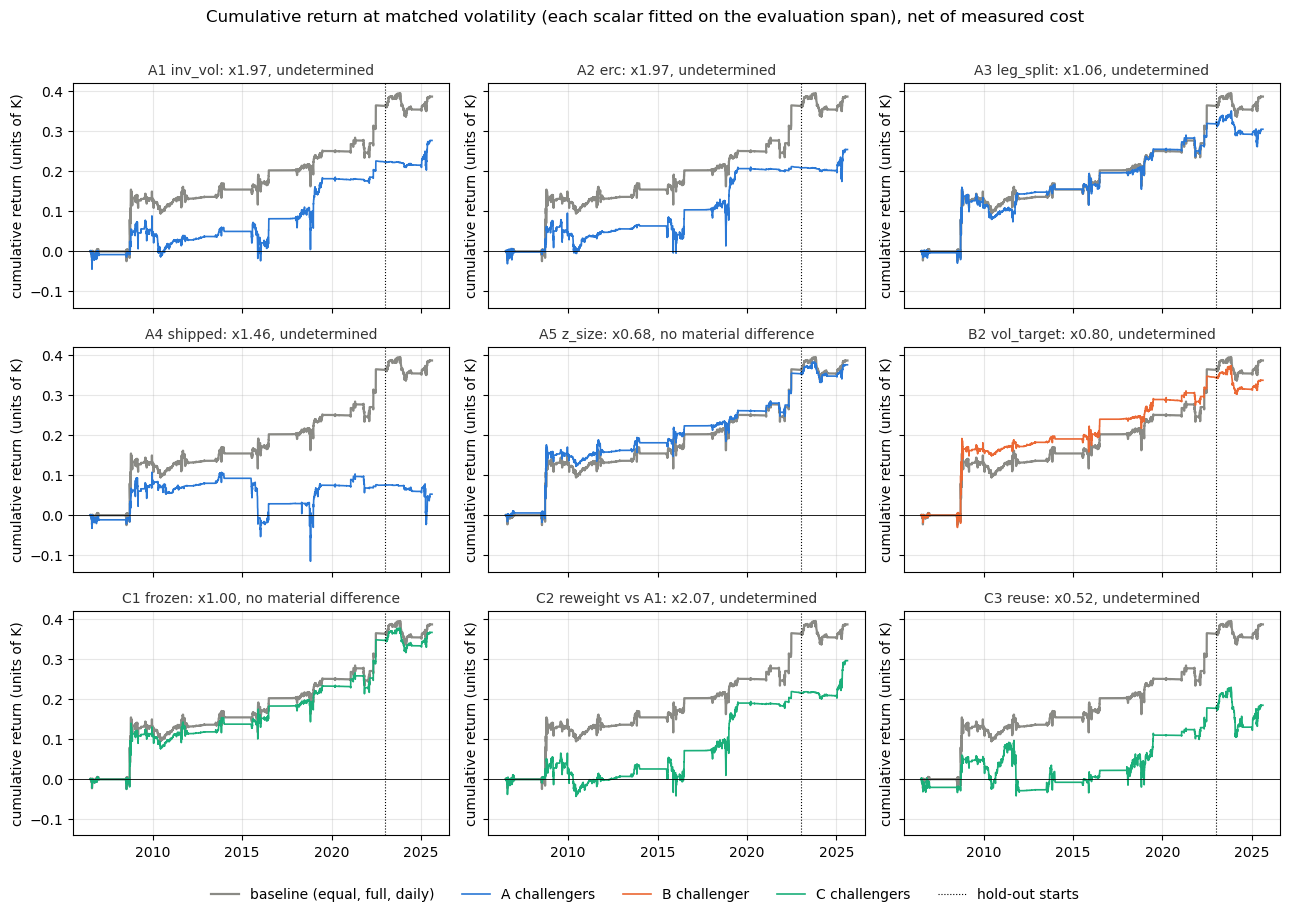

In [40]:
_scale = RF_ALL["vol scale"]
fig, axes = plt.subplots(3, 3, figsize=(13, 9.2), sharex=True, sharey=True)
_base_cum = np.cumsum(BASE["daily"]["ret_meas"].to_numpy())
for ax, nm in zip(axes.ravel(), TESTED):
    cum = np.cumsum(_scale[nm] * BOOKS[("full", nm)]["daily"]["ret_meas"].to_numpy())
    ax.plot(CAL, _base_cum, color=GRAY, lw=1.6)
    ax.plot(CAL, cum, color=fam(nm), lw=1.2)
    ax.axvline(HOLD_FIRST, color="k", lw=0.8, ls=":")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{title_of(nm)}: x{_scale[nm]:.2f}, {OUT[nm]['label']}", fontsize=10, color=INK)
    ax.set_ylabel("cumulative return (units of K)")
    ax.xaxis.set_major_locator(mdates.YearLocator(5)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.legend(handles=[Line2D([], [], color=GRAY, lw=1.6, label="baseline (equal, full, daily)"),
                    Line2D([], [], color=FAM["A"], lw=1.2, label="A challengers"), Line2D([], [], color=FAM["B"], lw=1.2, label="B challenger"),
                    Line2D([], [], color=FAM["C"], lw=1.2, label="C challengers"),
                    Line2D([], [], color="k", lw=0.8, ls=":", label="hold-out starts")],
           loc="lower center", ncol=5, frameon=False)
fig.suptitle("Cumulative return at matched volatility (each scalar fitted on the evaluation span), net of measured cost", fontsize=12)
plt.tight_layout(rect=(0, 0.04, 1, 0.97)); plt.show()

At matched volatility, with the scalars fitted on the evaluation span (x1.97 for A1, x1.97 for A2, x1.06 for A3, x1.46
for A4, x0.68 for A5, x0.80 for B2, x1.00 for C1, x2.07 for C2 and x0.52 for C3), the baseline's path rises in steps,
the largest in 2008 and in 2022. A5 and C1 stay close to the baseline's path throughout, and A3 stays close to it
through 2021 (within 0.02 of $K$ at every year end) and falls behind in 2022 and by more in the hold-out. B2 runs above
the baseline from 2008, when its deployment is 1.544, until 2022, and below it in the hold-out. C3 is already 0.020 of
$K$ below the baseline at the end of 2006, and A1, A2, A4 and C2 separate from it in 2008; none of the five closes the
gap: A4 stays far below the baseline throughout, and A1, A2 and C2 narrow the gap in the hold-out, in line with the
hold-out Sharpe ratios of 0.532, 0.421 and 0.856 against the baseline's 0.310. The paths are net of measured cost and are one
draw of history, so the figure shows where the differences came from and not whether they are stable.

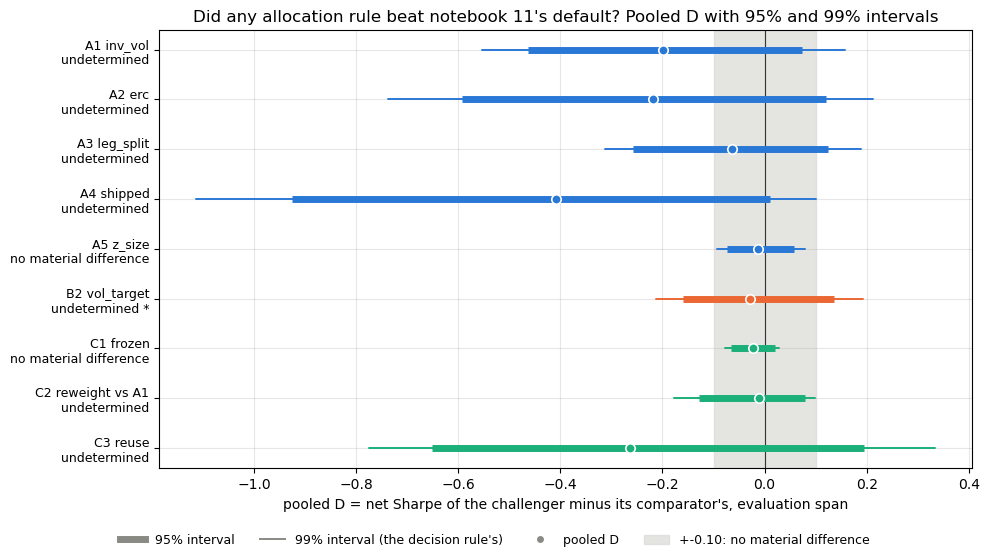

* carries a qualifier: B2: the risk model did not forecast


In [41]:
# README-FIGURE: nb22_allocation_verdict
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.axvspan(-MATERIAL, MATERIAL, color="#d9d9d4", alpha=0.7, zorder=0)
ax.axvline(0, color="k", lw=0.8, zorder=1)
ypos = np.arange(len(TESTED))[::-1]
for yi, nm in zip(ypos, TESTED):
    r, col = D8[nm], fam(nm)
    ax.plot([r["lo99"], r["hi99"]], [yi, yi], color=col, lw=1.4, solid_capstyle="round", zorder=2)
    ax.plot([r["lo95"], r["hi95"]], [yi, yi], color=col, lw=5.0, solid_capstyle="butt", zorder=3)
    ax.scatter([r["D"]], [yi], s=46, color=col, edgecolors="white", linewidths=1.2, zorder=4)
ax.set_yticks(ypos)
ax.set_yticklabels([f"{title_of(nm)}\n{OUT[nm]['label']}" + (" *" if OUT[nm]["qualifiers"] else "") for nm in TESTED], fontsize=9)
ax.set_xlabel("pooled D = net Sharpe of the challenger minus its comparator's, evaluation span")
ax.set_title("Did any allocation rule beat notebook 11's default? Pooled D with 95% and 99% intervals")
fig.legend(handles=[Line2D([], [], color=GRAY, lw=5, label="95% interval"), Line2D([], [], color=GRAY, lw=1.4, label="99% interval (the decision rule's)"),
                    Line2D([], [], marker="o", ls="", color=GRAY, mec="white", label="pooled D"),
                    plt.Rectangle((0, 0), 1, 1, color="#d9d9d4", alpha=0.7, label="+-0.10: no material difference")],
           loc="lower center", ncol=4, frameon=False, fontsize=9)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()
if any(o["qualifiers"] for o in OUT.values()):
    print("* carries a qualifier: " + "; ".join(f"{SHORT[n]}: {', '.join(o['qualifiers'])}" for n, o in OUT.items() if o["qualifiers"]))

All nine points lie to the left of zero, and every 99% line crosses zero. Only A5 and C1 have their 99% lines inside
the shaded ±0.10 band; C2's line ends at +0.099 on the right and reaches -0.177 on the left, and the other six extend
beyond the band on both sides, A4's furthest, to -1.114. (In the first run the legend sat inside the axes and covered
the right ends of the C2 and C3 rows; it is now below them, and the D table of §8 gives every interval.) The 95% bar of
A4 ends at +0.010, just above zero, that of C1 at +0.021 and that of A5 at +0.057, both inside the band, and A1's at
+0.074. B2 carries an asterisk for the qualifier that the risk model did not forecast. The figure is the verdict
table drawn to scale: what separates "no material difference" from "undetermined" is the width of the interval and not
the position of the point.

## 14. Post hoc analyses (not registered, added after the first run)

Everything above was registered. The analyses below were **not registered and were added after the first run**, after two reviews of the notebook. The first found two readings that needed more than the registered tables show, and 14.1 and 14.2 were added for them: where the split rules' capital and dollars went, and what the share in forecast 7 measures. The second recomputed the registered numbers independently from the raw prices and reproduced every count it checked, the baseline, A1 and C1 books with their tests and intervals, and all nine outcomes; it found five readings built on top of them that did not survive the other plausible reading, so 14.2 was rewritten and 14.3 to 14.6 added: the split rules' negative $D$ on one sample with the same-underlying pairs held at equal weight (14.3), what the price units cost when the helper's clip is taken apart from them (14.4), how much of each $D$ is the scale a rule puts on each formation and whether C3's is its leverage (14.5), and the 2021-12-31 formation and the base rate of a negative $D$ (14.6). They are descriptive. They change no definition, outcome or number above, they enter no decision rule, and they carry no test. Intervals are the registered cluster bootstrap (the index matrix of seed 22) unless stated; the seeds these analyses use for anything else (25 for the iid draws of 14.2, 26 for its bootstrap and for the sign-flip null of 14.5) are not registered seeds, and the one interval on another matrix, the ex-tracker pool's over its own 17 formations in 14.3, says so. They are logged in the Deviations section.

### 14.1 Where the split rules put their capital, and what each kind of pair earned

For the baseline and the four split rules on the full pool over the evaluation span: the pair-folds, dollar P&L at measured cost, measured cost, traded notional and average gross notional in a position (a multiple of $K$, over the span's live sessions), separately for the same-underlying pairs and the ordinary pairs. The two kinds sum to each book's total, and the code asserts it. Under the table, added after the second review: the same-underlying pair-folds' dollars by span, and the weight each split puts on them by kind of formation.

In [42]:
assert GATES_PASSED
# POST HOC, NOT REGISTERED (added after the first run): the evaluation-span dollars and gross notional of each split book, by pair type
_ph_ids = [i for d in EVF for i in P["by_f"][d]]
_ph_live = int((P["live"] & EV_S).sum())
_ph_rows = []
for nm in ("baseline", "A1_inv_vol", "A2_erc", "A3_leg_split", "A4_shipped"):
    bk, led = BOOKS[("full", nm)], LEDGERS[("full", nm)]
    for same_, lab in ((True, "same-underlying"), (False, "ordinary")):
        ids = [i for i in _ph_ids if FOLDS[i]["same"] == same_]
        gn = float(sum(led[i]["gross_notional"].sum() for i in ids))
        _ph_rows.append({"book": nm, "pairs": lab, "pair-folds": len(ids),
                         "P&L, measured cost ($)": float(bk["pf"].loc[ids, "pnl_meas"].sum()),
                         "cost ($)": float(bk["pf"].loc[ids, "cost_meas"].sum()),
                         "traded / K": float(bk["pf"].loc[ids, "traded"].sum() / K),
                         "gross notional / K, mean over live sessions": gn / _ph_live / K})
PH_TYPE = pd.DataFrame(_ph_rows).set_index(["book", "pairs"])
for nm in ("baseline", "A1_inv_vol", "A2_erc", "A3_leg_split", "A4_shipped"):
    g = PH_TYPE.loc[nm]
    assert np.isclose(g["P&L, measured cost ($)"].sum(), RF_EV.loc[nm, "P&L ($)"], rtol=1e-9, atol=1e-6), nm
    assert np.isclose(g["gross notional / K, mean over live sessions"].sum(), RF_EV.loc[nm, "utilization, live sessions"], rtol=1e-9), nm
    assert np.isclose(g["cost ($)"].sum(), RF_EV.loc[nm, "cost, separate ($)"], rtol=1e-9, atol=1e-6), nm
print(f"evaluation span, full pool: {_ph_live} live sessions, {len(_ph_ids)} pair-folds; the two kinds sum to each book's total (asserted)")
display(PH_TYPE.round(3))
# added after the second review: the counts and the weights behind the two readings above
_pfb = BASE["pf"]
_ev_pf = (_pfb["formation"] < EVAL_LAST).to_numpy()
for _lab, _m in (("evaluation span", _ev_pf), ("hold-out", ~_ev_pf), ("whole live span", np.ones(len(_pfb), bool))):
    _s = _pfb[_m & _pfb["same"].to_numpy()]
    print(f"baseline, {_lab}: {len(_s)} same-underlying pair-folds earned ${_s['pnl_meas'].sum():,.0f} of the ${_pfb.loc[_m, 'pnl_meas'].sum():,.0f}")
PH_WS = W_SAME[W_SAME.index.isin(EVF)]                      # evaluation formations that hold a same-underlying pair
PH_MIX = PH_WS[~PH_WS["tracker-only"]]                      # ... that mix it with ordinary pairs
_wc = ["equal", "inv_vol", "erc", "leg_split", "shipped", "inv_var_dollar"]
print(f"weight on the same-underlying pairs, evaluation span, mean by kind of formation: {len(PH_MIX)} formations mix them with ordinary pairs, "
      f"{len(PH_WS) - len(PH_MIX)} hold nothing else (where the weight is 1 under every split, equal weights included)")
display(pd.DataFrame({f"the {len(PH_MIX)} formations that mix the two kinds": PH_MIX[_wc].mean(),
                      f"all {len(PH_WS)} that hold any (the mean the registered report gives)": PH_WS[_wc].mean()}).T.round(3))

evaluation span, full pool: 3022 live sessions, 225 pair-folds; the two kinds sum to each book's total (asserted)


pair-folds  P&L, measured cost ($)  cost ($)  \
book         pairs                                                           
baseline     same-underlying          18                1181.412  2098.632   
             ordinary                207               71203.732  5463.192   
A1_inv_vol   same-underlying          18                2518.532  3662.256   
             ordinary                207               20016.851  3652.092   
A2_erc       same-underlying          18                2467.374  3917.119   
             ordinary                207               18674.525  3523.970   
A3_leg_split same-underlying          18                1116.414  2372.515   
             ordinary                207               58738.317  5333.647   
A4_shipped   same-underlying          18                2602.852  3498.051   
             ordinary                207                7637.921  3770.359   

                              traded / K  \
book         pairs                         
baseline     same-underlying      91.071   
             ordinary             87.702   
A1_inv_vol   same-underlying     137.236   
             ordinary             66.547   
A2_erc       same-underlying     146.798   
             ordinary             65.215   
A3_leg_split same-underlying     100.548   
             ordinary             86.633   
A4_shipped   same-underlying     135.629   
             ordinary             65.830   

                              gross notional / K, mean over live sessions  
book         pairs                                                         
baseline     same-underlying                                        0.048  
             ordinary                                               0.119  
A1_inv_vol   same-underlying                                        0.072  
             ordinary                                               0.092  
A2_erc       same-underlying                                        0.077  
             ordinary                                               0.086  
A3_leg_split same-underlying                                        0.052  
             ordinary                                               0.109  
A4_shipped   same-underlying                                        0.069  
             ordinary                                               0.088

baseline, evaluation span: 18 same-underlying pair-folds earned $1,181 of the $72,385
baseline, hold-out: 18 same-underlying pair-folds earned $-125 of the $4,677
baseline, whole live span: 36 same-underlying pair-folds earned $1,056 of the $77,062
weight on the same-underlying pairs, evaluation span, mean by kind of formation: 7 formations mix them with ordinary pairs, 7 hold nothing else (where the weight is 1 under every split, equal weights included)


,equal,inv_vol,erc,leg_split,shipped,inv_var_dollar
the 7 formations that mix the two kinds,0.226,0.774,0.870,0.332,0.70,0.985
all 14 that hold any (the mean the registered report gives),0.613,0.887,0.935,0.666,0.85,0.992


The same-underlying pairs earn little in every book and are expensive to trade. In the baseline the 18 same-underlying
pair-folds of the evaluation span earn \$1,181 net of measured cost (\$3,280 before it) on 0.048 of $K$ of gross
notional, and the 207 ordinary pair-folds earn \$71,204 on 0.119. (The 18 of the hold-out earn -\$125, and the 36 of the
whole live span \$1,056 of \$77,062.) Inverse volatility, ERC and `shipped` move capital onto the same-underlying pairs
(0.072, 0.077 and 0.069 of $K$) and away from the ordinary ones (0.092, 0.086 and 0.088), and the ordinary pairs'
dollars fall by far more than their notional: to \$20,017 for A1, \$18,675 for A2 and \$7,638 for A4, while the
same-underlying pairs' rise to \$2,519, \$2,467 and \$2,603. `leg_split`, which leaves the same-underlying pairs close to
where the equal split has them (0.052 against 0.048), keeps \$58,738 from the ordinary pairs.

The weights need the right denominator. Seven of the 14 evaluation formations that hold a same-underlying pair hold
nothing else, and there the weight on them is 1 under every split, equal weights included. Averaged over the seven
formations that mix the two kinds, inverse volatility, ERC and the helper put 0.774, 0.870 and 0.700 of the weight on the
same-underlying pairs against 0.226 under equal weights (0.332 for `leg_split`). The 0.887, 0.935 and 0.850 against 0.613
that the registered report and §10.4 give average in the seven tracker-only formations as well, which raises every level
and halves the contrast.

This describes where the dollars went in one sample, in dollars and not in Sharpe. It is not a test. §14.3 checks, on the
same sample, whether the same-underlying pairs are what makes the pooled $D$ of §8 negative.

### 14.2 What the share in forecast 7 measures

Forecast 7 counted the share of the 225 evaluation pair-folds in which the standard deviation of the spread return per
dollar over the whole trading window exceeded the formation-window $\sigma_i$ (20.0%). The first version of this section
compared it with what iid draws from the formation window would give and read the shortfall as concentrated in the
formation years 2010 and 2021. The second review showed that neither reading holds, and the section now measures six
things. **(1)** The share and its iid benchmark: for each pair-fold, 2,000 samples of as many draws as the trading window
has rows from the pair's own formation returns (`np.random.default_rng(25)`), and the share of them whose standard
deviation exceeds the formation value, averaged over the pair-folds; and the same on the pair-folds without the formation
years 2010 and 2021, and split by whether the two-year formation window holds a session of the 2008-09 stress
(2008-09-01 to 2009-06-30) or of the 2020 stress (2020-02-15 to 2020-06-30). **(2)** The same ratio on the rows on which
the pair is in a position, the rows that earn the book's dollars (pair-folds with at least ten such rows). **(3)** What
happened inside the formation window: the standard deviation of its last 126 rows against that of its earlier rows, and
the trading window's standard deviation against the last 126 rows. **(4)** The same ratio on each leg's own log returns.
**(5)** How the pair-folds cluster: by formation, and a cluster bootstrap over the 24 formations of the pooled share
(`np.random.default_rng(26)`). **(6)** The share by formation year and by kind of pair.

In [43]:
assert GATES_PASSED
# POST HOC, NOT REGISTERED (added after the first run, extended after the second review): what the share in forecast 7 measures
N_PH = 2000
_ph_rng = np.random.default_rng(25)                     # a seed of this analysis only, not one of the registered seeds
STRESS = [(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-06-30")), (pd.Timestamp("2020-02-15"), pd.Timestamp("2020-06-30"))]
_lr = lambda a, b: float(np.diff(np.log(np.r_[a[-1], b])).std(ddof=0) / np.diff(np.log(a)).std(ddof=0))
_ph7 = []
for i in EVP.index:                                     # the 225 evaluation pair-folds of forecast 7
    f = FOLDS[i]
    rf = f["r_form"].to_numpy()
    tr = f["r_cat"].loc[f["r_cat"].index > f["formation"]]
    held = f["pos"].reindex(tr.index).to_numpy() != 0
    sd_form = float(EVP.loc[i, "sigma"])
    assert np.isclose(sd_form, rf.std(ddof=0), rtol=1e-9), "the formation sigma is not the standard deviation of the pair's formation returns"
    draws = _ph_rng.choice(rf, size=(N_PH, len(tr)), replace=True)
    _w0, _w1 = f["r_form"].index[0], f["r_form"].index[-1]
    _ph7.append({"fold": i, "formation": f["formation"], "same": f["same"], "n_f": len(P["by_f"][f["formation"]]),
                 "rows": len(tr), "formation rows": len(rf), "rows in a position": int(held.sum()),
                 "ratio": float(tr.std(ddof=0) / sd_form),
                 "ratio, rows in a position": float(tr[held].std(ddof=0) / sd_form) if held.sum() >= 10 else np.nan,
                 "iid benchmark": float((draws.std(axis=1, ddof=0) > sd_form).mean()),
                 "excess kurtosis": float(stats.kurtosis(rf)),
                 "last 126 / earlier": float(rf[-126:].std(ddof=0) / rf[:-126].std(ddof=0)),
                 "trading / last 126": float(tr.std(ddof=0) / rf[-126:].std(ddof=0)),
                 "leg 1": _lr(f["form"]["P1"].to_numpy(), f["prices"]["P1"].to_numpy()),
                 "leg 2": _lr(f["form"]["P2"].to_numpy(), f["prices"]["P2"].to_numpy()),
                 "stress window": any(_w0 <= hi and _w1 >= lo for lo, hi in STRESS)})
PH7 = pd.DataFrame(_ph7).set_index("fold")
assert np.isclose((PH7["ratio"] > 1).mean(), EXCEEDS), "the share of forecast 7 is not reproduced"
_yr = PH7["formation"].dt.year
_cut = lambda m: (f"{int((PH7.loc[m, 'ratio'] > 1).sum())} of {int(m.sum())} = {(PH7.loc[m, 'ratio'] > 1).mean():.1%} "
                  f"(median ratio {PH7.loc[m, 'ratio'].median():.3f}; iid benchmark {PH7.loc[m, 'iid benchmark'].mean():.1%})")
print(f"1. forecast 7's share, realized > forecast over all trading rows: {_cut(PH7['ratio'] > 0)}")
print(f"   the iid benchmark is the mean over the pair-folds of the share of {N_PH} samples of as many draws as the trading window has rows, from the pair's own "
      f"formation returns, whose standard deviation exceeds the formation value; median excess kurtosis {PH7['excess kurtosis'].median():.1f}; "
      f"median trading rows {int(PH7['rows'].median())}")
print(f"   without the formation years 2010 and 2021: {_cut(~_yr.isin([2010, 2021]))}")
print(f"   formation window holds a session of 2008-09-01 to 2009-06-30 or of 2020-02-15 to 2020-06-30: {_cut(PH7['stress window'])}")
print(f"   ... and does not: {_cut(~PH7['stress window'])}")
_have = PH7["ratio, rows in a position"].notna()
print(f"2. the same ratio on the rows in a position, {int(_have.sum())} pair-folds with at least ten such rows: share above one "
      f"{(PH7.loc[_have, 'ratio, rows in a position'] > 1).mean():.1%}, median ratio {PH7.loc[_have, 'ratio, rows in a position'].median():.3f} "
      f"(all rows, same pair-folds: {(PH7.loc[_have, 'ratio'] > 1).mean():.1%}, {PH7.loc[_have, 'ratio'].median():.3f})")
_gf = PH7.groupby("formation").agg(n=("ratio", "size"), n_f=("n_f", "first"), above=("ratio", lambda x: int((x > 1).sum())),
                                   med=("ratio", "median"), late=("last 126 / earlier", "median"), stress=("stress window", "first"))
print(f"3. inside the formation window ({int(PH7['formation rows'].min())} to {int(PH7['formation rows'].max())} rows), the standard deviation of the last 126 rows against that of the earlier rows of the window:")
print(f"   below one in {(PH7['last 126 / earlier'] < 1).mean():.1%} of the pair-folds (median ratio {PH7['last 126 / earlier'].median():.3f}), "
      f"and in {int((_gf['late'] < 1).sum())} of {len(_gf)} formations at the median; without the stress windows: "
      f"{(PH7.loc[~PH7['stress window'], 'last 126 / earlier'] < 1).mean():.1%} of {int((~PH7['stress window']).sum())} pair-folds "
      f"(median {PH7.loc[~PH7['stress window'], 'last 126 / earlier'].median():.3f}); among the {int((_gf['n_f'] >= 19).sum())} formations of 19 or 20 pairs "
      f"{int((_gf.loc[_gf['n_f'] >= 19, 'late'] < 1).sum())} have a median below one")
print(f"   the trading window against the last 126 formation rows: above one in {(PH7['trading / last 126'] > 1).mean():.1%} (median {PH7['trading / last 126'].median():.3f})")
print(f"4. the legs alone (log-return standard deviation, trading window over formation window): leg 1 above one in {(PH7['leg 1'] > 1).mean():.1%} "
      f"(median {PH7['leg 1'].median():.3f}), leg 2 in {(PH7['leg 2'] > 1).mean():.1%} (median {PH7['leg 2'].median():.3f})")
_big = _gf["n_f"] >= 19
print(f"5. the pair-folds are not independent draws: {int(_gf.loc[_big, 'n'].sum())} of the {len(PH7)} sit in the {int(_big.sum())} formations of 19 or 20 pairs, "
      f"{int(_gf.loc[_big, 'above'].sum())} above one ({_gf.loc[_big, 'above'].sum() / _gf.loc[_big, 'n'].sum():.1%}); the other {int((~_big).sum())} formations give "
      f"{int(_gf.loc[~_big, 'above'].sum())} of {int(_gf.loc[~_big, 'n'].sum())} ({_gf.loc[~_big, 'above'].sum() / _gf.loc[~_big, 'n'].sum():.1%}); "
      f"the median ratio is above one in {int((_gf['med'] > 1).sum())} of {len(_gf)} formations")
_rb = np.random.default_rng(26)                          # a seed of this analysis only
_ix = _rb.integers(0, len(_gf), size=(10000, len(_gf)))
_shb = _gf["above"].to_numpy()[_ix].sum(1) / _gf["n"].to_numpy()[_ix].sum(1)
print(f"   cluster bootstrap over the {len(_gf)} formations (10,000 draws): the pooled share has a 95% range of {np.percentile(_shb, 2.5):.3f} to "
      f"{np.percentile(_shb, 97.5):.3f}, and {(_shb > 0.60).mean():.1%} of the draws are above 0.60")
PH7["formation year"] = _yr
_by = PH7.groupby("formation year").agg(**{"pair-folds": ("ratio", "size"), "share above forecast": ("ratio", lambda x: float((x > 1).mean())),
                                           "median ratio": ("ratio", "median"), "iid benchmark": ("iid benchmark", "mean")})
print("6. by the year of the formation date (the formation window is the two years before it, the trading window the six months after):")
display(_by.round(3))
print(f"   not same-underlying: {(PH7.loc[~PH7['same'], 'ratio'] > 1).mean():.1%} of {int((~PH7['same']).sum())}; "
      f"same-underlying: {(PH7.loc[PH7['same'], 'ratio'] > 1).mean():.1%} of {int(PH7['same'].sum())}")

1. forecast 7's share, realized > forecast over all trading rows: 45 of 225 = 20.0% (median ratio 0.790; iid benchmark 42.0%)
   the iid benchmark is the mean over the pair-folds of the share of 2000 samples of as many draws as the trading window has rows, from the pair's own formation returns, whose standard deviation exceeds the formation value; median excess kurtosis 8.1; median trading rows 126
   without the formation years 2010 and 2021: 45 of 163 = 27.6% (median ratio 0.838; iid benchmark 41.0%)
   formation window holds a session of 2008-09-01 to 2009-06-30 or of 2020-02-15 to 2020-06-30: 5 of 87 = 5.7% (median ratio 0.564; iid benchmark 44.3%)
   ... and does not: 40 of 138 = 29.0% (median ratio 0.855; iid benchmark 40.5%)
2. the same ratio on the rows in a position, 196 pair-folds with at least ten such rows: share above one 24.0%, median ratio 0.733 (all rows, same pair-folds: 20.9%, 0.802)
3. inside the formation window (500 to 505 rows), the standard deviation of the last 

,pair-folds,share above forecast,median ratio,iid benchmark
formation year,,,,
2006,20,0.150,0.829,0.384
2008,8,0.750,1.500,0.438
2009,17,0.118,0.534,0.441
2010,40,0.000,0.503,0.446
2011,21,0.524,1.002,0.412
2012,2,0.500,1.000,0.463
2013,20,0.050,0.671,0.434
2015,7,0.571,1.022,0.378
2017,21,0.048,0.682,0.428


   not same-underlying: 17.4% of 207; same-underlying: 50.0% of 18


The pooled share is far below the forecast's 60% however it is cut below (without 2010 and 2021, inside and outside the
stress windows, on the rows in a position, by formation), although a few small formation years (2008, 2019 and 2022) are
above it, and the two readings the first version of this section gave do not hold.

**The 42.0% is the wrong yardstick.** It is what iid draws from the formation window would give, and it assumes the
window is one stable distribution. Inside the window it is not: the standard deviation of the last 126 rows is below that
of the earlier rows in 87.1% of the pair-folds (median ratio 0.652), in 85.5% of the 138 whose window holds neither
stress period (median 0.729), and in 17 of the 24 formations at the median, including all nine of 19 or 20 pairs.
Volatility had already fallen by the end of the window, so its two-year standard deviation was a stale level. Against
the last 126 rows the trading window realized more in 56.9% of the pair-folds (median ratio 1.033), and the legs alone
show the same pattern (the trading window's log-return standard deviation is above the formation window's for leg 1 in
22.7% and for leg 2 in 38.2%, medians 0.786 and 0.849), so it is not an artifact of how the spread is built. An iid
benchmark ignores that decay. (The median excess kurtosis of the formation returns is 8.1, and a standard deviation over
about 126 draws from a fat-tailed distribution falls below the full-window value more often than above it, which is why
the iid benchmark is 42% and not 50%.)

**The shortfall is not concentrated in 2010 and 2021.** Without the formation years 2010 and 2021 (62 pair-folds, none
above one) the share is 27.6% of 163 pair-folds against an iid benchmark of 41.0%. The 87 pair-folds whose formation
window holds a session of either stress period have 5.7% above one against 44.3% for the benchmark, and the 138 whose
window holds neither have 29.0% against 40.5%: 40 above one of 138, still far below 60%. The share does move with the
formation date. It is 0.0% for the 40 pair-folds formed in 2010 and for the 22 formed in 2021, 5.0% and 4.8% for those
formed in 2013 and 2017, and 75.0% for the eight formed in 2008, which traded through the crisis and realized more
(median ratio 1.500); the table above has the rest. That describes a pattern and is not a test of a cause.

**The pair-folds are not independent draws.** 179 of the 225 sit in the nine formations of 19 or 20 pairs, and 26 of them
are above one (14.5%); the other 15 formations give 19 of 46 (41.3%), and the median ratio is above one in 8 of the 24
formations. A cluster bootstrap over the 24 formations puts the pooled share at 0.098 to 0.333 (95%), and none of the
10,000 draws reaches 0.60, so forecast 7 fails by pair-fold, by formation and under the cluster bootstrap.

**Two more facts.** The share does not rise when the rows are restricted to those on which the pair is in a position:
the median ratio there is 0.733 and the share above one is 24.0% (196 pair-folds with at least ten such rows; 20.9% on
all rows for the same pair-folds). The same-underlying pairs are the exception (50.0% of 18 against 17.4% of the other
207).

What this sample cannot tell is why volatility had decayed inside so many windows: the screen selecting formation windows
whose volatility had burst and then settled, or the market's own volatility regime at 24 dates. Forecast 7 therefore
failed on the level of the forecast against what followed, which a two-year window sets by its own history, and not on
the ordering of the pairs, which §6 tests and finds at 0.886.

### 14.3 Are the split rules' negative estimates the same-underlying pairs? The same sample

§8 and the ex-tracker re-run answer this on two different samples (24 formations and 3,022 sessions against 17 and
2,142). This cell answers it on one. Each split rule is re-run on the full pool with every same-underlying pair held at
$1/n_f$ (the equal split's weight) and the rule applied among the ordinary pairs only: their weights are the ex-tracker
pool's own (its $\sigma_i$, $\Sigma_f$ and split, built without the same-underlying pairs), scaled by the ordinary pairs'
share of $n_f$. The positions, the 24 evaluation formations, the 3,022 live sessions and the registered bootstrap are
those of §8, so pooled $D$ against the baseline is comparable with the registered one. A book is a static split under the
daily reset, so it is the unit run of §5.7 scaled by the weights, as in §9, and the cell asserts that this route
reproduces the baseline and the four split books. Three more tables follow: the ex-tracker pool's $D$ with an interval
over its own 17 formations (a 17-column index matrix from the same seed, not the registered matrix), the full pool's $D$
on those same 17 formations, and the two formations that carry the baseline's dollars.

In [44]:
assert GATES_PASSED
# POST HOC, NOT REGISTERED (added after the second review): the split rules with the same-underlying pairs held at 1/n_f, on the same sample
def pbook(w, pool="full"):
    # a pseudo-book (daily ret_meas and live) for a static split at full deployment under the daily reset: the unit run of section 5.7
    # scaled by the weights, which is how the Dirichlet draws of section 9 are run. suff() and eval_D() read it like a book.
    sc = scaled_book(pool, w, {d: 1.0 for d in FORMATIONS})
    return {"daily": pd.DataFrame({"ret_meas": (sc["gross"] - sc["cost_meas"]) / K, "live": POOLS[pool]["live"]}, index=CAL)}

for _nm, _sp in (("baseline", "equal"), ("A1_inv_vol", "inv_vol"), ("A2_erc", "erc"), ("A3_leg_split", "leg_split"), ("A4_shipped", "shipped")):
    assert np.allclose(pbook(WEIGHTS["full"][_sp])["daily"]["ret_meas"].to_numpy(), BOOKS[("full", _nm)]["daily"]["ret_meas"].to_numpy(),
                       rtol=0, atol=1e-12), f"the scaled unit run does not reproduce {_nm}"

def tracker_neutral(rule):
    # each same-underlying pair keeps 1 / n_f; the ordinary pairs share the rest by the rule, using the weights of the ex-tracker pool
    # (its own sigma, covariance and split, built without the same-underlying pairs), scaled by their share of n_f
    w = pd.Series(np.nan, index=POOLS["full"]["ids"], dtype=float)
    for d, ids in POOLS["full"]["by_f"].items():
        if not ids:
            continue
        ordi = [i for i in ids if not FOLDS[i]["same"]]
        for i in ids:
            if FOLDS[i]["same"]:
                w[i] = 1.0 / len(ids)
        if ordi:
            wx = WEIGHTS["extracker"][rule].loc[ordi]
            assert abs(float(wx.sum()) - 1.0) < 1e-9
            w.loc[ordi] = wx.to_numpy() * len(ordi) / len(ids)
    assert w.notna().all() and (w > 0).all()
    assert np.allclose(w.groupby([FOLDS[i]["formation"] for i in w.index]).sum().to_numpy(), 1.0, rtol=0, atol=1e-12), "weights do not sum to one"
    return w

# the ex-tracker pool's own interval: its 17 formations, resampled with the seed of the registered bootstrap and a 17-column index matrix
PH_NT = list(P["ev_nt"])
_ix17 = np.random.default_rng(SEED_BOOT).integers(0, len(PH_NT), size=(N_BOOT, len(PH_NT)))
_c17 = (_ix17[:, :, None] == np.arange(len(PH_NT))[None, None, :]).sum(axis=1).astype(float)

def ext_D(nm):
    sc, sp = suff(BOOKS[("extracker", nm)], "eval"), suff(BOOKS[("extracker", COMPARATOR[nm])], "eval")
    assert list(sc.index) == PH_NT, "the ex-tracker pool's evaluation formations are the full pool's 17 that are not tracker-only"
    n, c1, c2, p1, p2 = (sc["n"].to_numpy(), sc["s1"].to_numpy(), sc["s2"].to_numpy(), sp["s1"].to_numpy(), sp["s2"].to_numpy())
    Nb = _c17 @ n
    Db = sr_from(Nb, _c17 @ c1, _c17 @ c2) - sr_from(Nb, _c17 @ p1, _c17 @ p2)
    return np.nanpercentile(Db, [0.5, 99.5])

PH_CF = {}
_rows = {}
for _nm, _rule in (("A1_inv_vol", "inv_vol"), ("A2_erc", "erc"), ("A3_leg_split", "leg_split"), ("A4_shipped", "shipped")):
    r = eval_D(pbook(tracker_neutral(_rule)), BASE)
    PH_CF[_nm] = r
    row = {"D, full pool (registered)": round(float(D8[_nm]["D"]), 3), "D, same-underlying pairs at 1/n_f": round(float(r["D"]), 3),
           "95% interval": f"[{r['lo95']:+.3f}, {r['hi95']:+.3f}]", "99% interval": f"[{r['lo99']:+.3f}, {r['hi99']:+.3f}]",
           "share of the deficit removed": round(float((D8[_nm]["D"] - r["D"]) / D8[_nm]["D"]), 3)}
    if "D_ext" in D8[_nm]:
        lo, hi = ext_D(_nm)
        row.update({"D, ex-tracker pool (registered)": round(float(D8[_nm]["D_ext"]), 3), "99% interval, 17 formations": f"[{lo:+.3f}, {hi:+.3f}]"})
    else:
        row.update({"D, ex-tracker pool (registered)": "not re-run", "99% interval, 17 formations": "-"})
    _rows[f"{SHORT[_nm]} {_nm}"] = row
PH_CFTAB = pd.DataFrame(_rows).T
print(f"the split rules with each same-underlying pair held at 1/n_f and the rule applied among the ordinary pairs only: pooled D on the same "
      f"{N_EV} evaluation formations and {int((P['live'] & EV_S).sum()):,} live sessions as section 8 (the registered bootstrap index matrix)")
display(PH_CFTAB)

# like for like: the ex-tracker pool's values are on 17 formations, and the full pool's on 24
def _pooled_on(book, forms):
    s = suff(book, "eval").loc[forms].sum()
    return float(sr_from(s["n"], s["s1"], s["s2"]))
_rows = {}
for _nm in ("A1_inv_vol", "A2_erc", "A4_shipped", "B2_vol_target", "C2_reweight"):
    _c = COMPARATOR[_nm]
    _rows[f"{SHORT[_nm]} {_nm}"] = {"D, full pool, all 24 formations": D8[_nm]["D"],
                                    "D, full pool, the 17 formations": _pooled_on(BOOKS[("full", _nm)], PH_NT) - _pooled_on(BOOKS[("full", _c)], PH_NT),
                                    "D, ex-tracker pool, the 17 formations": D8[_nm]["D_ext"]}
display(pd.DataFrame(_rows).T.round(3))
_n17 = int(suff(BASE, "eval").loc[PH_NT, "n"].sum())
print(f"baseline pooled net Sharpe: full pool, 24 formations {pooled_sr(BASE, 'eval'):.3f} ({int(suff(BASE, 'eval')['n'].sum()):,} sessions); "
      f"full pool, the 17 formations {_pooled_on(BASE, PH_NT):.3f} ({_n17:,} sessions); ex-tracker pool, the same 17 formations "
      f"{pooled_sr(BOOKS[('extracker', 'baseline')], 'eval'):.3f} ({int(suff(BOOKS[('extracker', 'baseline')], 'eval')['n'].sum()):,} sessions)")
assert _n17 == int(suff(BOOKS[("extracker", "baseline")], "eval")["n"].sum())

# the two formations that carry the baseline's dollars
_sdv = lambda s: float(np.sqrt(s["s2"] / s["n"] - (s["s1"] / s["n"]) ** 2))
_SB = suff(BASE, "eval")
_rows = []
for _nm in ("baseline", "A1_inv_vol", "A2_erc", "A4_shipped"):
    _bk = BOOKS[("full", _nm)]
    _sc, _sr = suff(_bk, "eval"), form_sr(_bk)
    for _d in (D08, D21):
        if _d in P["by_f"] and P["by_f"][_d]:
            _ids = P["by_f"][_d]
            _rows.append({"book": _nm, "formation": _d.date().isoformat(),
                          "weight on the ordinary pairs": float(_bk["pf"].loc[[i for i in _ids if not FOLDS[i]["same"]], "w"].sum()),
                          "P&L ($)": float(_bk["pf"].loc[_ids, "pnl_meas"].sum()), "SR_f": float(_sr[_d]),
                          "s.d. of daily return / the baseline's": _sdv(_sc.loc[_d]) / _sdv(_SB.loc[_d])})
PH_TWO = pd.DataFrame(_rows).set_index(["formation", "book"])
print("the two formations that carry most of the baseline's dollars (2008-07-01: BAC/CNX beside IVV/SPY; 2021-12-31: 18 BDX pairs beside SPY/VOO and IVV/VOO)")
display(PH_TWO.round(3))

the split rules with each same-underlying pair held at 1/n_f and the rule applied among the ordinary pairs only: pooled D on the same 24 evaluation formations and 3,022 live sessions as section 8 (the registered bootstrap index matrix)


,"D, full pool (registered)","D, same-underlying pairs at 1/n_f",95% interval,99% interval,share of the deficit removed,"D, ex-tracker pool (registered)","99% interval, 17 formations"
A1 A1_inv_vol,-0.199,-0.022,"[-0.147, +0.074]","[-0.198, +0.108]",0.888,-0.031,"[-0.223, +0.112]"
A2 A2_erc,-0.219,0.028,"[-0.118, +0.190]","[-0.167, +0.258]",1.126,0.014,"[-0.190, +0.288]"
A3 A3_leg_split,-0.064,0.004,"[-0.137, +0.169]","[-0.188, +0.236]",1.066,not re-run,-
A4 A4_shipped,-0.408,-0.121,"[-0.490, +0.145]","[-0.653, +0.243]",0.702,-0.107,"[-0.686, +0.245]"


,"D, full pool, all 24 formations","D, full pool, the 17 formations","D, ex-tracker pool, the 17 formations"
A1 A1_inv_vol,-0.199,-0.239,-0.031
A2 A2_erc,-0.219,-0.263,0.014
A4 A4_shipped,-0.408,-0.488,-0.107
B2 B2_vol_target,-0.028,-0.036,0.016
C2 C2_reweight,-0.010,-0.012,-0.034


baseline pooled net Sharpe: full pool, 24 formations 0.514 (3,022 sessions); full pool, the 17 formations 0.608 (2,142 sessions); ex-tracker pool, the same 17 formations 0.561 (2,142 sessions)
the two formations that carry most of the baseline's dollars (2008-07-01: BAC/CNX beside IVV/SPY; 2021-12-31: 18 BDX pairs beside SPY/VOO and IVV/VOO)


,,weight on the ordinary pairs,P&L ($),SR_f,s.d. of daily return / the baseline's
formation,book,,,,
2008-07-01,baseline,0.667,26695.430,1.375,1.000
2021-12-31,baseline,0.900,23584.163,2.843,1.000
2008-07-01,A1_inv_vol,0.110,5882.090,1.407,0.215
2021-12-31,A1_inv_vol,0.201,5057.527,2.735,0.223
2008-07-01,A2_erc,0.110,5882.090,1.407,0.215
2021-12-31,A2_erc,0.052,1078.206,2.222,0.058
2008-07-01,A4_shipped,0.149,10126.218,1.531,0.341
2021-12-31,A4_shipped,0.052,1108.563,2.282,0.059


With the same-underlying pairs held at equal weight, on the same 24 formations and 3,022 sessions, pooled $D$ is -0.022
for A1 (99% [-0.198, +0.108]), +0.028 for A2 ([-0.167, +0.258]), +0.004 for A3 ([-0.188, +0.236]) and -0.121 for A4
([-0.653, +0.243]), against the registered -0.199, -0.219, -0.064 and -0.408. The same-underlying pairs therefore account
for 0.888 of A1's deficit, more than all of A2's (1.126) and A3's (1.066), and 0.702 of A4's. Their intervals include zero and
reach beyond $\pm 0.10$, so what the sample supports is that among ordinary pairs inverse volatility, ERC and the
shared-leg split are indistinguishable from equal weights, and not that they equal it. The registered ex-tracker re-run reads the same way on 17 formations (A1 -0.031, 99% [-0.223, +0.112]; A2
+0.014, [-0.190, +0.288]; A4 -0.107, [-0.686, +0.245]). The helper is the exception in size: 0.702 of its deficit goes, but
its point estimate stays at -0.107 to -0.121 once the same-underlying pairs are neutralized, the largest of the four,
whatever the registered sign rule says of it (§11), and its interval includes zero too.

**Like for like.** The ex-tracker values in §8 and §11 sit beside full-pool values on different sessions, and a baseline
Sharpe of 0.561 set beside 0.514 reads as if removing the same-underlying pairs raised it. On the 17 formations the two
pools share, the full pool's baseline is 0.608 with the same-underlying pairs and 0.561 without: removing them lowers it.
The full pool's $D$ on those 17 formations is -0.239 (A1), -0.263 (A2), -0.488 (A4), -0.036 (B2) and -0.012 (C2), against
-0.031, +0.014, -0.107, +0.016 and -0.034 on the ex-tracker pool.

**The mechanism, in the two formations that carry the baseline's dollars.** 2008-07-01 and 2021-12-31 carry 0.369 and
0.326 of the baseline's evaluation-span P&L (§10.3). There inverse volatility gives the same-underlying pairs most of the
weight and so cuts the ordinary pairs, the ones that earn the dollars, from 0.667 to 0.110 of $K$ in 2008-07-01 and from
0.900 to 0.201 in 2021-12-31, and the formation's Sharpe hardly moves (1.375 to 1.407 and 2.843 to 2.735) while its
volatility falls to 0.215 and 0.223 of the baseline's: the same skill on about a fifth of the dollars. ERC does the same in
2008-07-01, where its correlation matrix is the identity and it equals inverse volatility, and cuts the ordinary pairs of
2021-12-31 to 0.052 of $K$, at 0.058 of the baseline's volatility, and there the formation's Sharpe falls too (2.222). The
helper leaves 0.149 and 0.052 (volatility 0.341 and 0.059 of the baseline's; formation Sharpe 1.531 and 2.282). §14.5
puts a number on how much of each $D$ is that scale.

### 14.4 What the price units cost, with the helper's clip taken apart from them

The pre-registration calls the gap between `shipped` and `inv_var_dollar` "what the price units cost". `shipped` does two
things to the weights that `inv_var_dollar` does not: it weights by the variance of the residual's first difference in
price units, and it clips at 0.40 and renormalizes once. This cell runs the two by three, on the full pool at full
deployment: weights on price units or on risk per dollar, each with no clip, the one-pass clip of the helper as shipped,
and a real 0.40 cap (water-filling: clip, redistribute the excess over the pairs still under the cap, repeat; with one or
two pairs no cap can hold, and the split is equal). The price-unit weights before the clip are the `inv_var_weight` column
of the helper as shipped on 2026-09-30 (a call with `risk="price_units"`; under the default `risk="per_dollar"` that column
is per dollar), and the cell asserts that one clip of them is the shipped split and that the risk-per-dollar column without
a clip is the registered diagnostic book. Gaps use the registered bootstrap. None is in the test family.

In [45]:
assert GATES_PASSED
# POST HOC, NOT REGISTERED (added after the second review): what the price units cost, with the clip separated from them
PH_IDS = POOLS["full"]["by_f"]
def _by_formation(w, fn):
    o = pd.Series(np.nan, index=w.index, dtype=float)
    for d, ids in PH_IDS.items():
        if ids:
            o.loc[ids] = fn(w.loc[ids].to_numpy())
    return o

def clip_once(v, cap=SHIPPED_CAP):                    # the shipped helper's rule (cap="one_pass"): clip at the cap, renormalize once
    c = np.clip(v, 0.0, cap)
    return c / c.sum()

def real_cap(v, cap=SHIPPED_CAP):                     # a cap that holds: water-filling; with n_f * cap < 1 no cap can hold and the split is equal
    w = np.array(v, float)
    if len(w) * cap < 1.0:
        return np.full(len(w), 1.0 / len(w))
    for _ in range(100):
        over = w > cap + 1e-15
        if not over.any():
            break
        w[over] = cap
        free = ~(w >= cap - 1e-15)
        w[free] *= (1.0 - cap * (~free).sum()) / w[free].sum()
    return w

# the shipped helper's unclipped price-unit weights (its inv_var_weight column under risk="price_units"), through the same call as A4
PH_PU = pd.Series(np.nan, index=POOLS["full"]["ids"], dtype=float)
for d, ids in PH_IDS.items():
    if not ids:
        continue
    kf, labels = {}, []
    for i in ids:
        f = FOLDS[i]
        kf[f["pair"]] = pd.DataFrame({"resid": f["form"]["P1"] - f["alpha"] - f["beta"] * f["form"]["P2"]})
        labels.append(f"{f['pair'][0]}/{f['pair'][1]}")
    out = suggest_position_weights(kf, pair_return_correlations(kf), method="inv_var", max_weight=SHIPPED_CAP,
                                   risk="price_units", cap="one_pass")
    m = dict(zip(out["pair"], out["inv_var_weight"]))
    PH_PU.loc[ids] = [m[l] for l in labels]
assert np.allclose(_by_formation(PH_PU, clip_once).to_numpy(), WEIGHTS["full"]["shipped"].to_numpy(), rtol=0, atol=1e-12), \
    "one clip of the price-unit weights is not the shipped split"
PH_PD = WEIGHTS["full"]["inv_var_dollar"]
PH_V = {("price units", "no clip"): PH_PU, ("price units", "one-pass clip (the helper, A4)"): _by_formation(PH_PU, clip_once),
        ("price units", "real 0.40 cap"): _by_formation(PH_PU, real_cap),
        ("risk per dollar", "no clip (the diagnostic)"): PH_PD, ("risk per dollar", "one-pass clip"): _by_formation(PH_PD, clip_once),
        ("risk per dollar", "real 0.40 cap"): _by_formation(PH_PD, real_cap)}
PH_B = {k: pbook(w) for k, w in PH_V.items()}
assert np.allclose(PH_B[("risk per dollar", "no clip (the diagnostic)")]["daily"]["ret_meas"].to_numpy(),
                   BOOKS[("full", "diag_inv_var_dollar")]["daily"]["ret_meas"].to_numpy(), rtol=0, atol=1e-12)
_bs = pooled_sr(BASE, "eval")
PH_UNITS = pd.DataFrame({" / ".join(k): {"pooled net Sharpe": pooled_sr(b, "eval"), "D against the baseline": pooled_sr(b, "eval") - _bs,
                                         "effective number of pairs": float(np.mean([1 / (PH_V[k].loc[PH_IDS[d]] ** 2).sum() for d in EVF]))}
                         for k, b in PH_B.items()}).T
print("pooled net Sharpe on the evaluation span of the price-unit split (the helper's weights before its clip), the helper's, and the split on risk per dollar, each with no clip, "
      "the helper's one-pass clip and a real 0.40 cap")
display(PH_UNITS.round(3))
def _gap(a, b, lab):
    r = eval_D(PH_B[a], PH_B[b])
    print(f"  {lab:<66s} D {r['D']:+.3f}   95% [{r['lo95']:+.3f}, {r['hi95']:+.3f}]   99% [{r['lo99']:+.3f}, {r['hi99']:+.3f}]")
    return r
print("gaps, on the registered bootstrap index matrix (outside the test family):")
_g_reg = _gap(("price units", "one-pass clip (the helper, A4)"), ("risk per dollar", "no clip (the diagnostic)"), "registered diagnostic: A4 minus inv_var_dollar (section 8)")
assert abs(_g_reg["D"] - PRICE_UNITS["D"]) < 1e-12
_gap(("price units", "no clip"), ("risk per dollar", "no clip (the diagnostic)"), "price units alone, no clip on either side")
_gap(("price units", "one-pass clip (the helper, A4)"), ("risk per dollar", "one-pass clip"), "price units alone, the one-pass clip on both sides")
_gap(("price units", "one-pass clip (the helper, A4)"), ("price units", "no clip"), "the one-pass clip alone, on price units")
_gap(("price units", "real 0.40 cap"), ("price units", "one-pass clip (the helper, A4)"), "a real 0.40 cap against the one-pass clip, on price units")
_ev_multi = [d for d in EVF if len(PH_IDS[d]) >= 2]
_binds = [d for d in _ev_multi if (PH_PU.loc[PH_IDS[d]] > SHIPPED_CAP + 1e-12).any()]
_over = [d for d in _ev_multi if (WEIGHTS["full"]["shipped"].loc[PH_IDS[d]] > SHIPPED_CAP + 1e-12).any()]
_binds_pd = [d for d in _ev_multi if (PH_PD.loc[PH_IDS[d]] > SHIPPED_CAP + 1e-12).any()]
print(f"the clip binds (an unclipped price-unit weight above 0.40) in {len(_binds)} of the {len(_ev_multi)} evaluation formations with two or more pairs, and the "
      f"shipped weight is still above 0.40 after the renormalization in {len(_over)}; the same clip would bind on risk per dollar in {len(_binds_pd)}")
_tv, _top = [], 0
for d in _ev_multi:
    a, b = WEIGHTS["full"]["shipped"].loc[PH_IDS[d]].to_numpy(), PH_PD.loc[PH_IDS[d]].to_numpy()
    _tv.append(0.5 * np.abs(a - b).sum())
    _top += int(a.argmax() != b.argmax())
print(f"how far apart the two weight vectors are, shipped against inv_var_dollar: median total-variation distance {np.median(_tv):.3f} (mean {np.mean(_tv):.3f}), "
      f"a different top pair in {_top} of {len(_ev_multi)} formations, daily-return correlation on the evaluation sessions "
      f"{np.corrcoef(PH_B[('price units', 'one-pass clip (the helper, A4)')]['daily']['ret_meas'].to_numpy()[EV_S & P['live']], PH_B[('risk per dollar', 'no clip (the diagnostic)')]['daily']['ret_meas'].to_numpy()[EV_S & P['live']])[0, 1]:.3f}")
_d17 = pd.Timestamp("2017-12-29")
if _d17 in PH_IDS and PH_IDS[_d17]:
    _ids = PH_IDS[_d17]
    _j = int(np.argmax(WEIGHTS["full"]["shipped"].loc[_ids].to_numpy()))
    print(f"for example {_d17.date()}: the helper puts {WEIGHTS['full']['shipped'].loc[_ids].iloc[_j]:.3f} on {PAIRTAB['full'].loc[_ids, 'pair'].iloc[_j]} and inv_var_dollar "
          f"{PH_PD.loc[_ids].iloc[_j]:.3f}")

pooled net Sharpe on the evaluation span of the price-unit split (the helper's weights before its clip), the helper's, and the split on risk per dollar, each with no clip, the helper's one-pass clip and a real 0.40 cap


,pooled net Sharpe,D against the baseline,effective number of pairs
price units / no clip,0.010,-0.504,2.623
"price units / one-pass clip (the helper, A4)",0.106,-0.408,2.826
price units / real 0.40 cap,0.353,-0.161,3.579
risk per dollar / no clip (the diagnostic),0.115,-0.399,4.319
risk per dollar / one-pass clip,0.133,-0.380,4.340
risk per dollar / real 0.40 cap,0.305,-0.209,5.005


gaps, on the registered bootstrap index matrix (outside the test family):
  registered diagnostic: A4 minus inv_var_dollar (section 8)         D -0.009   95% [-0.301, +0.327]   99% [-0.399, +0.452]


  price units alone, no clip on either side                          D -0.105   95% [-0.397, +0.228]   99% [-0.519, +0.349]
  price units alone, the one-pass clip on both sides                 D -0.027   95% [-0.331, +0.313]   99% [-0.434, +0.439]
  the one-pass clip alone, on price units                            D +0.096   95% [+0.002, +0.211]   99% [-0.025, +0.251]
  a real 0.40 cap against the one-pass clip, on price units          D +0.247   95% [+0.037, +0.513]   99% [-0.005, +0.631]
the clip binds (an unclipped price-unit weight above 0.40) in 15 of the 18 evaluation formations with two or more pairs, and the shipped weight is still above 0.40 after the renormalization in 15; the same clip would bind on risk per dollar in 9
how far apart the two weight vectors are, shipped against inv_var_dollar: median total-variation distance 0.409 (mean 0.402), a different top pair in 10 of 18 formations, daily-return correlation on the evaluation sessions 0.739
for example 2017-12-29: the h

The registered gap, -0.009, is not what the price units cost, because `inv_var_dollar` has no clip and the helper's clip
binds in 15 of the 18 evaluation formations with two or more pairs (an unclipped price-unit weight above 0.40; on risk per
dollar it would bind in 9), and leaves the shipped weight above 0.40 in 15. The gap is two effects that nearly cancel.
Price units alone cost -0.105 with no clip on either side (99% [-0.519, +0.349]) and -0.027 with the one-pass clip on both
sides ([-0.434, +0.439]); the one-pass clip alone adds +0.096 on price units (95% [+0.002, +0.211], 99% [-0.025,
+0.251]); and -0.105 plus +0.096 is the registered -0.009. A real 0.40 cap would have given the price-unit weights a
pooled net Sharpe of 0.353 against the helper's 0.106, +0.247 (95% [+0.037, +0.513], 99% [-0.005, +0.631]). No 99%
interval excludes zero, so this sample establishes the cost of neither the price units nor the clip. It does show that
the two books are not close: the median total-variation distance between their weight vectors is 0.409, the top pair
differs in 10 of 18 formations (in 2017-12-29 the helper puts 1.000 on CB/SYK and `inv_var_dollar` 0.282), and their
daily returns correlate at 0.739.

**The fixed helper on the same footing (post hoc, added after the helper was fixed on 2026-10-01).** After the first
run `suggest_position_weights` was changed to weight by the variance of the spread return per dollar and to hold its cap
by water-filling, which are the two repairs separated above. The next cell calls the fixed helper, with its defaults and
`max_weight=0.40`, on each formation's frozen-hedge frames and the formation-window closes, and runs the book it gives
through the same pooled-Sharpe and registered-bootstrap code as the rows above. It is not a challenger, enters no test
and no outcome label, and the registered A4 above is unchanged.

In [46]:
assert GATES_PASSED
# POST HOC, NOT TESTED (added after the helper was fixed, 2026-10-01): the fixed helper's own book, defaults and a 0.40 cap
PH_FIX = pd.Series(np.nan, index=POOLS["full"]["ids"], dtype=float)
for d, ids in PH_IDS.items():
    if not ids:
        continue
    kf, labels, px = {}, [], {}
    for i in ids:
        f = FOLDS[i]
        P1, P2 = f["form"]["P1"], f["form"]["P2"]
        kf[f["pair"]] = pd.DataFrame({"alpha": f["alpha"], "beta": f["beta"], "resid": P1 - f["alpha"] - f["beta"] * P2}, index=P1.index)
        labels.append(f"{f['pair'][0]}/{f['pair'][1]}")
        for t, ser in zip(f["pair"], (P1, P2)):                    # one column per ticker; a ticker in several pairs has one price series
            if t in px:
                common = px[t].index.intersection(ser.index)
                assert np.array_equal(px[t].loc[common].to_numpy(), ser.loc[common].to_numpy()), f"{t} has two price series in {d.date()}"
                px[t] = px[t].combine_first(ser)
            else:
                px[t] = ser
    assert len(set(labels)) == len(labels), "a pair appears twice in one formation"
    out = suggest_position_weights(kf, prices=pd.DataFrame(px), max_weight=SHIPPED_CAP)          # per-dollar risk, iterative cap: the defaults
    # the helper's per-dollar variance is the one the notebook computes on the pair's formation frame (sample variance, own rows)
    for i, l in zip(ids, labels):
        assert np.isclose(out.set_index("pair").loc[l, "var_per_dollar"], FOLDS[i]["r_form"].var(ddof=1), rtol=1e-9, atol=0.0), l
    wmap = dict(zip(out["pair"], out["weight"]))
    PH_FIX.loc[ids] = [wmap[l] for l in labels]
    assert abs(sum(wmap.values()) - 1.0) < 1e-12 and max(wmap.values()) <= max(SHIPPED_CAP, 1.0 / len(ids)) + 1e-12, d
PH_FIXB = pbook(PH_FIX)
_fx = eval_D(PH_FIXB, BASE)
_eff_fix = float(np.mean([1 / (PH_FIX.loc[PH_IDS[d]] ** 2).sum() for d in EVF]))
_dw = max(float(np.abs(PH_FIX.loc[PH_IDS[d]].to_numpy() - PH_V[("risk per dollar", "real 0.40 cap")].loc[PH_IDS[d]].to_numpy()).max()) for d in EVF)
print(f"POST HOC, NOT TESTED: the fixed helper (per-dollar risk, iterative 0.40 cap) pooled net Sharpe {_fx['sr_chal']:.3f} against the baseline's "
      f"{_fx['sr_comp']:.3f} on the evaluation span, D {_fx['D']:+.3f}   95% [{_fx['lo95']:+.3f}, {_fx['hi95']:+.3f}]   "
      f"99% [{_fx['lo99']:+.3f}, {_fx['hi99']:+.3f}]; effective number of pairs {_eff_fix:.3f}; "
      f"largest weight gap to the risk-per-dollar real-cap row above {_dw:.3f}")

POST HOC, NOT TESTED: the fixed helper (per-dollar risk, iterative 0.40 cap) pooled net Sharpe 0.305 against the baseline's 0.514 on the evaluation span, D -0.209   95% [-0.535, +0.034]   99% [-0.653, +0.106]; effective number of pairs 5.005; largest weight gap to the risk-per-dollar real-cap row above 0.000


The fixed helper's book is the `risk per dollar / real 0.40 cap` row of the table above: the cell asserts that the
helper's per-dollar variance is the sample variance of the pair's formation returns that the notebook computes, and
its weights are within 0.000 of that row's (the row takes each $\sigma_i$ on the formation's common sessions with ddof 0,
the helper on the pair's own sessions with ddof 1). Its pooled net Sharpe is 0.305 against the baseline's 0.514, so $D$ is
-0.209 (99% [-0.653, +0.106]), with 5.005 effective pairs against the shipped helper's 2.826. The two repairs move the
helper's point estimate from $D$ -0.408 to -0.209 and its pooled net Sharpe from 0.106 to 0.305, and the book is still
below equal dollars in point estimate, with a 99% interval that includes zero and reaches below -0.10: on this sample the
repaired helper is not shown to match equal dollars and not shown to be worse. Read with the rows above, the cap carries
the repair and the change of risk measure does not add to it (a real 0.40 cap on the price-unit weights gives 0.353
against 0.305 here), though this section did not test that gap. It is one sample of 17 formations, post hoc, outside the
test family and without an outcome label, and the fix to the helper does not rest on this number: it makes the helper do
what its documentation says.

### 14.5 How much of each pooled D is the scale a rule puts on each formation, and is C3's its leverage?

Pooled $D$ mixes two things: the dollars a rule puts on each formation (between formations) and what its per-formation
Sharpe does inside them. For each rule that is split here in two ways, from the per-formation sufficient statistics of §7:
the baseline with each formation scaled to the rule's volatility in that formation (equal sizing inside; the pooled Sharpe
difference is the effect of the rule's between-formation scale alone), and the rule with each formation rescaled to the
baseline's volatility (its own per-formation Sharpe kept; the effect of everything else). The two parts are not additive.
For C3, whose $D$ the registration says "includes a movement of capital between formations", the cell adds four things:
its gross notional in a position per unit of return volatility against the baseline's; the Sharpe it would have if every
dollar-day of gross notional earned the baseline's pooled rate (each book keeping its own noise, so only the exposure
differs); a sign-flip null (each formation's returns multiplied by $+1$ or $-1$ in both books, 10,000 draws of
`np.random.default_rng(26)`: the leverage pattern is kept and the edge is destroyed); and the baseline's return per dollar
of gross notional by the number of pairs it holds.

In [47]:
assert GATES_PASSED
# POST HOC, NOT REGISTERED (added after the second review): how much of each rule's D is the scale it puts on each formation, and what C3's leverage is
_sdv = lambda s: np.sqrt(s["s2"].to_numpy() / s["n"].to_numpy() - (s["s1"].to_numpy() / s["n"].to_numpy()) ** 2)
def _scaled_sr(s, a):
    return float(sr_from(s["n"].sum(), (a * s["s1"].to_numpy()).sum(), (a * a * s["s2"].to_numpy()).sum()))
SB_ = suff(BASE, "eval")
SR_B = _scaled_sr(SB_, np.ones(len(SB_)))
assert np.isclose(SR_B, pooled_sr(BASE, "eval"))
_rows = {}
for _nm in ("A1_inv_vol", "A2_erc", "A3_leg_split", "A4_shipped", "C3_reuse"):
    _s = suff(BOOKS[("full", _nm)], "eval")
    _ok = (_sdv(SB_) > 0) & (_sdv(_s) > 0)
    _up = np.where(_ok, _sdv(_s) / np.where(_ok, _sdv(SB_), 1.0), 1.0)         # the rule's formation volatility as a multiple of the baseline's
    _dn = np.where(_ok, _sdv(SB_) / np.where(_ok, _sdv(_s), 1.0), 1.0)
    _between = _scaled_sr(SB_, _up) - SR_B                                    # the baseline, with the rule's formation-level scale and equal sizing inside
    _within = _scaled_sr(_s, _dn) - SR_B                                      # the rule, rescaled to the baseline's volatility in every formation (its own SR_f kept)
    _rows[f"{SHORT[_nm]} {_nm}"] = {"D (registered)": round(float(D8[_nm]["D"]), 4), "D of the baseline given the rule's formation-level scale": round(_between, 4),
                                    "D of the rule rescaled to the baseline's formation-level scale": round(_within, 4),
                                    "D less that: what is left": round(float(D8[_nm]["D"]) - _within, 4),
                                    "SR_f below the baseline's": f"{PRIM[_nm]['n_neg']} of {PRIM[_nm]['n_tested']} formations"}
PH_BW = pd.DataFrame(_rows).T
print("pooled D, split into the scale a rule puts on each formation (between) and what happens inside formations (within); the two parts are not additive")
display(PH_BW)

# C3: is its D the capital moved between formations?
C3B = BOOKS[("full", "C3_reuse")]
_gb = BASE["daily"]; _gc = C3B["daily"]
_m = P["live"] & EV_S
_rb, _rc = _gb.loc[_m, "ret_meas"].to_numpy(), _gc.loc[_m, "ret_meas"].to_numpy()
_gnb, _gnc = _gb.loc[_m, "gross_notional"].to_numpy(), _gc.loc[_m, "gross_notional"].to_numpy()
print(f"C3: gross notional in a position per unit of return volatility, as a multiple of the baseline's: {(_gnc.mean() / _rc.std()) / (_gnb.mean() / _rb.std()):.3f}")
_frm = CALT["formation"].to_numpy()[_m]
_mu = _rb.sum() / _gnb.sum()                          # the baseline's pooled return per dollar of gross notional
def _homog(r, gn):                                    # every dollar-day of gross notional earns that rate; each formation keeps the book's own noise
    out = np.empty_like(r)
    for d in np.unique(_frm):
        k = _frm == d
        out[k] = (r[k] - r[k].mean()) + _mu * gn[k]
    return out
_hb, _hc = _homog(_rb, _gnb), _homog(_rc, _gnc)
print(f"C3 if every dollar-day of gross notional earned the baseline's pooled rate (each book keeps its own noise): pooled net Sharpe {sharpe(_hc):.3f} against "
      f"{sharpe(_hb):.3f} for the baseline, D {sharpe(_hc) - sharpe(_hb):+.3f}")
_n_, _sc_, _sb_ = SB_["n"].to_numpy(), suff(C3B, "eval"), SB_
_rng = np.random.default_rng(26)                      # a seed of this analysis only
_flip = _rng.choice([-1.0, 1.0], size=(10000, len(_n_)))
_D0 = float(sr_from(_n_.sum(), _sc_["s1"].sum(), _sc_["s2"].sum())) - float(sr_from(_n_.sum(), _sb_["s1"].sum(), _sb_["s2"].sum()))
_Dn = sr_from(_n_.sum(), _flip @ _sc_["s1"].to_numpy(), _sc_["s2"].sum()) - sr_from(_n_.sum(), _flip @ _sb_["s1"].to_numpy(), _sb_["s2"].sum())
print(f"C3, a sign-flip null (each formation's returns multiplied by +1 or -1 in both books, 10,000 draws: the leverage pattern is kept and the edge is destroyed): "
      f"the mean of D is {_Dn.mean():+.3f} with a s.d. of {_Dn.std():.3f}, and the observed {_D0:+.3f} has {(_Dn <= _D0).mean():.1%} of the draws at or below it")
_tab = pd.DataFrame({"n_f": [len(P["by_f"][d]) for d in EVF], "s.d. of C3 / baseline's": _sdv(suff(C3B, "eval")) / _sdv(SB_),
                     "P&L, baseline ($)": [float(BASE["pf"].loc[P["by_f"][d], "pnl_meas"].sum()) for d in EVF],
                     "P&L, C3 ($)": [float(C3B["pf"].loc[P["by_f"][d], "pnl_meas"].sum()) for d in EVF],
                     "SR_f, baseline": form_sr(BASE).reindex(EVF).to_numpy(), "SR_f, C3": form_sr(C3B).reindex(EVF).to_numpy()}, index=EVF)
_tab["delta_f"] = _tab["SR_f, C3"] - _tab["SR_f, baseline"]
_tab = _tab.loc[[d for d in P["ev_nt"] if abs(_tab.loc[d, "delta_f"]) > 1e-9]]
print(f"the {len(_tab)} formations that inform C3's paired test")
display(_tab.round(3))
# where the leverage sits: the baseline's return per dollar of gross notional by the number of pairs it holds, in the formations where reuse differs from it
_nf = CALT["formation"].map({d: len(ids) for d, ids in P["by_f"].items()}).to_numpy()[_m]
_k = _gb.loc[_m, "n_held"].to_numpy()
_sel = (_nf > REUSE_DIV) & (_k > 0)
_h = pd.DataFrame({"k": _k[_sel], "pnl": _gb.loc[_m, "pnl_meas"].to_numpy()[_sel], "gn": _gnb[_sel], "gn_c3": _gnc[_sel]})
_h["pairs held"] = pd.cut(_h["k"], [0, 1, 5, 10 ** 6], labels=["1", "2 to 5", "6 or more"])
PH_HELD = _h.groupby("pairs held", observed=True).agg(sessions=("k", "size"), pnl=("pnl", "sum"), gn=("gn", "sum"), gn_c3=("gn_c3", "sum"))
PH_HELD["baseline P&L ($)"] = PH_HELD["pnl"]
PH_HELD["baseline return per dollar of gross notional-day (bp)"] = PH_HELD["pnl"] / PH_HELD["gn"] * 1e4
PH_HELD["C3's gross notional / the baseline's"] = PH_HELD["gn_c3"] / PH_HELD["gn"]
print(f"sessions of the formations with more than three pairs on which the baseline holds a pair ({int(_sel.sum())} of them), by the number of pairs it holds")
display(PH_HELD[["sessions", "baseline P&L ($)", "baseline return per dollar of gross notional-day (bp)", "C3's gross notional / the baseline's"]].round(3))

pooled D, split into the scale a rule puts on each formation (between) and what happens inside formations (within); the two parts are not additive


,D (registered),D of the baseline given the rule's formation-level scale,D of the rule rescaled to the baseline's formation-level scale,D less that: what is left,SR_f below the baseline's
A1 A1_inv_vol,-0.1989,-0.1134,-0.1024,-0.0966,11 of 17 formations
A2 A2_erc,-0.2187,-0.1744,-0.0494,-0.1694,10 of 17 formations
A3 A3_leg_split,-0.0636,-0.0494,-0.014,-0.0495,10 of 13 formations
A4 A4_shipped,-0.4076,-0.13,-0.1961,-0.2115,10 of 17 formations
C3 C3_reuse,-0.2638,-0.0003,-0.1771,-0.0867,8 of 11 formations


C3: gross notional in a position per unit of return volatility, as a multiple of the baseline's: 1.345
C3 if every dollar-day of gross notional earned the baseline's pooled rate (each book keeps its own noise): pooled net Sharpe 0.693 against 0.513 for the baseline, D +0.180
C3, a sign-flip null (each formation's returns multiplied by +1 or -1 in both books, 10,000 draws: the leverage pattern is kept and the edge is destroyed): the mean of D is -0.000 with a s.d. of 0.235, and the observed -0.264 has 14.1% of the draws at or below it
the 11 formations that inform C3's paired test


,n_f,s.d. of C3 / baseline's,"P&L, baseline ($)","P&L, C3 ($)","SR_f, baseline","SR_f, C3",delta_f
2006-06-30,20,3.215,-108.878,-8011.884,-0.029,-0.666,-0.637
2009-07-01,5,1.439,-211.467,236.803,-0.049,0.038,0.088
2009-12-31,12,2.924,-6326.726,-24875.617,-1.563,-2.102,-0.539
2010-07-01,20,5.629,4315.694,25242.059,2.617,2.719,0.102
2010-12-31,20,5.431,2689.259,12946.024,1.467,1.300,-0.167
2011-07-01,20,3.329,-341.823,-42503.245,-0.046,-1.719,-1.673
2013-07-01,20,2.802,3658.148,7132.442,0.576,0.401,-0.175
2017-12-29,20,6.058,1942.505,9222.575,0.772,0.605,-0.167
2018-06-29,20,2.919,3503.494,-6057.916,0.471,-0.279,-0.751
2018-12-31,19,4.488,4125.047,30379.634,1.809,2.969,1.160


sessions of the formations with more than three pairs on which the baseline holds a pair (1375 of them), by the number of pairs it holds


,sessions,baseline P&L ($),baseline return per dollar of gross notional-day (bp),C3's gross notional / the baseline's
pairs held,,,,
1,286,7322.026,8.975,2.341
2 to 5,888,-14404.165,-3.758,4.244
6 or more,201,48710.531,26.518,2.254


The split rules and C3 are different cases. For A1, A2 and A3 the between-formation scale alone accounts for most of
pooled $D$: giving the baseline the rule's formation-level scale changes its pooled Sharpe by -0.113, -0.174 and -0.049,
against -0.199, -0.219 and -0.064, and the rest is inside formations; for A4 it is -0.130 of -0.408. That is the reading of
§14.3 in numbers: the rules cut the dollars in the formations that earn them. For C3 the same number is -0.0003. Giving the
baseline C3's formation-level leverage changes its pooled Sharpe by nothing, so C3's -0.264 is not the capital moved
between formations. Rescaled to the baseline's volatility in every formation C3's $D$ is still -0.177, and its Sharpe is
below the baseline's in 8 of the 11 formations that inform its test, led by 2011-07-01 (-\$342 becomes -\$42,503, Sharpe
-0.046 to -1.719), 2018-06-29 (-0.751), 2006-06-30 (-0.637) and 2009-12-31 (-0.539), against a rise of 1.160 in
2018-12-31; the -0.087 that remains is the interaction of its scale pattern with its own per-formation results.

C3's exposure is not the problem: it holds 1.345 times the baseline's gross notional per unit of volatility, and if every
dollar-day of gross notional earned the baseline's pooled rate its Sharpe would be 0.693 against the baseline's 0.513, a
$D$ of +0.180. The observed -0.264 has the opposite sign because the dollars it adds earned less. On the sessions of the
formations with more than three pairs on which the baseline holds a pair, with one pair held C3's gross notional is 2.341
times the baseline's and the baseline earned \$7,322 (8.975 basis points per dollar of gross notional-day); with two to
five held it is 4.244 times and the baseline lost \$14,404 (-3.758 basis points); with six or more it is 2.254 times and the
baseline earned \$48,711 (26.518 basis points). C3's largest multiple falls on the two-to-five-held sessions, where the
baseline lost, and the sessions where the baseline earned most get the smallest. The bins are chosen for readability, and
this is one sample: under the sign-flip null the mean of $D$ is zero with a s.d. of 0.235, and the observed -0.264 has
14.1% of the draws at or below it. It is what the registered test said: an effect in the wrong direction that the sample
cannot separate from noise (undetermined).

### 14.6 The 2021-12-31 formation, and the base rate of a negative D

Two facts a reader needs to weigh the split results and the sign of every $D$. First, what the 20 "pairs" of 2021-12-31
are: how the 18 BDX pair-folds' hedge legs, spread returns and positions look, and how much of the baseline's dollars two
positions carry. Second, the base rate of a negative pooled $D$: in the 1,000 arbitrary splits of §9, and in B2's
permutation null of §7.1. Nothing here is tested.

In [48]:
assert GATES_PASSED
# POST HOC, NOT REGISTERED (added after the second review): the 2021-12-31 formation, the two positions behind 70% of the baseline's dollars, and the base rate of a negative D
_pf0 = BASE["pf"]
_e = _pf0[_pf0["formation"] < EVAL_LAST]
_ids21 = P["by_f"].get(D21, [])
_bdx = [i for i in _ids21 if "BDX" in FOLDS[i]["pair"]]
if _bdx:
    _bd = _e.loc[_bdx, "pnl_meas"].sum()
    _bac = _e.loc[_e["pair"] == "BAC/CNX", "pnl_meas"].sum()
    print(f"baseline, evaluation span: BAC/CNX in 2008-07-01 earned ${_bac:,.0f} and the {len(_bdx)} BDX pair-folds of 2021-12-31 ${_bd:,.0f}, together "
          f"{(_bac + _bd) / _e['pnl_meas'].sum():.1%} of the ${_e['pnl_meas'].sum():,.0f}")
    _hs = []
    for i in _bdx:
        f = FOLDS[i]
        p1, p2 = f["form"]["P1"].iloc[-1], f["form"]["P2"].iloc[-1]
        _hs.append(abs(f["beta"]) * p2 / (p1 + abs(f["beta"]) * p2))
    _hs = np.array(_hs)
    _R = pd.concat({i: FOLDS[i]["r_cat"].loc[FOLDS[i]["r_cat"].index > D21] for i in _bdx}, axis=1).dropna()
    _cc = np.corrcoef(_R.to_numpy().T)[np.triu_indices(len(_bdx), 1)]
    _pos = pd.concat({i: FOLDS[i]["pos"] for i in _bdx}, axis=1)
    _held = _pos[(_pos != 0).any(axis=1)]
    _same_side = float(np.mean([len(set(r[r != 0])) == 1 for _, r in _held.iterrows()]))
    print(f"the {len(_bdx)} BDX pair-folds of 2021-12-31: the hedge leg is under 5% of gross notional at the formation close in {int((_hs < 0.05).sum())} of {len(_hs)} "
          f"(median {np.median(_hs):.3f}); the spread returns of the {len(_bdx)} pairs over the trading window have a mean pairwise correlation of {_cc.mean():.4f} "
          f"(lowest {_cc.min():.4f}, {len(_R)} sessions); on the {len(_held)} sessions on which any of them is held, all the held pairs are on the same side on {_same_side:.1%}")
    _mm = (CALT["formation"].to_numpy() == np.datetime64(D21)) & P["live"]
    _gn0, _top0 = BASE["daily"]["gross_notional"].to_numpy(), BASE["daily"]["top_ticker_notional"].to_numpy()
    print(f"the baseline's gross notional in that formation peaks at {_gn0[_mm].max() / K:.3f} of K, and its largest single-ticker notional reaches {_top0[_mm].max() / K:.3f} of K")
_ordi = [i for i in P["ids"] if not FOLDS[i]["same"]]
_lg = []
for i in _ordi:
    f = FOLDS[i]
    p1, p2 = f["form"]["P1"].iloc[-1], f["form"]["P2"].iloc[-1]
    h = abs(f["beta"]) * p2 / (p1 + abs(f["beta"]) * p2)
    _lg.append(max(h, 1 - h))
print(f"across the {len(_ordi)} ordinary pair-folds, one leg carries more than 90% of gross notional at the formation close in {int((np.array(_lg) > 0.90).sum())} "
      f"(more than 95% in {int((np.array(_lg) > 0.95).sum())})")
# the base rate of a negative D: the 1,000 arbitrary splits of section 9, and B2's permutation null of section 7.1
print(f"section 9's {len(RS_D)} Dirichlet splits: pooled D below zero in {(RS_D < 0).mean():.1%} of them (median {np.nanmedian(RS_D):+.3f}, 5th to 95th percentile "
      f"{np.nanpercentile(RS_D, 5):+.3f} to {np.nanpercentile(RS_D, 95):+.3f}); B2's permutation null has a mean D of {PERM['all']['mean_Dpi']:+.3f} against its observed {PERM['all']['D']:+.3f}")

baseline, evaluation span: BAC/CNX in 2008-07-01 earned $27,250 and the 18 BDX pair-folds of 2021-12-31 $23,612, together 70.3% of the $72,385
the 18 BDX pair-folds of 2021-12-31: the hedge leg is under 5% of gross notional at the formation close in 16 of 18 (median 0.010); the spread returns of the 18 pairs over the trading window have a mean pairwise correlation of 0.9984 (lowest 0.9915, 125 sessions); on the 40 sessions on which any of them is held, all the held pairs are on the same side on 100.0%
the baseline's gross notional in that formation peaks at 0.952 of K, and its largest single-ticker notional reaches 0.912 of K
across the 251 ordinary pair-folds, one leg carries more than 90% of gross notional at the formation close in 71 (more than 95% in 52)
section 9's 1000 Dirichlet splits: pooled D below zero in 76.5% of them (median -0.063, 5th to 95th percentile -0.233 to +0.082); B2's permutation null has a mean D of -0.027 against its observed -0.028


The 18 BDX pair-folds of 2021-12-31 are in effect one position. The hedge leg is under 5% of gross notional at the
formation close in 16 of the 18 (median 0.010), their spread returns over the trading window have a mean pairwise
correlation of 0.9984, and on the 40 sessions on which any of them is held all the held pairs are on the same side. The
equal split's twenty pairs in that formation are therefore about 0.9 of $K$ in one stock: the baseline's gross notional
there peaks at 0.952 of $K$ and its largest single-ticker notional reaches 0.912. With BAC/CNX in 2008-07-01 (\$27,250)
the 18 BDX pair-folds (\$23,612) earn 70.3% of the baseline's \$72,385, so two positions carry the baseline's
evaluation-span P&L, and a split that shrinks either takes dollars from the positions that produce the baseline's Sharpe. Nor is the formation peculiar: across the
251 ordinary pair-folds one leg carries more than 90% of gross notional at the formation close in 71 (more than 95% in
52), so a pair's dollar is often one stock.

That every pooled $D$ has a negative point estimate carries less information than it sounds. 76.5% of §9's 1,000
arbitrary splits of this pool have a negative pooled $D$ (median -0.063, 5th to 95th percentile -0.233 to +0.082), and
B2's permutation null has a mean $D$ of -0.027 against its observed -0.028: on this book an arbitrary unequal split, or a deployment unrelated to the
formations' outcomes, costs Sharpe on average.

## 15. Assessment

The question was whether any of nine standard rules for splitting, deploying and rebalancing capital across a pool of
pairs beats notebook 11's default (equal dollars, reset at every close) by more than the noise, and how large a
difference this sample could have seen.

No challenger is adopted, and the default was not beaten at this sample size. A5 `z_size` and C1 `frozen` are **no
material difference**. A1, A2, A3, A4, B2, C2 and C3 are **undetermined**, and none is **worse**. Pooled $D$ is
negative on the evaluation span for all nine, but no 99% interval excludes zero and Holm rejects nothing (smallest p
0.0714, adjusted 0.6427). For the four split rules and B2 the negative sign carries little information: 76.5% of the 1,000
arbitrary splits of this pool have a negative pooled $D$ too, and B2's permutation null has a mean $D$ of -0.027 (§14.6,
post hoc). "Allocation does not matter for this book" is said only of A5 and C1.

Established: at the nominal 99% level (about 95% actual coverage with 24 clusters, as registered), sizing by conviction
and the daily reset each move the pooled Sharpe by less than 0.10 in either direction, and A5's lower limit is 0.007
inside the margin. Nothing else about the size of a rule's effect is established.

Where the split rules' negative pooled $D$ comes from is described here and not established, but it is described on one
sample (§14.1 and §14.3, post hoc) and it is mostly the same-underlying pairs. Inverse volatility, ERC and `shipped` put
0.774, 0.870 and 0.700 of the weight on them in the seven evaluation formations that mix them with ordinary pairs, against
0.226 under equal weights (0.887, 0.935 and 0.850 against 0.613 when the seven tracker-only formations, where the weight is
1 under every split, are averaged in). Those 18 same-underlying pair-folds earned \$1,181 of the baseline's \$72,385 on the
evaluation span, so the rules moved capital away from the pairs that earned the dollars, and in particular from the two
positions that carry 70.3% of them: BAC/CNX in 2008-07-01, and the 18 BDX pair-folds of 2021-12-31, which are in effect
one position (§14.6). Holding the same-underlying pairs at equal weight and applying the rule among the ordinary pairs
only, on the same 24 formations and 3,022 sessions, gives $D$ of -0.022 for A1 (99% [-0.198, +0.108]), +0.028 for A2 and
-0.121 for A4, against -0.199, -0.219 and -0.408: the same-underlying pairs account for 0.888 of A1's deficit, all of A2's
and 0.702 of A4's. Among ordinary pairs inverse volatility is indistinguishable from equal weights (-0.031 on the
ex-tracker pool, 99% [-0.223, +0.112], 17 formations). The registered sign rule permits a sentence about the principle for
A1 and C2 and not for A2, A4 and B2, and by magnitude A4 keeps the largest point estimate of the four split rules once the
same-underlying pairs are neutralized (-0.107 and -0.121), whatever the sign rule says. The ex-tracker values of §8 are on
a different set of sessions (2,142 against 3,022): on the 17 formations both pools share, the full pool's baseline is 0.608
and the ex-tracker pool's 0.561, and the full pool's $D$ is -0.239, -0.263 and -0.488 for A1, A2 and A4, against -0.031,
+0.014 and -0.107 (§14.3). Every interval in this paragraph includes zero, so it describes one sample and does not
establish that any rule is better or worse.

Not established: that any rule is better or worse. At the strictest Holm step the paired test reaches 80% power only
for an effect of about one s.d. of $\delta_f$ with 17 formations (0.375 for A1, 1.201 for A4) and about 1.2 s.d. with 13
(A3); nothing is registered for C3's 11 formations, where the effect that could be seen is larger still. One formation
carries 0.455 of the baseline's variance. The hold-out is an exposed window used as a sign check (standard error 0.62),
and the results for A1, A2, A3 and B2 weigh less as tests, as registered. The risk model forecast pair-level volatility
(0.886) and not formation-level (-0.064), so B2 carries that qualifier.

Two readings that the registered numbers invite are not supported. C3's negative $D$ is not the capital moved between
formations: giving the baseline C3's formation-level scale changes its pooled Sharpe by -0.0003, and the deficit is inside
formations, where its Sharpe is below the baseline's in 8 of 11 (-0.177 of the -0.264 remains once each formation is
rescaled to the baseline's volatility); it is one sample, and a sign-flip null puts it at the 14.1% point (§14.5, post
hoc). And the -0.009 that the registration calls what the price units cost is not that (next paragraph).

The shipped helper, `pairs.suggest_position_weights` (A4), is undetermined: pooled net Sharpe 0.106 against 0.514, $D$
-0.408, 99% [-1.114, +0.101]. Its effective number of pairs is 2.826 against 9.375, and 1.00 in 2017-12-29, which a
0.40 cap would not allow. The gap the registration reads as the cost of the price units, -0.009 against `inv_var_dollar`,
contains the helper's clip, which binds in 15 of the 18 evaluation formations with two or more pairs where
`inv_var_dollar` has none: price units alone cost -0.105 without a clip and the one-pass clip adds +0.096, and a real 0.40
cap would have given the price-unit weights a pooled net Sharpe of 0.353 against the helper's 0.106 (§14.4, post hoc). Every
99% interval there includes zero, so neither cost is established, but the two books are not close (a median weight
distance of 0.409, a different top pair in 10 of 18 formations). The notebook reports this and does not change the
helper's registered result. The helper was fixed after this run (2026-10-01; Deviation 32), A4 here is the helper as
shipped on 2026-09-30, and the fixed helper's own book is a post hoc line at the end of §14.4: pooled net Sharpe 0.305
against the baseline's 0.514, $D$ -0.209, 99% [-0.653, +0.106].

Five of seven forecasts hold. Forecast 1 holds by design. Forecast 2 fails: the largest $|D|$ was A4's -0.408, not
B2's or C3's. Forecast 7 fails: realized volatility exceeded the formation forecast in 20.0% of the 225 evaluation
pair-folds (45), where more than 60% was forecast, and at the median in 8 of the 24 formations. The share is low whether
or not the formation window holds the 2008-09 or 2020 stress (5.7% of 87 pair-folds where it does, 29.0% of 138 where it
does not). Volatility had already fallen inside the formation window (its last 126 rows were below its earlier rows in
87.1% of the pair-folds), so the two-year $\sigma_i$ was a stale level, and against those last 126 rows the trading
window realized more in 56.9%; the iid benchmark of 42.0% ignores that decay. The pair-folds are not independent draws
(179 of the 225 sit in nine formations of 19 or 20 pairs). §14.2, post hoc.

The next study needs many more formations than 17, since at an s.d. of $\delta_f$ of 0.375 or more that number cannot
see a difference of 0.10. It also needs the same-underlying pairs settled in the pool definition before a split is
chosen, and a definition of a pair that is not one position in one stock (18 of the 20 "pairs" of 2021-12-31 are), and a
formation-level forecast that passes before a deployment rule is tested.

## Deviations from the pre-registration, and clarifications

Every place this build could not do something exactly as written, and every implementation choice the
pre-registration left open, is logged here.

In [49]:
_dropped = "; ".join(f"{SHORT[n]} {PRIM[n]['undefined']} undefined, {PRIM[n]['dropped']} dropped, {PRIM[n]['n_tested']} tested" for n in TESTED)
DEVIATIONS += [
    "Reading of the composite. The decision rules ask for `reweight` 'the composite (inv_vol with reweight)' to be compared with "
    "the baseline. C2 already is that package (inverse-volatility split, re-estimated on a shorter and fresher window), so the "
    "composite is the C2 book read against the baseline, and C2 against `inv_vol` is the reweighting effect; no separate "
    "composite book was run.",
    "Exact ties in `reuse`. 'Only when the two differ by more than 25% of T_i' is a strict inequality, and equal weights produce exact "
    "25% changes routinely (held pairs 1, 2, 3 or 5 to 4 with n_f = 5 or 20; 6 to 8; 9 to 12; 10 to 8; 12 to 16; 15 to 12 and 15 to 20). "
    "The float sums behind U_t and m_t would decide those ties by rounding error, so the comparison is made with a relative tolerance "
    "of 1e-9, an exact 25% change keeps the target, and the rule is checked against exact rational arithmetic (section 5.2). The share "
    "of held closes at m = 1 and at the cap n_f / 3 is judged with the same tolerance.",
    "A pair with no row on a session has no decision on it. In `reuse` it is not counted in U_t on that session (it cannot "
    "be held after a decision it does not make), and its trade keeps its last target; in `reweight` it keeps its last "
    "sigma at an update close, and at the formation close (where there is no earlier sigma to keep) the last 63 values on or "
    "before the formation date are used. The counts of these events are printed in section 5.6.",
    "Tracker-only formations of a re-run pool are judged on the pool's own pairs (in the ex-tracker pool there are none), "
    "so B2's M_f and the paired tests of the gated pool use the gated pool's own list.",
    "The number of pairs n_f of a pool is the number of pair-folds that ran; in the registered pool every selected pair ran "
    "(asserted in full mode), so the two coincide.",
    "The realized standard deviation of r_i over the trading-window rows (the realized side of the validity rule and of the "
    "per-pair-fold report) is taken on the concatenated formation-and-trading series, so the first trading-window return spans "
    "the formation close; the trading window has one return per ledger row.",
    "The simulator's `cost` column is transaction cost only; notebook 11's `frame['cost']` includes borrow. Every 'cost paid' "
    "in this notebook is transaction cost, measured (leg by leg) or flat 5 bps, with borrow reported on its own line.",
    "The z_size row of the 6 x 3 grid. z_size is `equal` with a per-trade multiplier, so in the per_pair and vol_target columns its "
    "s_f is the forecast volatility of the equal split (the multiplier is not in it), and the deployment scales it as it scales "
    "every other split.",
    "What a `reweight` book records as its weight (the pair-fold and formation tables) is the split at the formation close, "
    "computed from the last 63 values of r_i; the later updates are in the book's extra['w_path'].",
    "The netted cost line applies the measured rate of the (ticker, formation) cell to the absolute sum, across pairs, of the "
    "signed change in shares of that ticker on a session, times the session's close. It is reported for every book and nothing "
    "is selected on it.",
    # ---- the statistics, sections 6 to 13
    "Pair-level validity statistic (section 6). The pre-registration does not say which pairs the within-formation Spearman "
    "correlation runs over. It is taken over the pairs that are not same-underlying (the count of formations is defined by "
    "them, and a same-underlying pair's volatility is far smaller, which would lift any rank correlation for free: the "
    "registration put it at about a hundred times an ordinary pair's, and the notebook's own inputs give about forty to fifty "
    "times, a median sigma of 0.040% a day against 1.80%, section 5.1a; the reading does not depend on the figure); "
    f"the statistic is {PAIR_STAT:.3f} over those pairs and {PAIR_STAT_ALL:.3f} over all pairs, and the qualifier "
    f"is {'the same' if (PAIR_STAT >= 0.5) == (PAIR_STAT_ALL >= 0.5) else 'DIFFERENT'} under the two readings.",
    "Formation-level validity statistic. s_f is the forecast volatility of the equal-split book with every pair open (the s_f "
    "of B2 and of the baseline), and the realized side is the standard deviation (ddof = 0) of the baseline's daily return at "
    "measured cost over the formation's live sessions. A statistic that cannot be computed is treated as not reaching 0.5. "
    "The qualifier is applied exactly as registered: to A1 and A2 (pair level) and to B2 (formation level). C2 also rests on "
    "an inverse-volatility split, but the rule does not name it and it carries none.",
    "Undefined and dropped formations in the paired tests. A formation whose Sharpe is undefined for the challenger or the "
    "comparator (no trade in it, so a zero standard deviation) is dropped like a formation with |delta_f| < 1e-9 and counted "
    f"separately: {_dropped}. The dropped formations are those where delta_f is zero: where the book equals its comparator's "
    "(A3: the four formations in which no ticker repeats; C3: the four with n_f <= 3, 2008-07-01, 2015-12-31, 2020-12-31 and "
    "2021-07-01) and, for C3, two formations (2008-12-31 and 2015-07-01) in which the cap n_f / 3 binds on every trade so that "
    "the book is a constant 1.667 or 1.333 multiple of the baseline, which a scale-free Sharpe cannot tell from it. "
    "The standard deviation of delta_f is the sample standard deviation (ddof = 1). The exact sign test is the two-sided "
    "binomial test on the counts of positive and negative delta_f after the same drops.",
    "B2's permutation and Holm details. One `rng.permutation` call per draw from `np.random.default_rng(23)`; the "
    "without-2008-07-01 variant restarts the generator at 23 and permutes the remaining formations; the identity is one of the "
    "circular shifts and a shift is 'as extreme' by the same rule as the permutation p (deviation from the mean of the "
    "shifts' own distribution). An undefined p is treated as 1 in Holm, and B2's direction is the sign of D minus the "
    "permutation mean.",
    f"Bootstrap and leave-one-out intervals are computed for the full pool only (the index matrix is over its {N_EV} live evaluation "
    "formations; 24 in the registered pool). The gated and ex-tracker pools report a point value of pooled D and the median delta_f over that pool's own "
    "evaluation formations that are not tracker-only; the ex-tracker pool has none that are tracker-only by construction.",
    "Random-split scale. The draws are book-major (for each book, the formations in date order, the pairs in selection order), "
    "at full deployment; the challenger's median delta_f beside them is taken over all the formations with zeros included, like "
    "the random books', and the median over the formations tested is in section 7.",
    "The ex-tracker principle rule. 'The ex-tracker pool gives the same sign of median delta_f and of pooled D' is read as the "
    "same sign as the full pool's median delta_f (over the formations tested) and pooled D. For B2, whose delta_f is zero by "
    "construction, only the sign of pooled D is compared.",
    "Realized risk contribution (section 6.2). Both the implied and the realized contribution are computed with every pair "
    "open, on the spread returns per dollar: the implied from Sigma_f, the realized from the covariance (ddof = 0) of the same "
    "r_i over the trading-window sessions on which every pair of the formation has a return, for the book's recorded weights.",
    "Concentration. The top floor(5%) is taken over the book's completed round trips (an entry to the following exit or stop; "
    "a position open at a fold's end is not a completed round trip), by gross P&L before transaction cost and after borrow and "
    "dividends. The shares of P&L from 2022 and from the two formations are of the book's dollar P&L at measured cost, open "
    "positions included.",
    "Sub-samples and matched volatility. The halves and the three removals run over the whole live span (evaluation and hold-out); "
    "the matched-volatility scalar is fitted against the pool's own baseline (for C2 the baseline, not `inv_vol`), on the "
    "evaluation span's live sessions, and the drawdown's running peak starts at zero.",
    "Qualifiers to an outcome. 'Consistently better' or 'consistently worse' is added when the Holm test in that direction "
    "passes or the 99% interval excludes zero; where the two criteria point in opposite directions the outcome is labeled "
    "'conflicting signals'. For C2 the composite's 'interval that excludes zero' is the 99% interval, the interval of the "
    "decision rules.",
    "Scorecard bases. Forecast 2 ranks |D| over the nine tested challengers, each against its own comparator; forecast 3 uses "
    "the pooled net Sharpe on the evaluation span; forecast 6 compares the measured transaction cost paid over the evaluation "
    "span (borrow excluded) of `reweight` and `inv_vol`, with the whole-live-span comparison printed beside it.",
    "Spans of the reporting tables. Every statistic is on the evaluation span unless stated (the pre-registration's default), so "
    "sections 5.8 and 10.1 to 10.4 and 10.6 report the evaluation-span version first and the whole-live-span version (evaluation "
    "plus hold-out) beside it: net and gross Sharpe, idle sessions counted, dollar P&L, cost paid, turnover, concentration and "
    "structure. Matched volatility (10.2) is fitted on the evaluation span and applied to the hold-out, so it is whole-span by "
    "construction. The Sharpe of a sub-sample in 10.5 is over the whole live span for the last five columns, as logged above.",
    # ---- logged after the first run, after review of the notebook (the first-run text of these items is in the frozen first-run copy)
    "Choices the pre-registration did not fix, logged after the first run (every line passed; no number depends on them). "
    "(1) Tolerances where the registration states an approximate fact or a rounded value: 0.5 on the median rows held per trade "
    "('about six') and on the effective number of formations ('about four'); 0.005 on the share of pair-fold sessions in a "
    "position ('about 18%') and on the 2008-07-01 variance share ('45%'); 5e-4 on the K-basis Sharpe values registered to "
    "three decimals (0.567, 0.514, 0.440); 0.005 on the $43,587.11 total; 0.006 on the baseline's leave-one-formation-out "
    "range (registered to two decimals, 0.37 to 0.58); two-decimal rounding for the z_size mean (1.30) and the variance share "
    "(0.45). (2) Four cross-checks against notebook 14's printed table (no-cost Sharpe 0.545, and dollar P&L of $42,517.272 at "
    "flat 5 bps, $46,765.517 at measured cost and $50,331.875 without cost, with tolerances 1e-3 and 0.01) raise on failure "
    "like the gates, although the registration does not make them gates. (3) `registered()` closes the gate (GATES_PASSED = "
    "False) when any registered count is not reproduced, wherever it sits, which extends the registered stop rule (a failed "
    "gate blocks every challenger) from G1 and G2 to every registered count. (4) Percentile intervals use np.nanpercentile's "
    "default linear interpolation, and a bootstrap draw with an undefined Sharpe would be excluded from the percentiles (none "
    "occurred).",
    "Display-only additions after the first run (no first-run number replaced, no registered analysis touched). (a) Section 8 "
    "gains a second table, D8POOLS, that prints the pooled D, the median delta_f and the number of formations tested on the "
    "full, gated and ex-tracker pools side by side: the first run computed and saved these but printed only the two pooled D "
    "columns, so the medians that the principle rule of section 11 reads were not visible. (b) Section 10.6 gains a cell that "
    "shows every other registered column of the report (matched-volatility drawdown and worst formation, concentration, "
    "structure, shares at the bounds, share of round trips with a resize) for the ex-tracker and gated pools, and the "
    "sub-sample Sharpe table of 10.5 for those pools; the first run displayed seven columns although the text said 'the "
    "same report'. (c) Section 5.1a prints the ERC solver figures and the same-underlying volatility figures that Deviations "
    "2 and 13 now quote. (d) The legend of the verdict figure (section 13, figure c) moved from inside the axes to below "
    "them, because it covered the right ends of the C2 and C3 rows; the figure is drawn from the same numbers.",
    "Post hoc analyses, not registered, added after the first run at the end of the registered analysis (section 14). 14.1 "
    "splits the evaluation-span dollars and gross notional of the baseline and the four split rules between same-underlying "
    "and ordinary pairs. 14.2 measures what the 20% of forecast 7 is: the share an iid benchmark drawn from each pair's "
    "formation window would give (2,000 draws per pair-fold, seed 25 of this analysis only), the ratio on the rows in a "
    "position, and the share by formation year. Both are code cells added after the first run and both are descriptive; no "
    "test and no decision rule reads them, and no number above changed (the first-run 20.0% and every registered statistic "
    "are as they were). Both were extended after a second review, next entry.",
    "Second review, after which the post hoc section was extended and the prose corrected. No registered code path and no "
    "registered number changed, and no first-run number was replaced. The review recomputed the registered counts and "
    "statistics from the raw prices with independent code and reproduced them (39 formations, 30 live, 287 pair-folds, 225 "
    "and 62 by period; the baseline, A1 and C1 books with their Sharpe ratios, delta_f, Wilcoxon p-values, intervals and "
    "leave-one-out ranges; and the nine outcomes, from the saved statistics with its own Holm step-down; the labels of A5, "
    "C1 and C2 also held on 60 other bootstrap seeds). It found readings built on top of them that did not survive the other plausible reading. Code cells "
    "added or rewritten, all post hoc and all descriptive: 14.2 was rewritten (its first version, the share against an iid "
    "benchmark and by formation year, is parts (1) and (6) with the same seed and the same 42.0%; the split without the "
    "formation years 2010 and 2021, the stress-window split, parts (3), (4) and (5) and the cluster bootstrap of seed 26 "
    "are new); 14.1 gained the same-underlying pair-fold counts by span and the weights over the seven formations that mix "
    "the two kinds; 14.3 (the split rules with the same-underlying pairs held at equal weight; the like-for-like ex-tracker "
    "table, whose interval uses a 17-column index matrix drawn with seed 22, not the registered 24-column matrix; the two "
    "formations that carry the baseline's dollars), 14.4 (the price units and the helper's clip separated, with a real "
    "0.40 cap), 14.5 (between and within formations, C3's exposure, a sign-flip null of seed 26 and the held-count table) "
    "and 14.6 (the BDX position, the two positions behind 70.3% of the baseline's dollars, and the share of section 9's "
    "Dirichlet splits with a negative D) are new. They read only registered books, weights, risk inputs, the unit run and "
    "the bootstrap matrix; where a book had to be built (a static split under the daily reset) it is the section 5.7 unit "
    "run scaled by the weights, which the cells assert reproduces the registered baseline and the split books, and the "
    "registered diagnostic gap of section 8, to 1e-12.",
    "Prose corrected after the second review (no code path and no number of the registered analysis changed). (a) Forecast 7's "
    "shortfall was described as concentrated in the formation years 2010 and 2021, with the 42.0% iid benchmark as the "
    "yardstick (sections 6.1, 14.2 and 15); it is not concentrated, and the benchmark ignores that volatility had already "
    "fallen inside the formation window. (b) Whether the split rules' negative D is the same-underlying pairs was left "
    "open, and -0.199 was set beside -0.031 as two values of one quantity (sections 8, 11, 14.1 and 15); the same-sample "
    "counterfactual of 14.3 now answers it. (c) The registered gap of -0.009 was read as the cost of the price units, though "
    "it also contains the helper's clip (sections 5, 8 and 15). (d) Ex-tracker Sharpe and D values were set beside full-pool "
    "values on different sessions, 2,142 against 3,022 (sections 8, 11 and 15). (e) C3's D was described as containing "
    "capital moved between formations without saying that this part is worth -0.0003 (sections 7, 10.4, 11 and 15). (f) The "
    "weight on the same-underlying pairs was averaged over formations that include seven where it is 1 by definition "
    "(sections 10.4, 14.1 and 15). (g) The 18 BDX pair-folds of 2021-12-31 were counted as pairs in an equal split of twenty "
    "though they are in effect one position, and 'every pooled D is negative' was reported without its base rate (sections "
    "8, 10.3, 10.4, 14.6 and 15).",
    "Prose and logging strings corrected after the first run; no code path and no number changed. Deviation 2 now quotes the "
    "registered pools' solver figures in place of the exploration's; Deviation 13 says about forty to fifty times where the "
    "first run repeated the registration's 'about a hundred'; Deviation 15 says which dropped formations are the baseline "
    "and which are a constant multiple of it (C3's 2008-12-31 and 2015-07-01). In the markdown cells, the consistency-check "
    "item on the scaling run now lists six books and points to section 9, the C3 dropped formations are described "
    "correctly, and several readings of tables and figures (section 8's 95% intervals, section 10's cost and hold-out "
    "orderings, section 13's descriptions, and the assessment's wording of what is established) were rewritten to match the "
    "tables.",
    "The package helper was fixed after the first run (2026-10-01): `suggest_position_weights` now weights by the variance of "
    "the spread return per dollar (`risk=\"per_dollar\"`, with the closes passed as `prices=`) and holds its cap by "
    "water-filling (`cap=\"iterative\"`). A4 calls it with the options that keep the behavior it was registered under, "
    "`risk=\"price_units\"` and `cap=\"one_pass\"`, so A4 is still the helper as shipped on 2026-09-30 and its weights and "
    "every registered number are unchanged (the registered outputs of the re-executed notebook were compared with the first "
    "run's). One post hoc line was added to section 14.4 afterwards: the fixed helper's own book, called with its defaults and "
    "`max_weight=0.40` on each formation's frozen-hedge frames and formation-window closes, with its pooled evaluation-span "
    "net Sharpe and its 95% and 99% intervals of D against the baseline on the registered bootstrap index matrix. It is "
    "labeled post hoc, is not a challenger and not tested, enters no rule and no outcome label, and the count of six post hoc "
    "analyses is unchanged because it extends 14.4.",
]
if any(PRIM[n]["undefined"] for n in TESTED):
    DEVIATIONS.append("Formations with an undefined Sharpe (no trade in the formation) among the tested: "
                      + ", ".join(f"{d.date().isoformat()}" for d in DELTA_NT.index[DELTA_NT.isna().any(axis=1)]) + ".")
print(f"{len(DEVIATIONS)} deviation(s) and clarification(s) logged:")
for k, dtext in enumerate(DEVIATIONS, 1):
    print(f"{k}. {dtext}")
print(f"\nkernel peak memory (ru_maxrss): {resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e9:.2f} GB")

32 deviation(s) and clarification(s) logged:
1. Gate tolerances. The pre-registration gives the G1 Sharpe targets (0.4019, 0.4021) to four decimals; they are compared at four decimals with a tolerance of 5e-5. The G2 targets use the registered tolerance of 0.001. The gate lines that restate registered facts about the baseline (the cross-checks quoted under the accounting) are checked with the same raise-on-failure rule.
2. ERC solver options. The pre-registration says L-BFGS-B on log x from 1/sigma with gtol 1e-12. scipy's default ftol (2.2e-9) stops the solve before gtol can act: on the 65 covariance matrices of the three registered pools (formations of two or more pairs) the default-ftol solve reports success on all 65 and leaves a relative risk-contribution error of up to 5.5e-4, above the 1e-5 acceptance rule (section 5.1a prints these figures). So `pairs.allocation_weights` passes ftol=0 and maxiter=1000 alongside gtol=1e-12, and it decides convergence by the largest relative risk